# 08A — SFLLD Regular PIT Train-Only EDA + Frozen Transformation + Labeling

Final version reconstructed from the latest executed 08A output. Transformation decisions are derived from Train only. `my_prep.labeling` is fitted on Train only; its frozen category-to-label mapping is then applied to Validation. Final ML-ready parquet files are written to `data/output/model_ready/`.

In [1]:
# ======================================================================================
# 0. IMPORTS AND PROJECT PATHS
# ======================================================================================
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

# Course/project helper modules used in the Titanic reference workflow.
try:
    from helpers import *
    HOSSAM_AVAILABLE = True
except Exception as e:
    HOSSAM_AVAILABLE = False
    print("NOTE — hossam/helpers could not be imported:", repr(e))
    print("Core EDA tables will still run; helper-module plots/tests will be skipped.")

# Standard statistical fallback / effect-size calculations
from scipy import stats

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 180)

# Resolve project root robustly from likely notebook locations.
START = Path.cwd().resolve()
ROOT = None
for p in [START, *START.parents]:
    candidate = p / "data" / "output" / "final_modeling_dataset" / "SFLLD_modeling_matrix_regular_PIT_train_validation.parquet"
    if candidate.exists():
        ROOT = p
        break

if ROOT is None:
    raise FileNotFoundError(
        "Could not locate data/output/final_modeling_dataset/"
        "SFLLD_modeling_matrix_regular_PIT_train_validation.parquet from the current directory or its parents."
    )

INPUT = ROOT / "data" / "output" / "final_modeling_dataset" / "SFLLD_modeling_matrix_regular_PIT_train_validation.parquet"
QA_DIR = ROOT / "data" / "output" / "quality_assurance" / "08A_regular_PIT_train_only_EDA"
MODEL_READY_DIR = ROOT / "data" / "output" / "model_ready"
QA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_READY_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT  :", ROOT)
print("INPUT :", INPUT)
print("QA    :", QA_DIR)
print("MODEL :", MODEL_READY_DIR)
print("Helper modules available:", HOSSAM_AVAILABLE)


ROOT  : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6
INPUT : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\final_modeling_dataset\SFLLD_modeling_matrix_regular_PIT_train_validation.parquet
QA    : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\quality_assurance\08A_regular_PIT_train_only_EDA
MODEL : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\model_ready
Helper modules available: True


In [2]:
# ======================================================================================
# 1. LOAD AND IDENTITY QA — FINAL 07 REGULAR PIT OUTPUT
# ======================================================================================

df_all = pd.read_parquet(INPUT)

required = {"Loan_ID", "Target_24M", "Split"}
missing_required = required - set(df_all.columns)
assert not missing_required, f"Missing required columns: {sorted(missing_required)}"

split_norm = df_all["Split"].astype("string").str.strip().str.lower()
train_mask = split_norm.eq("train")
val_mask   = split_norm.eq("validation")

train = df_all.loc[train_mask].copy()
validation = df_all.loc[val_mask].copy()

EXPECTED_TOTAL_ROWS = 209_041
EXPECTED_COLUMNS = 56
EXPECTED_TRAIN = 160_003
EXPECTED_VALIDATION = 49_038

FINAL_07_REMOVED = [
    "Dataset_Vintage",
    "COVID_Window_Overlap",
    "Housing_Regular_ResidualMissing",
    "BLS_Regular_ResidualMissing",
]

FINAL_07_MACRO = [
    "Regular_State_Macro_Cluster_A",
    "Regular_State_Macro_Cluster_B",
    "Regular_MSA_Macro_Cluster_A",
    "Regular_MSA_Macro_Cluster_B",
    "Regular_MSA_Macro_Cluster_A_Fallback",
    "Regular_MSA_Macro_Cluster_B_Fallback",
]

identity = pd.DataFrame({
    "Item": [
        "All rows", "All columns", "Train rows", "Validation rows",
        "Loan_ID unique", "Total NaN", "Final 07 removed fields absent",
        "Final macro-cluster fields present",
    ],
    "Observed": [
        len(df_all), df_all.shape[1], len(train), len(validation),
        df_all["Loan_ID"].is_unique, int(df_all.isna().sum().sum()),
        all(c not in df_all.columns for c in FINAL_07_REMOVED),
        all(c in df_all.columns for c in FINAL_07_MACRO),
    ],
    "Expected": [
        EXPECTED_TOTAL_ROWS, EXPECTED_COLUMNS, EXPECTED_TRAIN, EXPECTED_VALIDATION,
        True, 0, True, True,
    ],
})
identity["PASS"] = identity["Observed"].astype(str) == identity["Expected"].astype(str)
display(identity)
assert identity["PASS"].all(), "Final 07 Regular PIT matrix identity/cleanliness check failed."

df = train.copy()

print("=" * 100)
print("08A DATASET — FINAL REGULAR PIT / TRAIN ONLY")
print("=" * 100)
print(f"All matrix : {len(df_all):,} rows × {df_all.shape[1]} columns")
print(f"Train EDA  : {len(df):,} rows × {df.shape[1]} columns")
print(f"Validation : {len(validation):,} rows [excluded from EDA decisions]")
print(f"Total NaN  : {int(df_all.isna().sum().sum()):,}")
print("PASS — final 07 Regular PIT identity confirmed.")


,Item,Observed,Expected,PASS
0,All rows,209041,209041,True
1,All columns,56,56,True
2,Train rows,160003,160003,True
3,Validation rows,49038,49038,True
4,Loan_ID unique,True,True,True
5,Total NaN,0,0,True
6,Final 07 removed fields absent,True,True,True
7,Final macro-cluster fields present,True,True,True


08A DATASET — FINAL REGULAR PIT / TRAIN ONLY
All matrix : 209,041 rows × 56 columns
Train EDA  : 160,003 rows × 56 columns
Validation : 49,038 rows [excluded from EDA decisions]
Total NaN  : 0
PASS — final 07 Regular PIT identity confirmed.


In [3]:
# ======================================================================================
# 2. VARIABLE ROLE REGISTRY — FINAL 07 SCHEMA
# ======================================================================================

TARGET = "Target_24M"

ID_COLS = ["Loan_ID"]
CONTROL_COLS = ["Split"]
DATE_COLS = [
    "First_Payment_Date", "Maturity_Date", "Performance_Window_End",
    "PIT_FHFA_Quarter_Date", "PIT_BLS_Month_Date",
]

CONTINUOUS_COLS = [
    "FICO_Score", "MI_Percentage", "Original_CLTV", "Original_DTI",
    "Original_UPB", "Original_LTV", "Original_Interest_Rate",
    "Original_Loan_Term", "Number_of_Borrowers",
    "CLTV_LTV_Gap", "DTI_LTV_Interaction", "DTI_Rate_Interaction",
    "UPB_per_Borrower", "Estimated_Monthly_PI", "FICO_DTI_Interaction",
    "FICO_LTV_Interaction", "Housing_HPI", "Housing_HPI_Growth_12M",
    "BLS_Unemployment_Rate_Final", "BLS_Employment_Growth_12M_Final",
    "BLS_Unemployment_Rate_Change_12M_Final",
]

CATEGORICAL_COLS = [
    "First_Time_Homebuyer", "MSA", "Number_of_Units",
    "Occupancy_Status", "Channel", "Property_State", "Property_Type",
    "Postal_Code", "Loan_Purpose", "Seller_Name", "Super_Conforming_Flag",
    "HARP_Indicator", "DTI_Missing", "FICO_Risk_Band", "DTI_Risk_Band",
    "LTV_Risk_Component", "CLTV_Risk_Component", "High_Leverage",
    "HARP_High_Leverage", "Spatial_Cluster", "Spatial_Cluster_Region",
    "Regular_State_Macro_Cluster_A", "Regular_State_Macro_Cluster_B",
    "Regular_MSA_Macro_Cluster_A", "Regular_MSA_Macro_Cluster_B",
    "Regular_MSA_Macro_Cluster_A_Fallback", "Regular_MSA_Macro_Cluster_B_Fallback",
]

BINARY_COLS = [
    "First_Time_Homebuyer", "Super_Conforming_Flag", "HARP_Indicator",
    "DTI_Missing", "High_Leverage", "HARP_High_Leverage",
    "Regular_MSA_Macro_Cluster_A_Fallback", "Regular_MSA_Macro_Cluster_B_Fallback",
]
ORDINAL_CAT_COLS = [
    "FICO_Risk_Band", "DTI_Risk_Band", "LTV_Risk_Component", "CLTV_Risk_Component"
]
GEOGRAPHIC_CAT_COLS = ["MSA", "Property_State", "Postal_Code", "Spatial_Cluster_Region"]
CLUSTER_CAT_COLS = [
    "Spatial_Cluster", "Regular_State_Macro_Cluster_A", "Regular_State_Macro_Cluster_B",
    "Regular_MSA_Macro_Cluster_A", "Regular_MSA_Macro_Cluster_B",
]
HIGH_CARDINALITY_CAT_COLS = ["MSA", "Postal_Code", "Seller_Name"]
DISCRETE_NUMERIC_COLS = ["Original_Loan_Term", "Number_of_Borrowers"]

role_groups = {
    "Target": [TARGET],
    "Identifier": ID_COLS,
    "Control": CONTROL_COLS,
    "Date": DATE_COLS,
    "Continuous": CONTINUOUS_COLS,
    "Categorical": CATEGORICAL_COLS,
}

flat = [c for cols in role_groups.values() for c in cols]
missing_from_registry = sorted(set(df.columns) - set(flat))
extra_in_registry = sorted(set(flat) - set(df.columns))
duplicated_roles = sorted(pd.Series(flat)[pd.Series(flat).duplicated()].unique().tolist())

print("Missing from registry:", missing_from_registry)
print("Extra in registry    :", extra_in_registry)
print("Duplicated roles     :", duplicated_roles)

assert not missing_from_registry
assert not extra_in_registry
assert not duplicated_roles
assert len(flat) == EXPECTED_COLUMNS == len(set(flat))

rows = []
for role, cols in role_groups.items():
    for c in cols:
        subtype = ""
        if role == "Categorical":
            tags = []
            if c in BINARY_COLS: tags.append("Binary")
            if c in ORDINAL_CAT_COLS: tags.append("Ordinal")
            if c in GEOGRAPHIC_CAT_COLS: tags.append("Geographic")
            if c in CLUSTER_CAT_COLS: tags.append("Cluster/Regime")
            if c in HIGH_CARDINALITY_CAT_COLS: tags.append("High-cardinality")
            if not tags: tags.append("Nominal")
            subtype = " | ".join(tags)
        elif role == "Continuous":
            subtype = "Discrete numeric" if c in DISCRETE_NUMERIC_COLS else "Continuous numeric"

        rows.append({
            "Variable": c,
            "Top_Level_Role": role,
            "Subtype": subtype,
            "Pandas_Dtype": str(df[c].dtype),
            "N_Unique_Train": int(df[c].nunique(dropna=False)),
            "Missing_N_Train": int(df[c].isna().sum()),
            "Predictor_EDA": role in {"Continuous", "Categorical"},
            "ML_Predictor_Candidate": role in {"Continuous", "Categorical"},
        })

registry = pd.DataFrame(rows)
EDA_COLS = CONTINUOUS_COLS + CATEGORICAL_COLS

display(registry)
registry.to_csv(QA_DIR / "08A_variable_role_registry.csv", index=False)

print(f"Continuous predictors : {len(CONTINUOUS_COLS)}")
print(f"Categorical predictors: {len(CATEGORICAL_COLS)}")
print(f"EDA predictors total  : {len(EDA_COLS)}")


Missing from registry: []
Extra in registry    : []
Duplicated roles     : []


,Variable,Top_Level_Role,Subtype,Pandas_Dtype,N_Unique_Train,Missing_N_Train,Predictor_EDA,ML_Predictor_Candidate
0,Target_24M,Target,,int8,2,0,False,False
1,Loan_ID,Identifier,,str,160003,0,False,False
2,Split,Control,,str,1,0,False,False
3,First_Payment_Date,Date,,datetime64[us],39,0,False,False
4,Maturity_Date,Date,,datetime64[us],283,0,False,False
5,Performance_Window_End,Date,,datetime64[us],39,0,False,False
6,PIT_FHFA_Quarter_Date,Date,,datetime64[us],13,0,False,False
7,PIT_BLS_Month_Date,Date,,datetime64[us],39,0,False,False
8,FICO_Score,Continuous,Continuous numeric,float64,355,0,True,True
9,MI_Percentage,Continuous,Continuous numeric,float64,20,0,True,True


Continuous predictors : 21
Categorical predictors: 27
EDA predictors total  : 48


,N,Pct
Target_24M,,
0,159084,99.425636
1,919,0.574364


Positive-event rate       : 0.574364%
Majority-class baseline   : 99.425636%
Positive / Negative ratio : 919 / 159,084


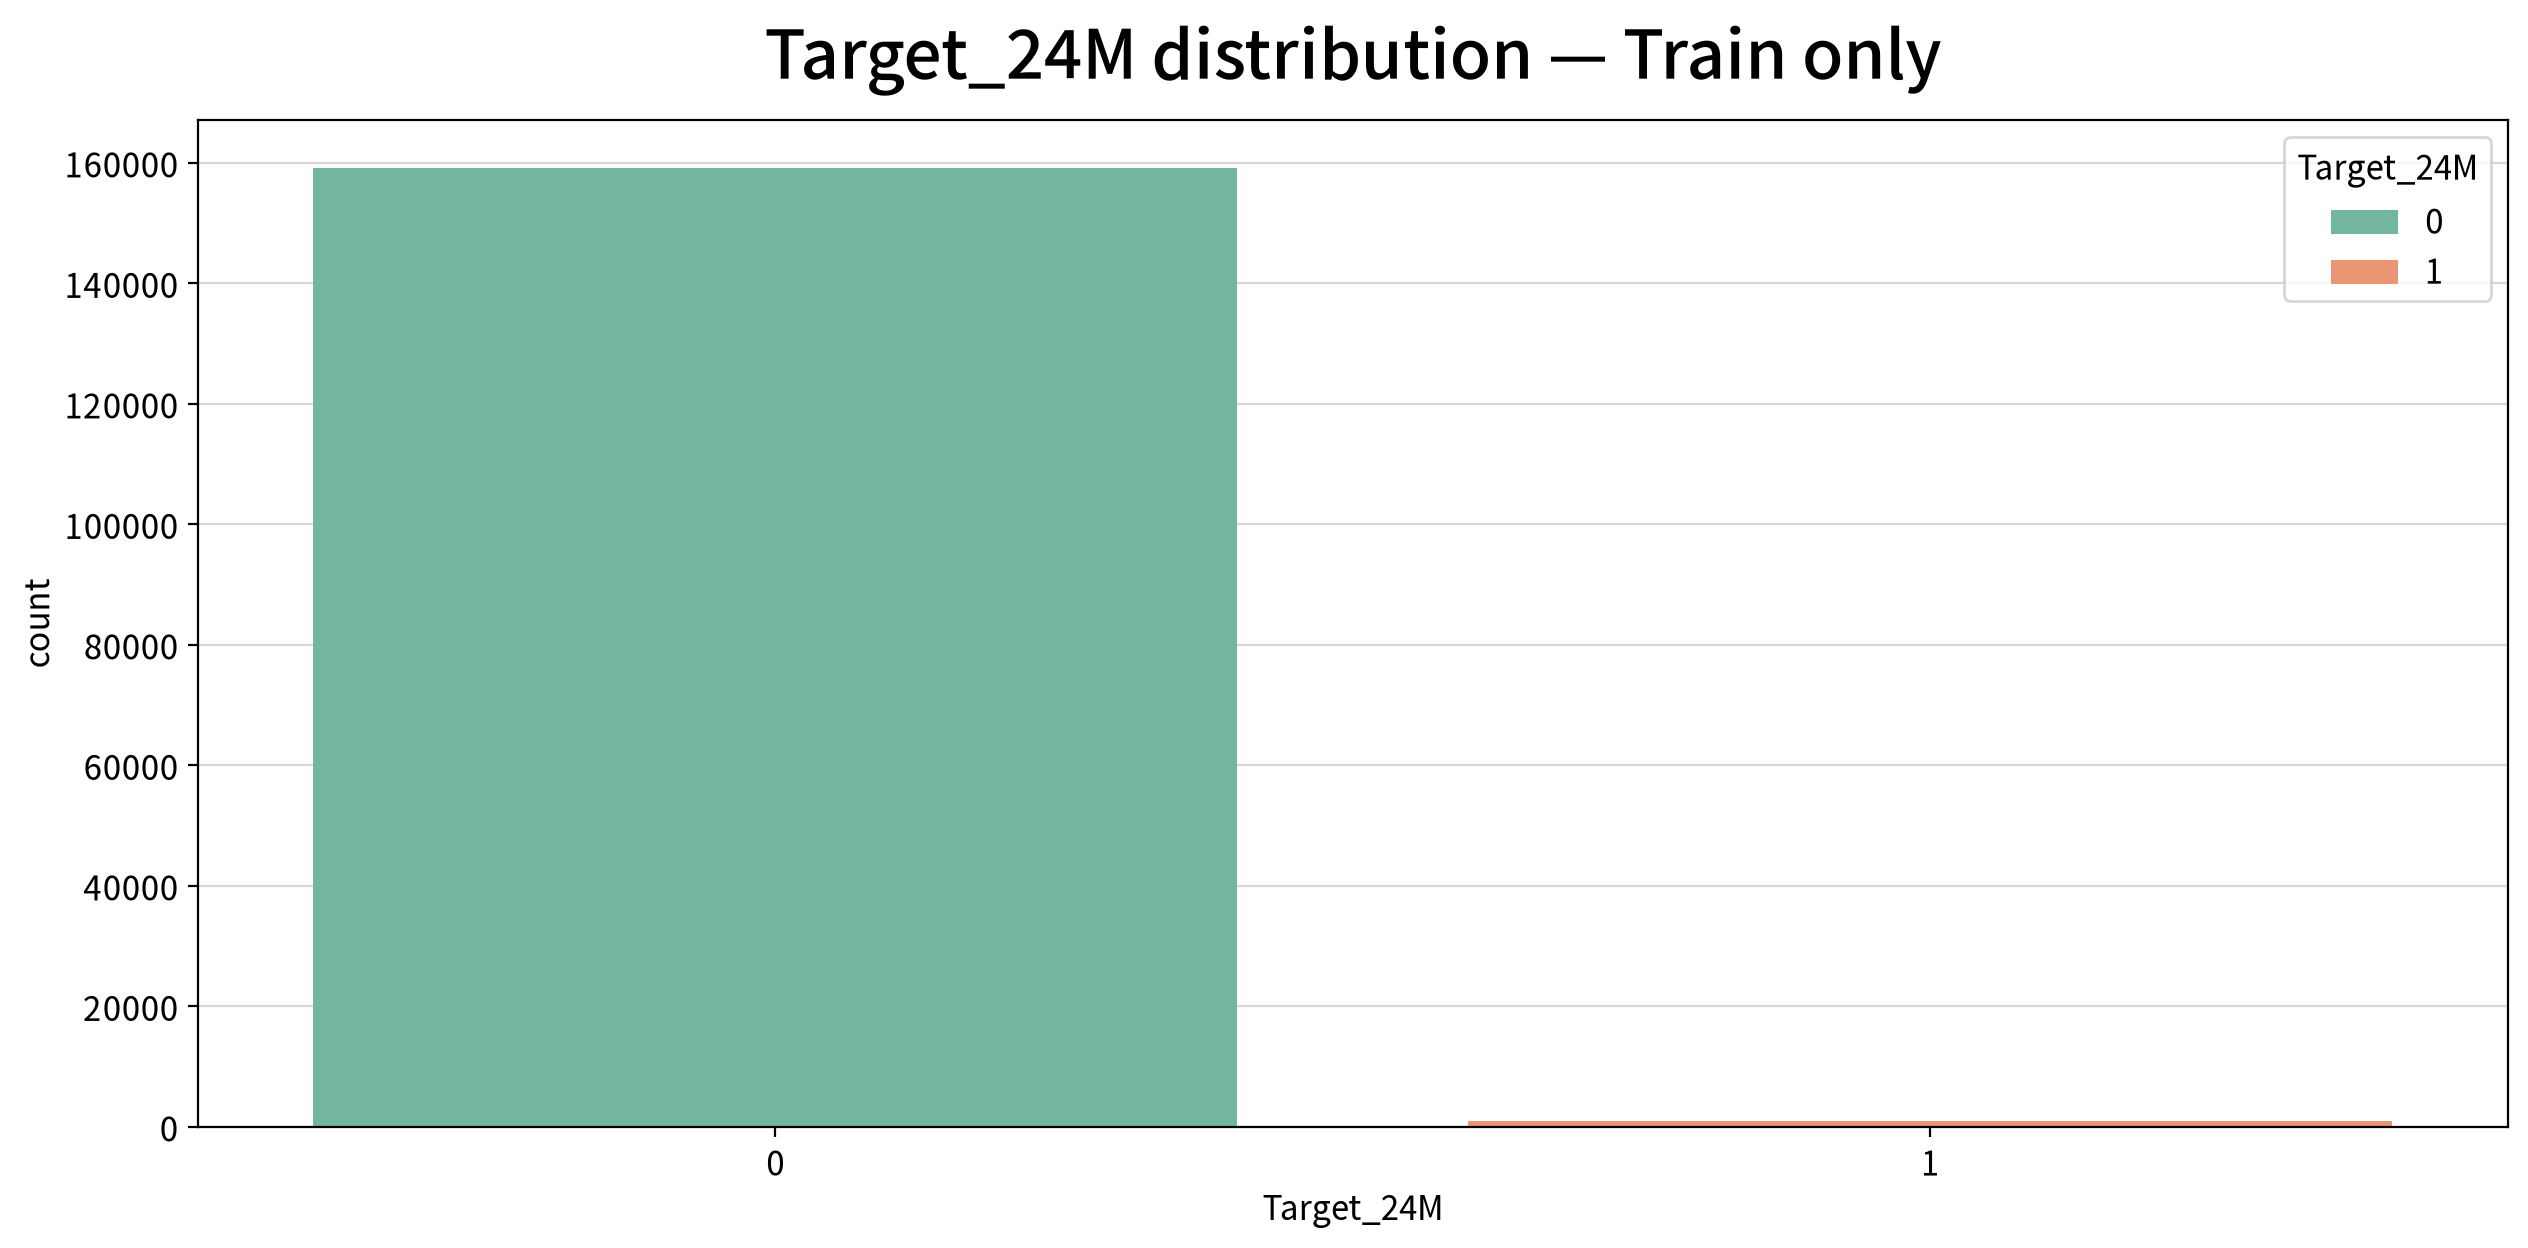

In [4]:
# ======================================================================================
# 3. TARGET UNIVARIATE ANALYSIS — TRAIN ONLY
# ======================================================================================
assert set(df[TARGET].dropna().unique()).issubset({0, 1, False, True}), "Target is not binary 0/1."

target_freq = df[TARGET].value_counts(dropna=False).sort_index().rename("N").to_frame()
target_freq["Pct"] = target_freq["N"] / len(df) * 100
display(target_freq)

majority_baseline = target_freq["N"].max() / len(df)
positive_rate = pd.to_numeric(df[TARGET]).mean()
print(f"Positive-event rate       : {positive_rate:.6%}")
print(f"Majority-class baseline   : {majority_baseline:.6%}")
print(f"Positive / Negative ratio : {int((df[TARGET]==1).sum()):,} / {int((df[TARGET]==0).sum()):,}")

if HOSSAM_AVAILABLE:
    my_plot.countplot(
        data=df, x=TARGET, hue=TARGET, palette="Set2", dodge=False,
        title="Target_24M distribution — Train only"
    )

target_freq.to_csv(QA_DIR / "08A_target_distribution_train.csv")


### First_Time_Homebuyer — Train distribution

,N,Pct
First_Time_Homebuyer,,
N,134334,83.957176
Y,25656,16.034699
Missing,13,0.008125


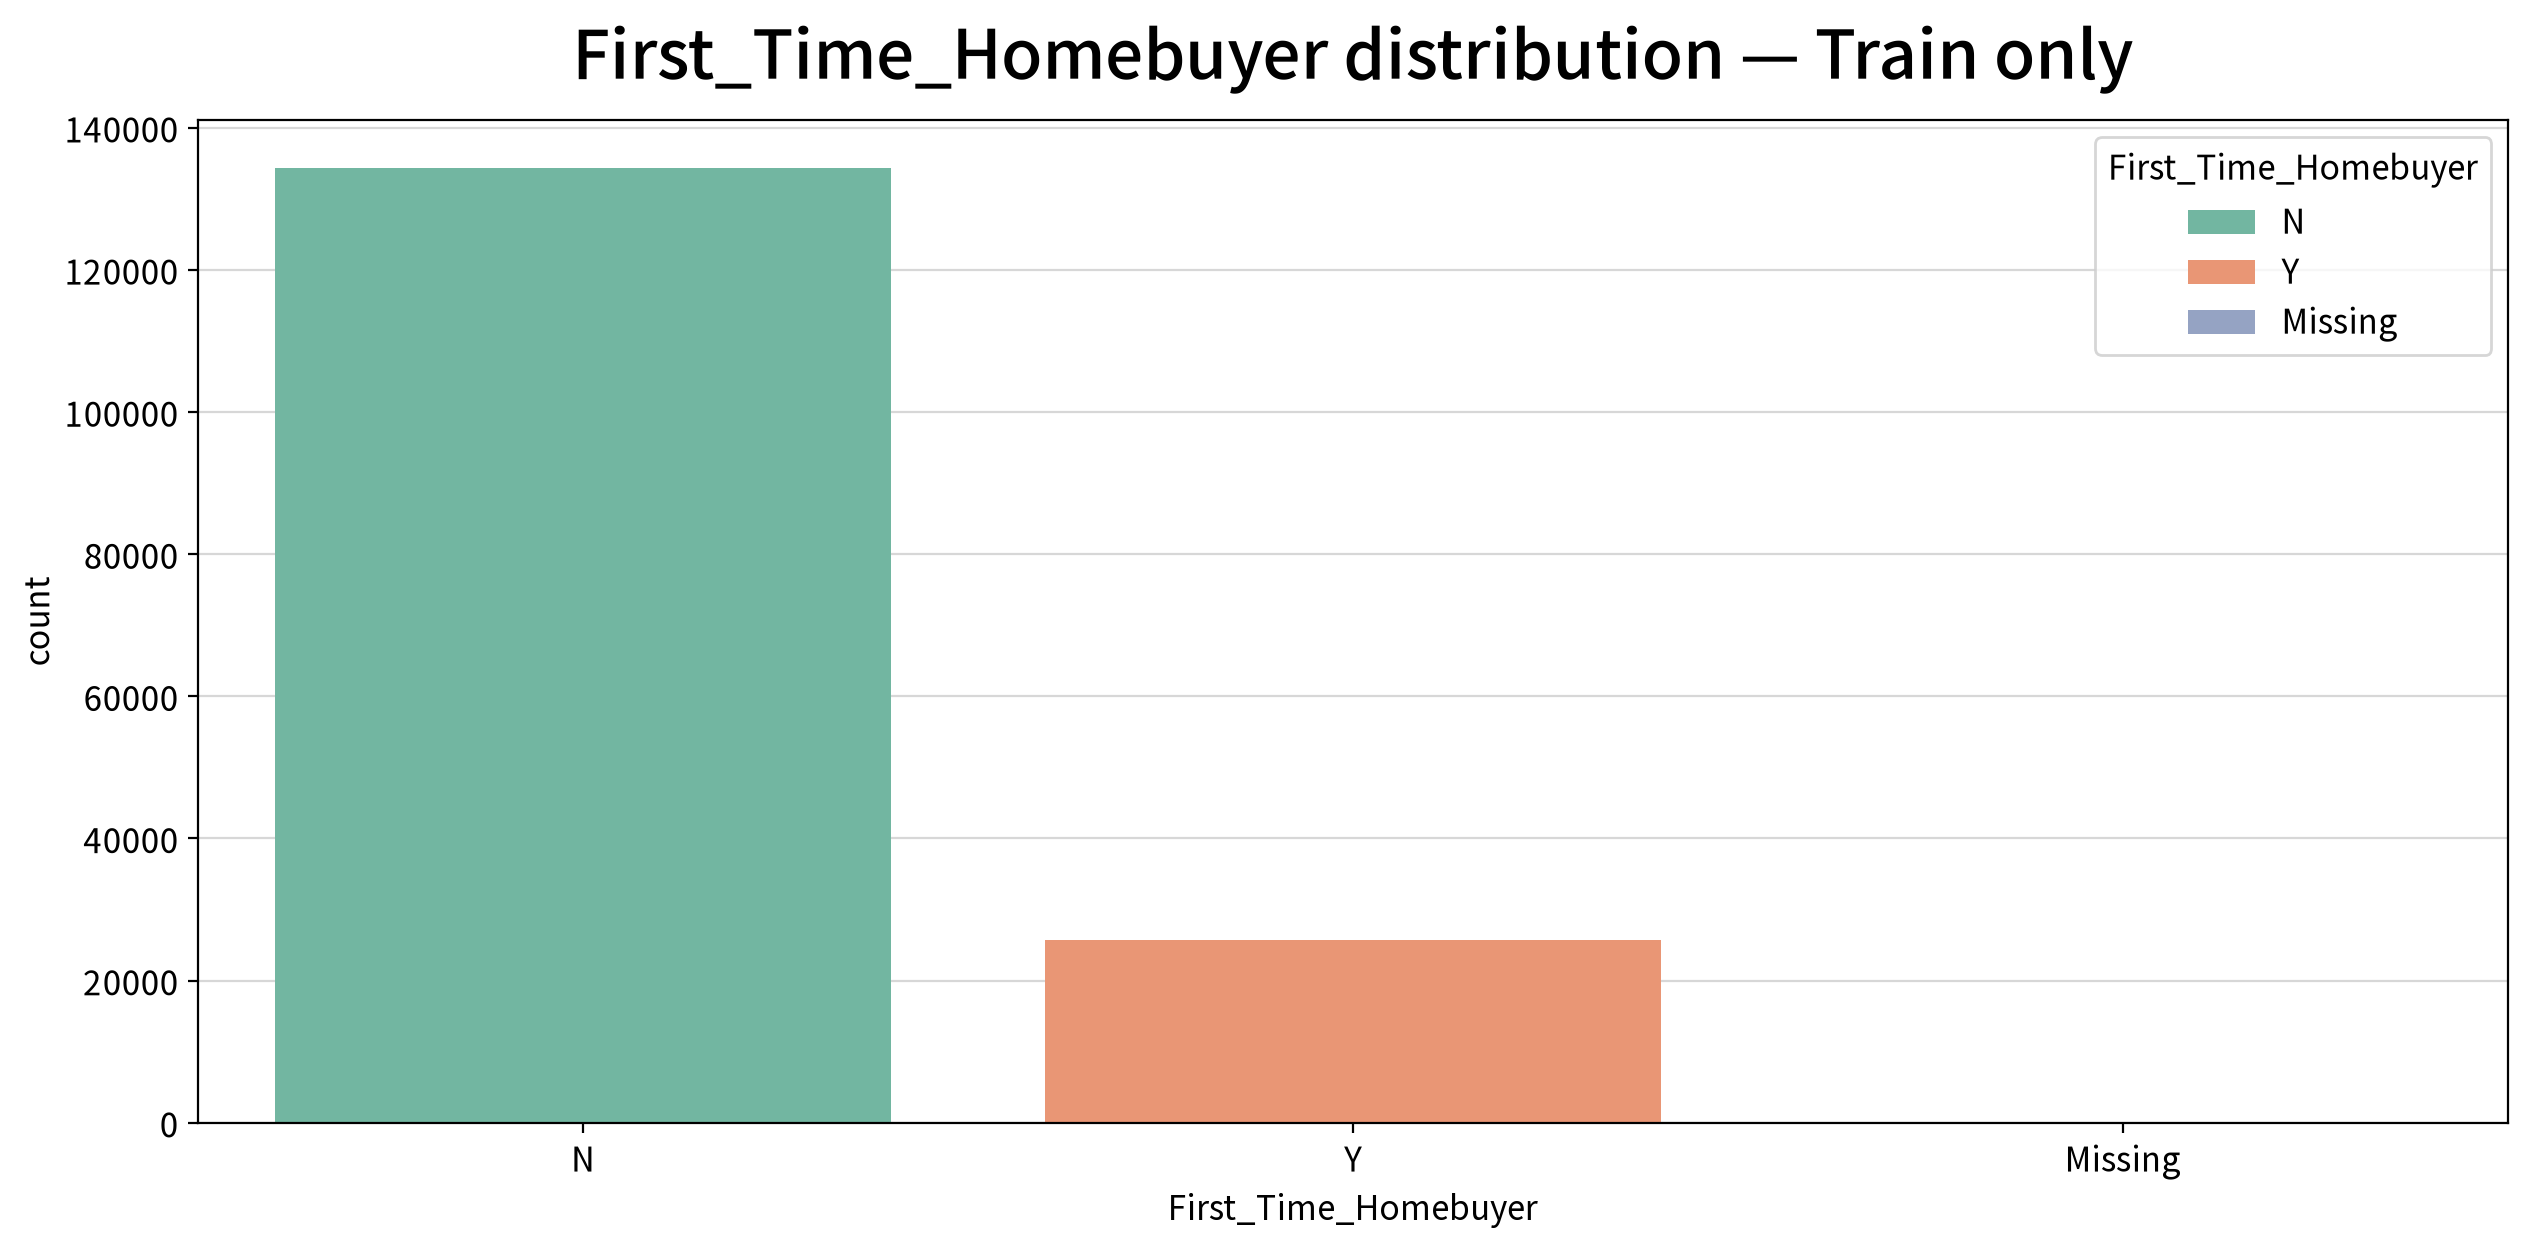

### MSA — Train distribution

,N,Pct
MSA,,
Missing,18851,11.781654
31084,5097,3.185565
38060,3219,2.011837
19740,3158,1.973713
12060,3150,1.968713
26420,3045,1.903089
40140,2897,1.810591
19124,2896,1.809966
47894,2884,1.802466


Plot skipped: 453 levels > MAX_PLOT_LEVELS=20. Full frequency table saved.


### Number_of_Units — Train distribution

,N,Pct
Number_of_Units,,
1.0,156486,97.801916
2.0,2414,1.508722
3.0,615,0.384368
4.0,488,0.304994


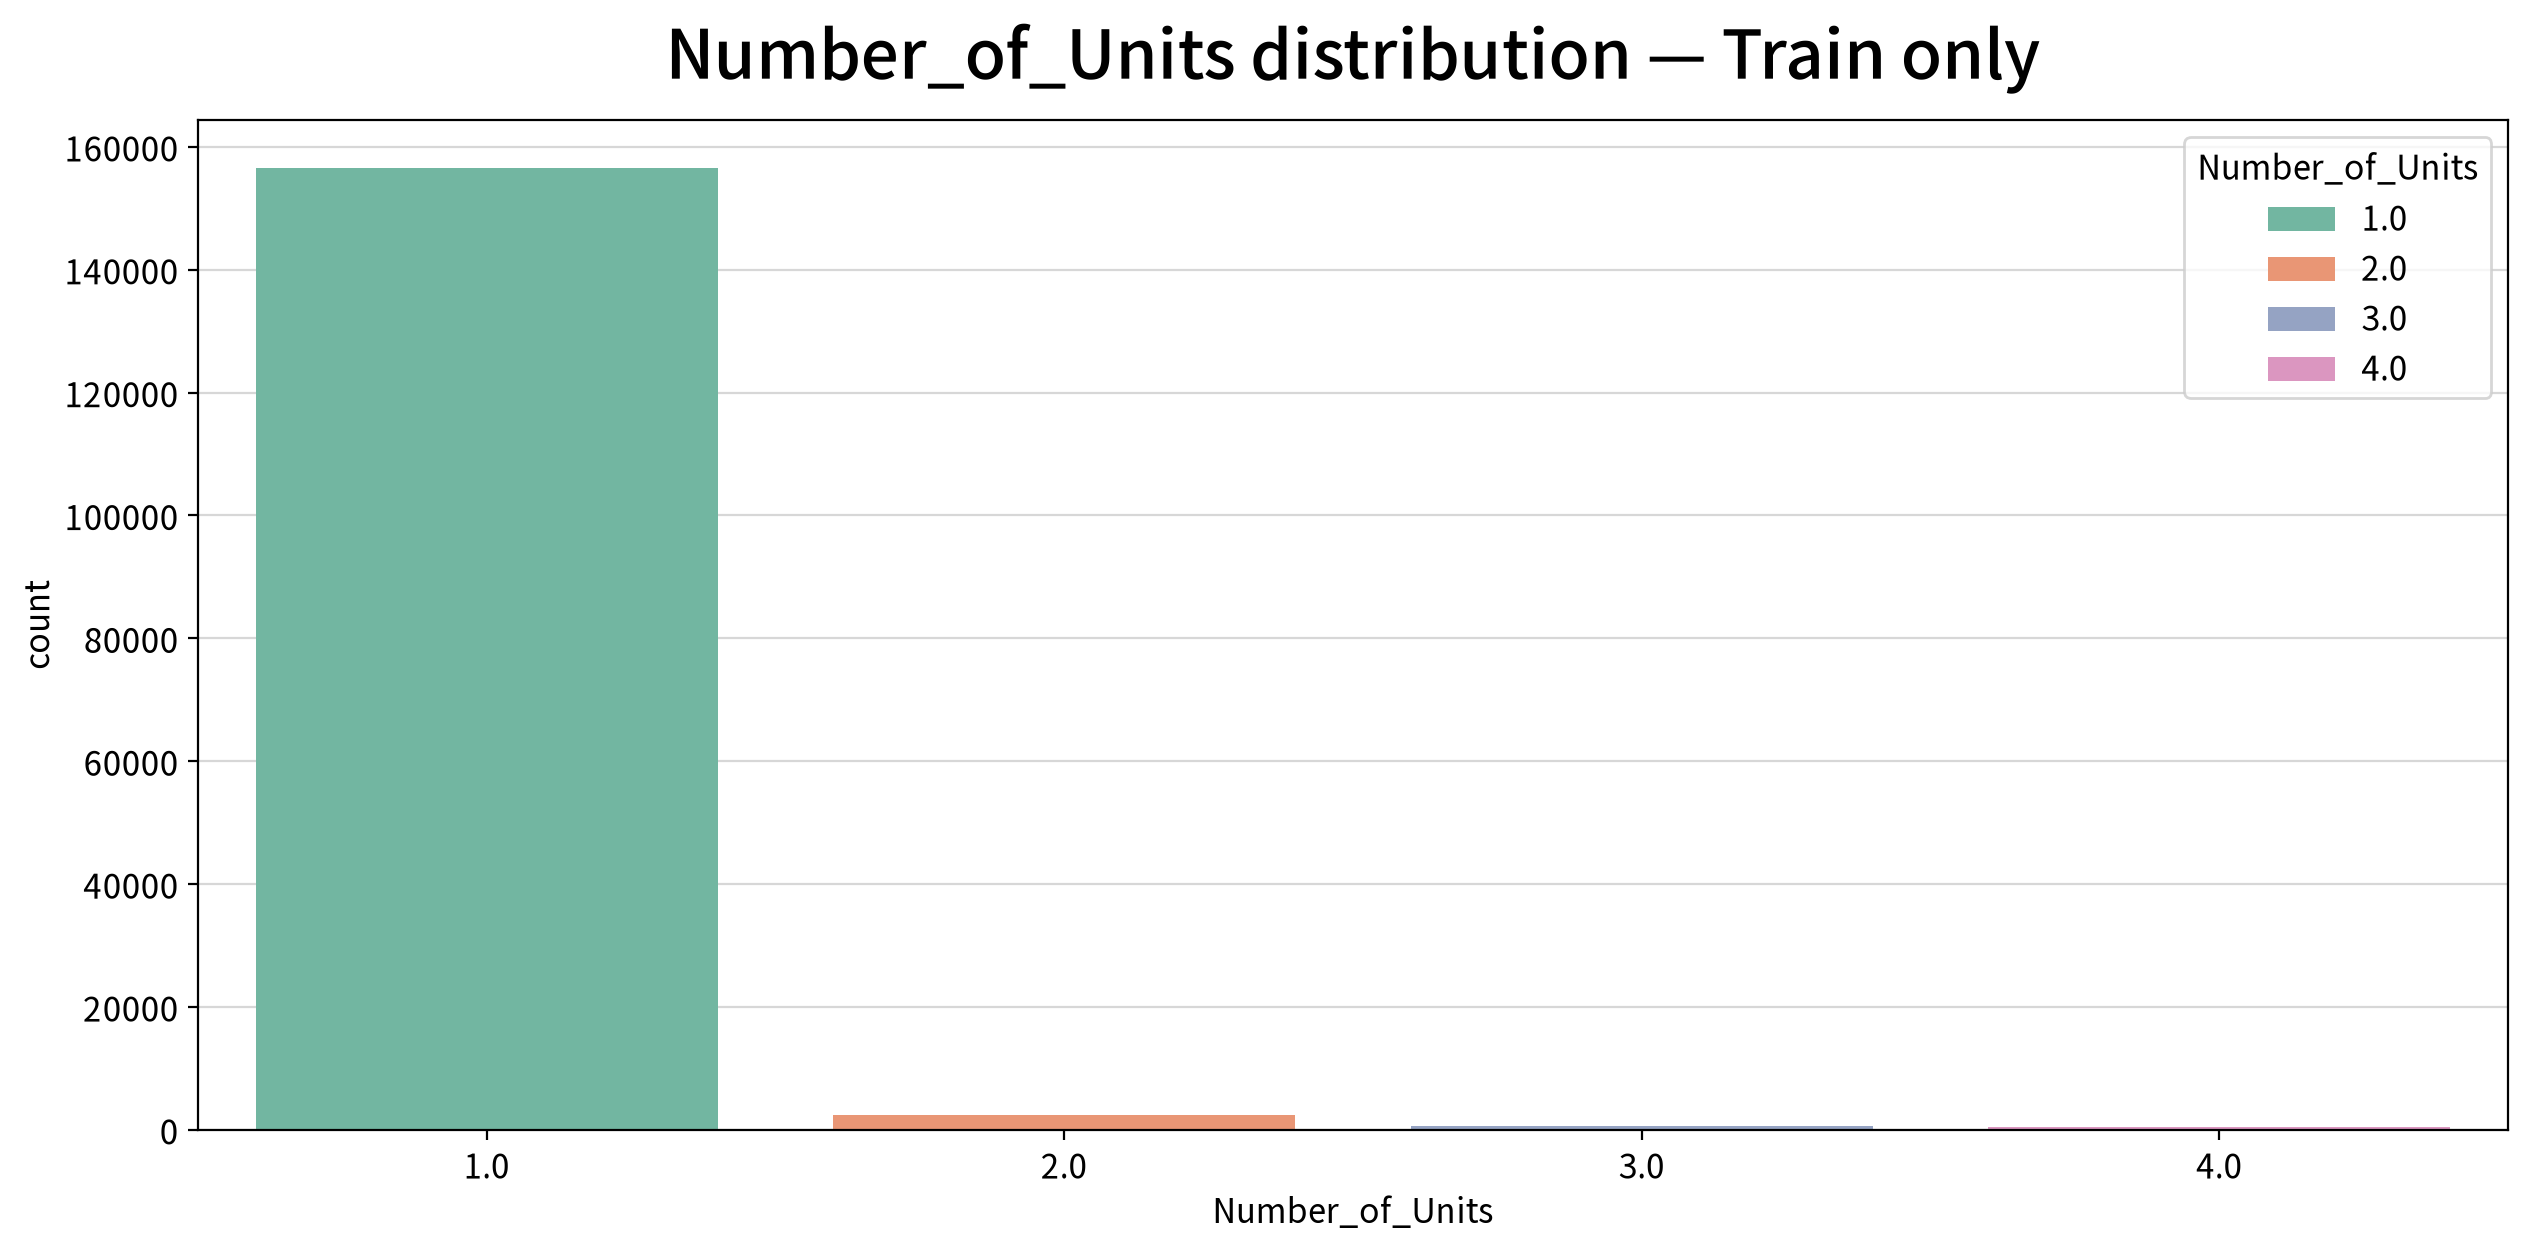

### Occupancy_Status — Train distribution

,N,Pct
Occupancy_Status,,
P,140123,87.575233
I,14190,8.868584
S,5690,3.556183


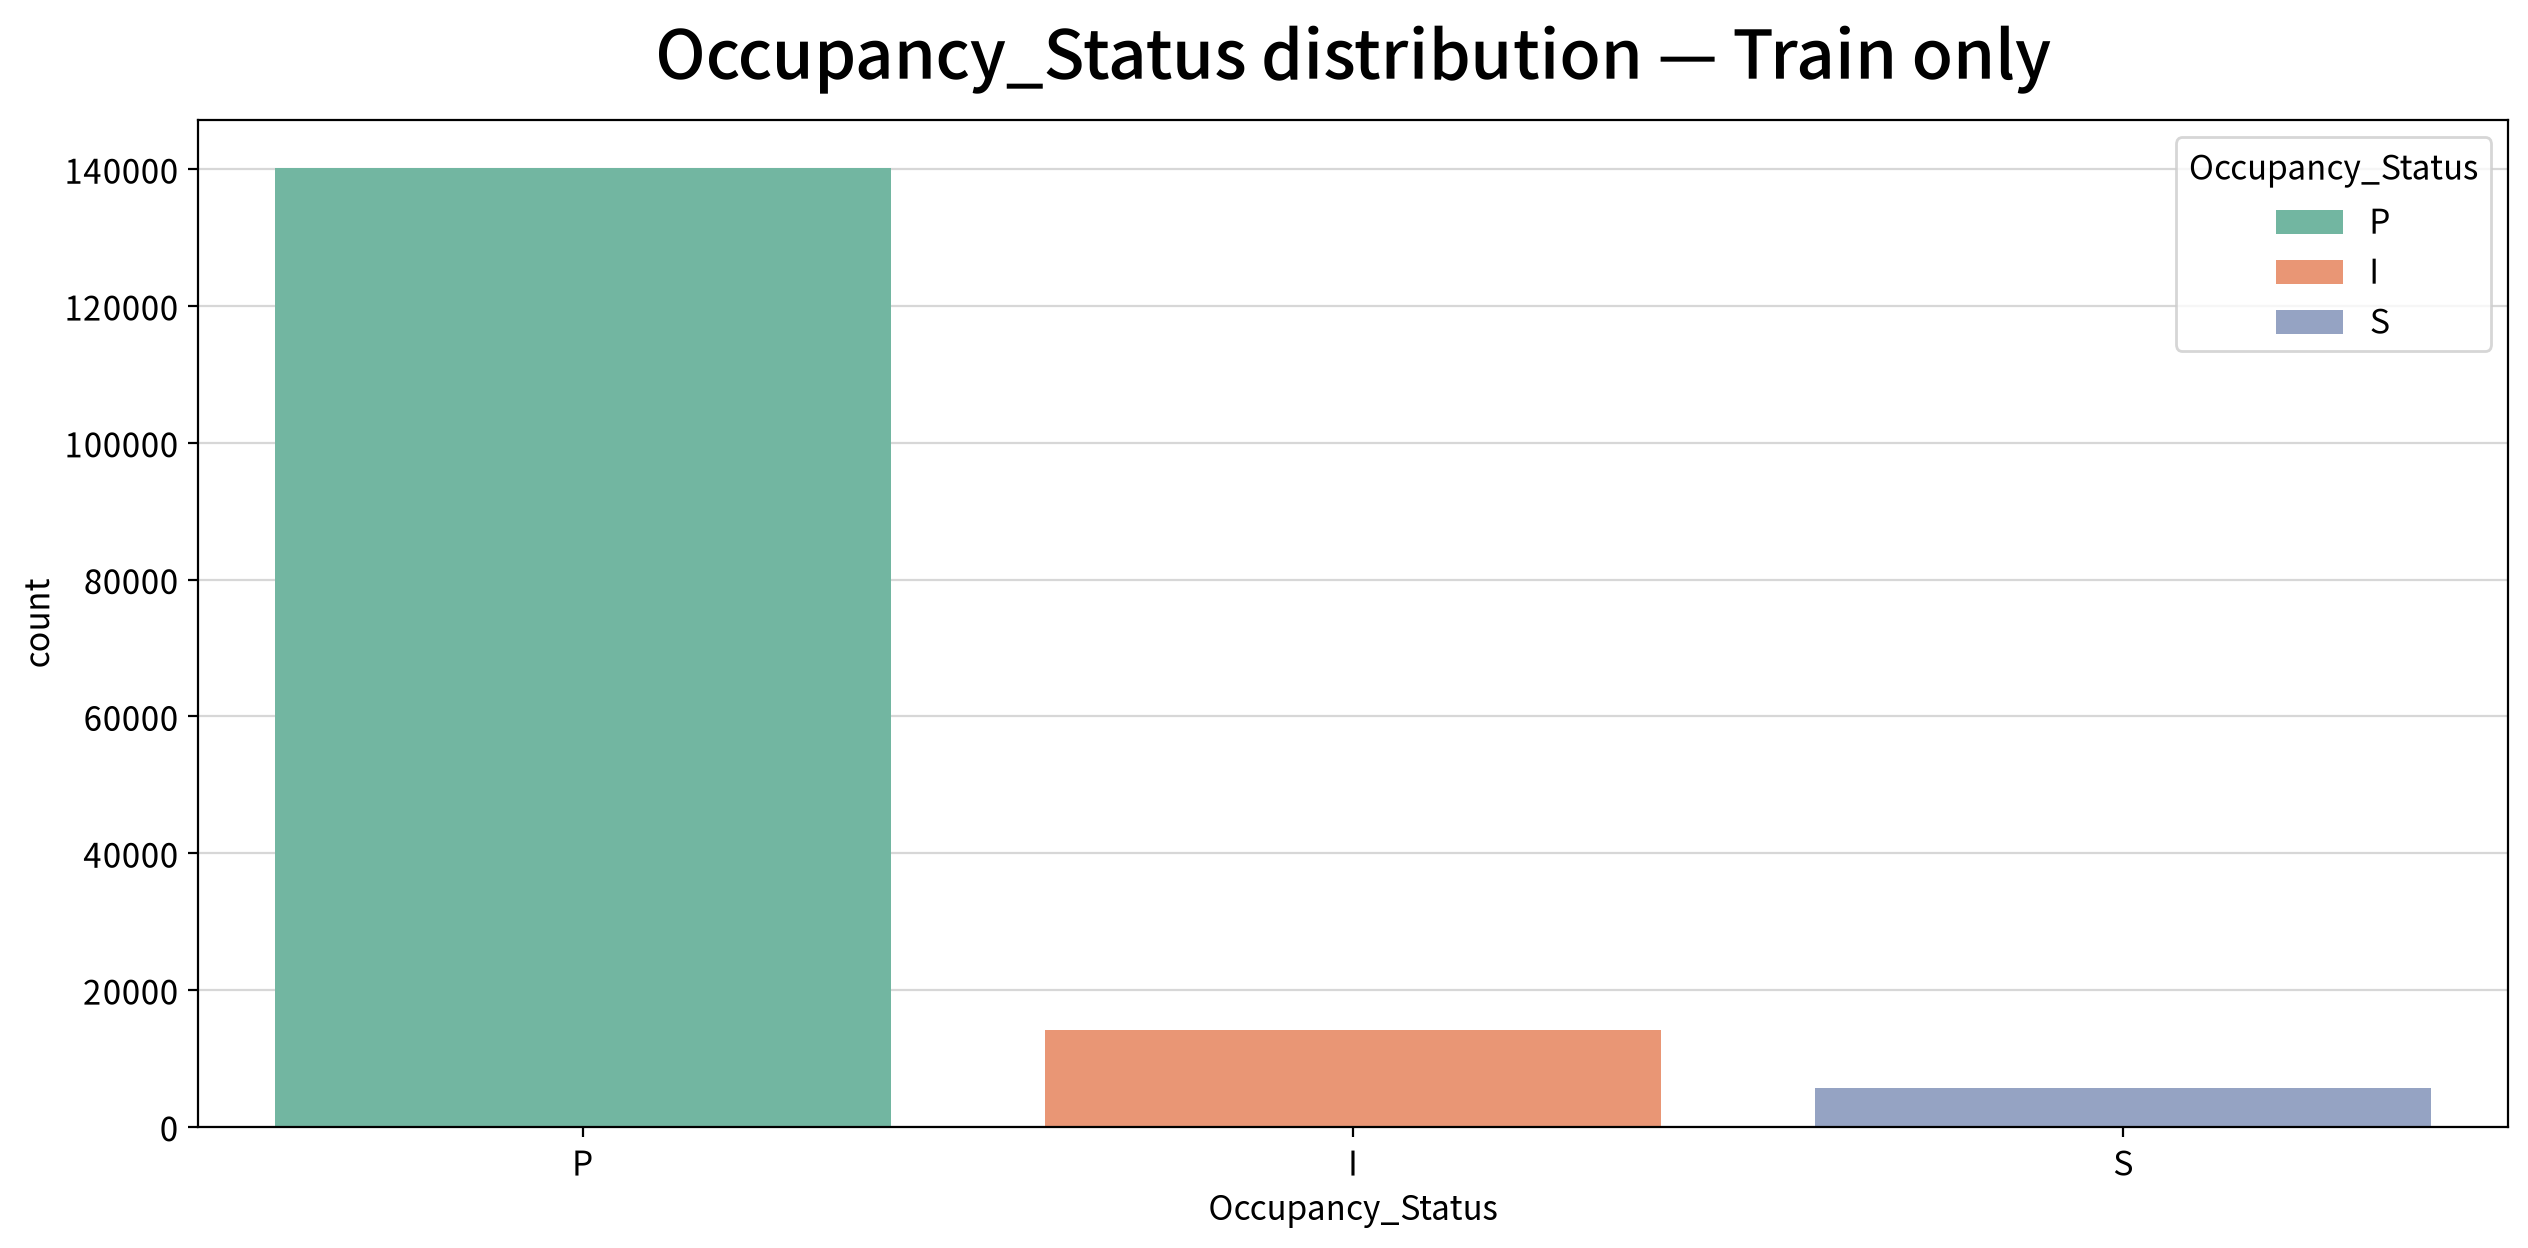

### Channel — Train distribution

,N,Pct
Channel,,
R,98065,61.289476
C,46634,29.145704
B,15304,9.564821


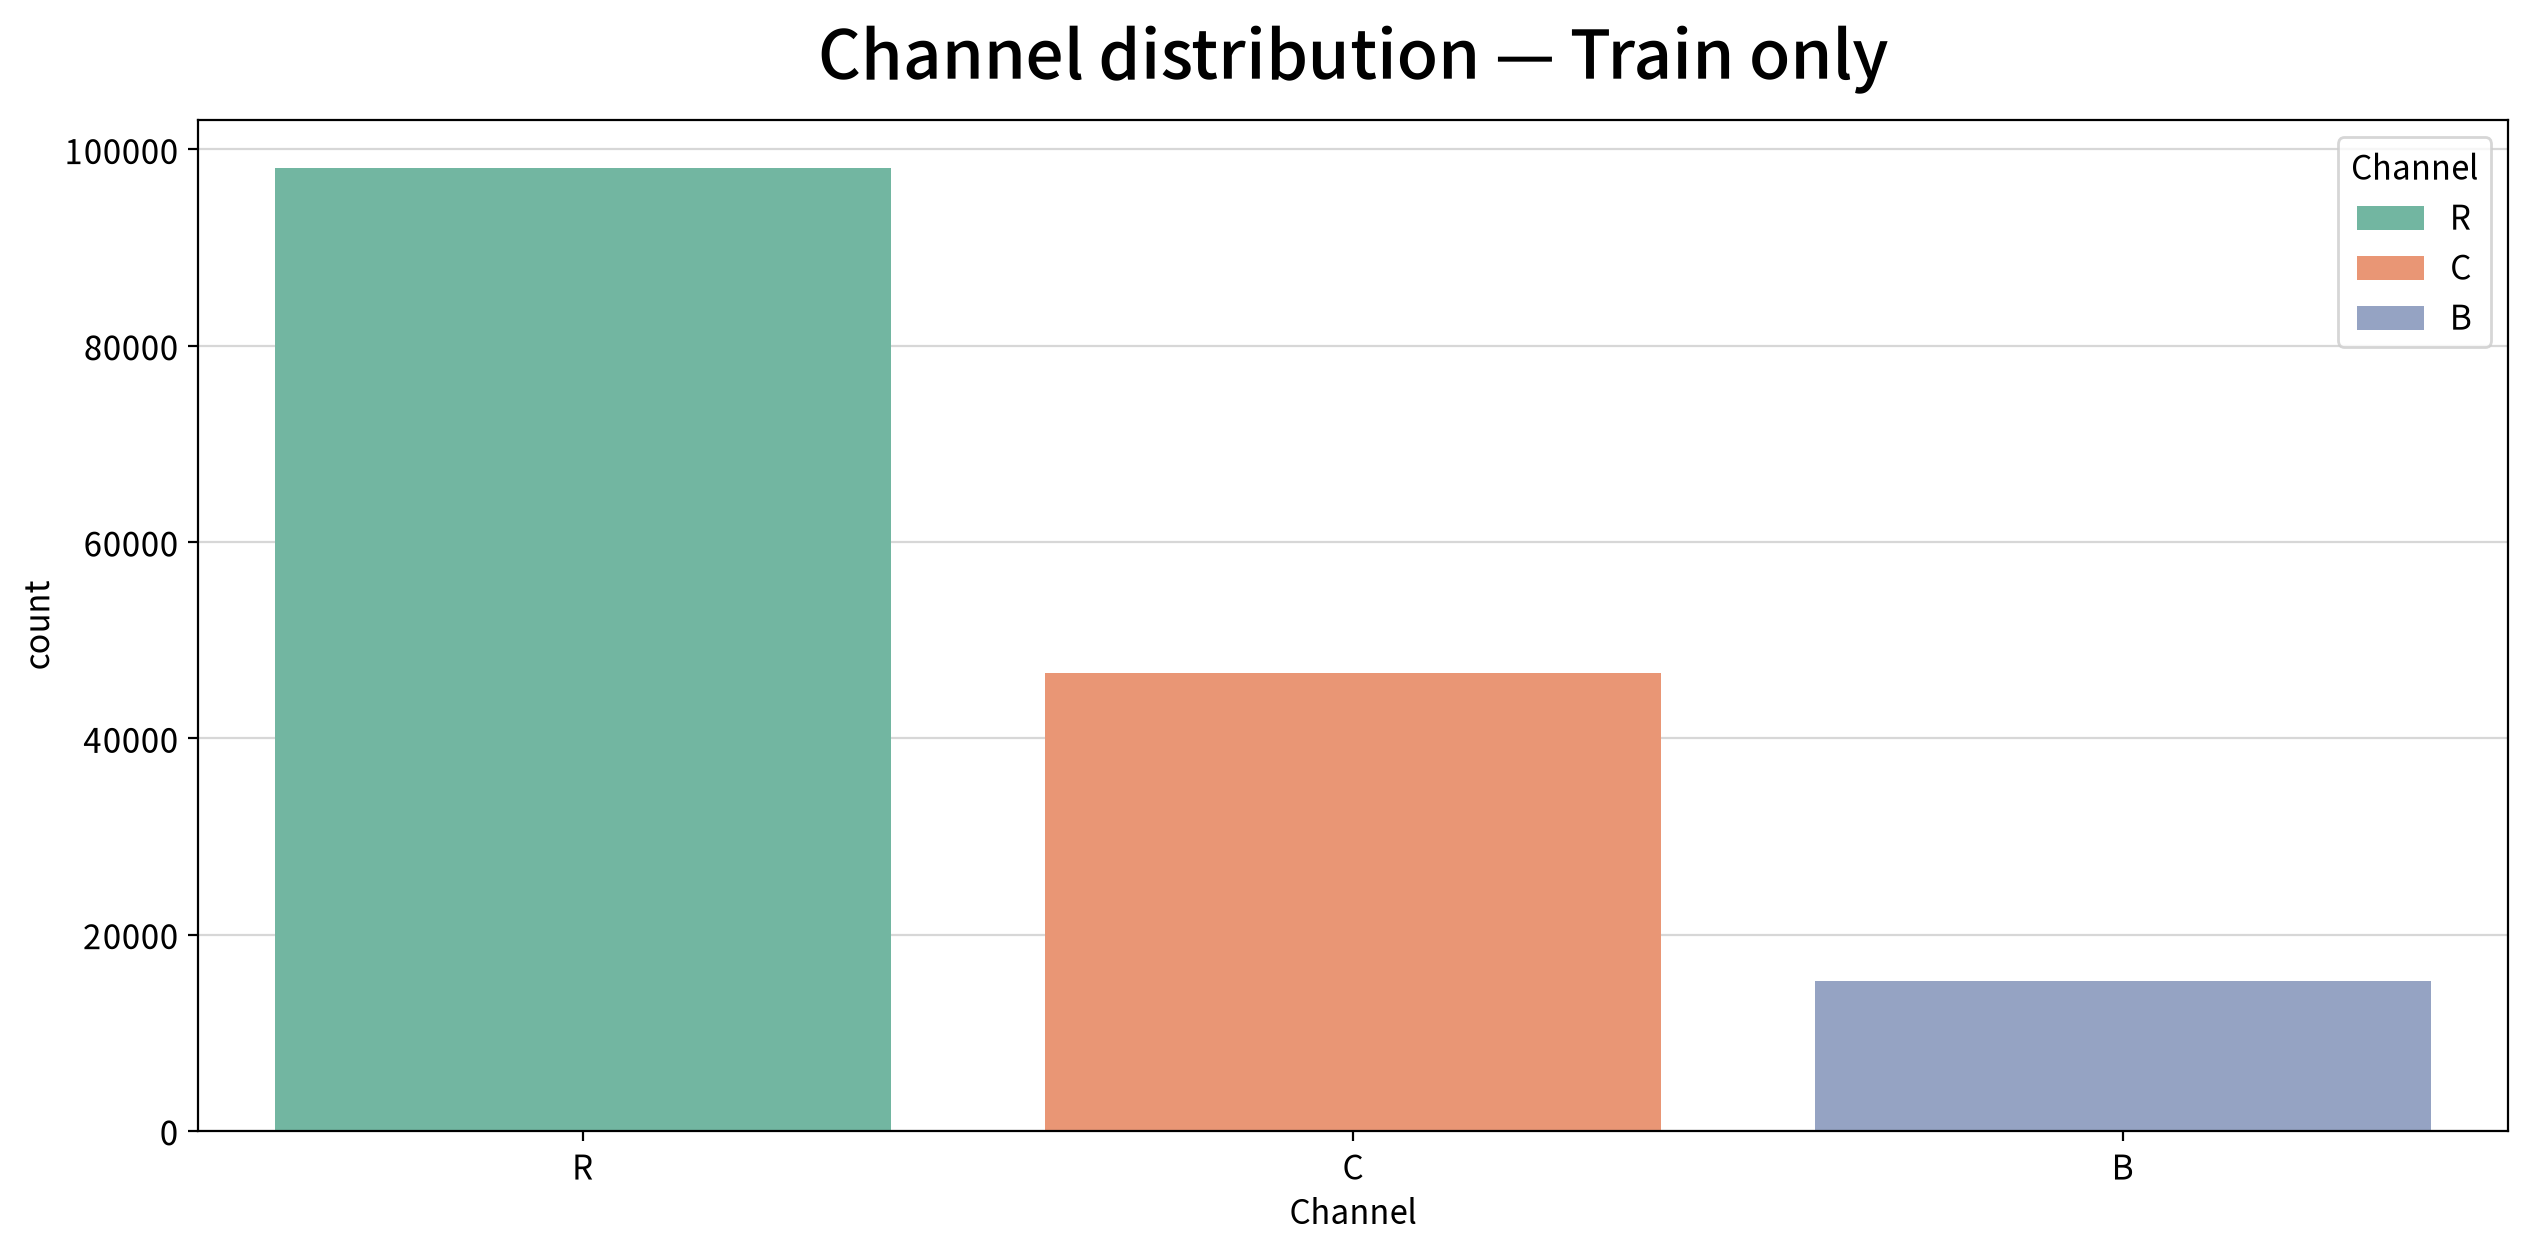

### Property_State — Train distribution

,N,Pct
Property_State,,
CA,24363,15.226590
TX,11195,6.996744
FL,9666,6.041137
IL,7432,4.644913
MI,5919,3.699306
CO,5266,3.291188
OH,5225,3.265564
NY,5047,3.154316
NC,5016,3.134941


Plot skipped: 54 levels > MAX_PLOT_LEVELS=20. Full frequency table saved.


### Property_Type — Train distribution

,N,Pct
Property_Type,,
SF,104972,65.60627
PU,41222,25.763267
CO,12968,8.104848
MH,595,0.371868
CP,246,0.153747


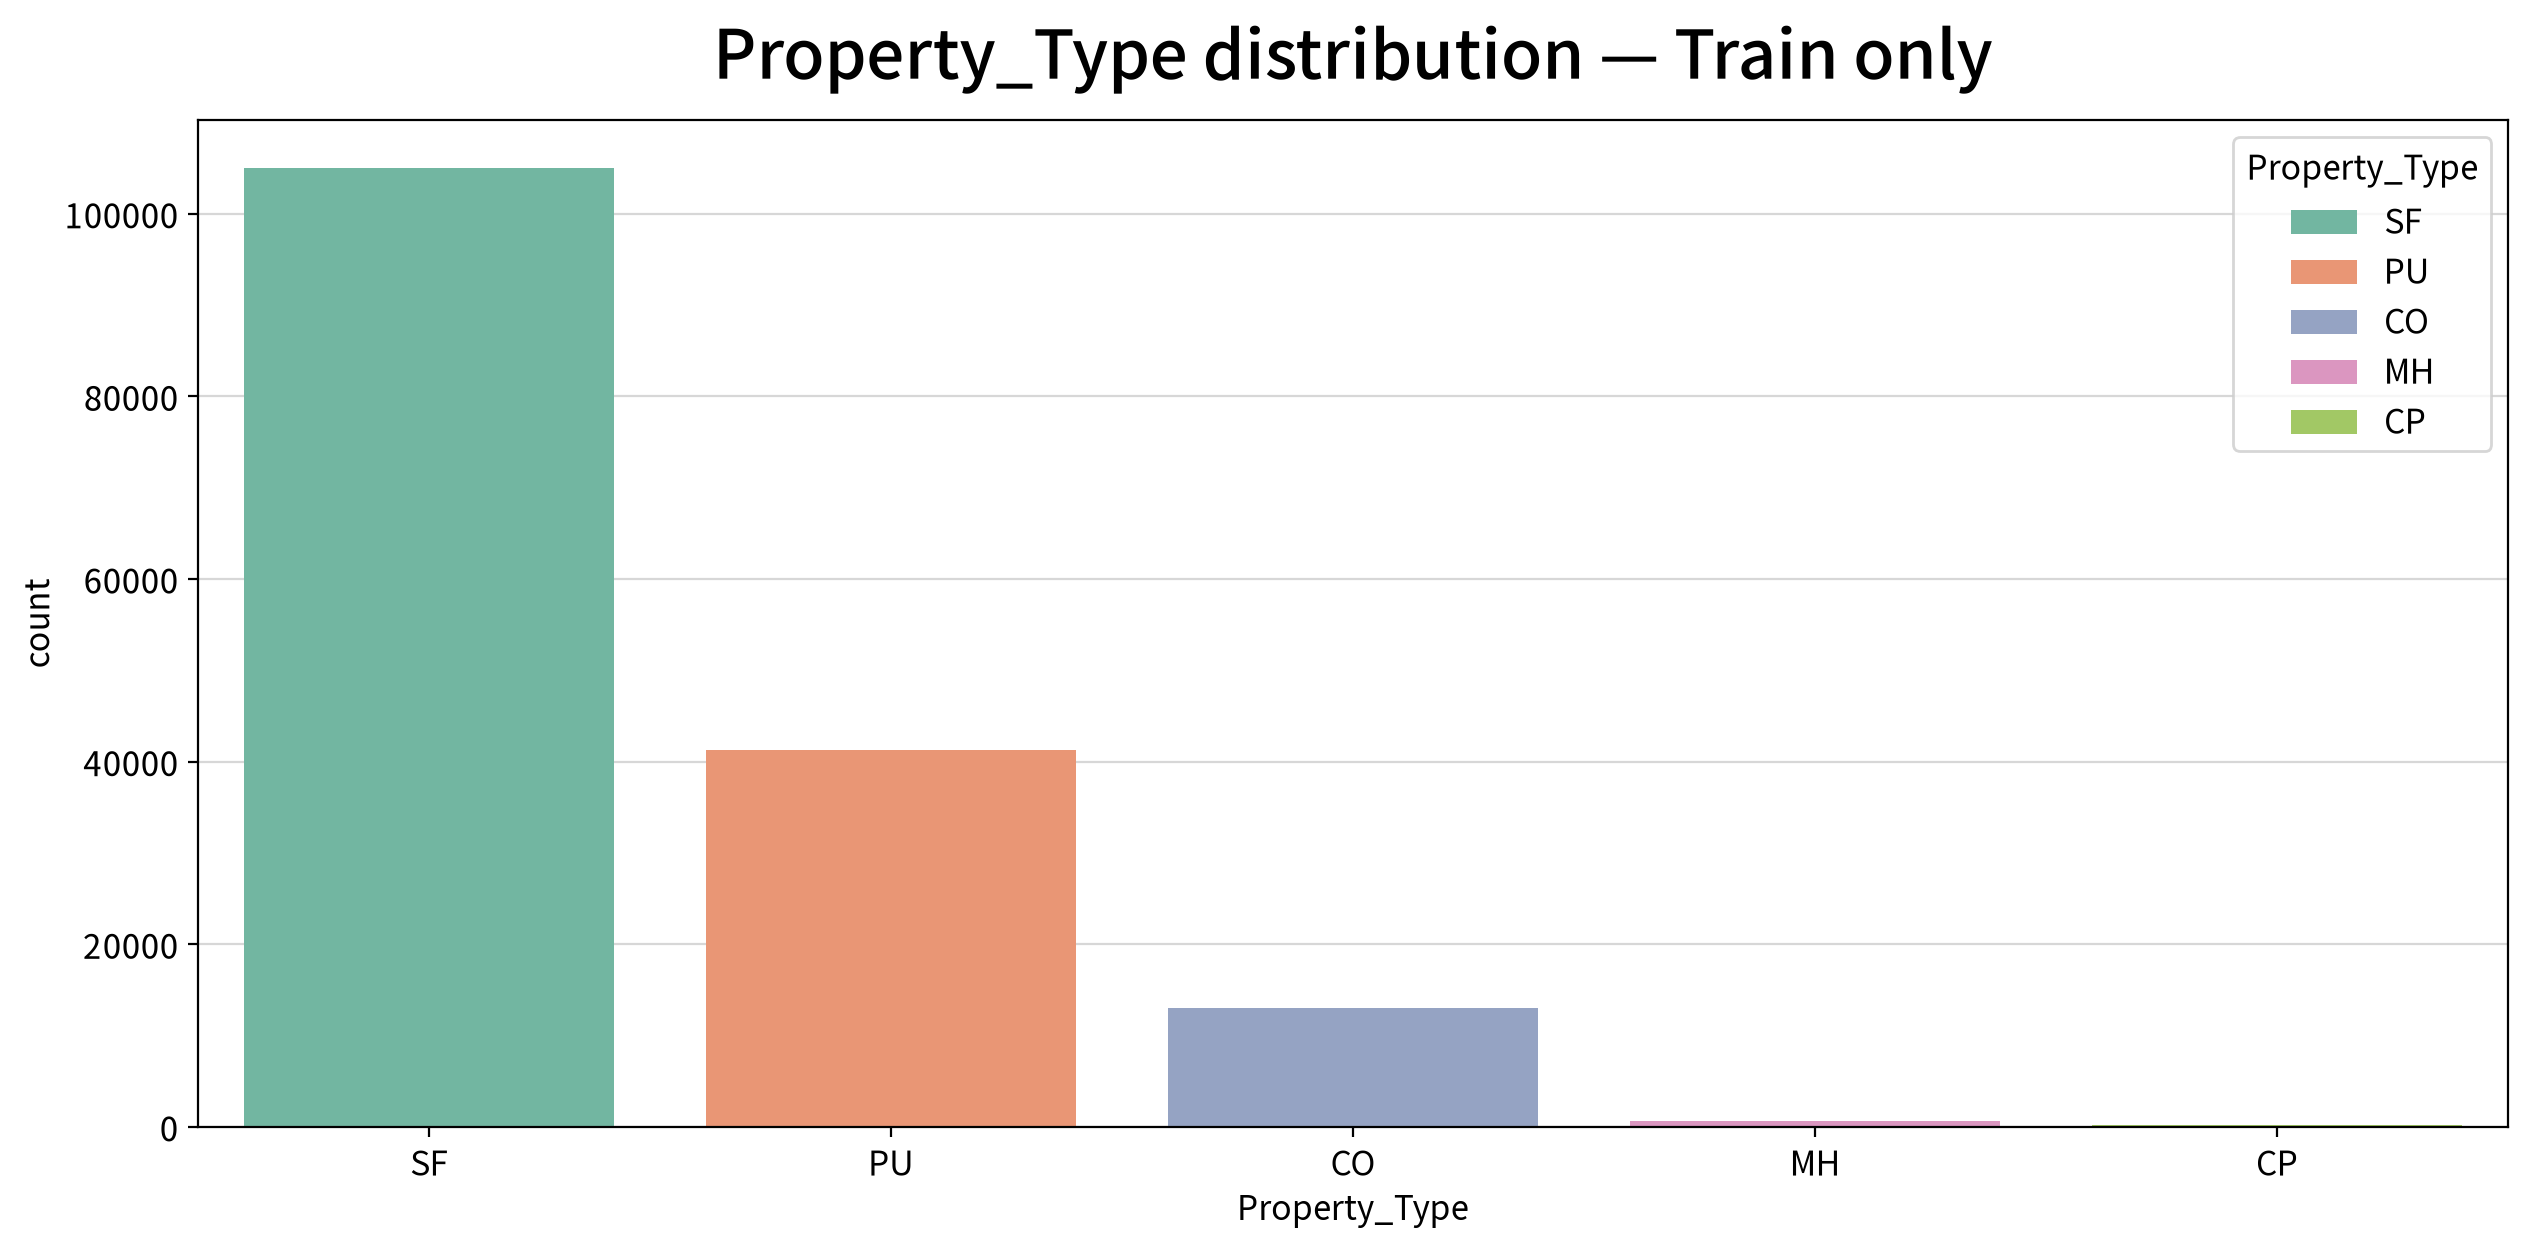

### Postal_Code — Train distribution

,N,Pct
Postal_Code,,
945,2115,1.32185
750,1961,1.225602
300,1604,1.002481
606,1399,0.874359
852,1380,0.862484
917,1298,0.811235
600,1280,0.799985
840,1274,0.796235
980,1214,0.758736


Plot skipped: 885 levels > MAX_PLOT_LEVELS=20. Full frequency table saved.


### Loan_Purpose — Train distribution

,N,Pct
Loan_Purpose,,
P,73061,45.662269
N,54425,34.014987
C,32517,20.322744


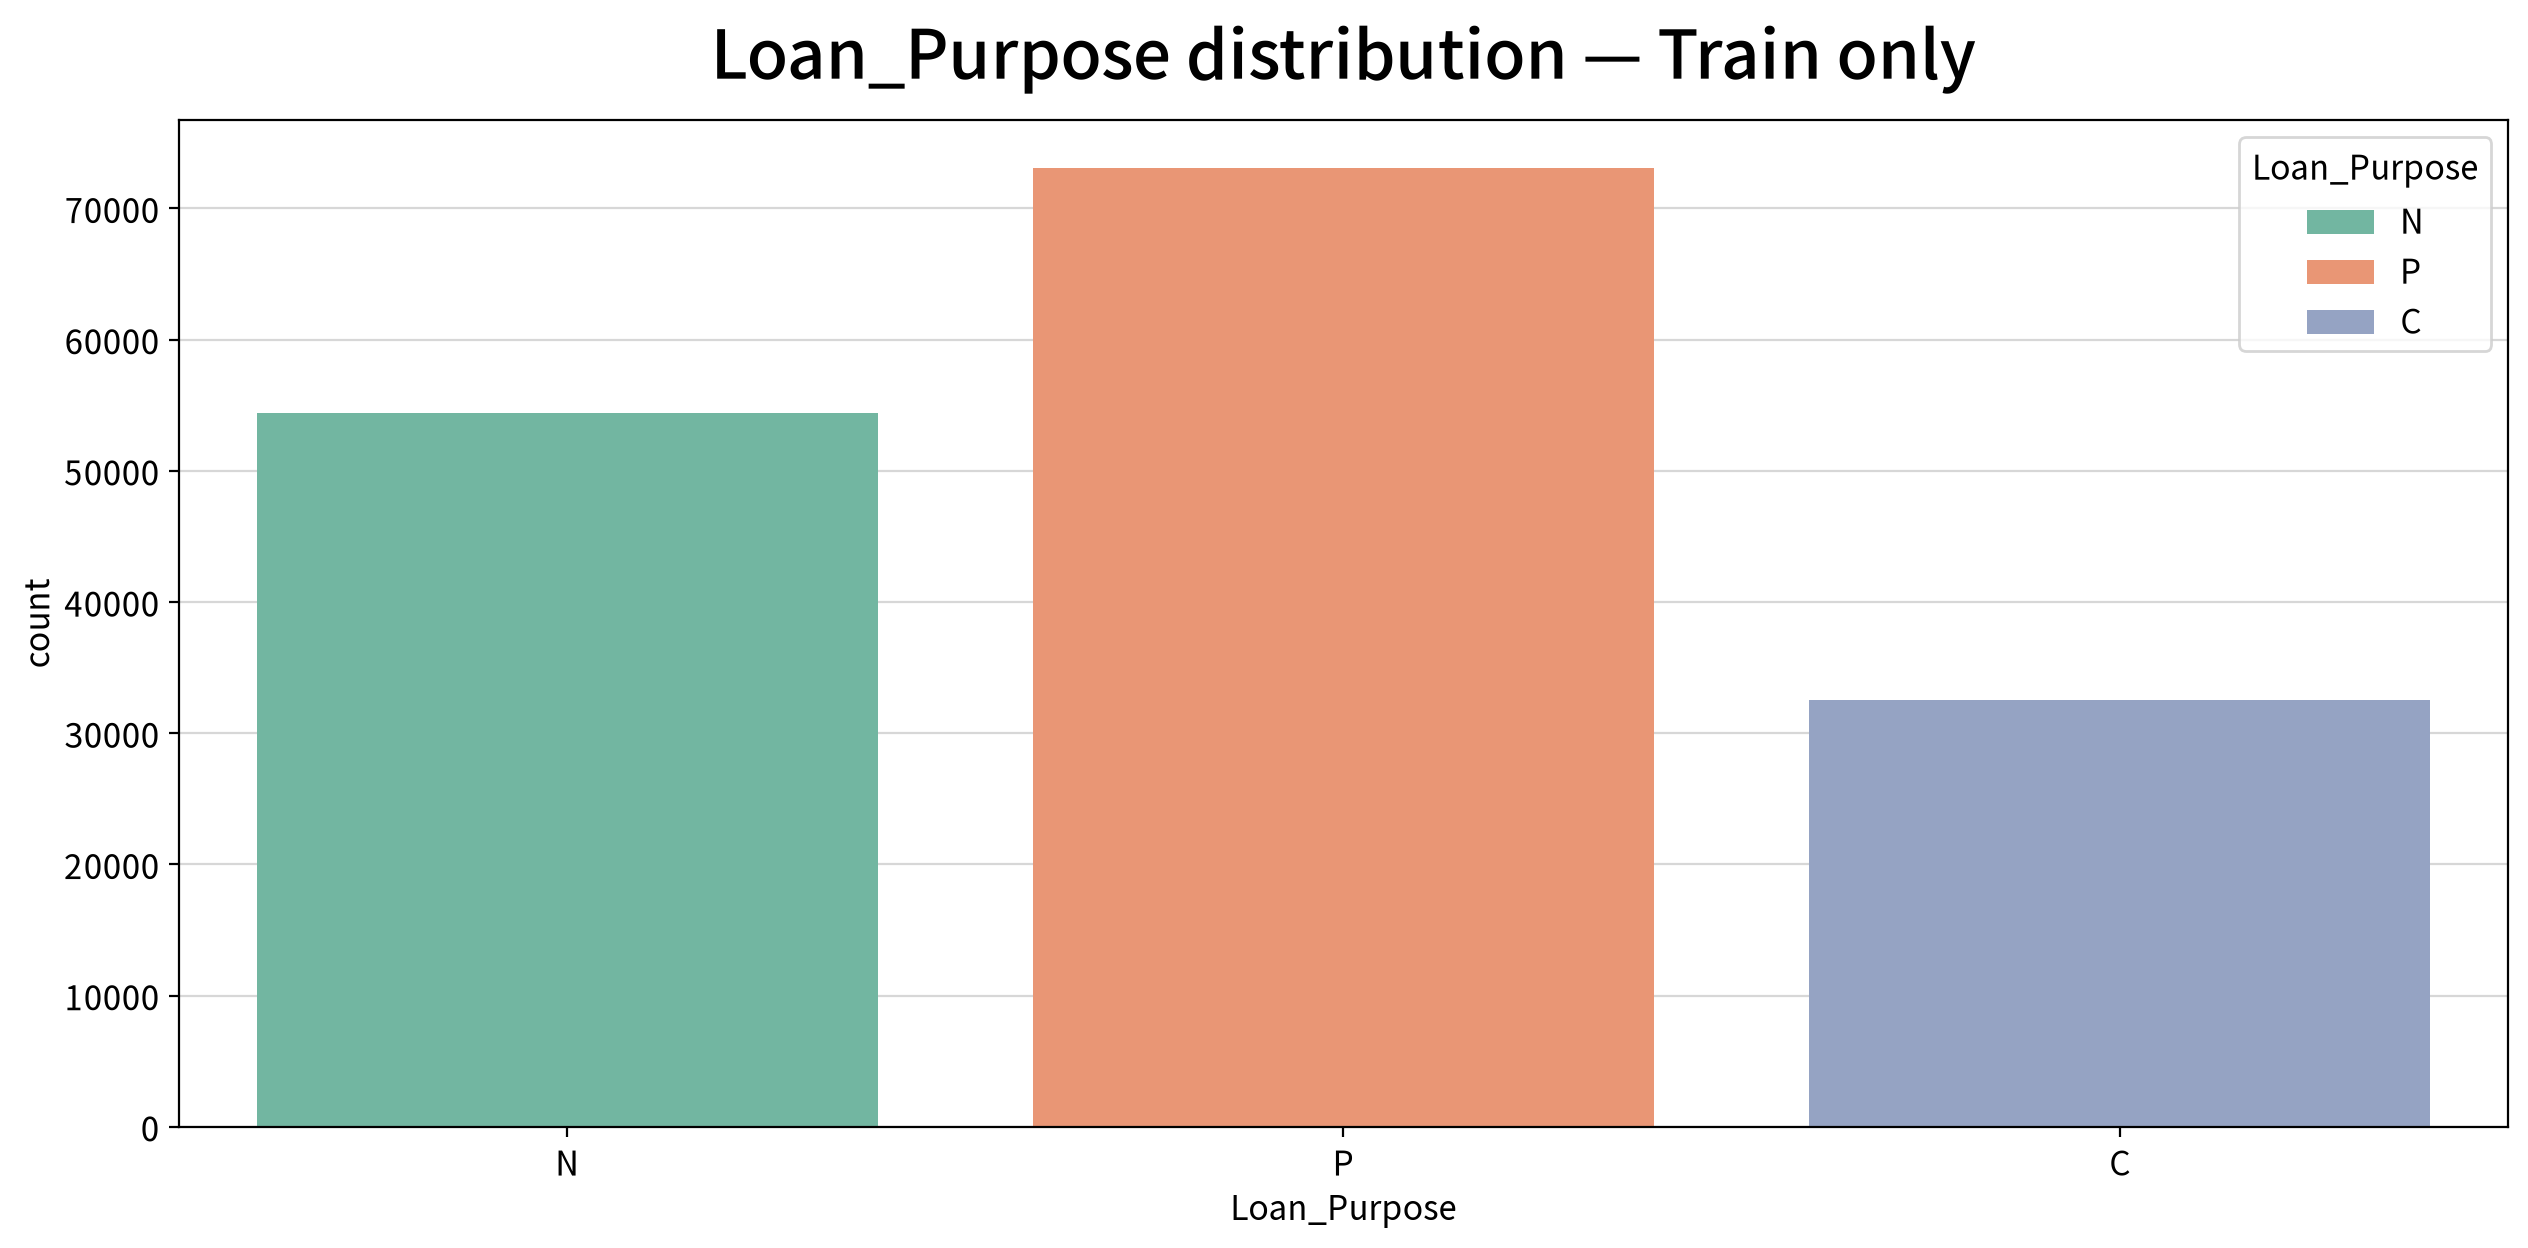

### Seller_Name — Train distribution

,N,Pct
Seller_Name,,
OTHER,57618,36.010575
"WELLS FARGO BANK, N.A.",23063,14.414105
U.S. BANK N.A.,9192,5.744892
"BANK OF AMERICA, N.A.",8818,5.511147
QUICKEN LOANS INC.,8233,5.145529
"JPMORGAN CHASE BANK, N.A.",8045,5.028031
BRANCH BANKING & TRUST COMPANY,5973,3.733055
"CALIBER HOME LOANS, INC.",4029,2.518078
"CITIMORTGAGE, INC.",3327,2.079336


Plot skipped: 34 levels > MAX_PLOT_LEVELS=20. Full frequency table saved.


### Super_Conforming_Flag — Train distribution

,N,Pct
Super_Conforming_Flag,,
N,154116,96.320694
Y,5887,3.679306


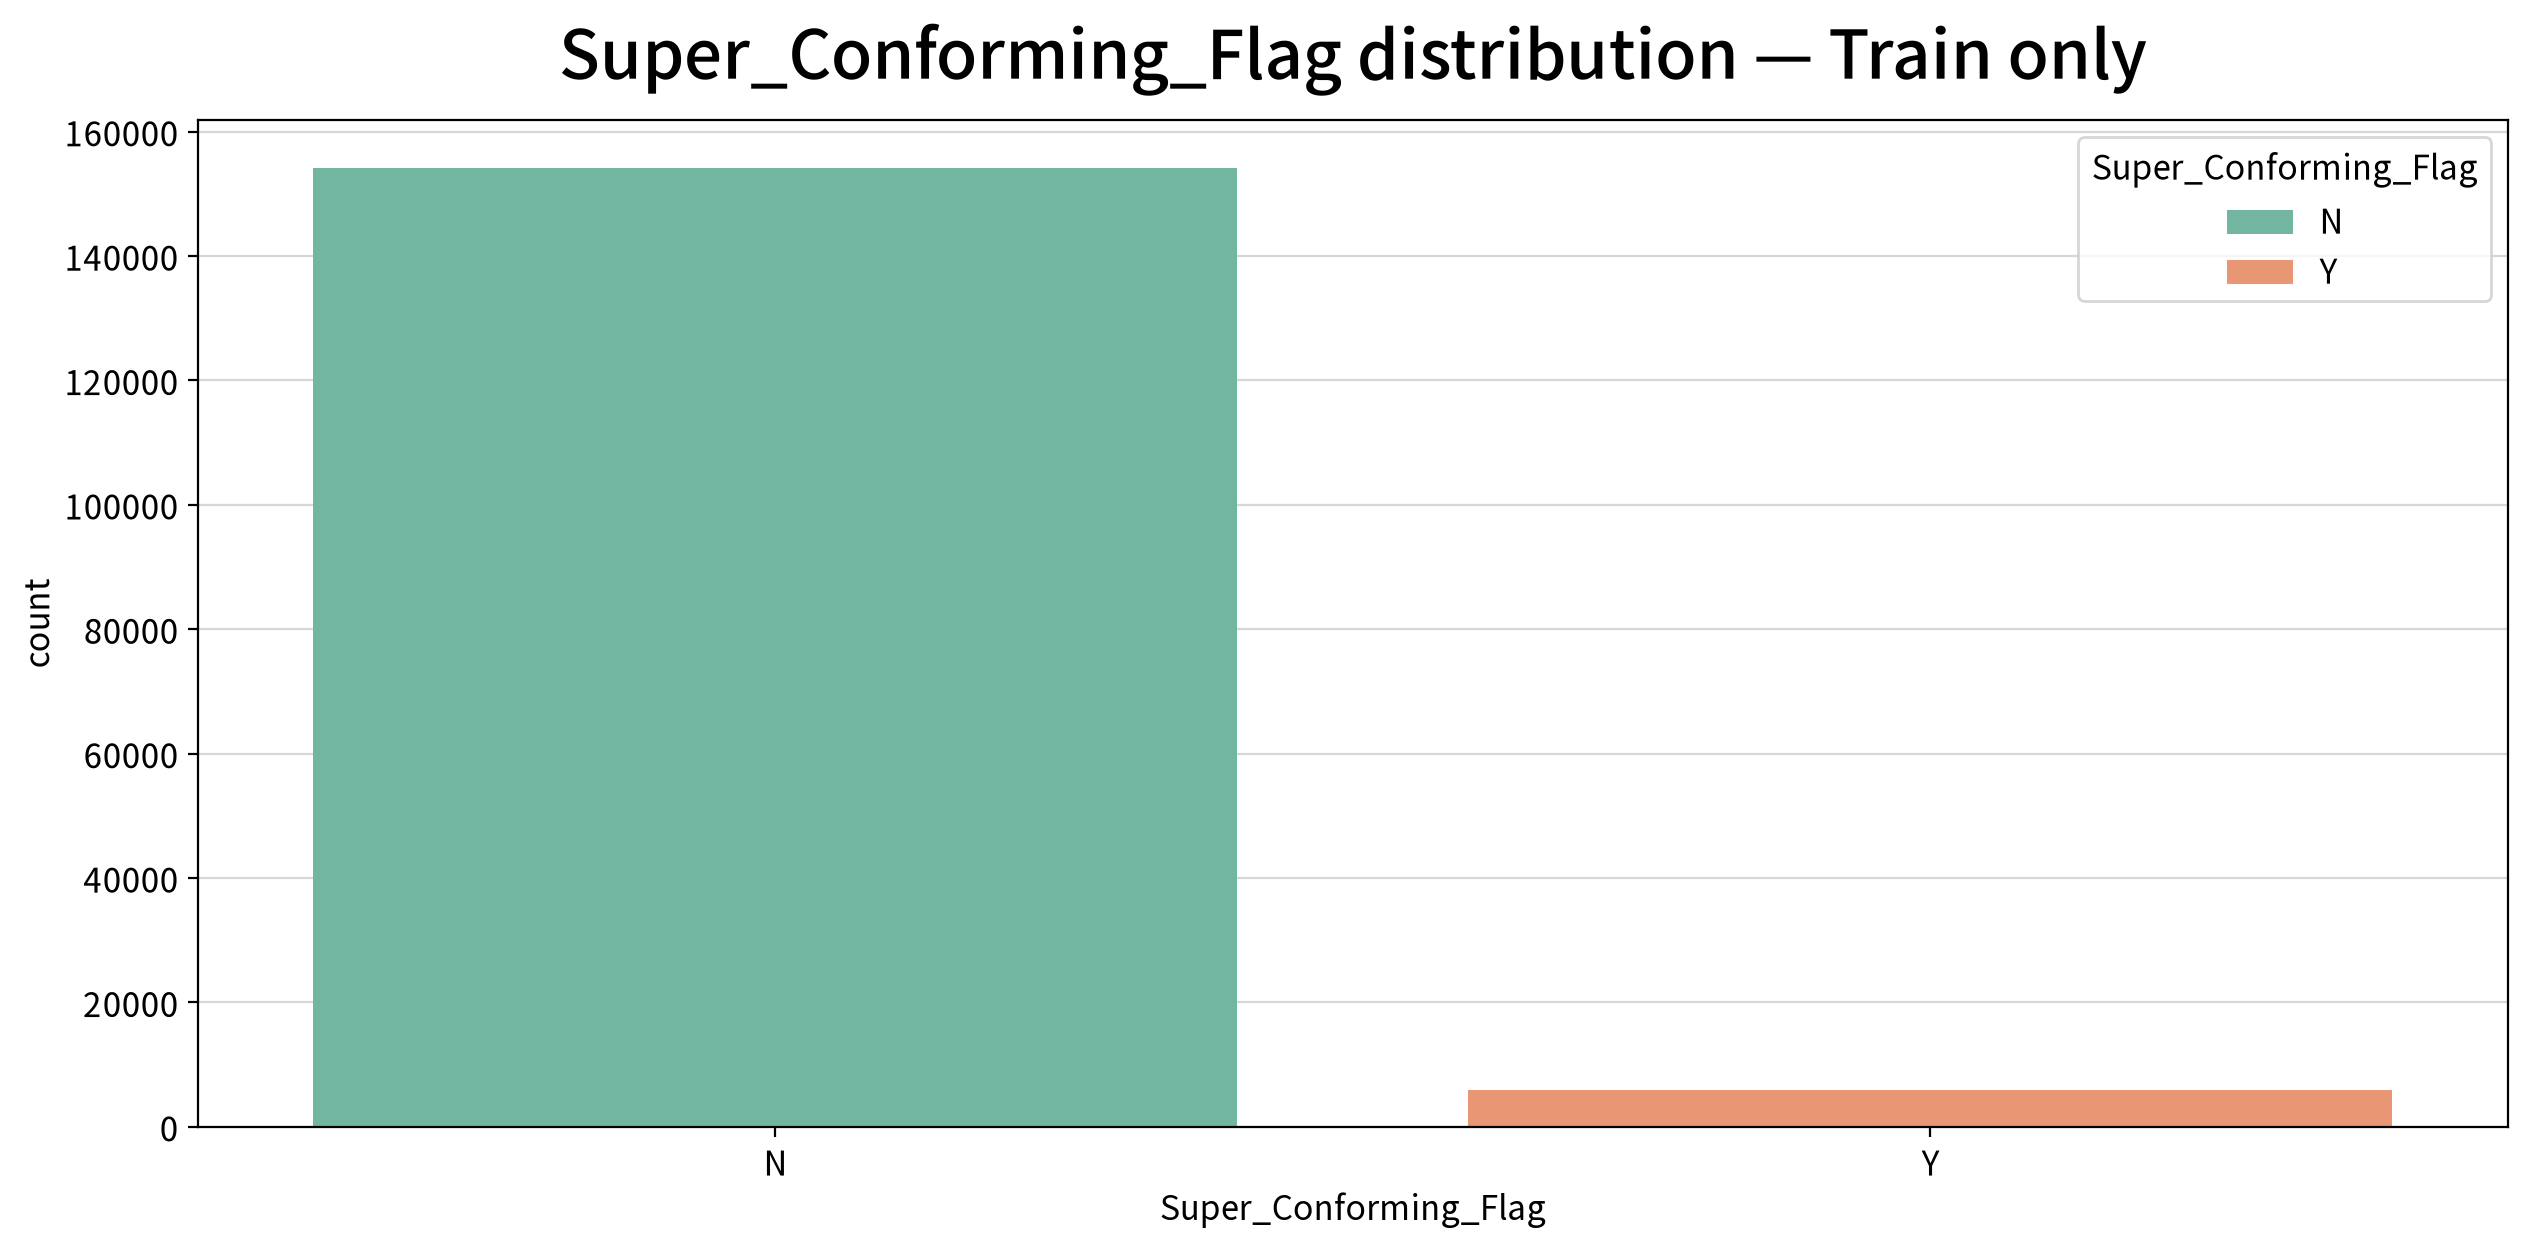

### HARP_Indicator — Train distribution

,N,Pct
HARP_Indicator,,
N,144010,90.004562
Y,15993,9.995438


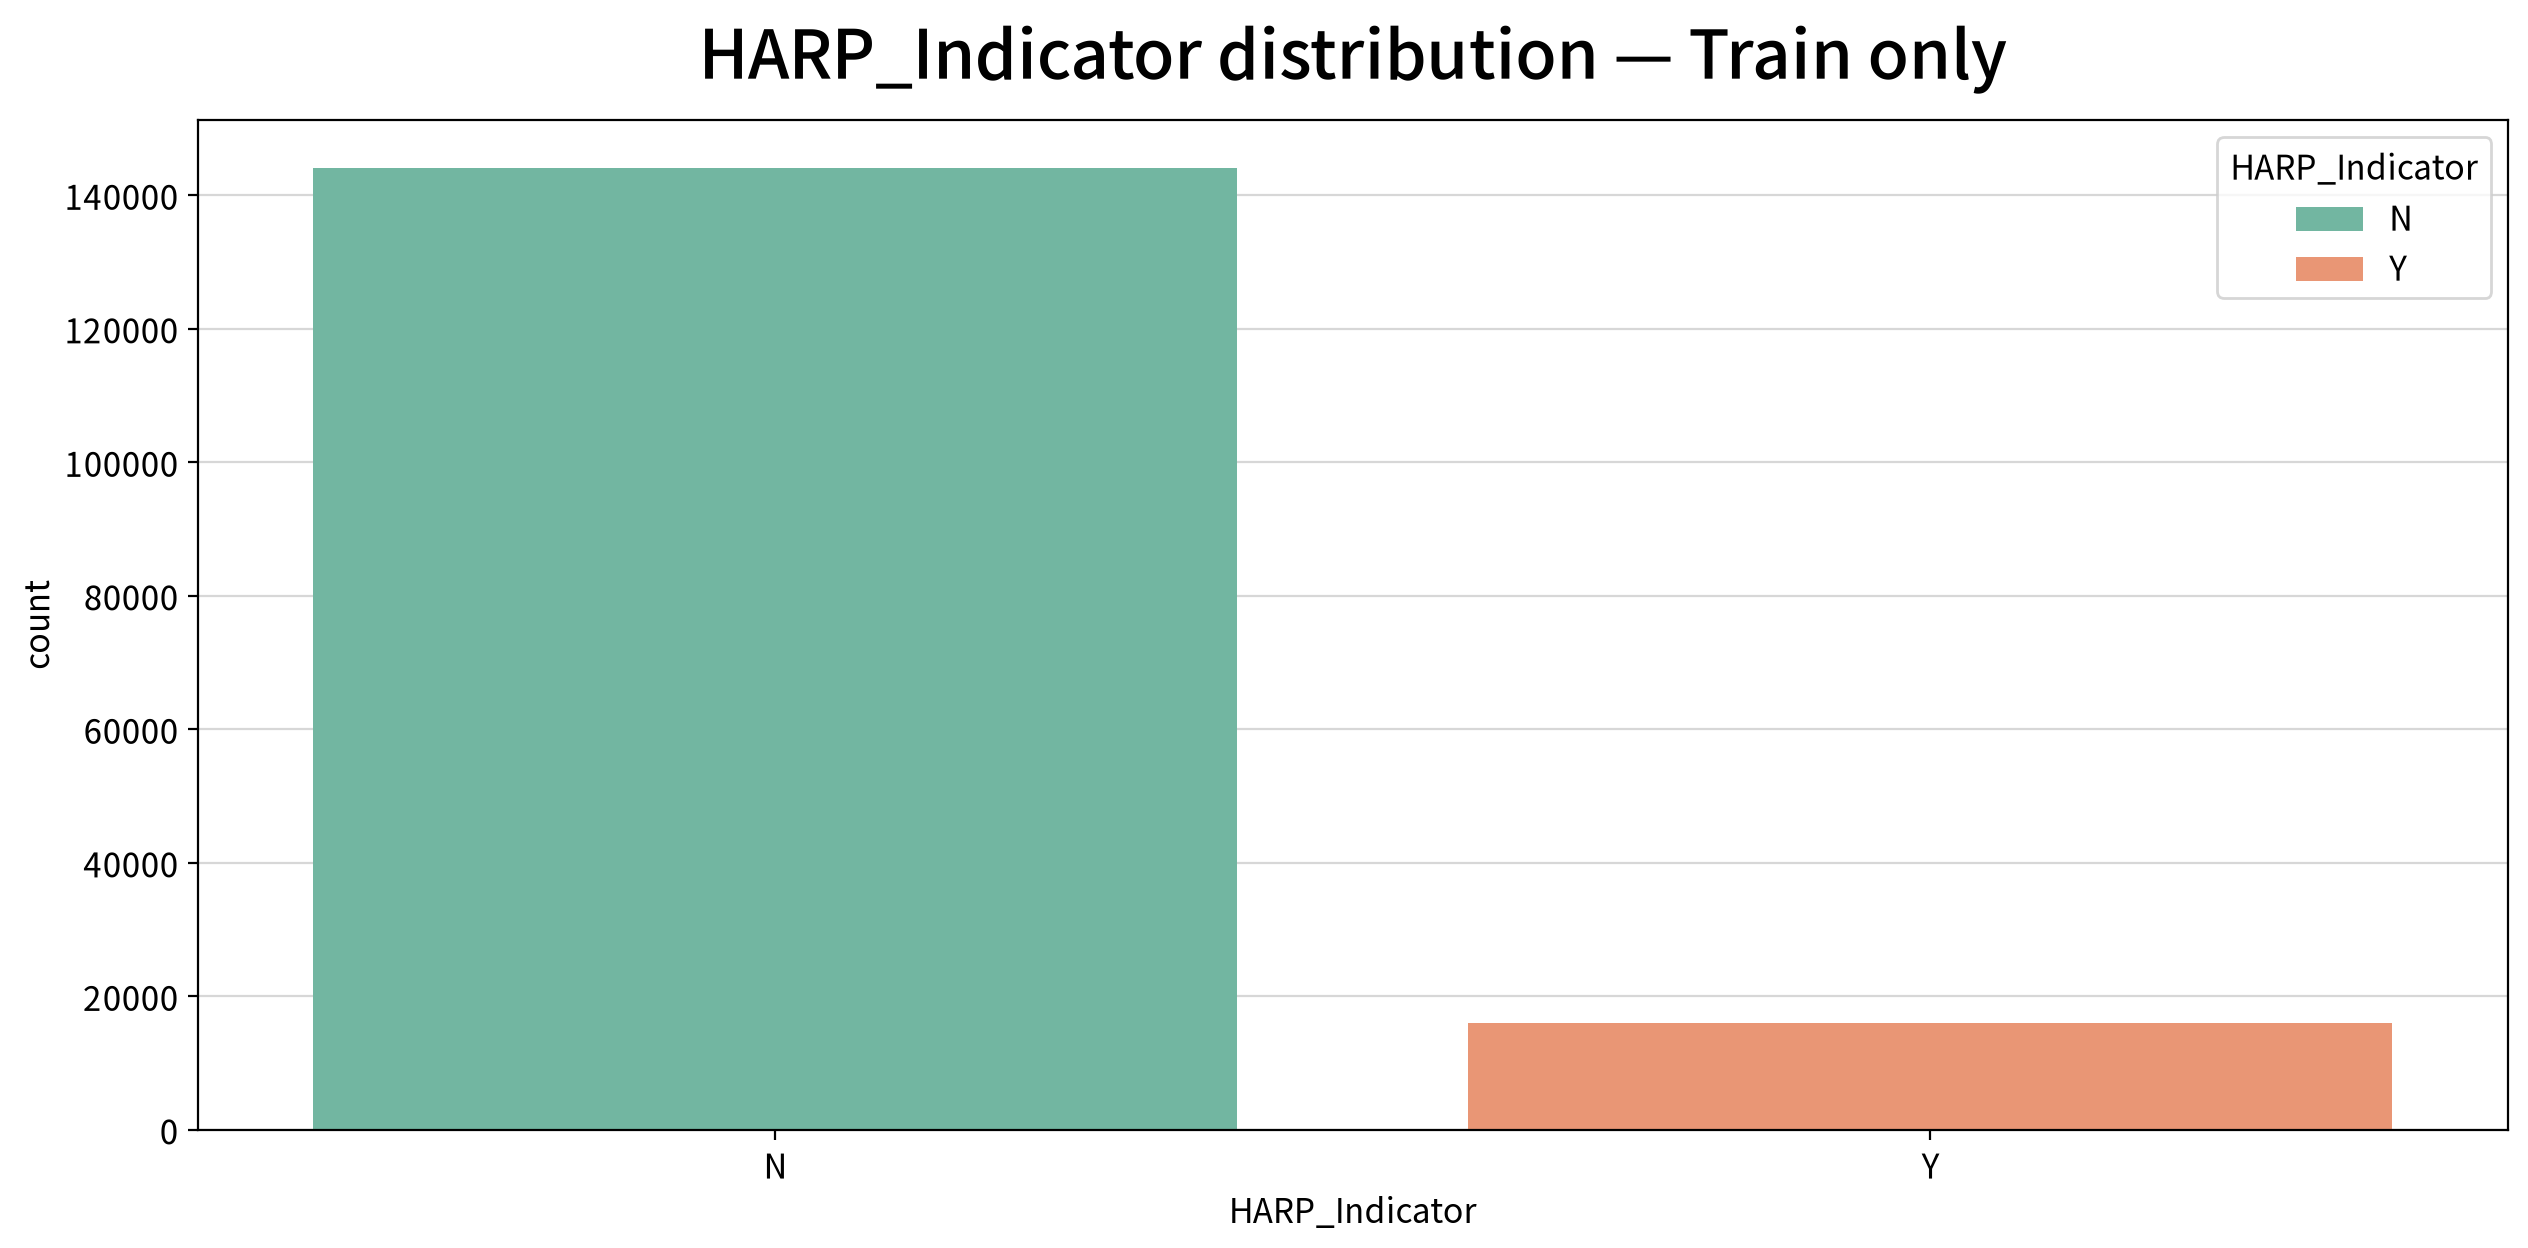

### DTI_Missing — Train distribution

,N,Pct
DTI_Missing,,
0,144002,89.999563
1,16001,10.000437


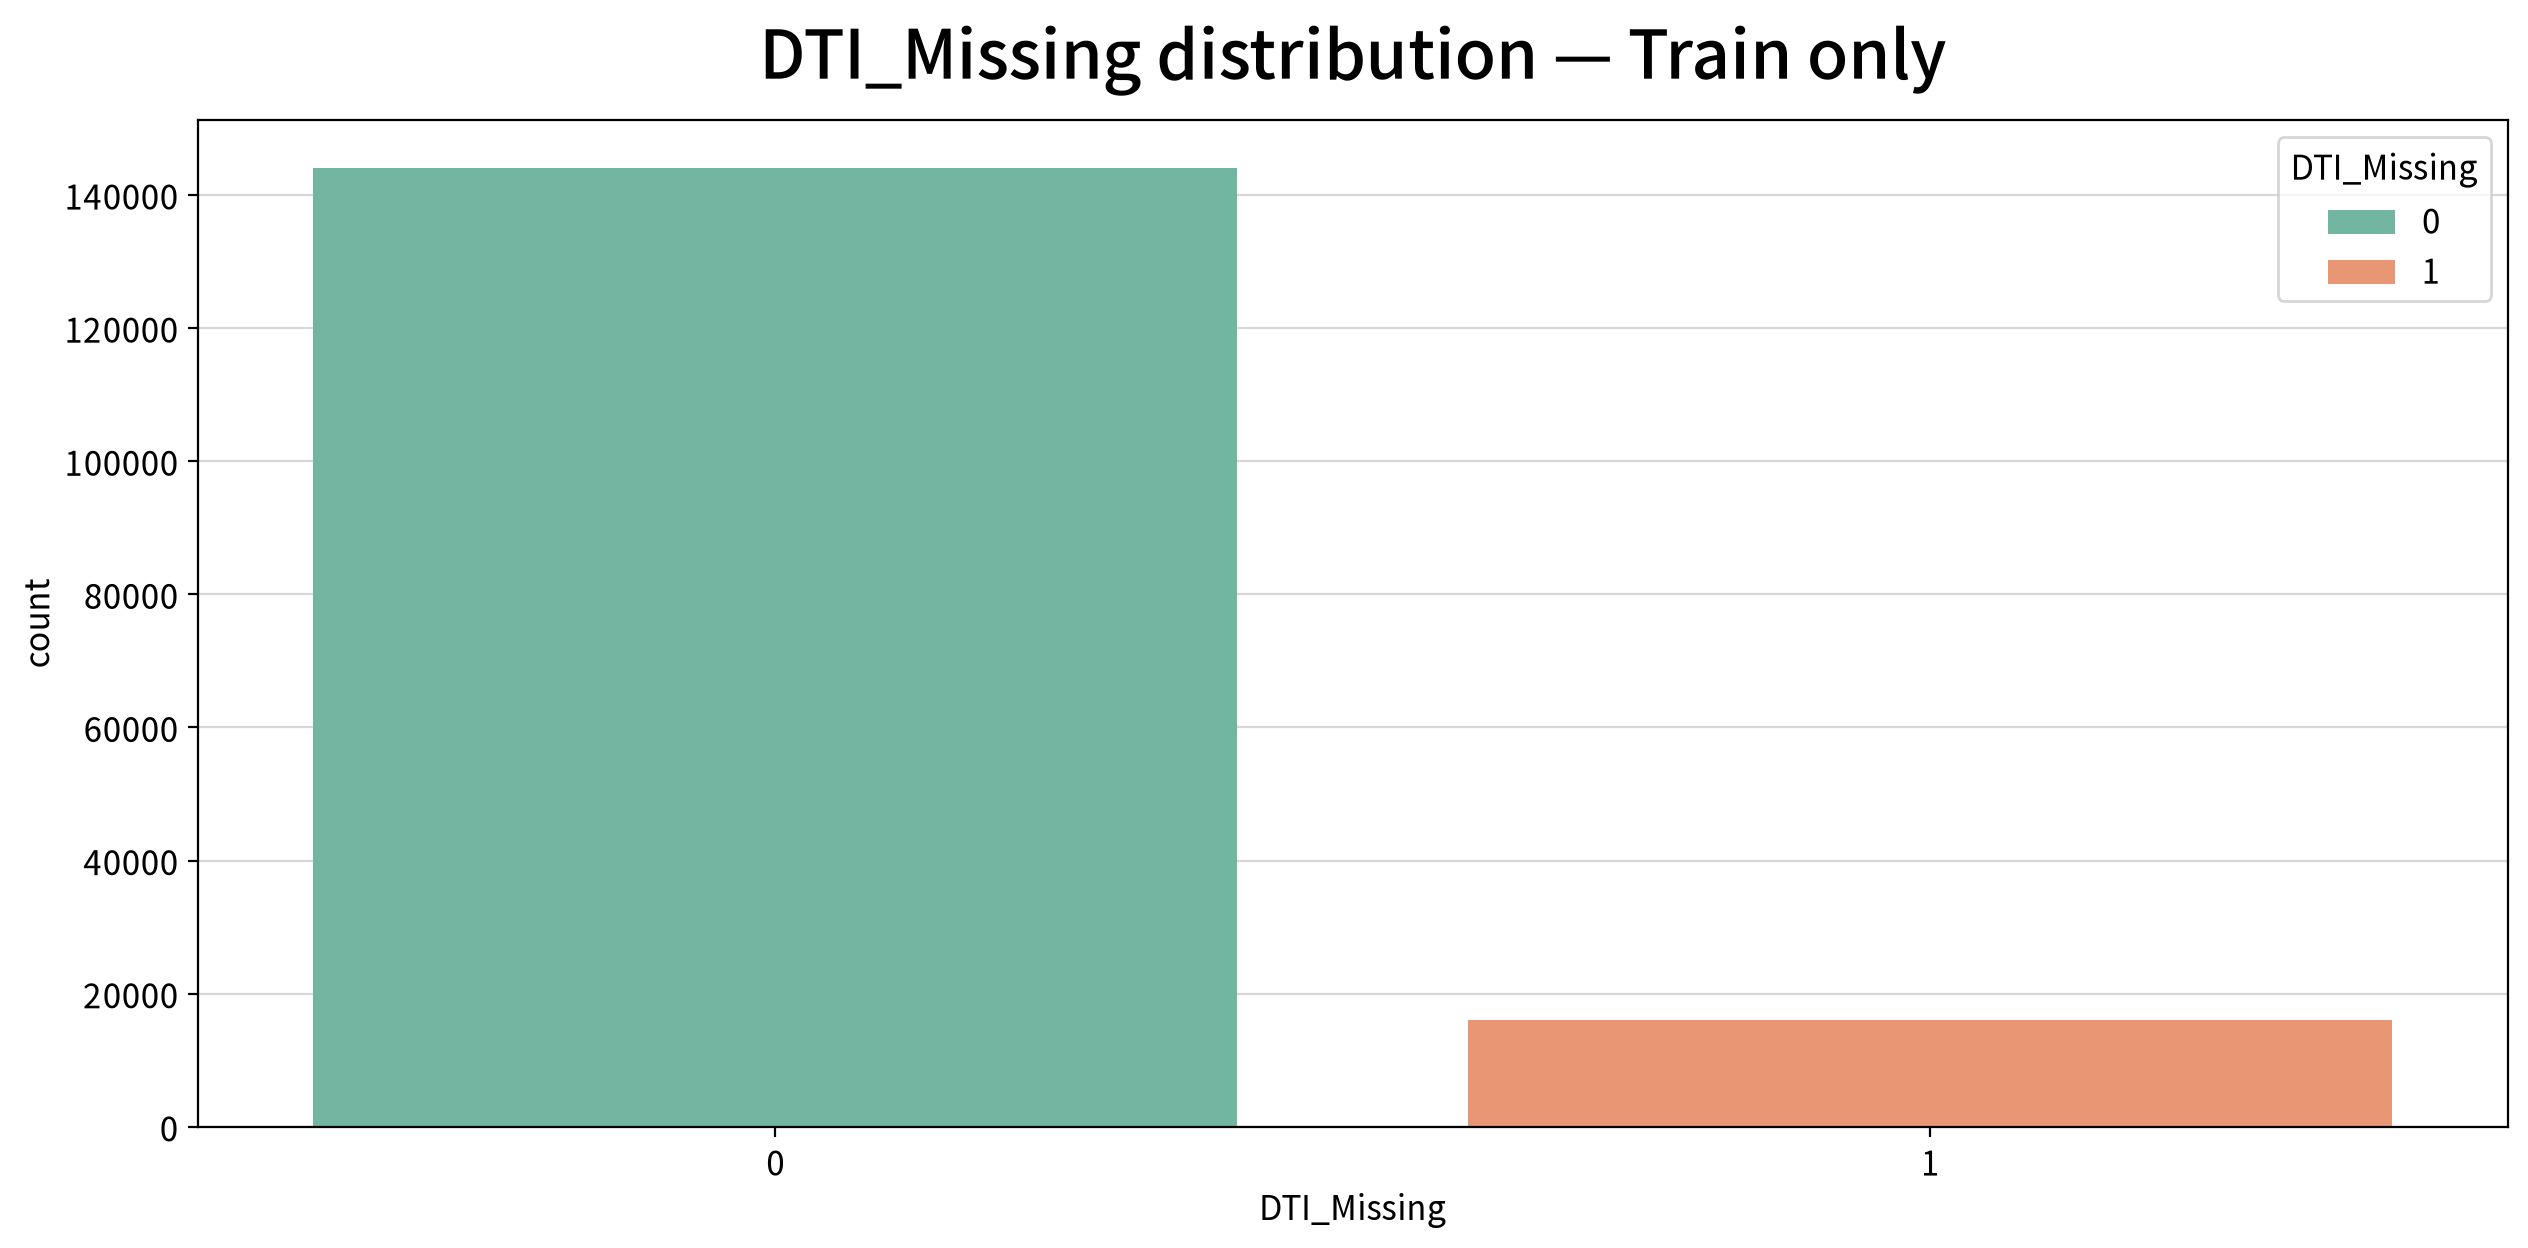

### FICO_Risk_Band — Train distribution

,N,Pct
FICO_Risk_Band,,
FICO_760plus,77675,48.545965
FICO_700_739,33813,21.132729
FICO_740_759,21025,13.140379
FICO_660_699,19659,12.286645
FICO_<660,7831,4.894283


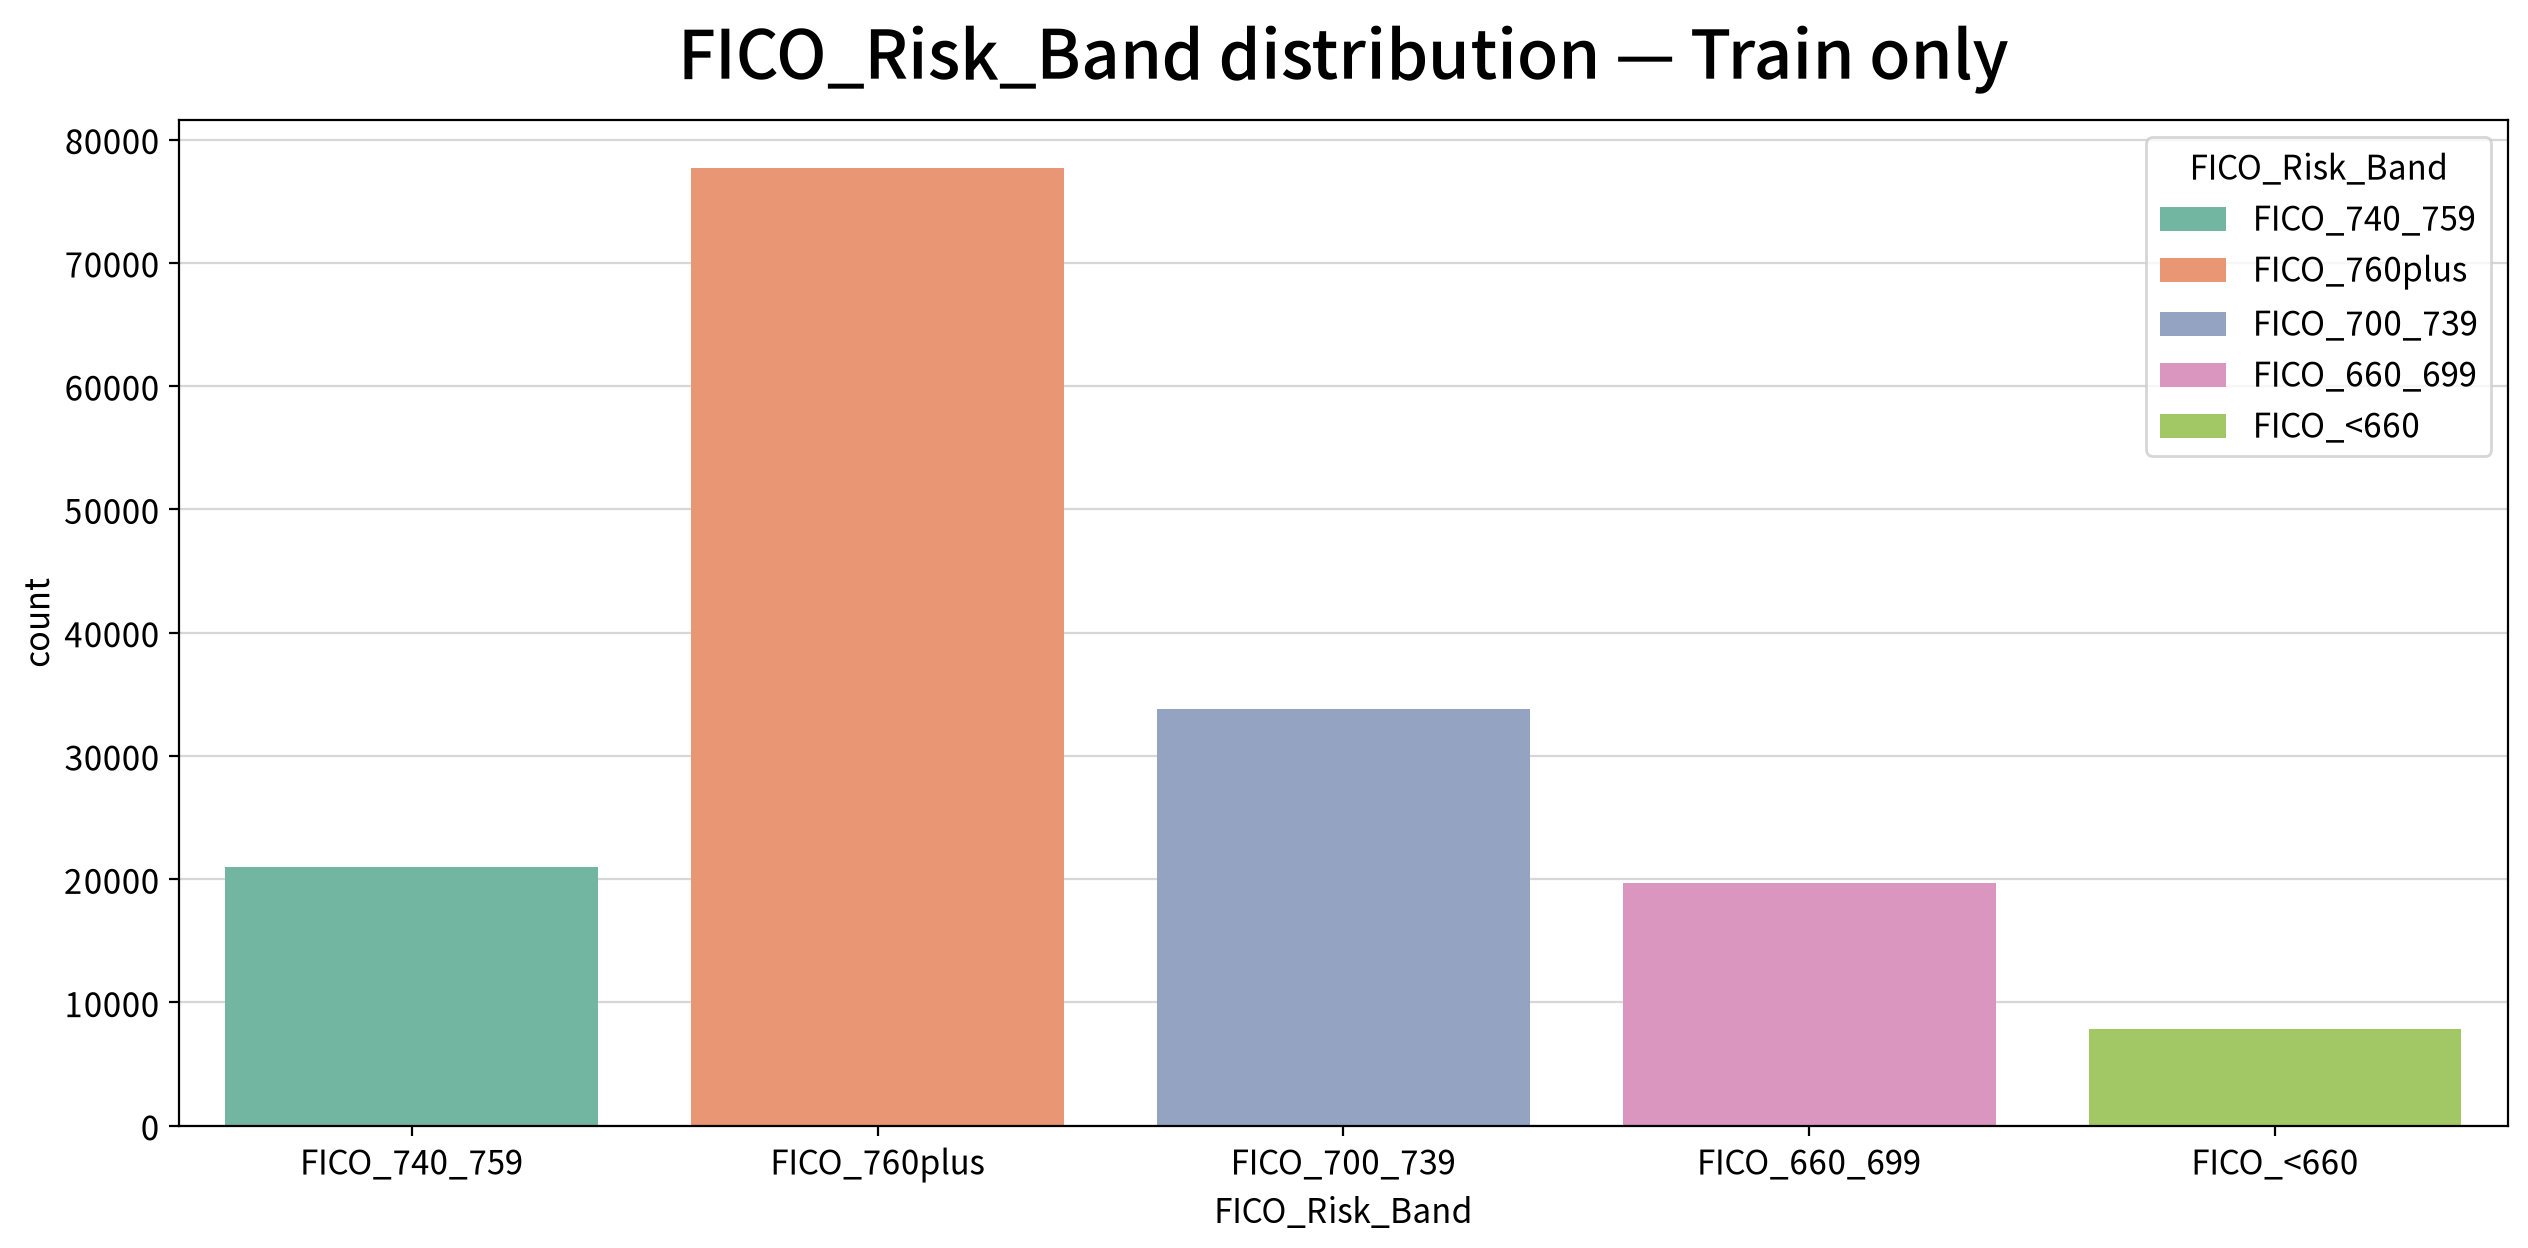

### DTI_Risk_Band — Train distribution

,N,Pct
DTI_Risk_Band,,
DTI_40plus,48430,30.268182
DTI_25_34,43382,27.113242
DTI_35_39,26351,16.469066
DTI_<25,25839,16.149072
DTI_Missing,16001,10.000437


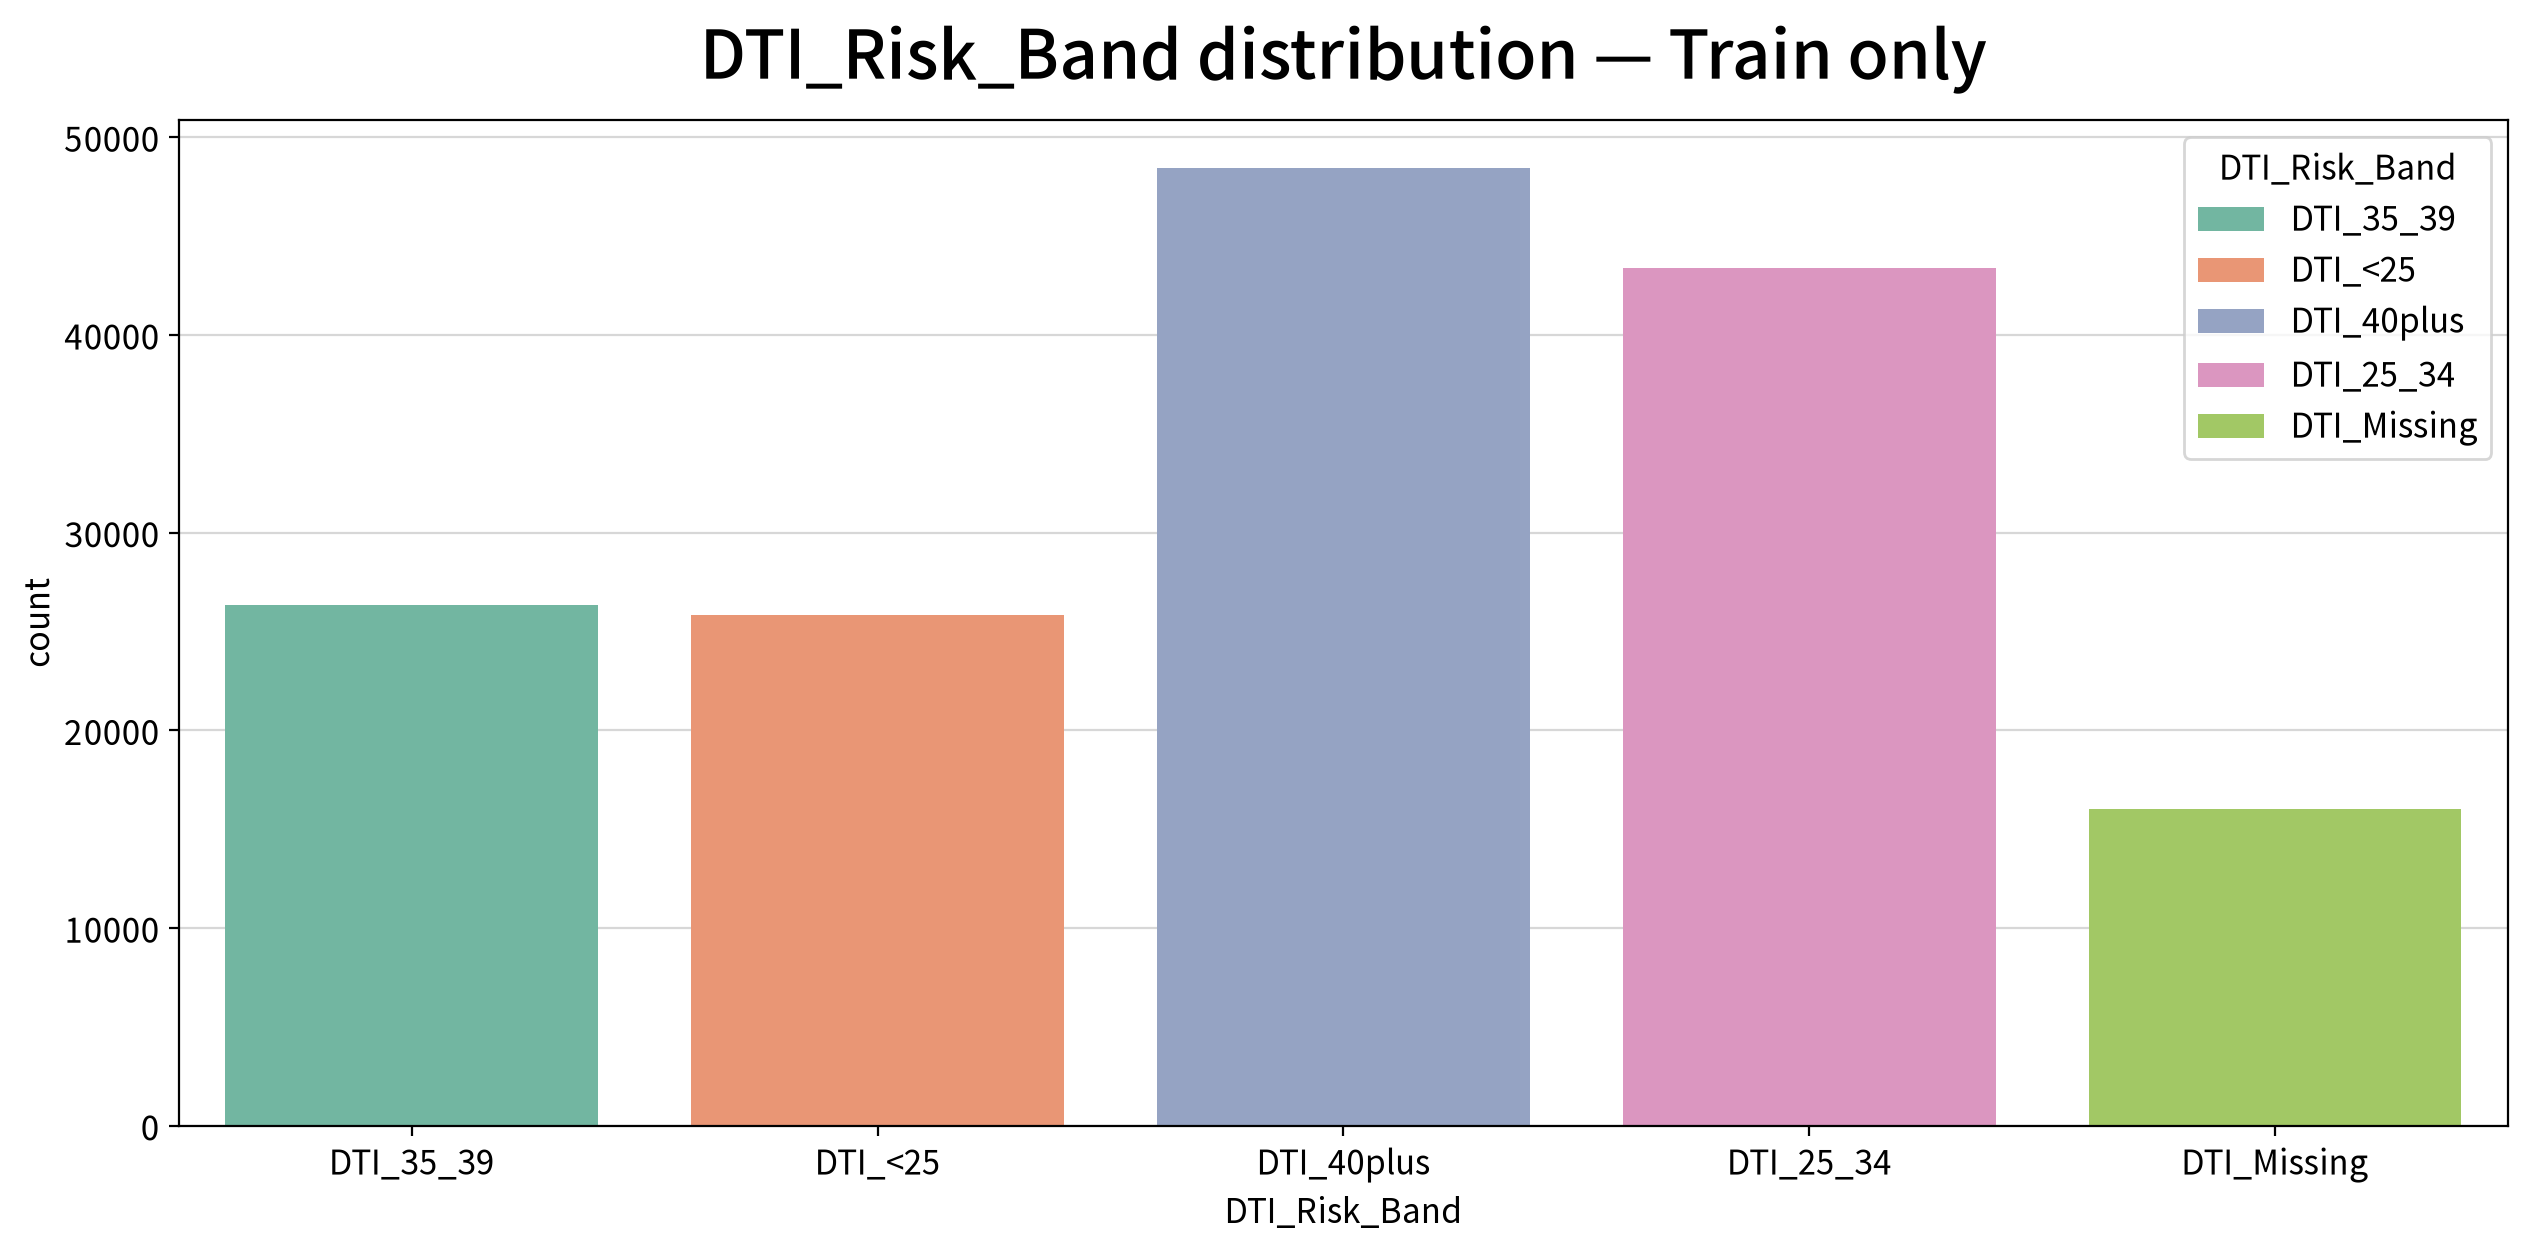

### LTV_Risk_Component — Train distribution

,N,Pct
LTV_Risk_Component,,
LTV_<80,82317,51.447160
LTV_80_89,43670,27.293238
LTV_95_99,19768,12.354768
LTV_90_94,11721,7.325488
LTV_100plus,2527,1.579345


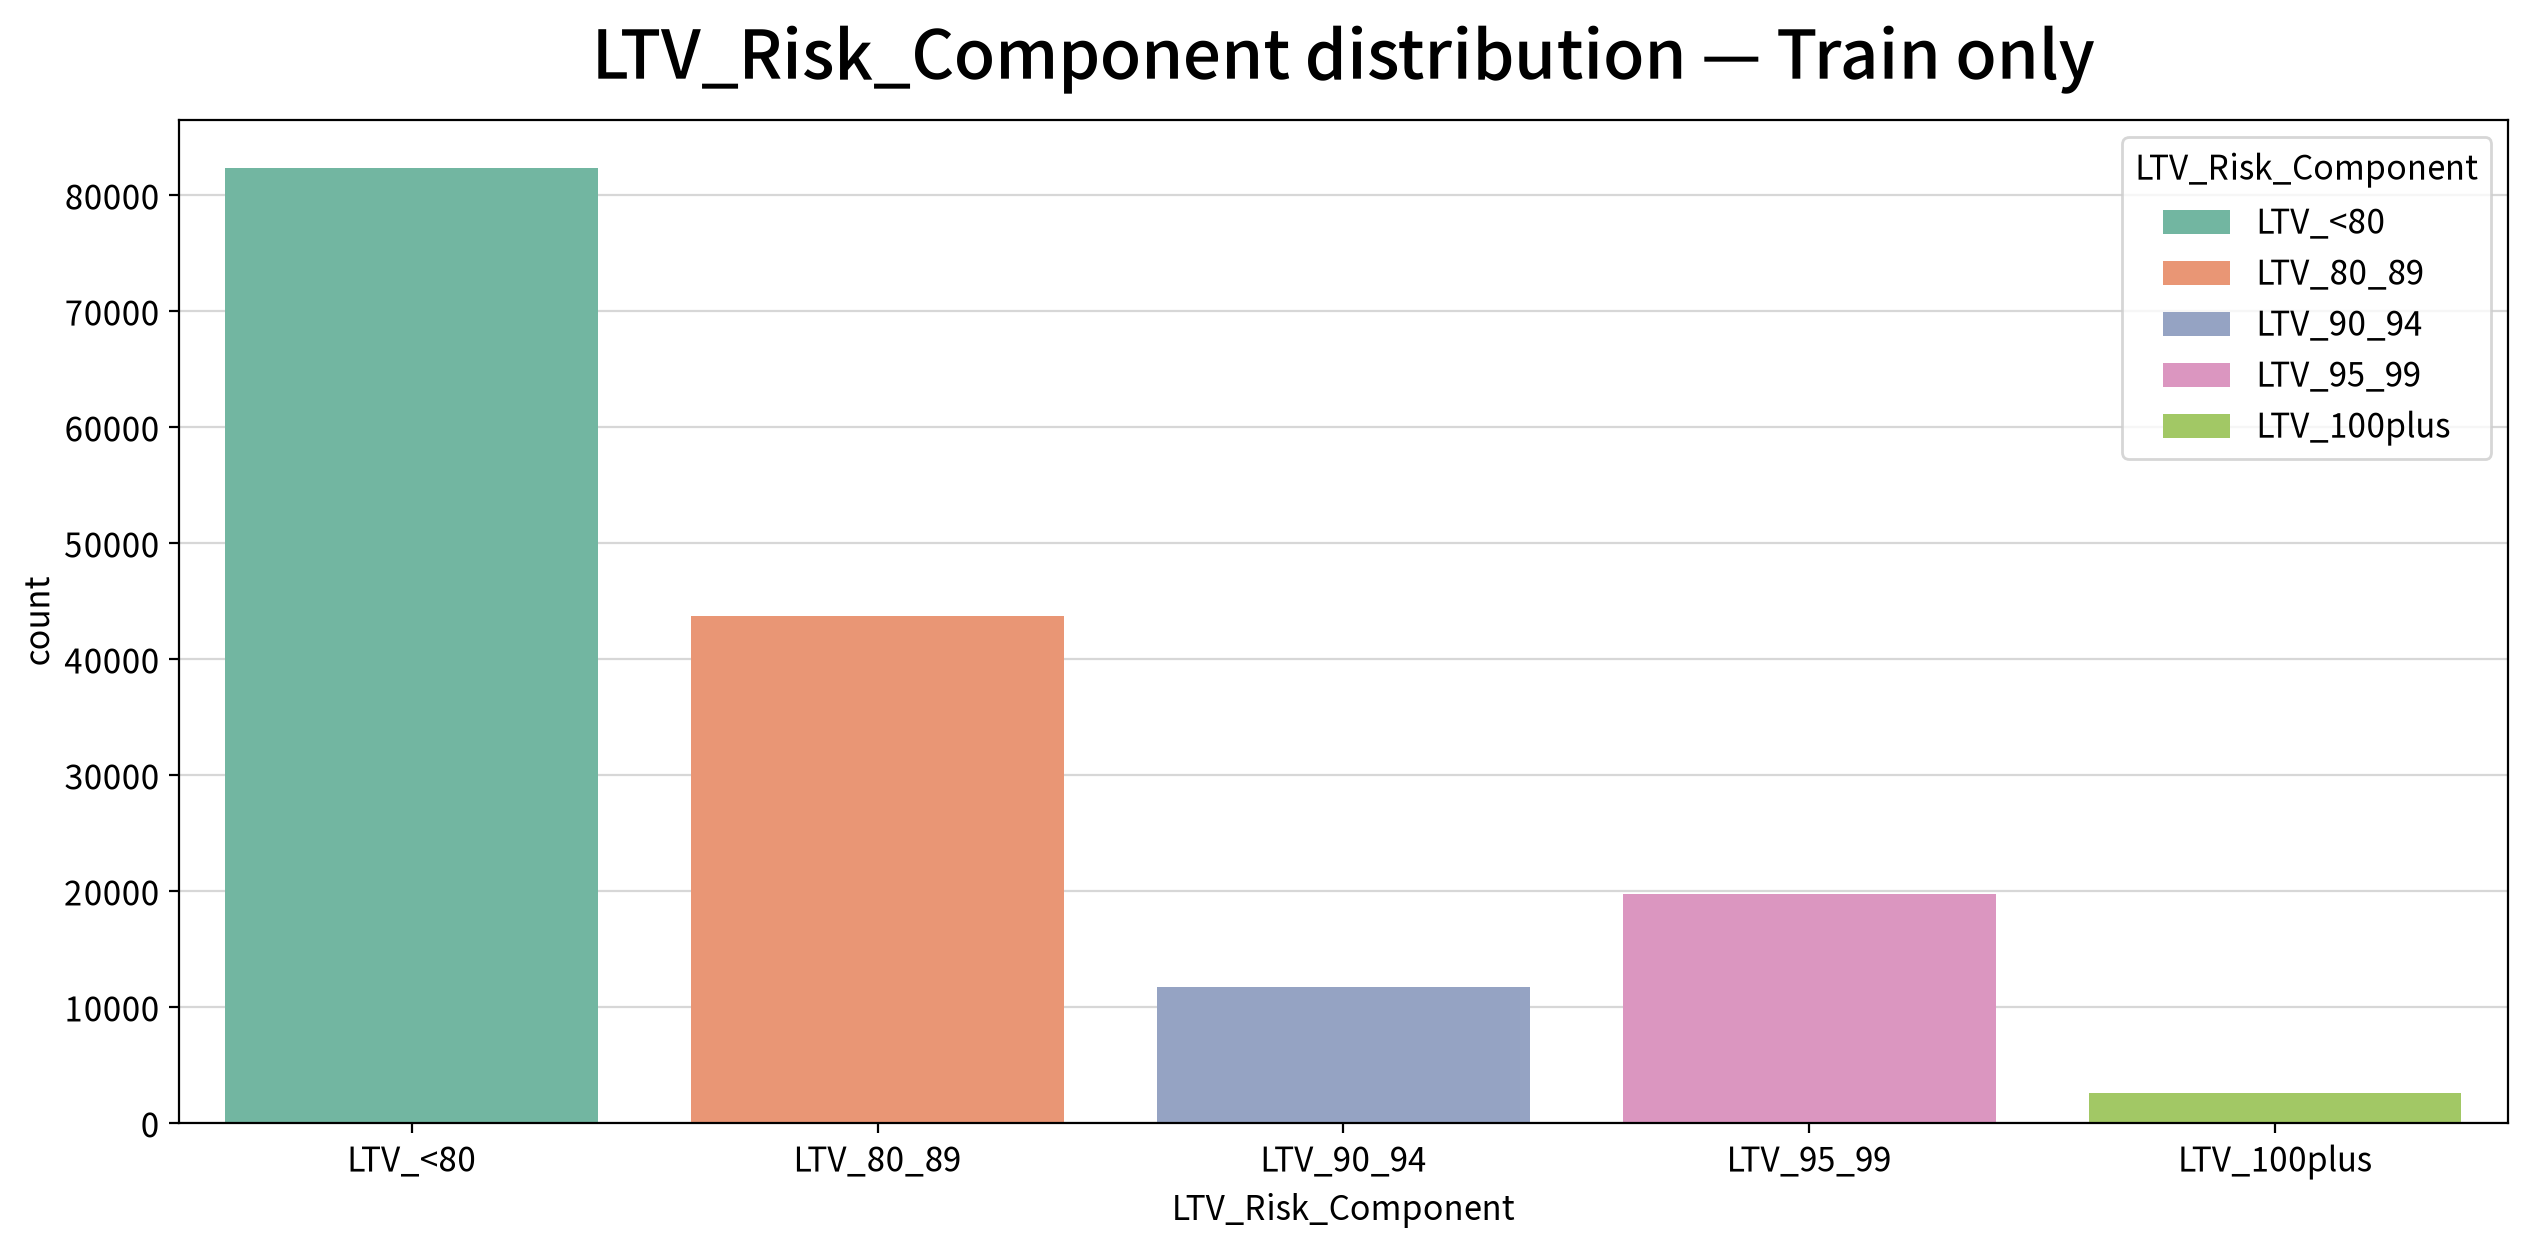

### CLTV_Risk_Component — Train distribution

,N,Pct
CLTV_Risk_Component,,
CLTV_<80,79015,49.383449
CLTV_80_89,43950,27.468235
CLTV_95_99,20270,12.668512
CLTV_90_94,13251,8.281720
CLTV_100plus,3517,2.198084


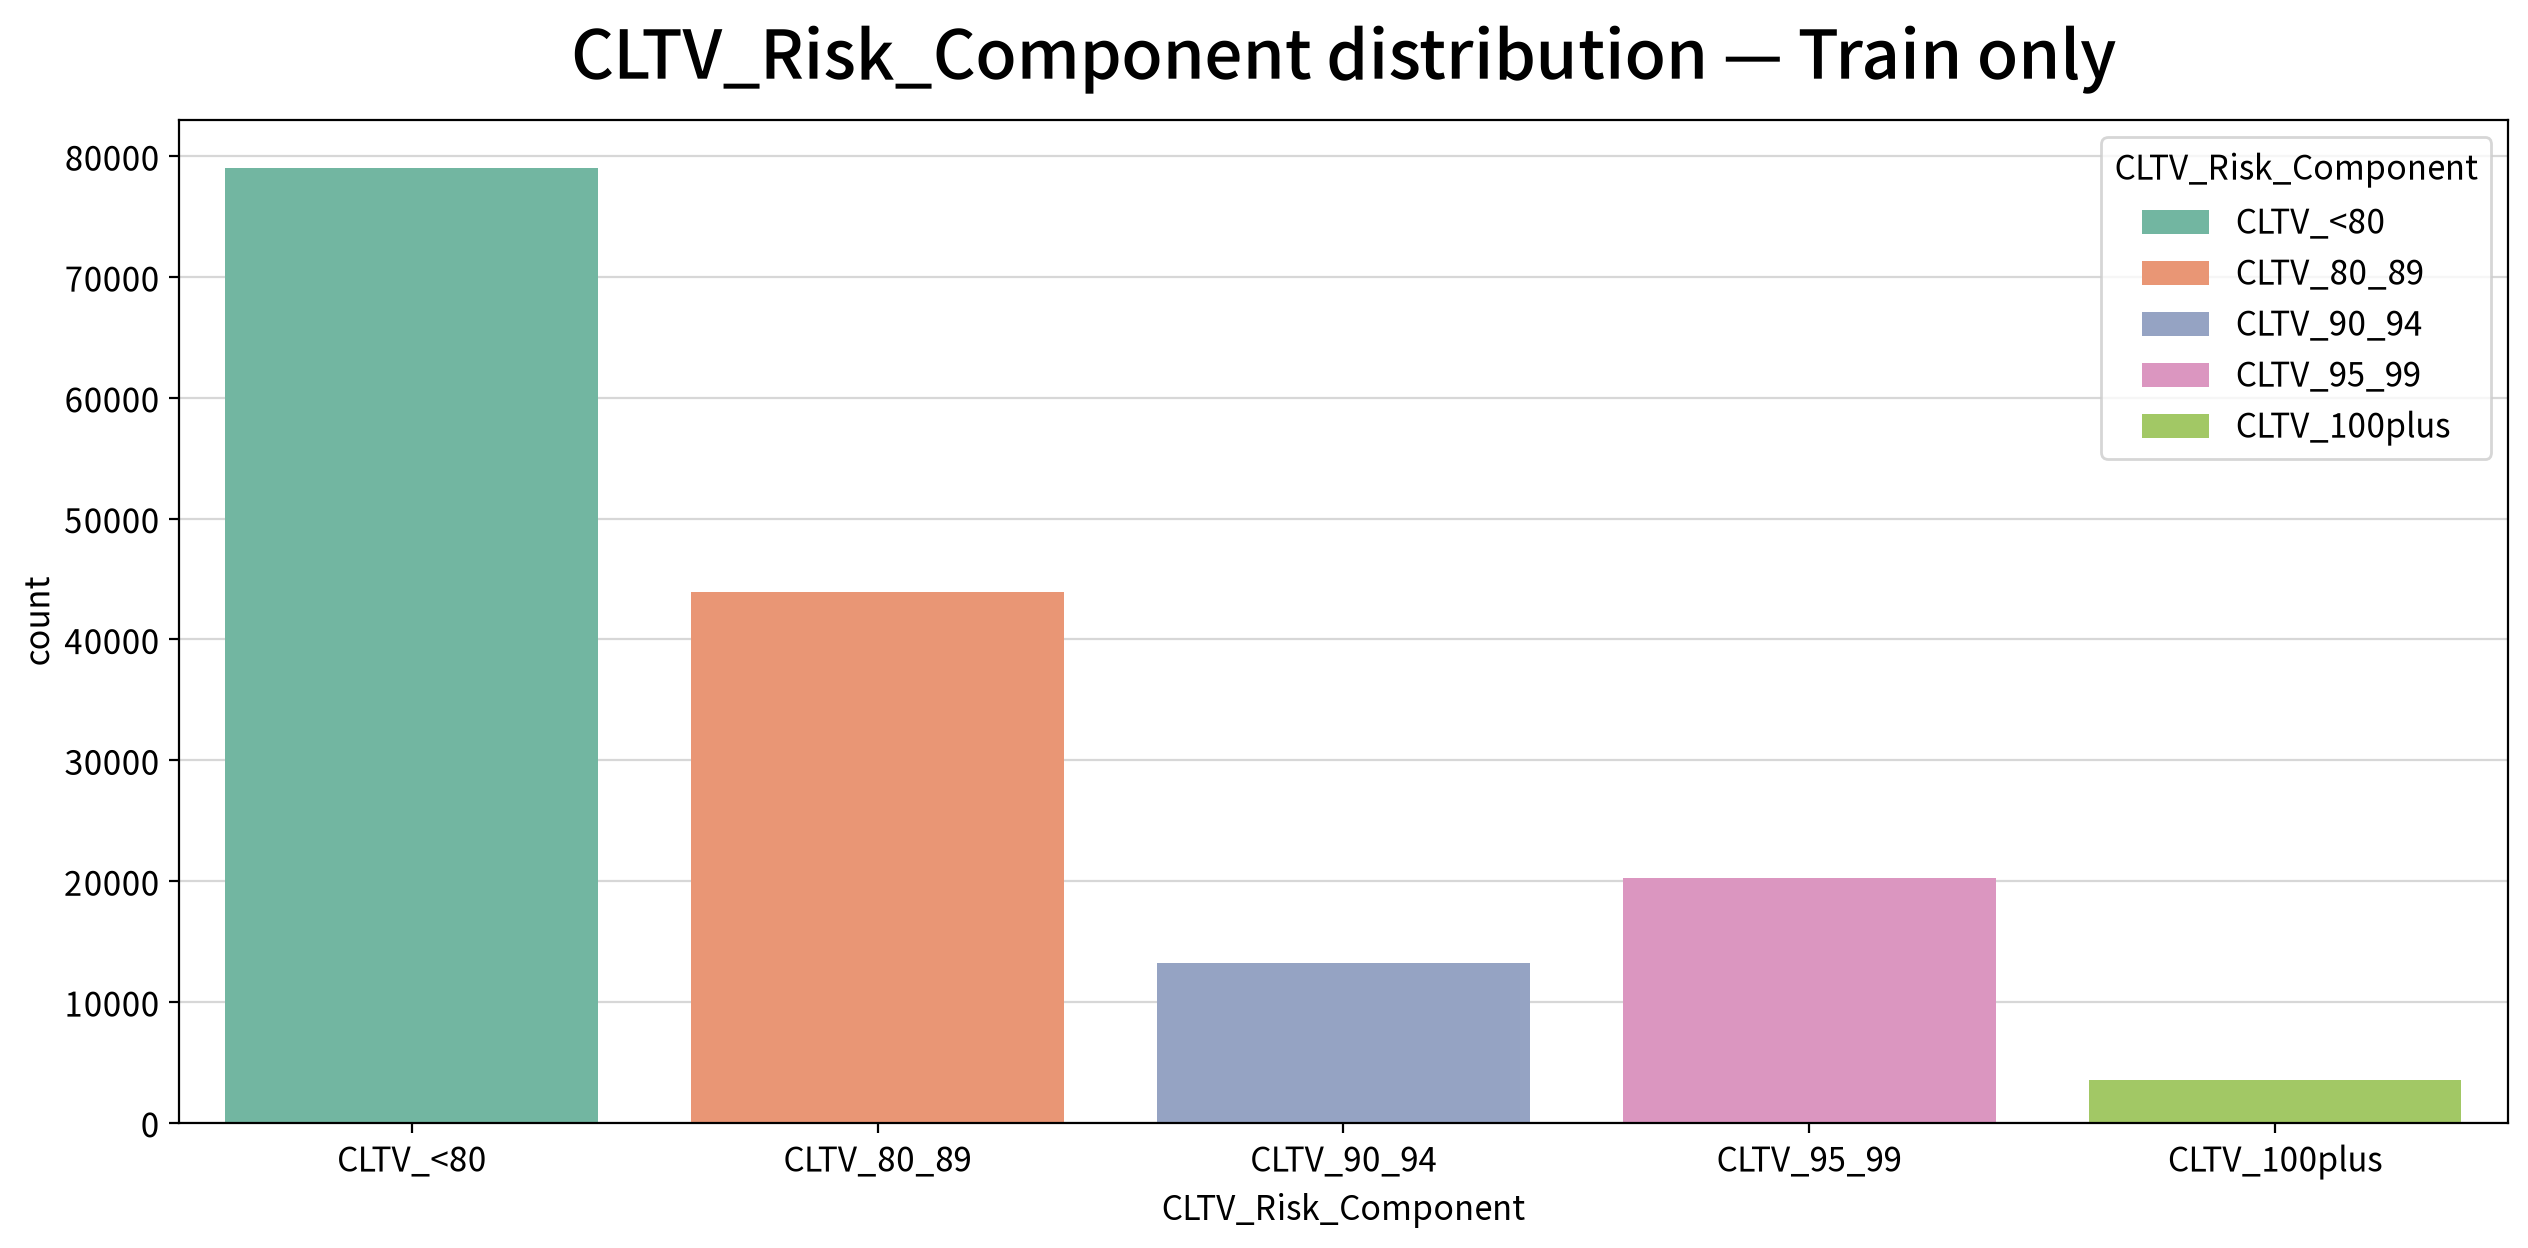

### High_Leverage — Train distribution

,N,Pct
High_Leverage,,
0,156486,97.801916
1,3517,2.198084


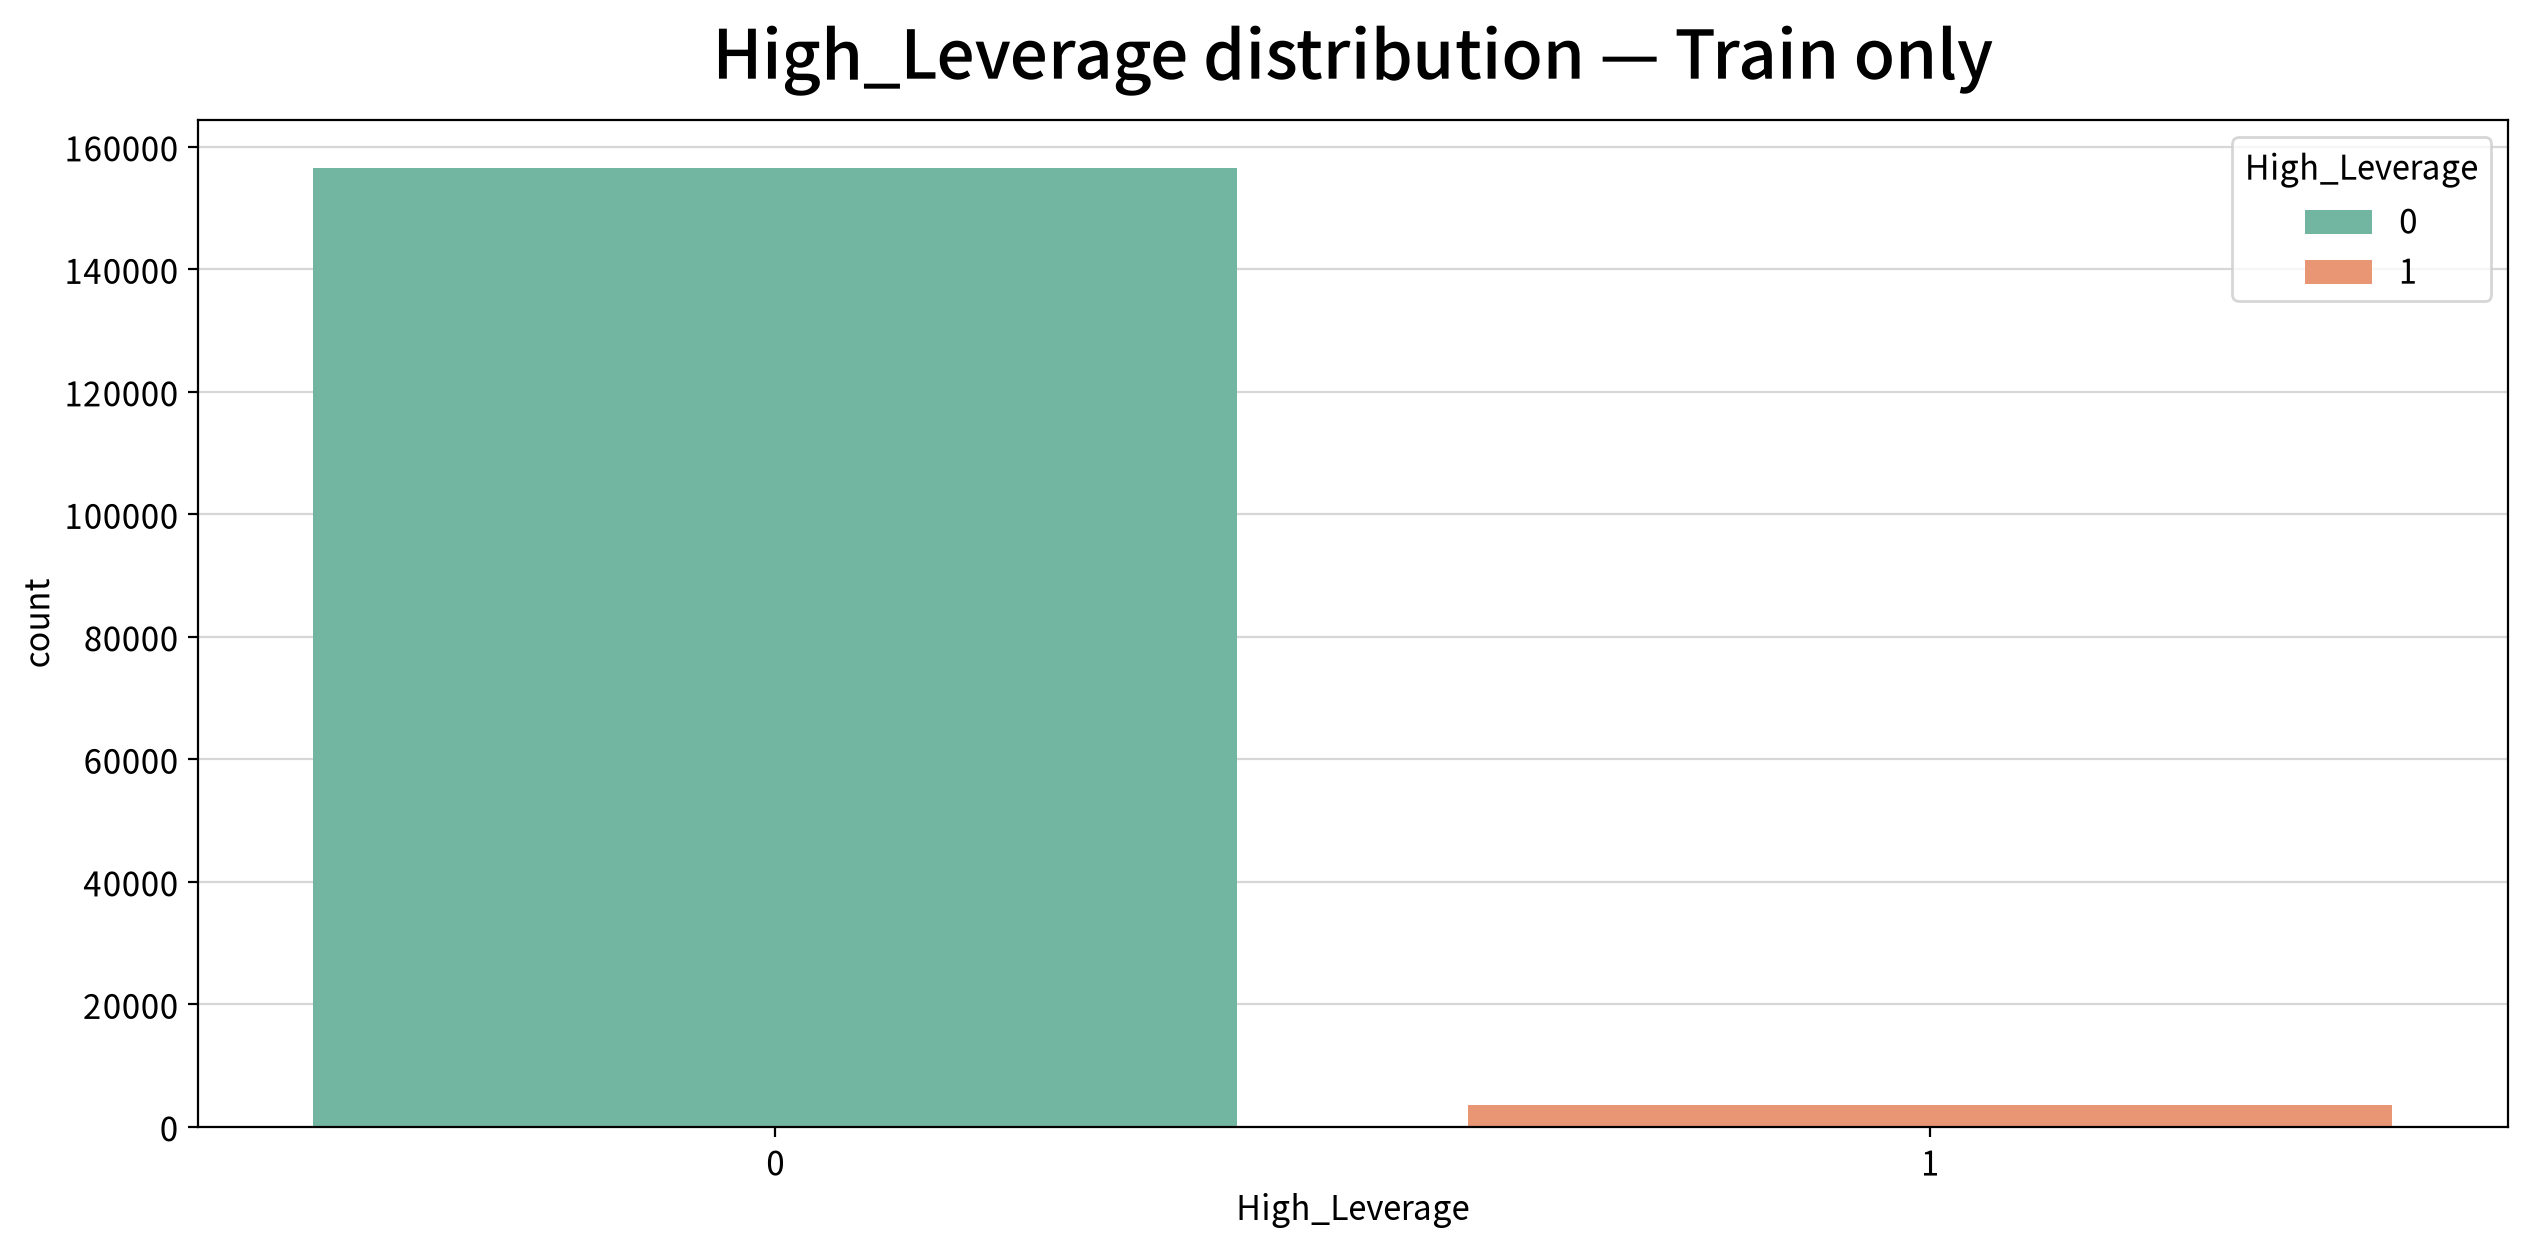

### HARP_High_Leverage — Train distribution

,N,Pct
HARP_High_Leverage,,
0,156512,97.818166
1,3491,2.181834


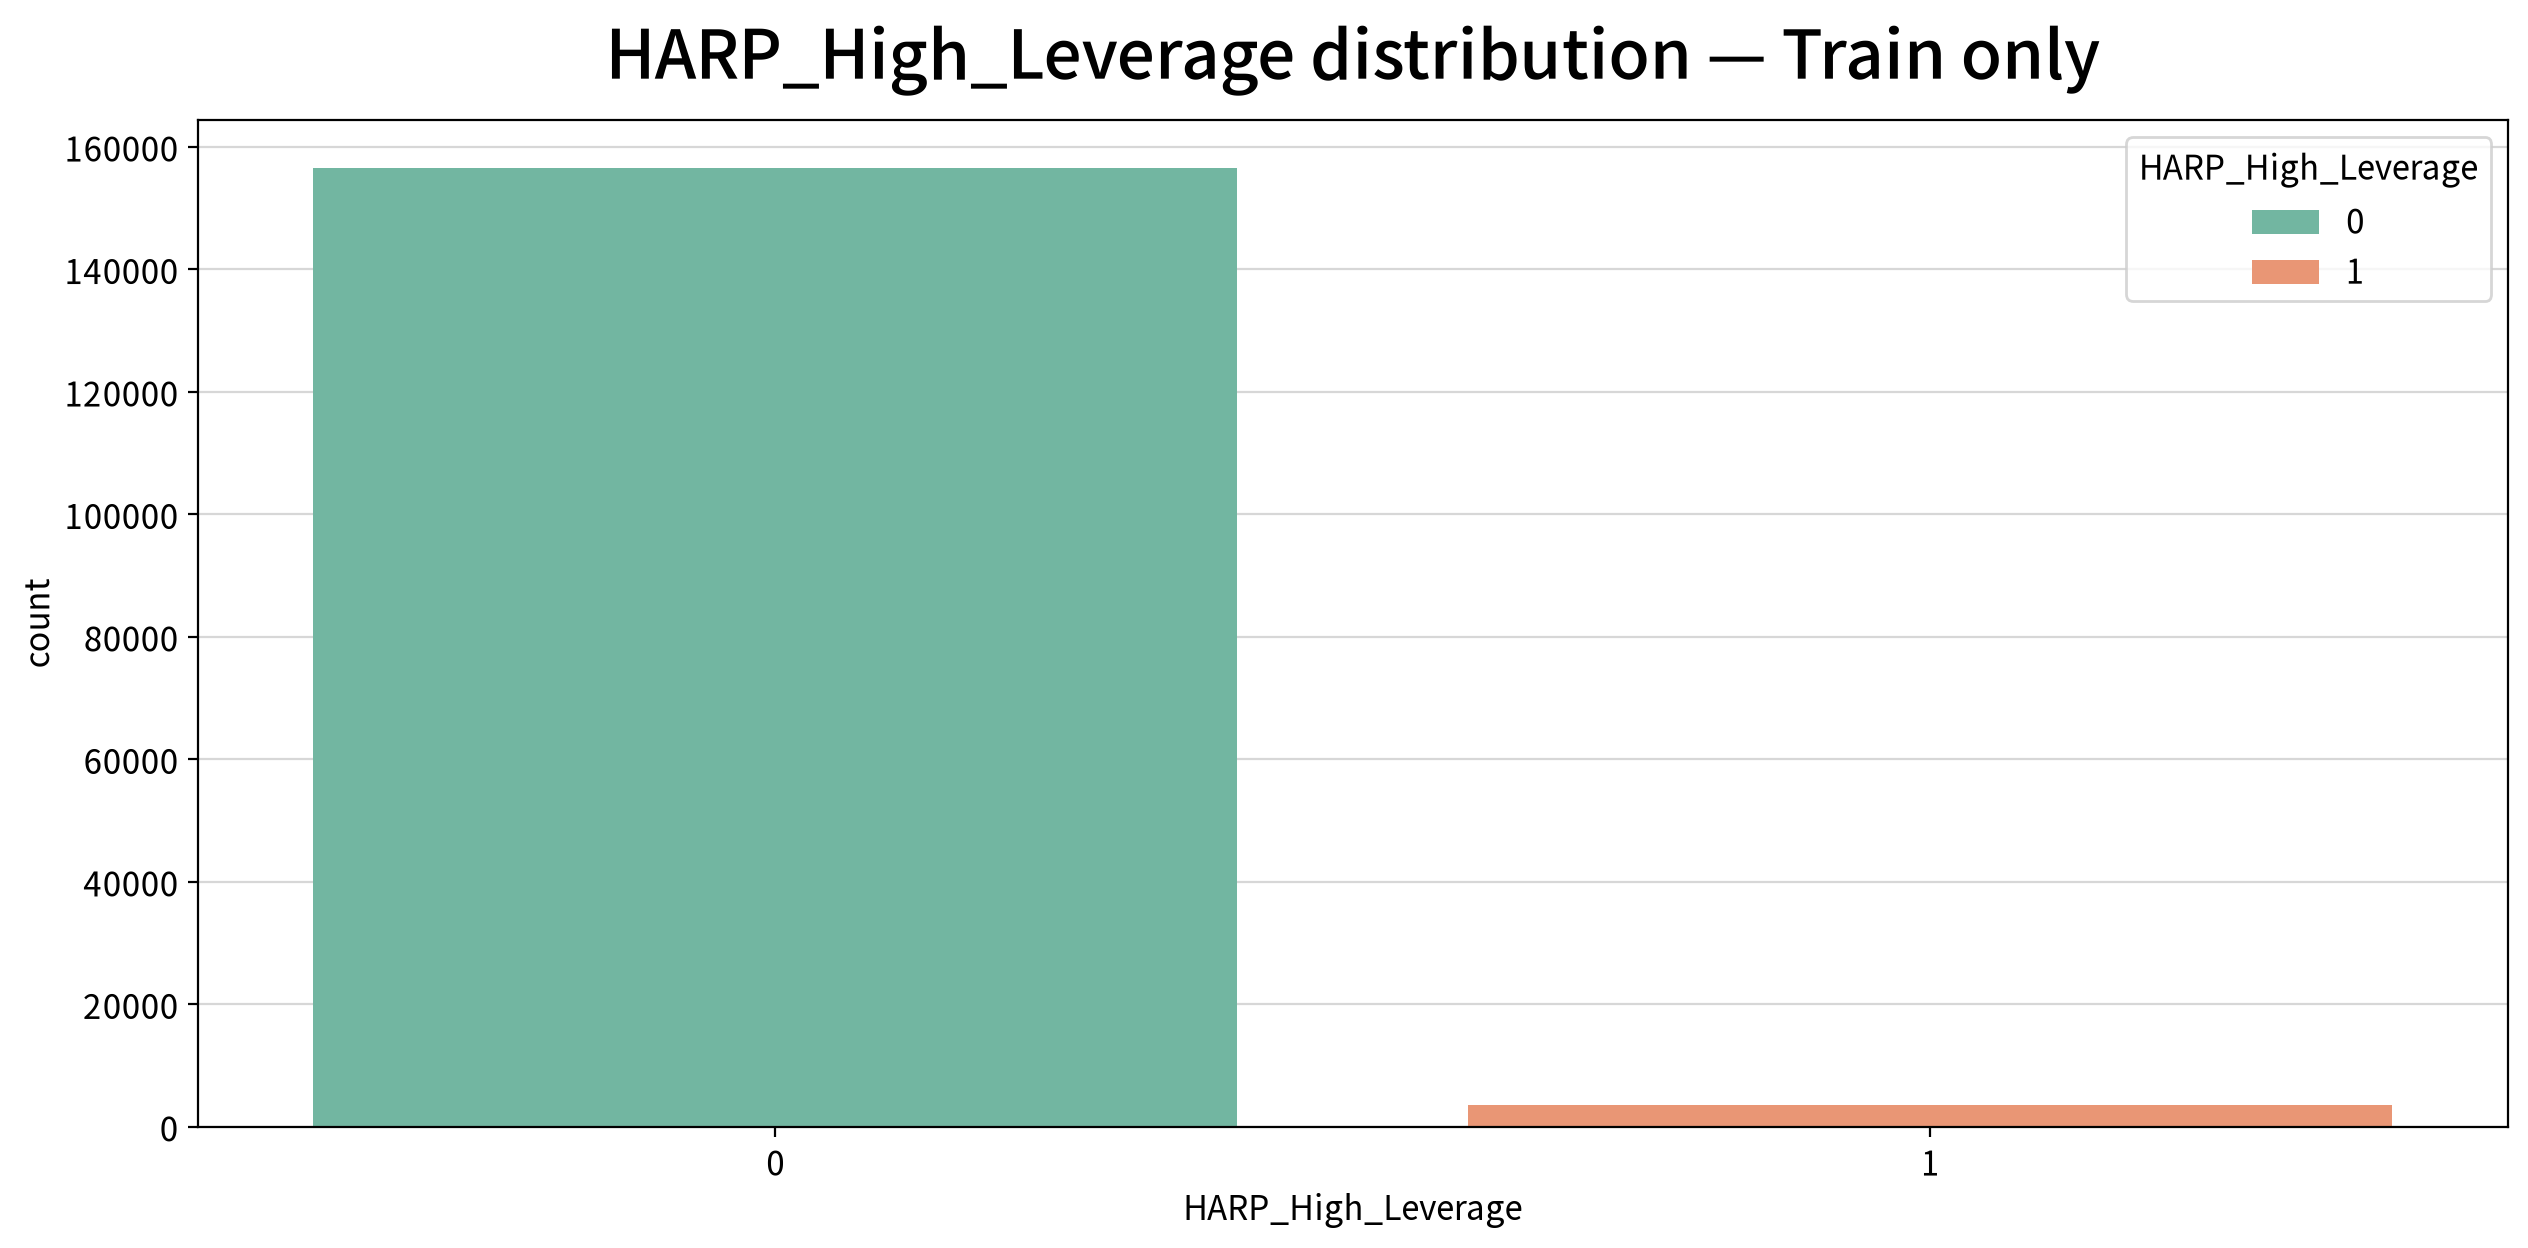

### Spatial_Cluster — Train distribution

,N,Pct
Spatial_Cluster,,
4,35684,22.302082
1,32023,20.014
0,30311,18.94402
3,25911,16.194071
7,15983,9.989188
5,9728,6.079886
2,9711,6.069261
6,652,0.407492


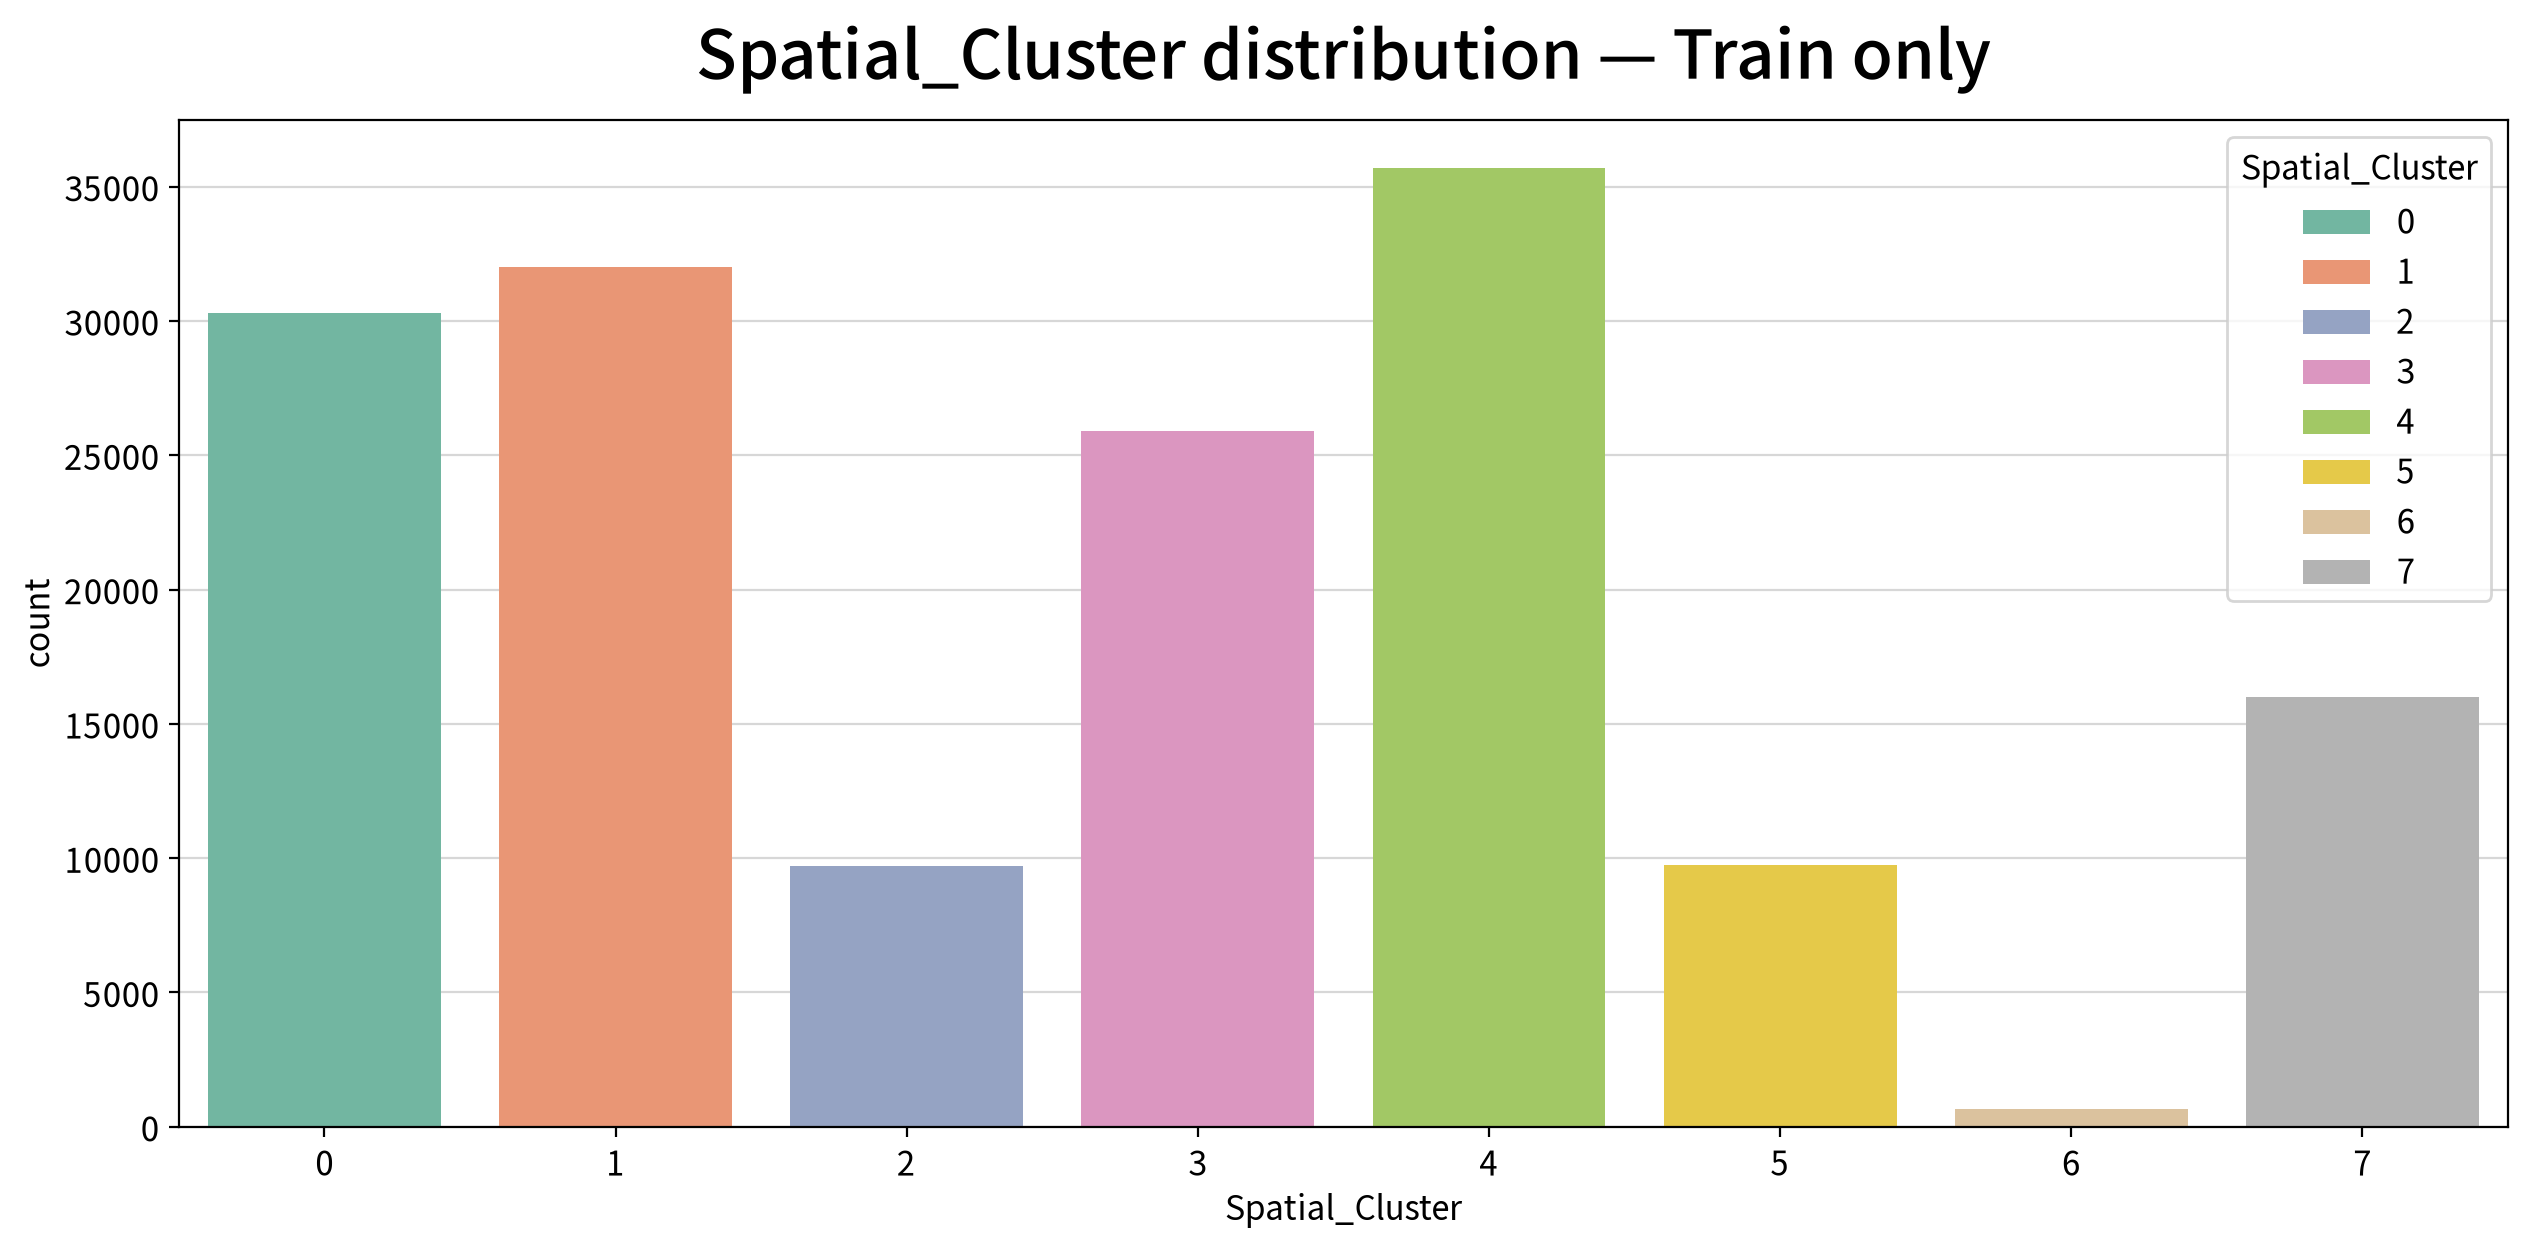

### Spatial_Cluster_Region — Train distribution

,N,Pct
Spatial_Cluster_Region,,
Midwest,35684,22.302082
Southeast,32023,20.014
Central Plains,30311,18.94402
Pacific Northwest,25911,16.194071
Pacific Islands,15983,9.989188
Northeast & Mid-Atlantic,9728,6.079886
Southwest & California,9711,6.069261
South-Central,652,0.407492


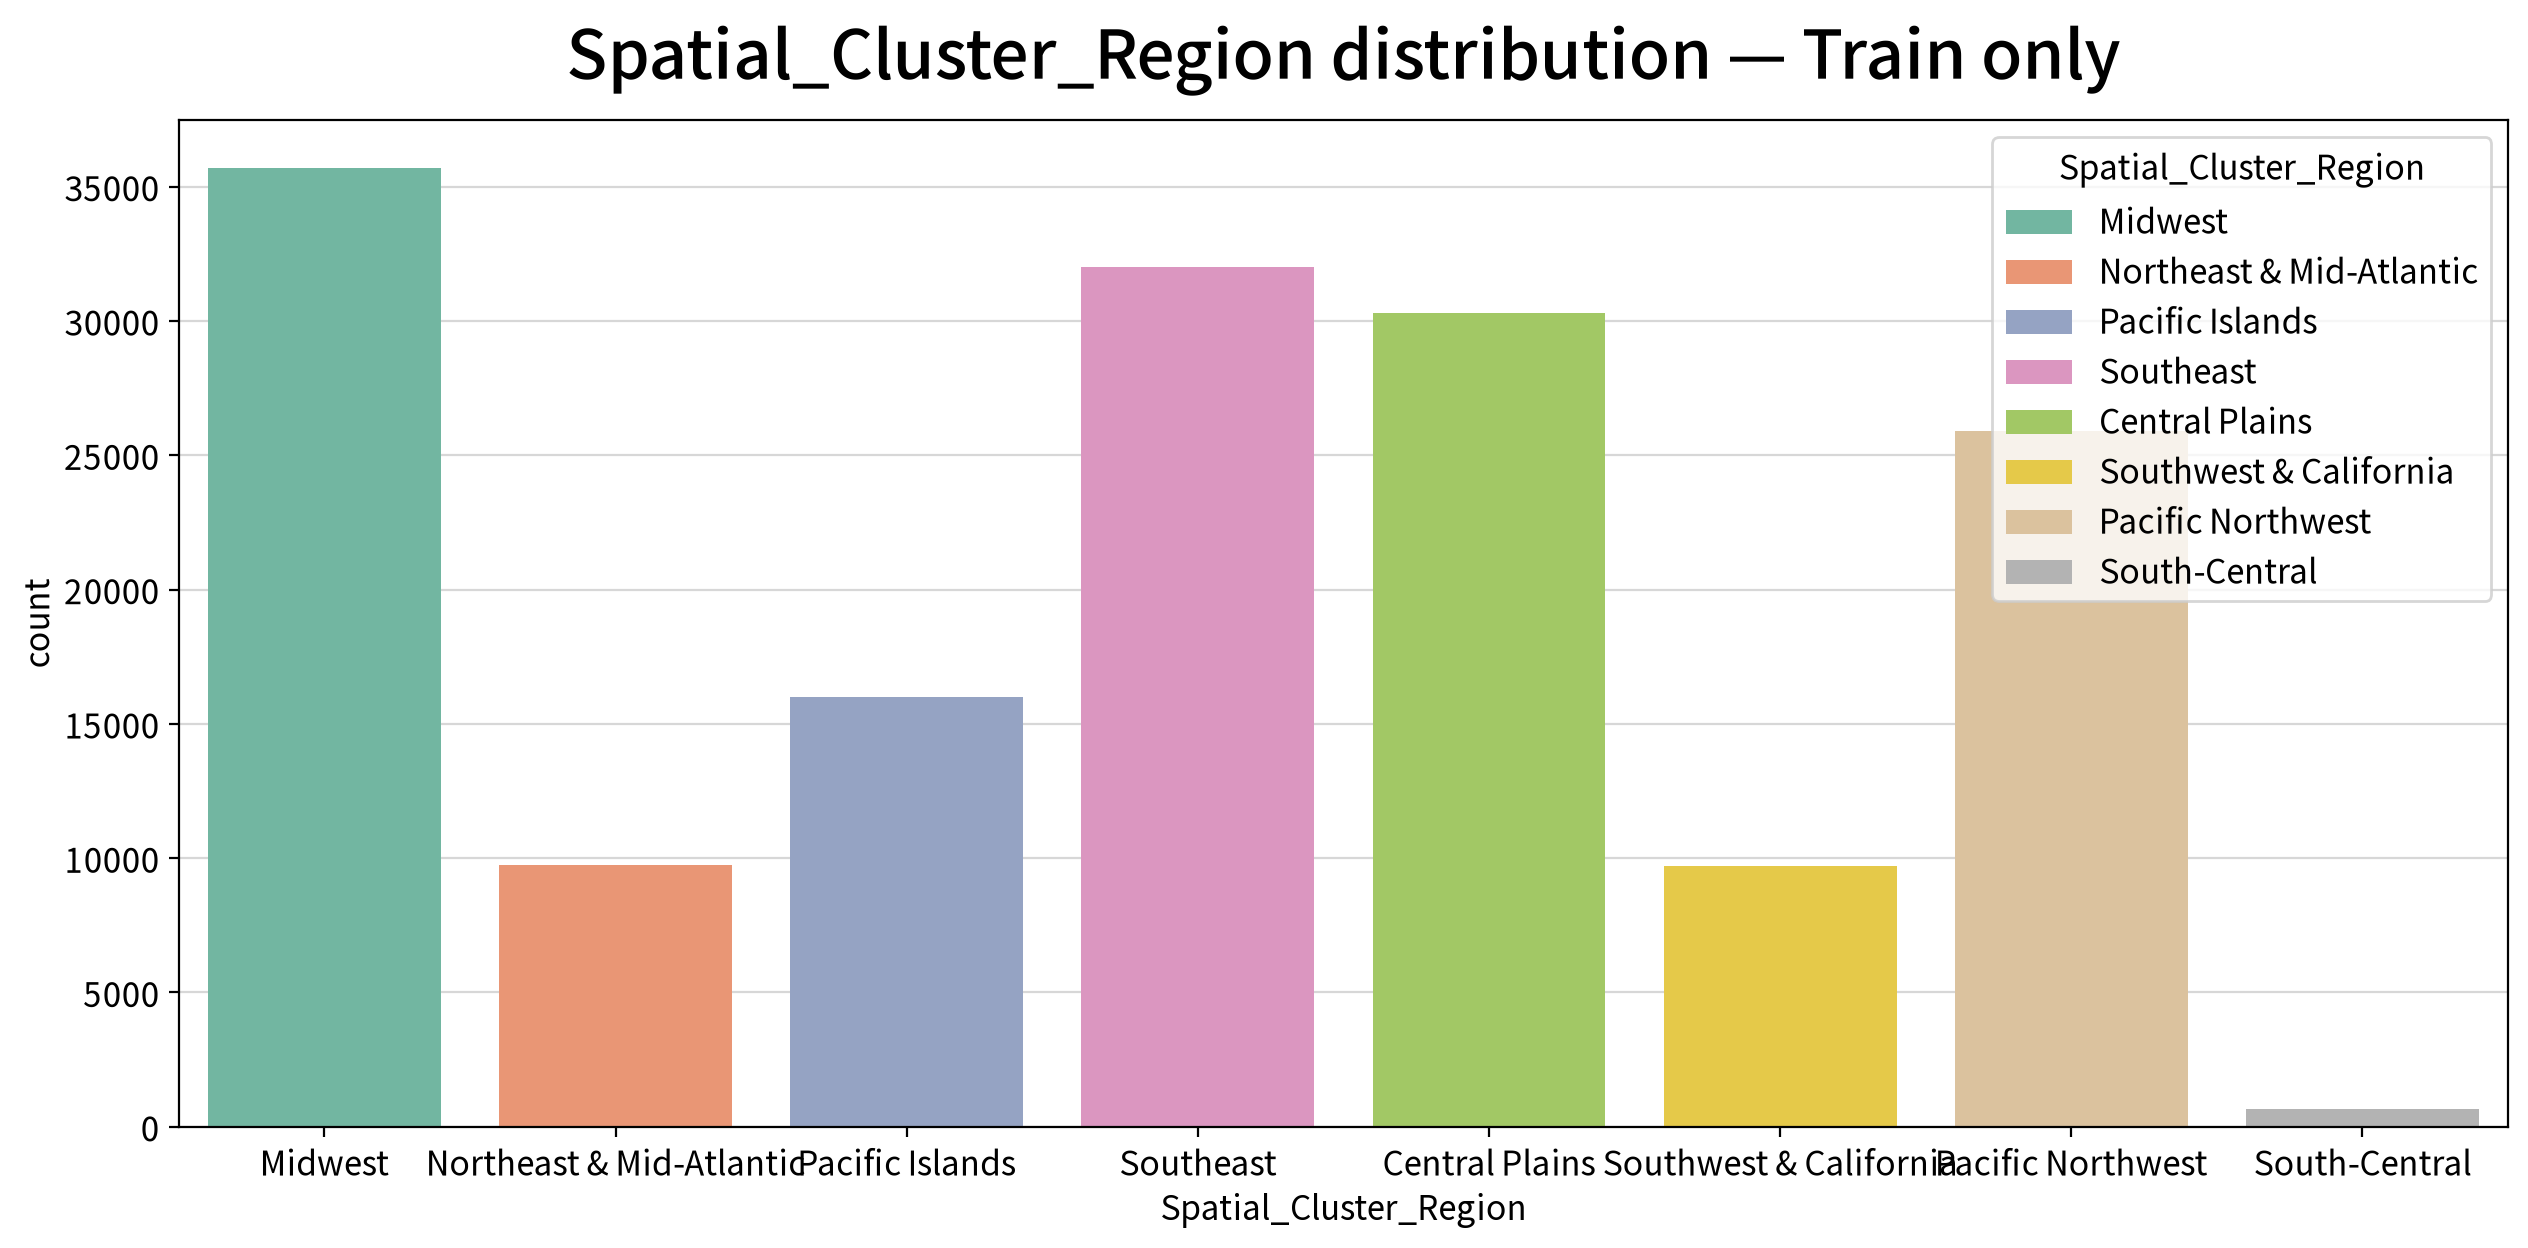

### Regular_State_Macro_Cluster_A — Train distribution

,N,Pct
Regular_State_Macro_Cluster_A,,
0,92980,58.11141
1,66937,41.834841
-1,86,0.053749


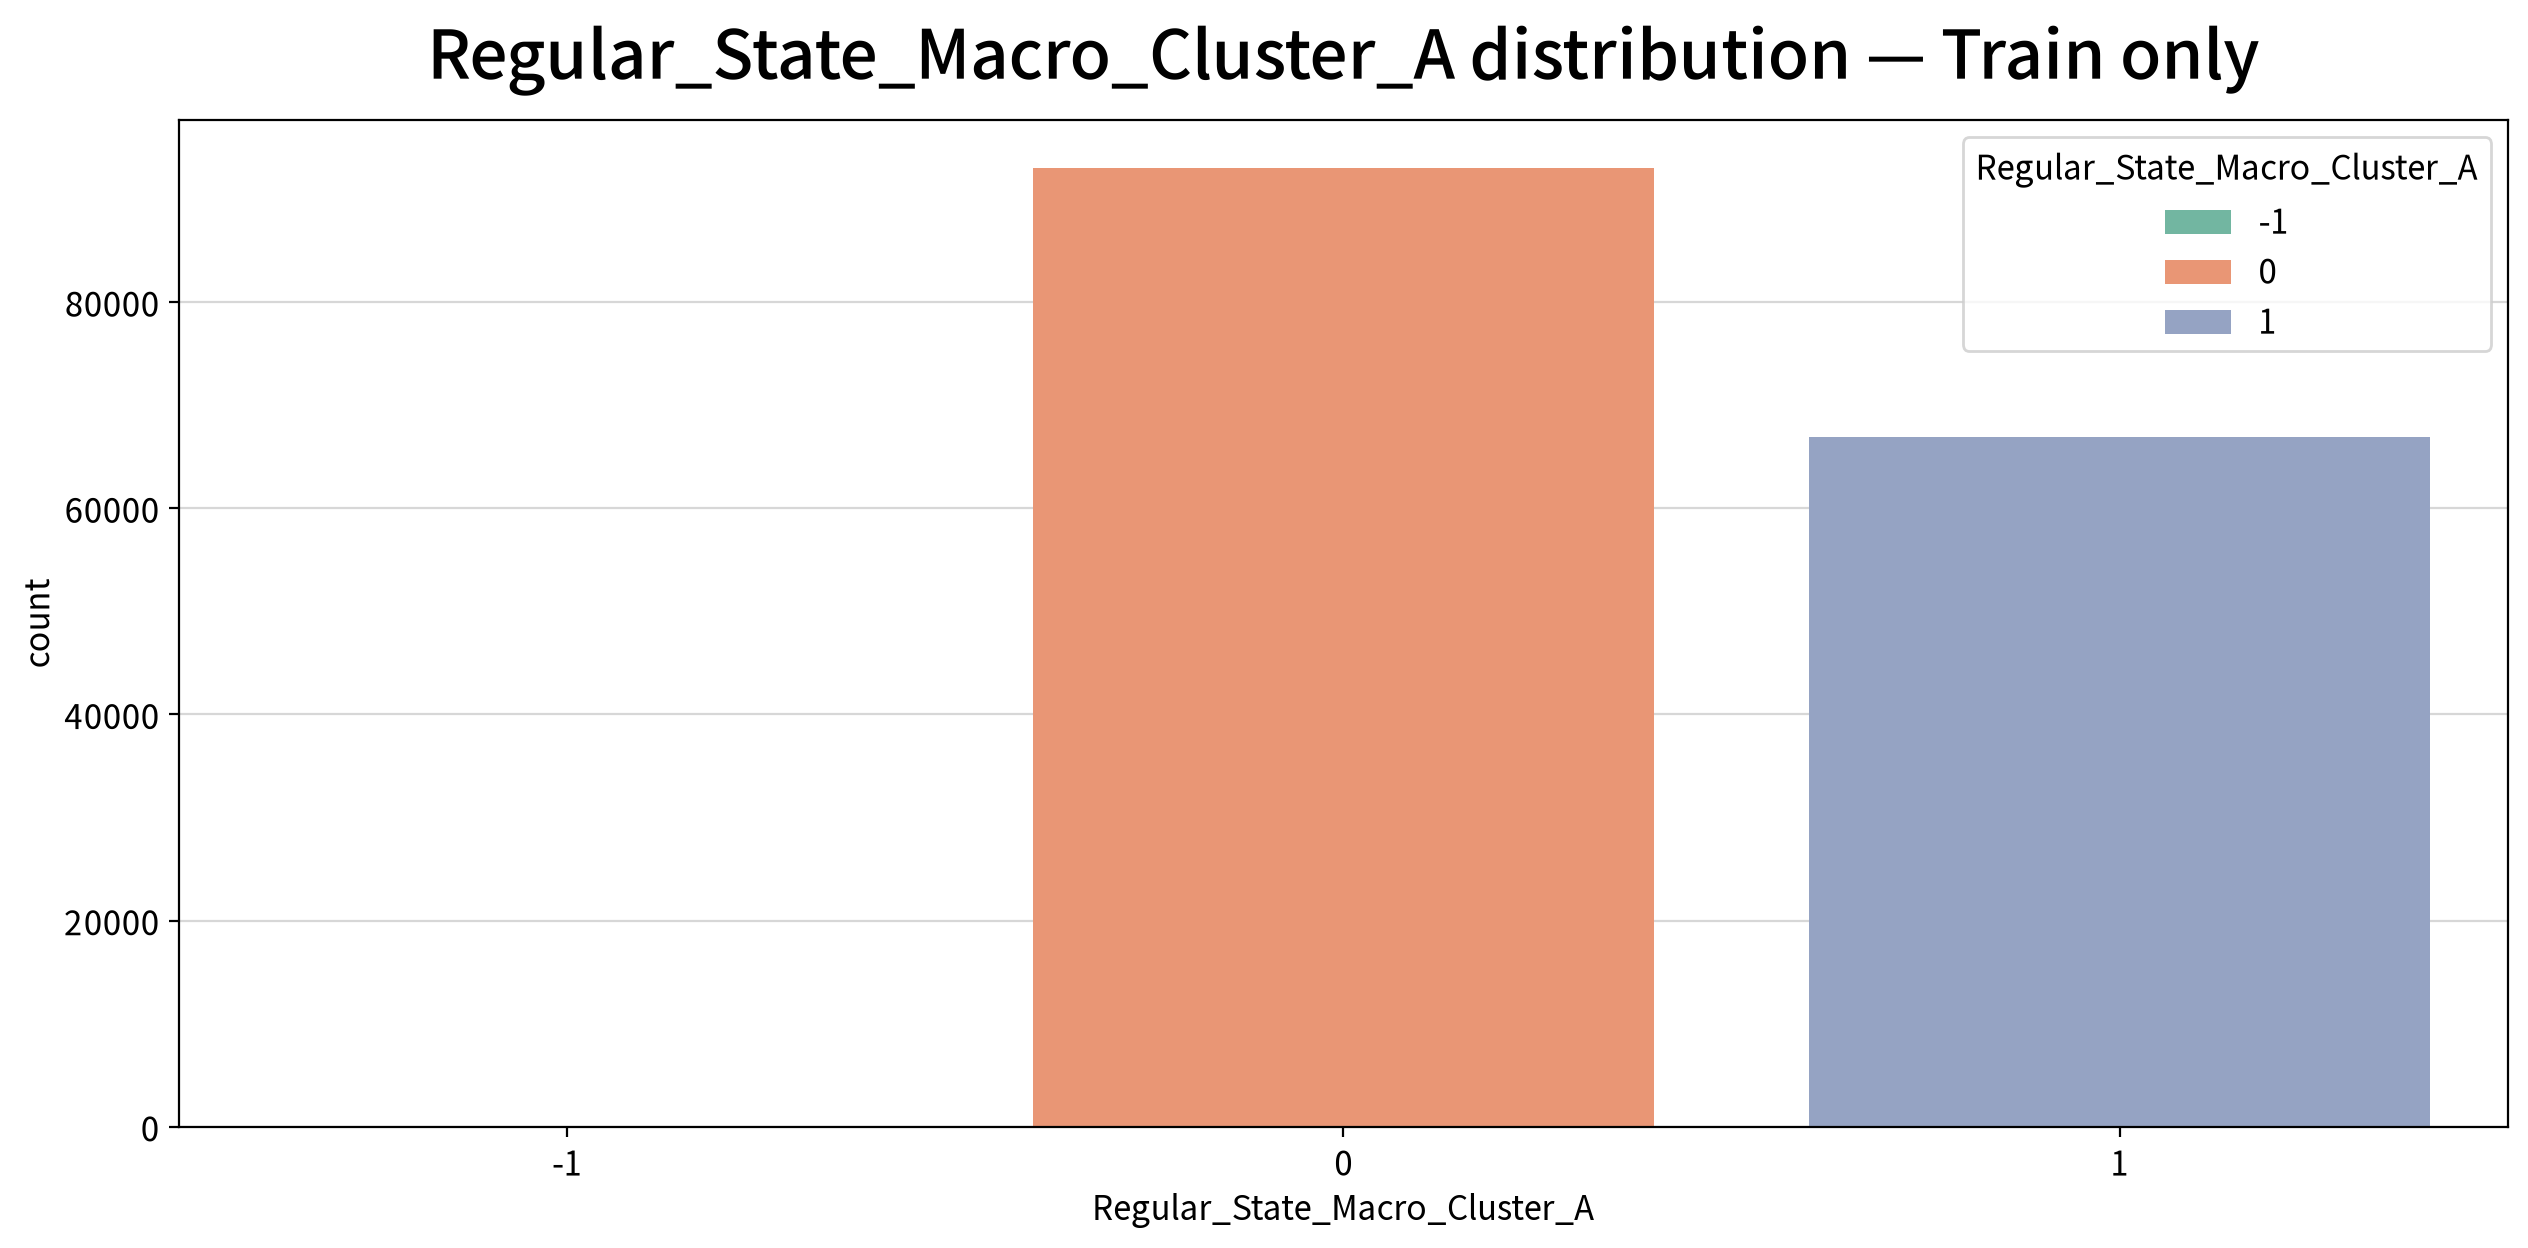

### Regular_State_Macro_Cluster_B — Train distribution

,N,Pct
Regular_State_Macro_Cluster_B,,
1,85046,53.152753
0,74871,46.793498
-1,86,0.053749


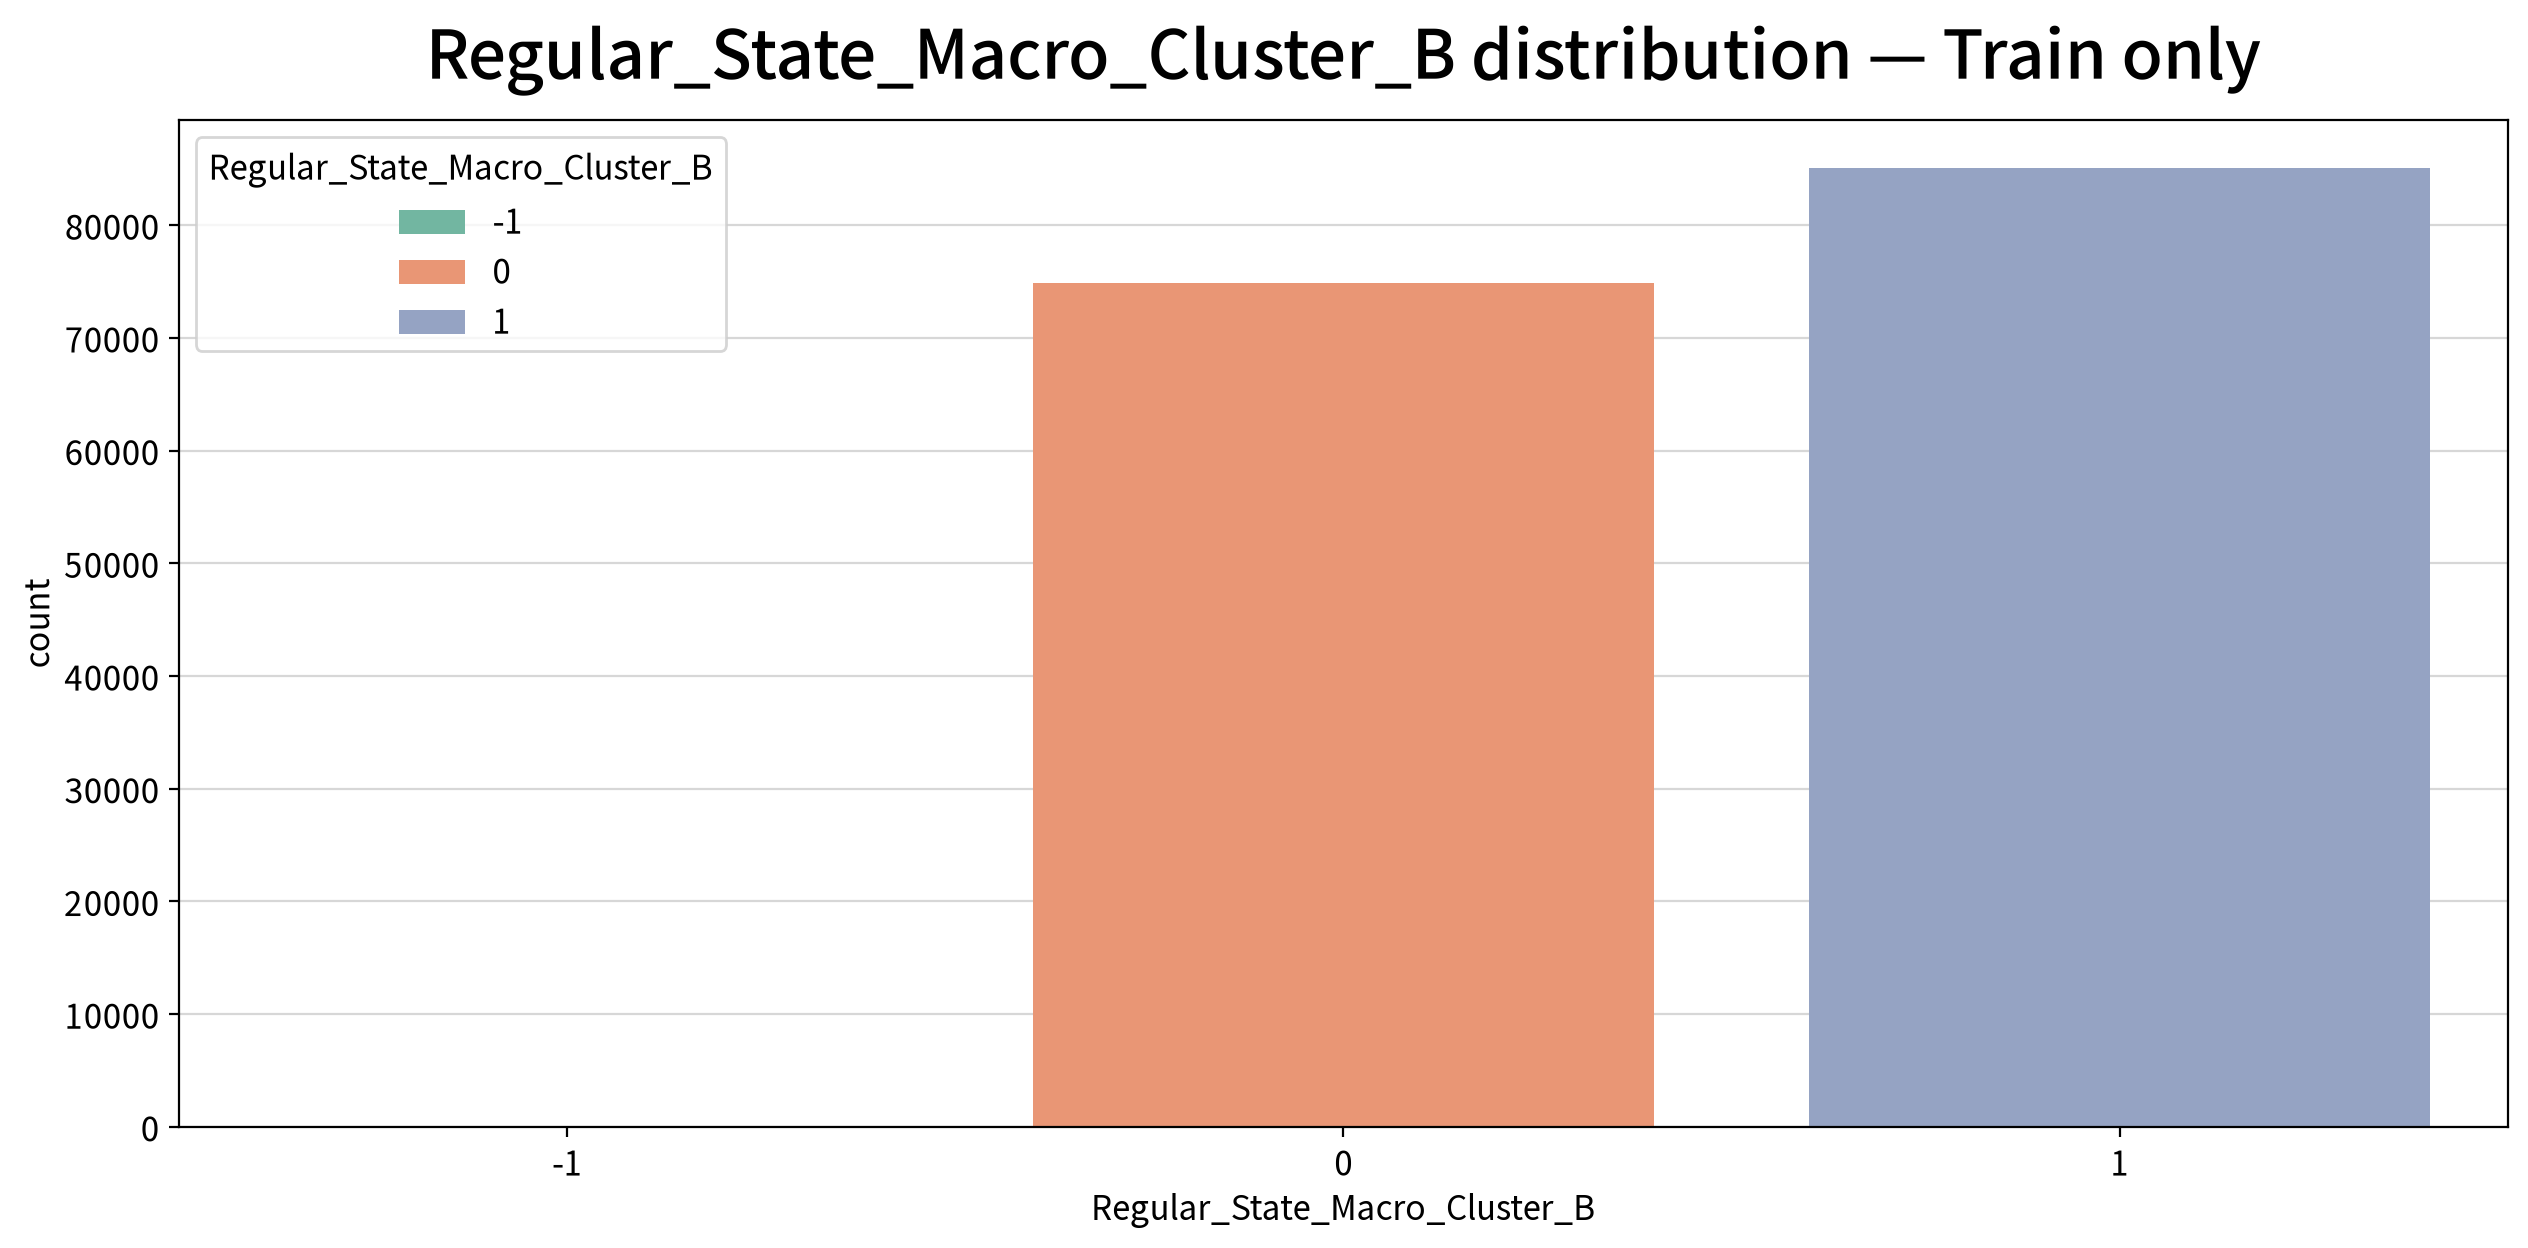

### Regular_MSA_Macro_Cluster_A — Train distribution

,N,Pct
Regular_MSA_Macro_Cluster_A,,
1,82343,51.46341
0,77660,48.53659


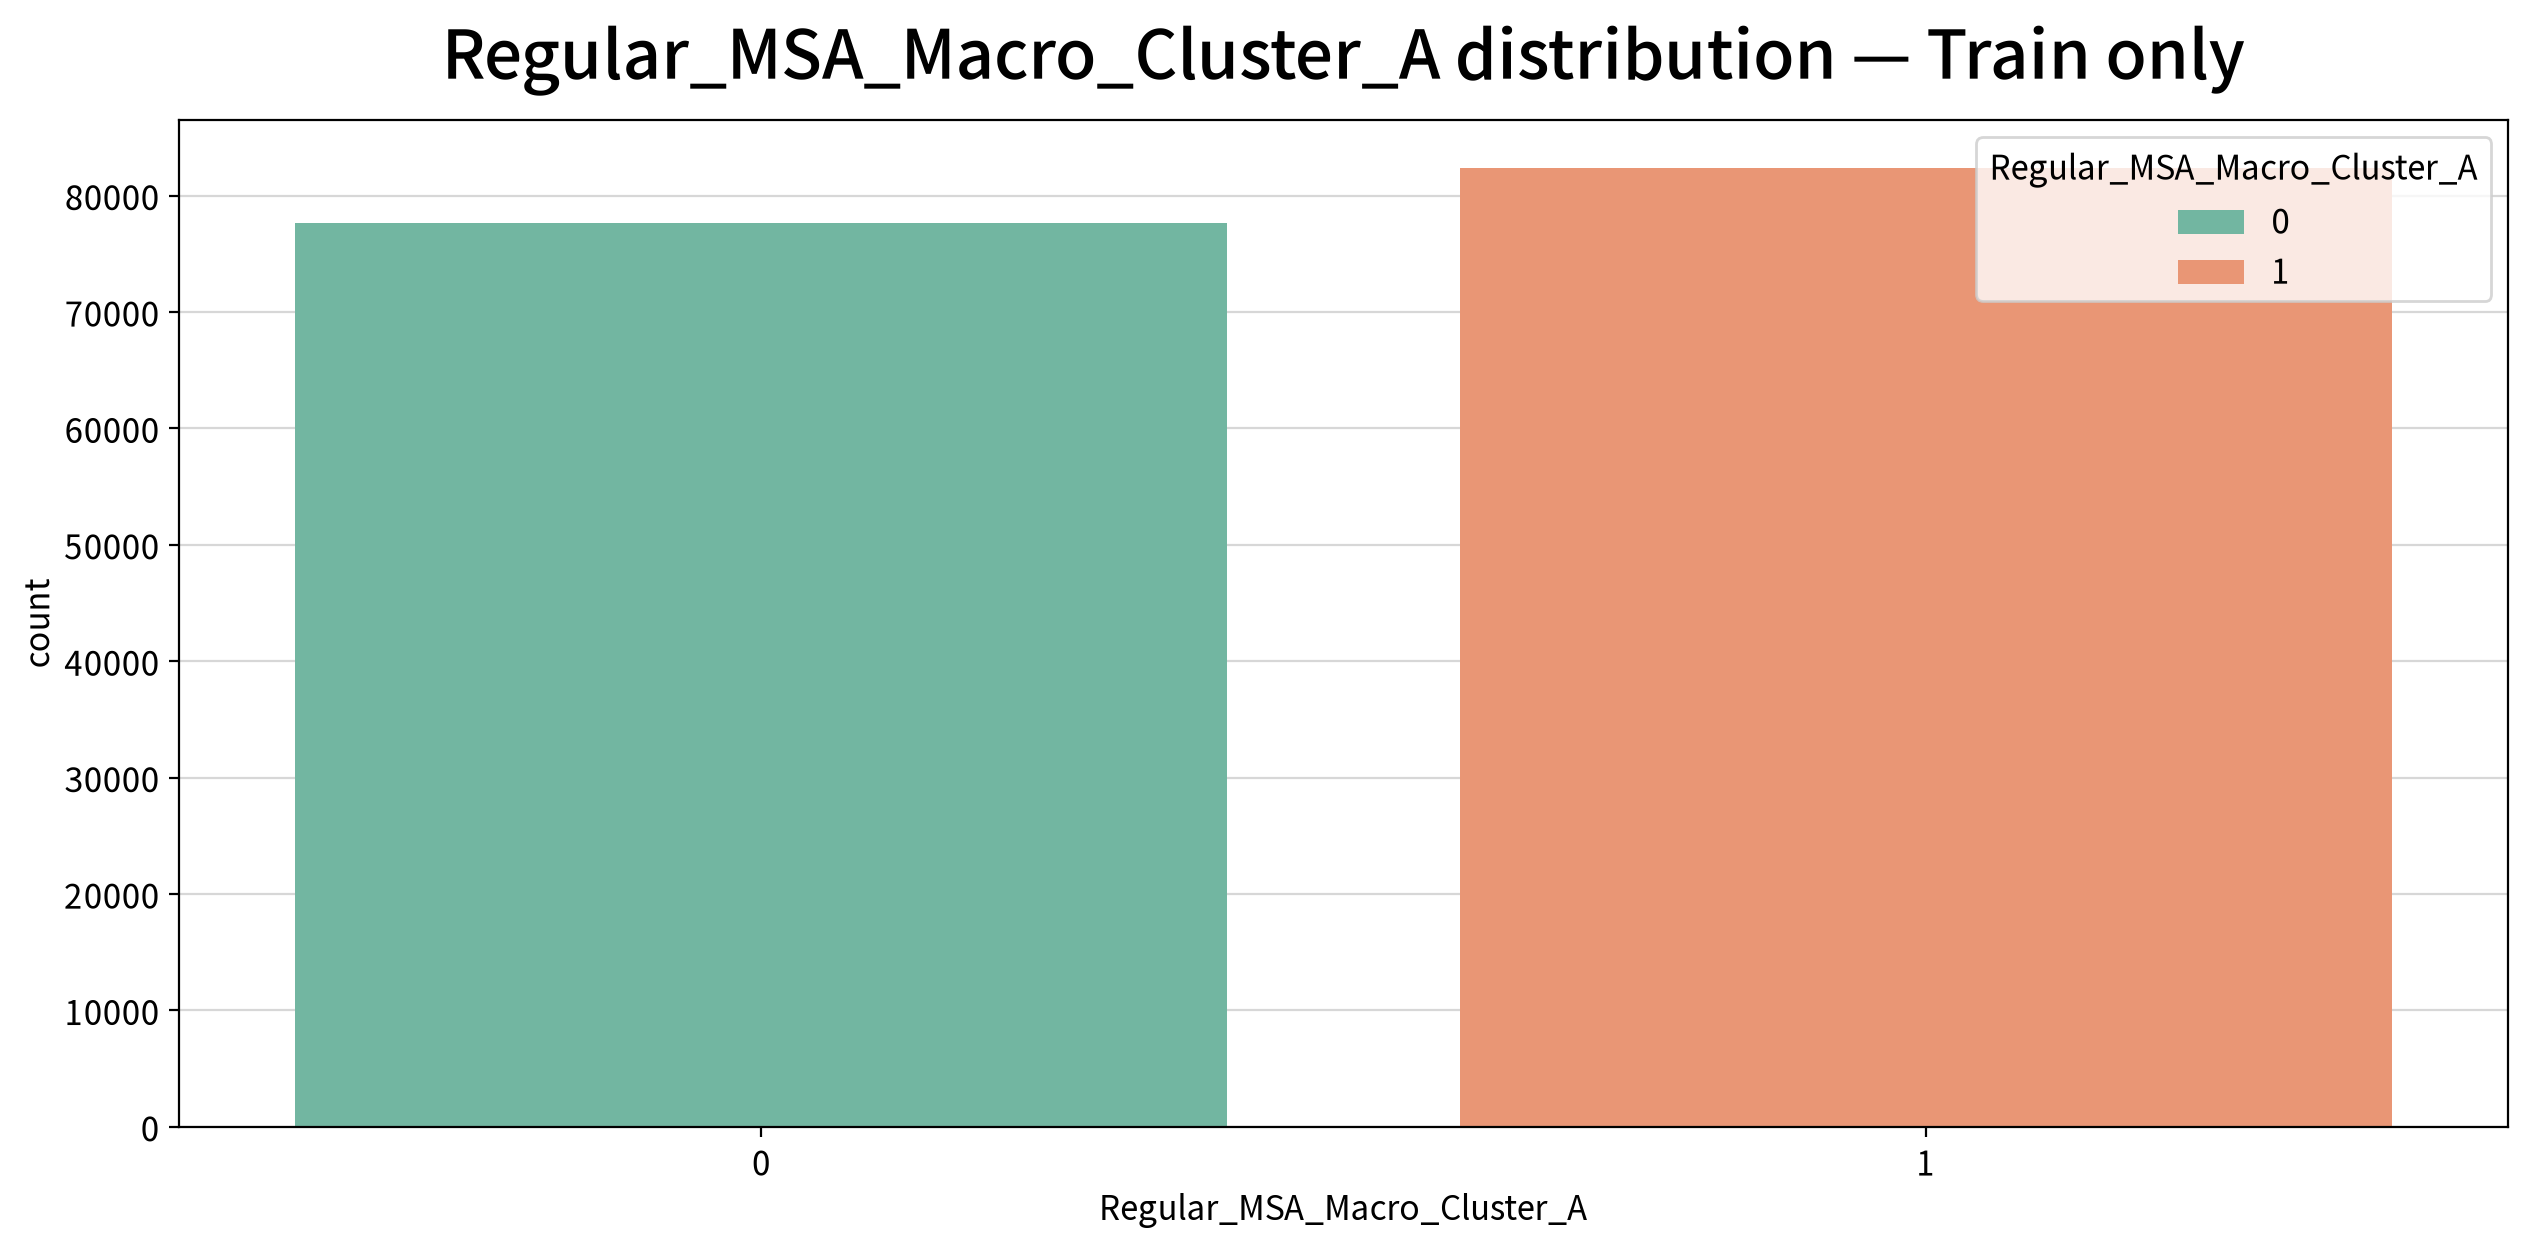

### Regular_MSA_Macro_Cluster_B — Train distribution

,N,Pct
Regular_MSA_Macro_Cluster_B,,
1,80485,50.302182
0,79518,49.697818


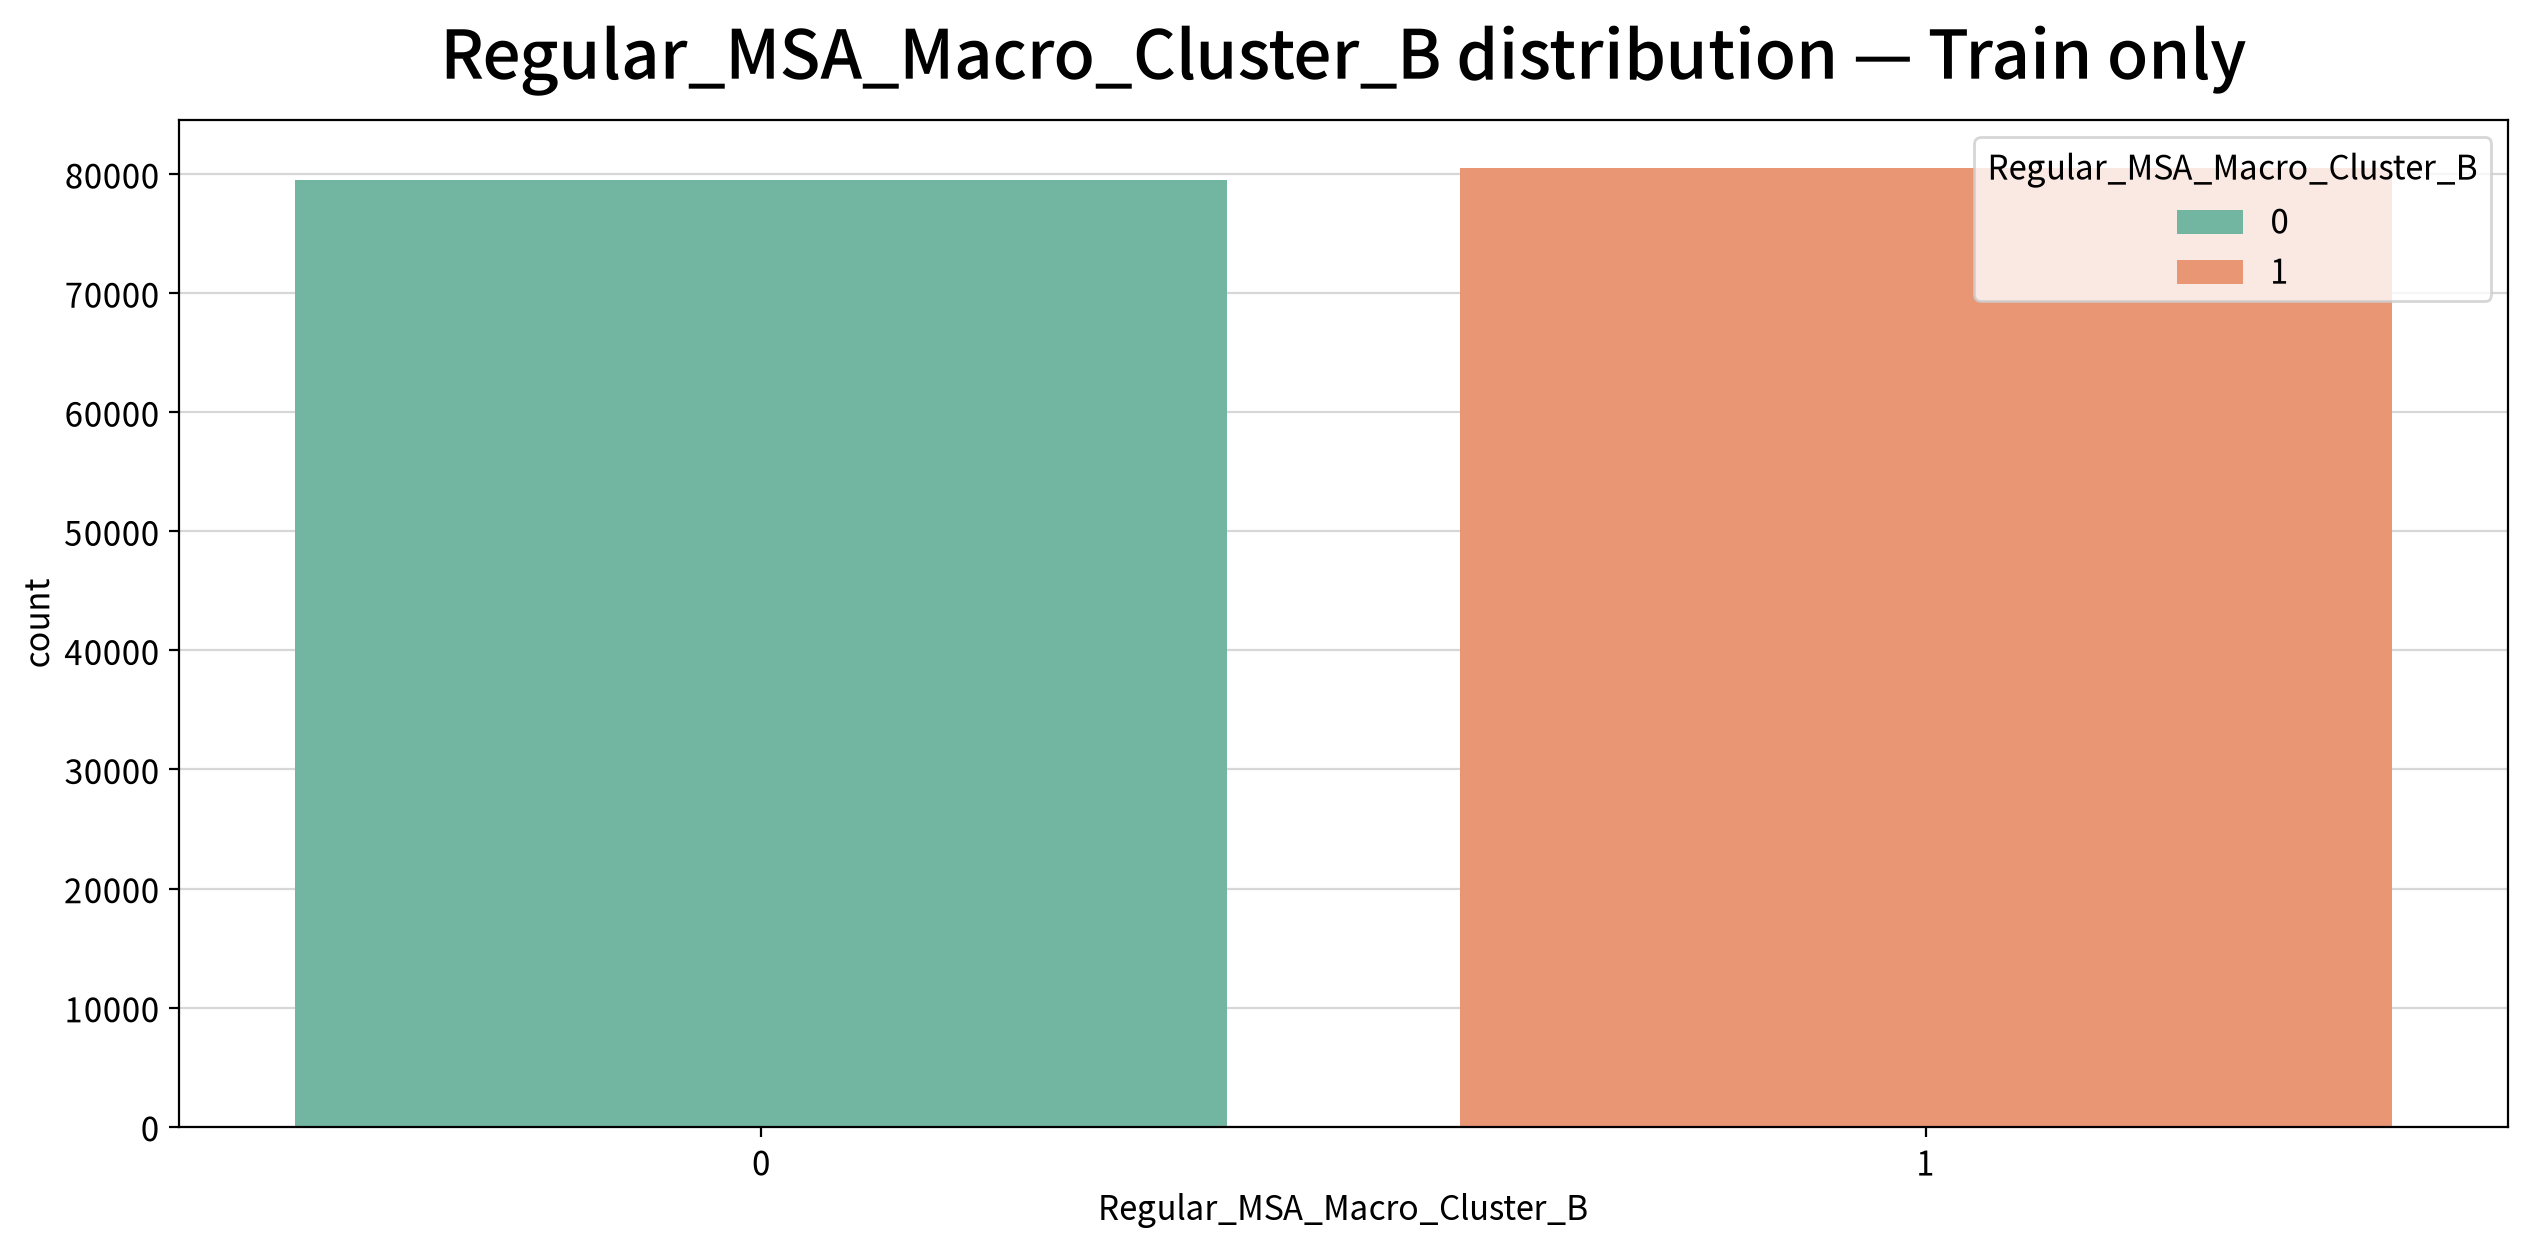

### Regular_MSA_Macro_Cluster_A_Fallback — Train distribution

,N,Pct
Regular_MSA_Macro_Cluster_A_Fallback,,
0,128197,80.121623
1,31806,19.878377


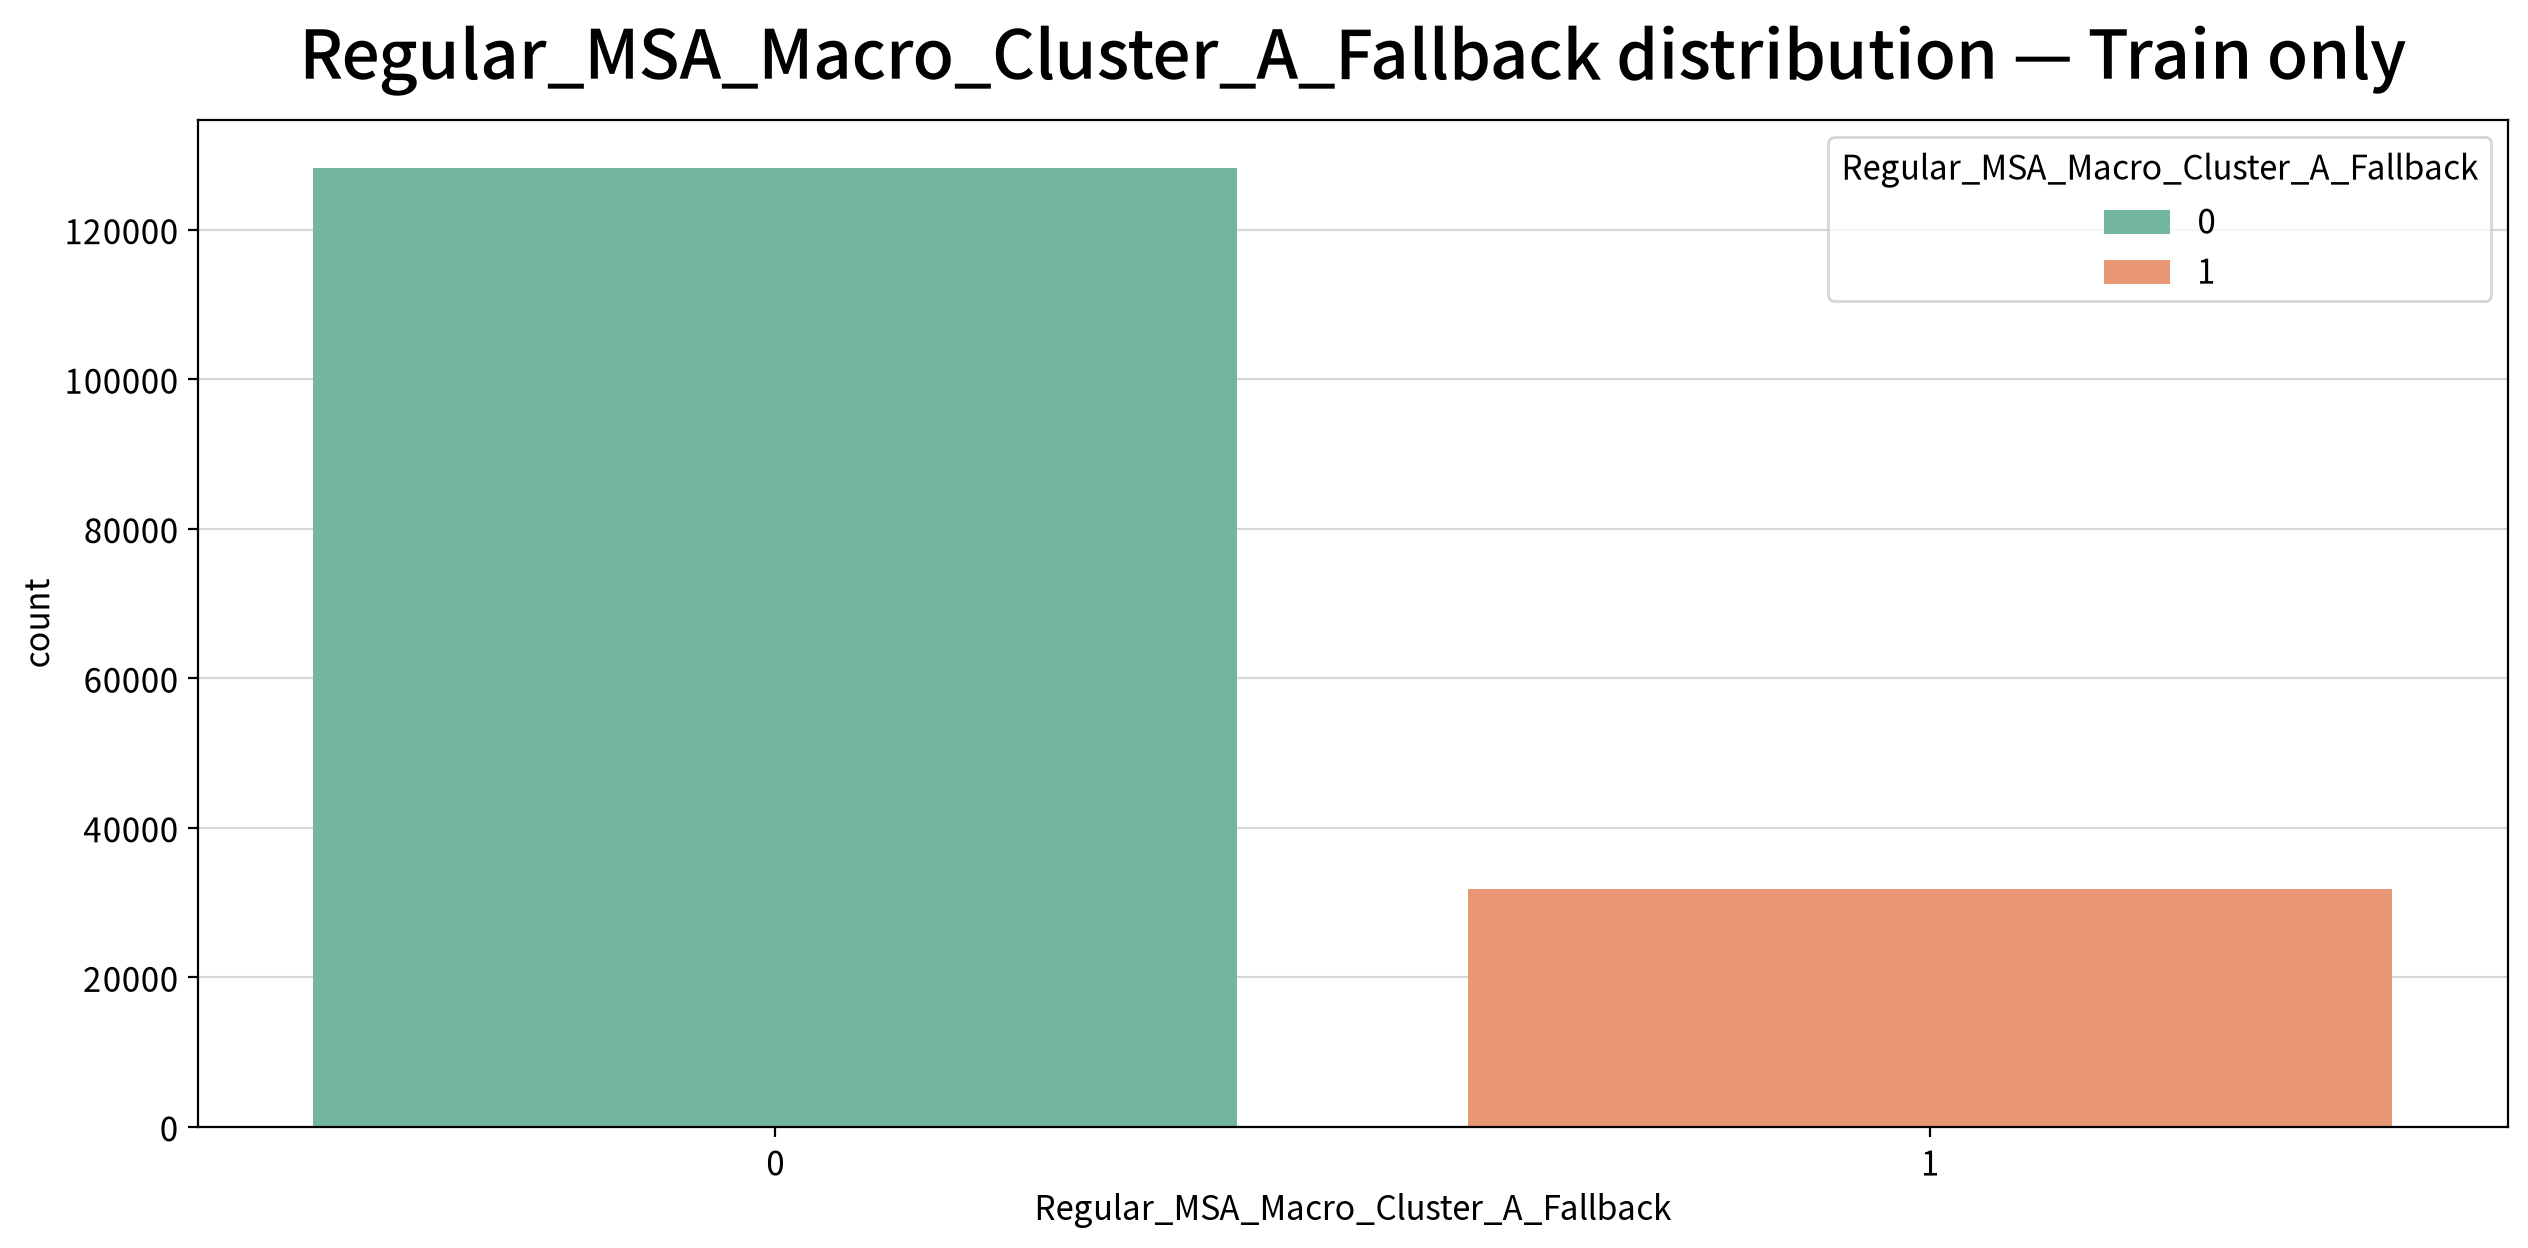

### Regular_MSA_Macro_Cluster_B_Fallback — Train distribution

,N,Pct
Regular_MSA_Macro_Cluster_B_Fallback,,
0,128197,80.121623
1,31806,19.878377


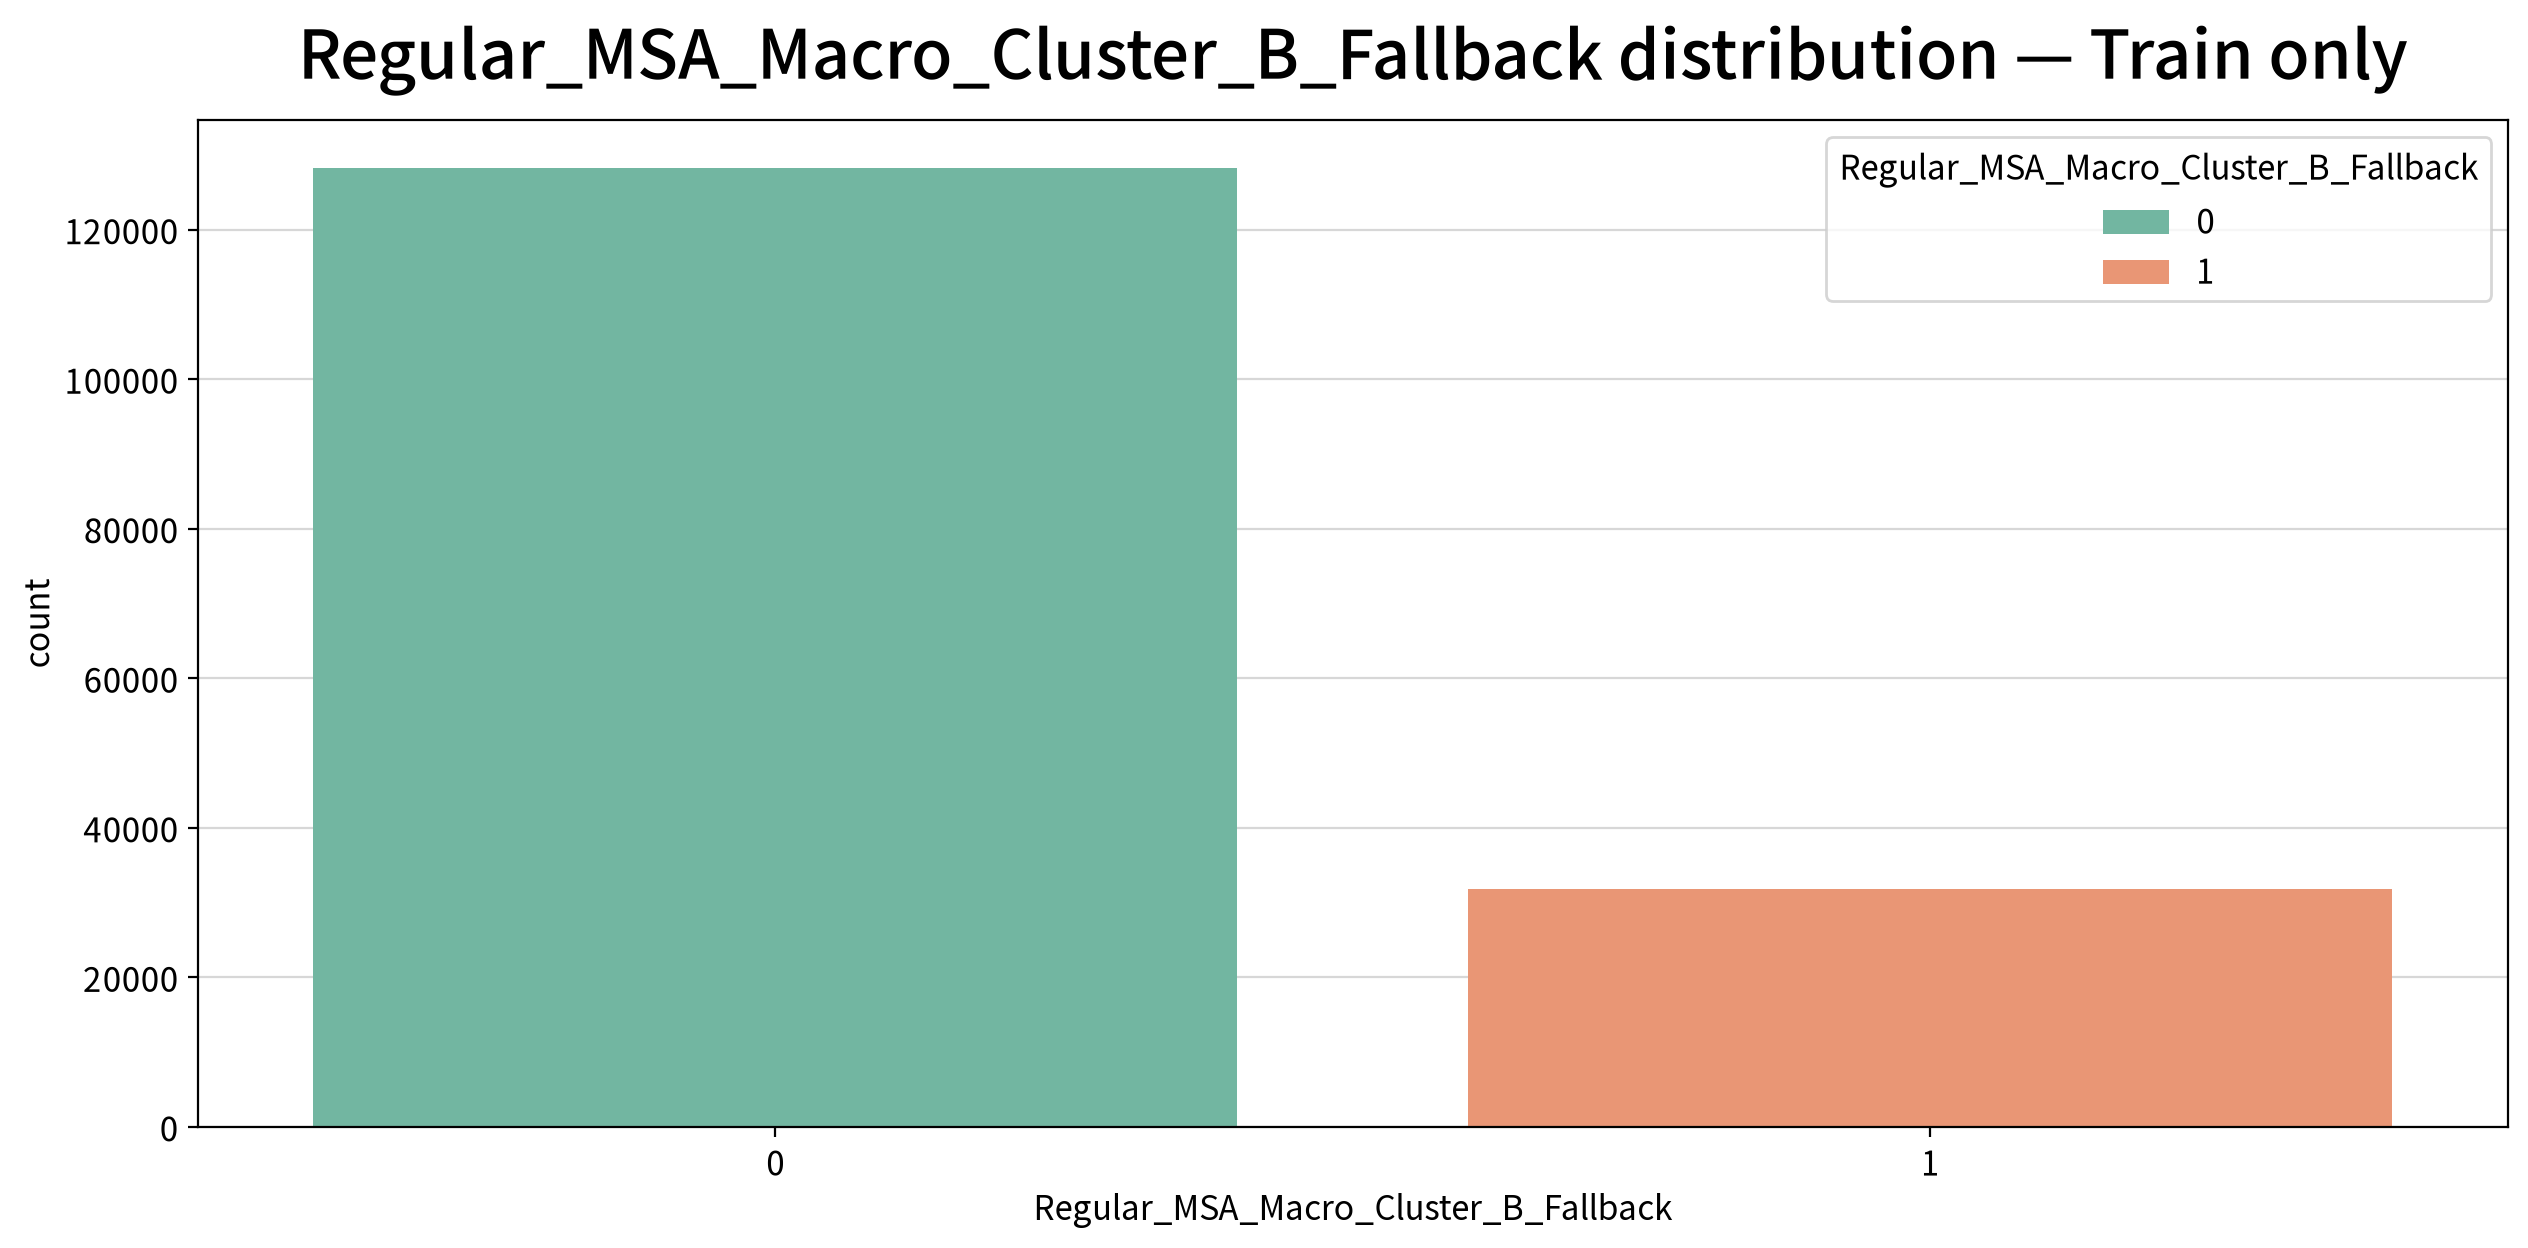

,Variable,N_Unique,Top_Category,Top_Category_N,Top_Category_Pct,Levels_N_lt_100
7,Postal_Code,885,945,2115,1.321850,474
1,MSA,453,Missing,18851,11.781654,230
5,Property_State,54,CA,24363,15.226590,3
9,Seller_Name,34,OTHER,57618,36.010575,2
19,Spatial_Cluster,8,4,35684,22.302082,0
20,Spatial_Cluster_Region,8,Midwest,35684,22.302082,0
16,CLTV_Risk_Component,5,CLTV_<80,79015,49.383449,0
14,DTI_Risk_Band,5,DTI_40plus,48430,30.268182,0
13,FICO_Risk_Band,5,FICO_760plus,77675,48.545965,0
15,LTV_Risk_Component,5,LTV_<80,82317,51.447160,0


In [5]:
# ======================================================================================
# 4A. CATEGORICAL UNIVARIATE ANALYSIS
# ======================================================================================
cat_summary_records = []
MAX_PLOT_LEVELS = 20

for c in CATEGORICAL_COLS:
    vc = df[c].value_counts(dropna=False)
    n_unique = int(df[c].nunique(dropna=False))
    top_share = float(vc.iloc[0] / len(df)) if len(vc) else np.nan
    rare_lt_100 = int((vc < 100).sum())
    cat_summary_records.append({
        "Variable": c, "N_Unique": n_unique, "Top_Category": str(vc.index[0]) if len(vc) else None,
        "Top_Category_N": int(vc.iloc[0]) if len(vc) else 0, "Top_Category_Pct": top_share*100,
        "Levels_N_lt_100": rare_lt_100,
    })

    freq = vc.rename("N").to_frame()
    freq["Pct"] = freq["N"] / len(df) * 100
    freq.to_csv(QA_DIR / f"08A_freq_{c}.csv")

    display(Markdown(f"### {c} — Train distribution"))
    display(freq.head(30))

    if HOSSAM_AVAILABLE and n_unique <= MAX_PLOT_LEVELS:
        my_plot.countplot(data=df, x=c, hue=c, palette="Set2", dodge=False,
                          title=f"{c} distribution — Train only")
    elif n_unique > MAX_PLOT_LEVELS:
        print(f"Plot skipped: {n_unique} levels > MAX_PLOT_LEVELS={MAX_PLOT_LEVELS}. Full frequency table saved.")

cat_univariate_summary = pd.DataFrame(cat_summary_records).sort_values(["N_Unique", "Variable"], ascending=[False, True])
display(cat_univariate_summary)
cat_univariate_summary.to_csv(QA_DIR / "08A_categorical_univariate_summary.csv", index=False)


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_n,missing_pct,n_unique,skew,iqr,lower_iqr_fence,upper_iqr_fence
FICO_Score,160003.0,747.923870,48.174816,445.000000,622.000000,660.000000,715.000000,757.000000,787.000000,809.000000,816.000000,834.000000,0,0.0,355,-0.826560,72.000000,607.000000,895.000000
MI_Percentage,160003.0,6.151210,11.340925,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000,30.000000,40.000000,0,0.0,20,1.404170,0.000000,0.000000,0.000000
Original_CLTV,160003.0,75.034868,18.408120,3.000000,24.000000,40.000000,66.000000,80.000000,87.000000,95.000000,115.000000,854.000000,0,0.0,226,0.303394,21.000000,34.500000,118.500000
Original_DTI,160003.0,34.045093,8.833129,1.000000,12.000000,18.000000,28.000000,35.000000,41.000000,47.000000,50.000000,50.000000,0,0.0,50,-0.498692,13.000000,8.500000,60.500000
Original_UPB,160003.0,220478.141035,118064.072595,10000.000000,44000.000000,69000.000000,129000.000000,199000.000000,295000.000000,417000.000000,581000.000000,975000.000000,0,0.0,709,0.874826,166000.000000,-120000.000000,544000.000000
Original_LTV,160003.0,74.067111,18.024907,3.000000,23.000000,39.000000,65.000000,79.000000,85.000000,95.000000,108.000000,336.000000,0,0.0,209,-0.426415,20.000000,35.000000,115.000000
Original_Interest_Rate,160003.0,4.044026,0.517538,2.250000,2.750000,3.125000,3.750000,4.125000,4.375000,4.875000,5.125000,6.000000,0,0.0,696,-0.210396,0.625000,2.812500,5.312500
Original_Loan_Term,160003.0,315.190840,76.271453,96.000000,120.000000,180.000000,240.000000,360.000000,360.000000,360.000000,360.000000,366.000000,0,0.0,145,-1.203685,120.000000,60.000000,540.000000
Number_of_Borrowers,160003.0,1.503697,0.499988,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,0,0.0,2,-0.014788,1.000000,-0.500000,3.500000
CLTV_LTV_Gap,160003.0,0.967757,5.270892,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,25.000000,809.000000,0,0.0,98,31.230894,0.000000,0.000000,0.000000


### FICO_Score — Train distribution

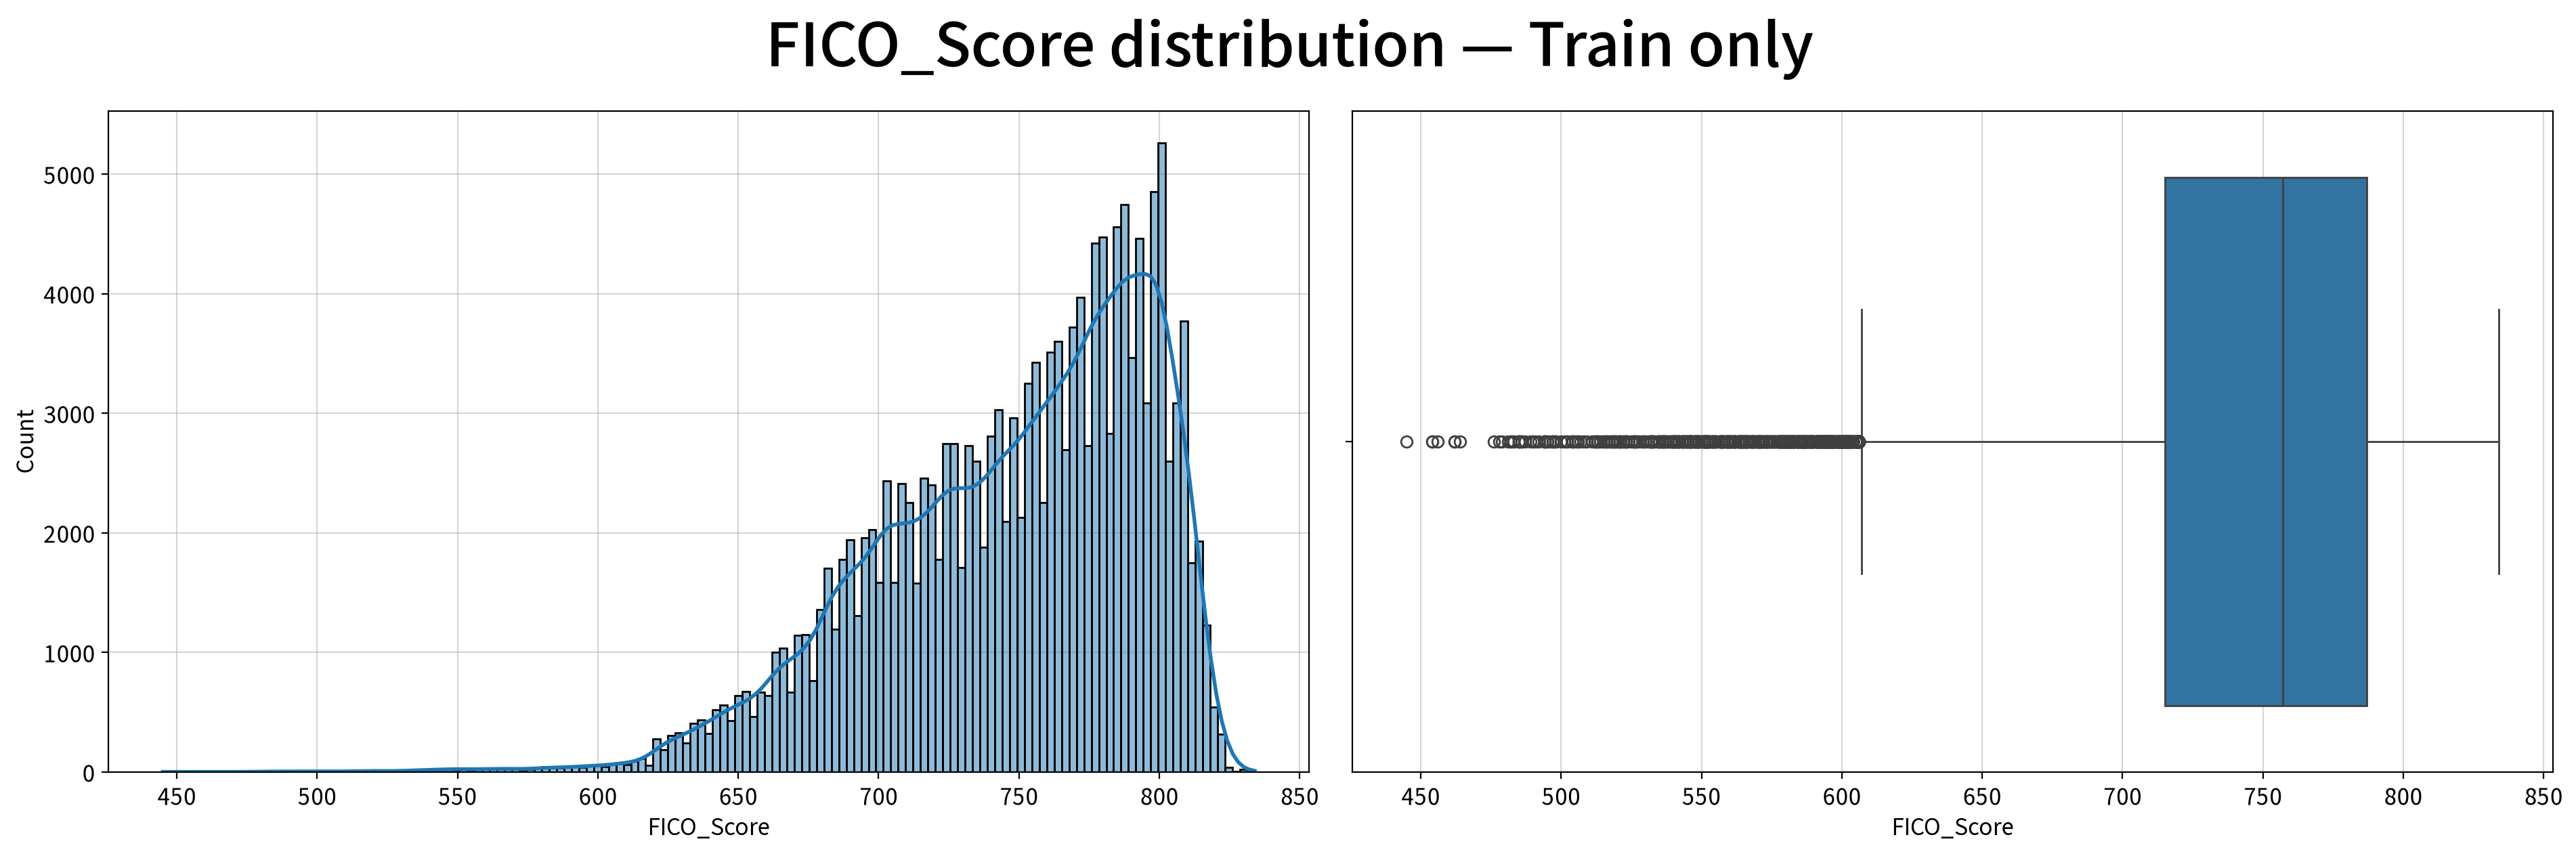

### MI_Percentage — Train distribution

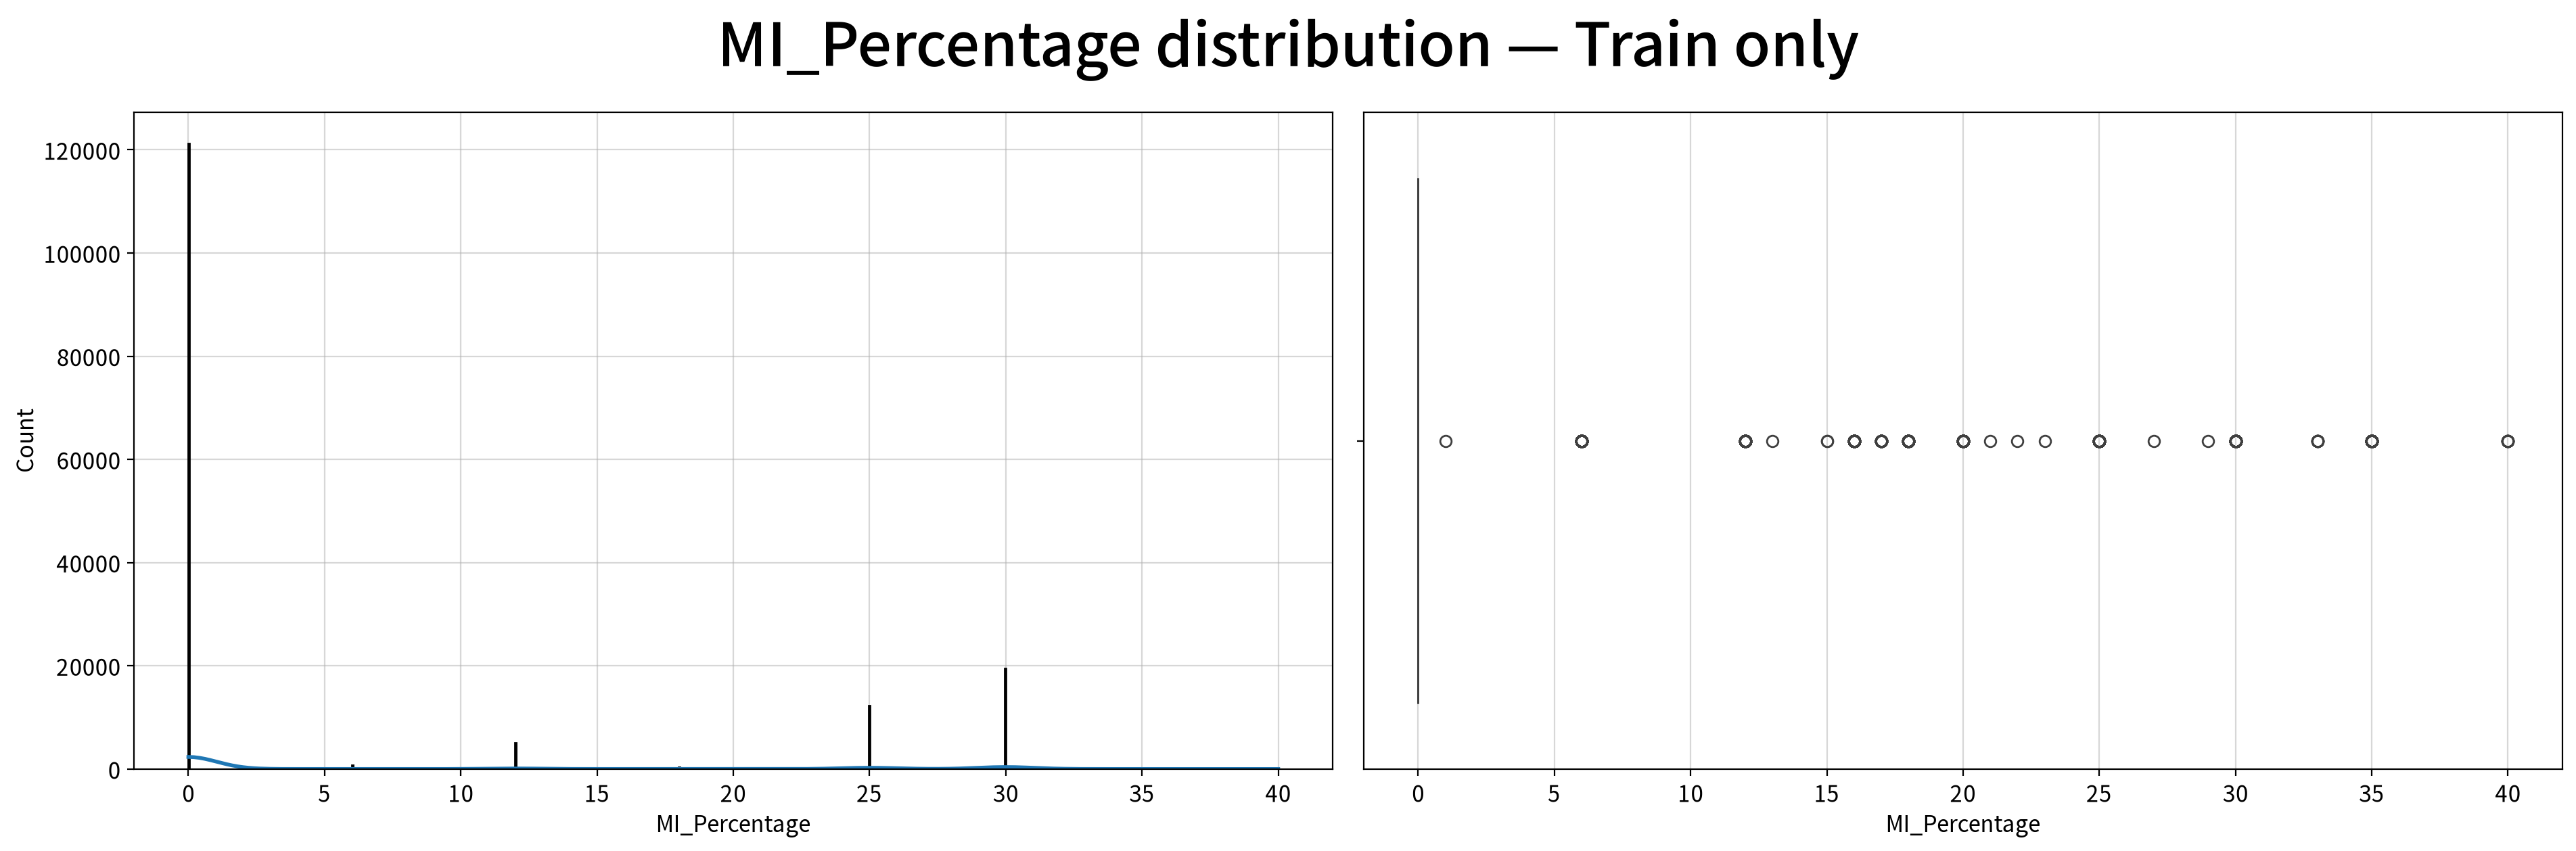

### Original_CLTV — Train distribution

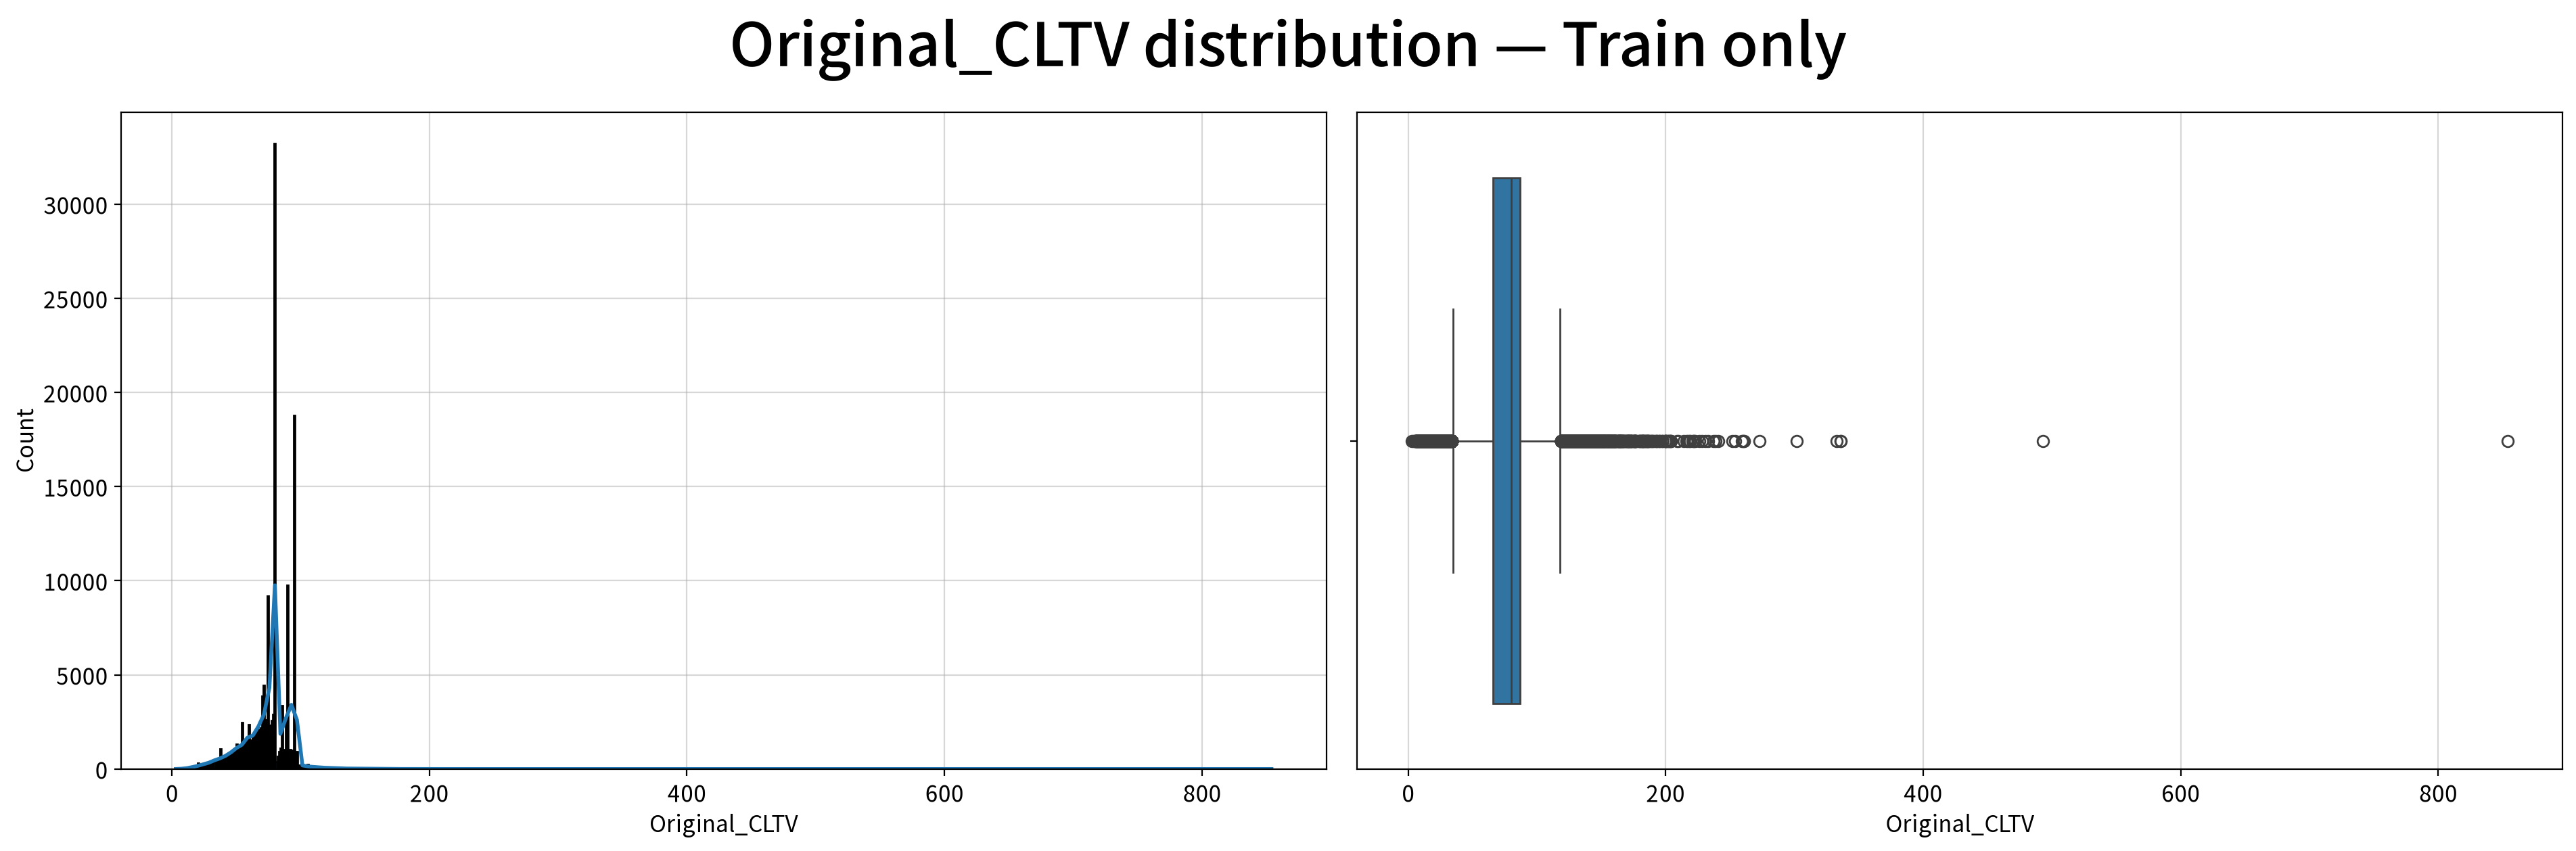

### Original_DTI — Train distribution

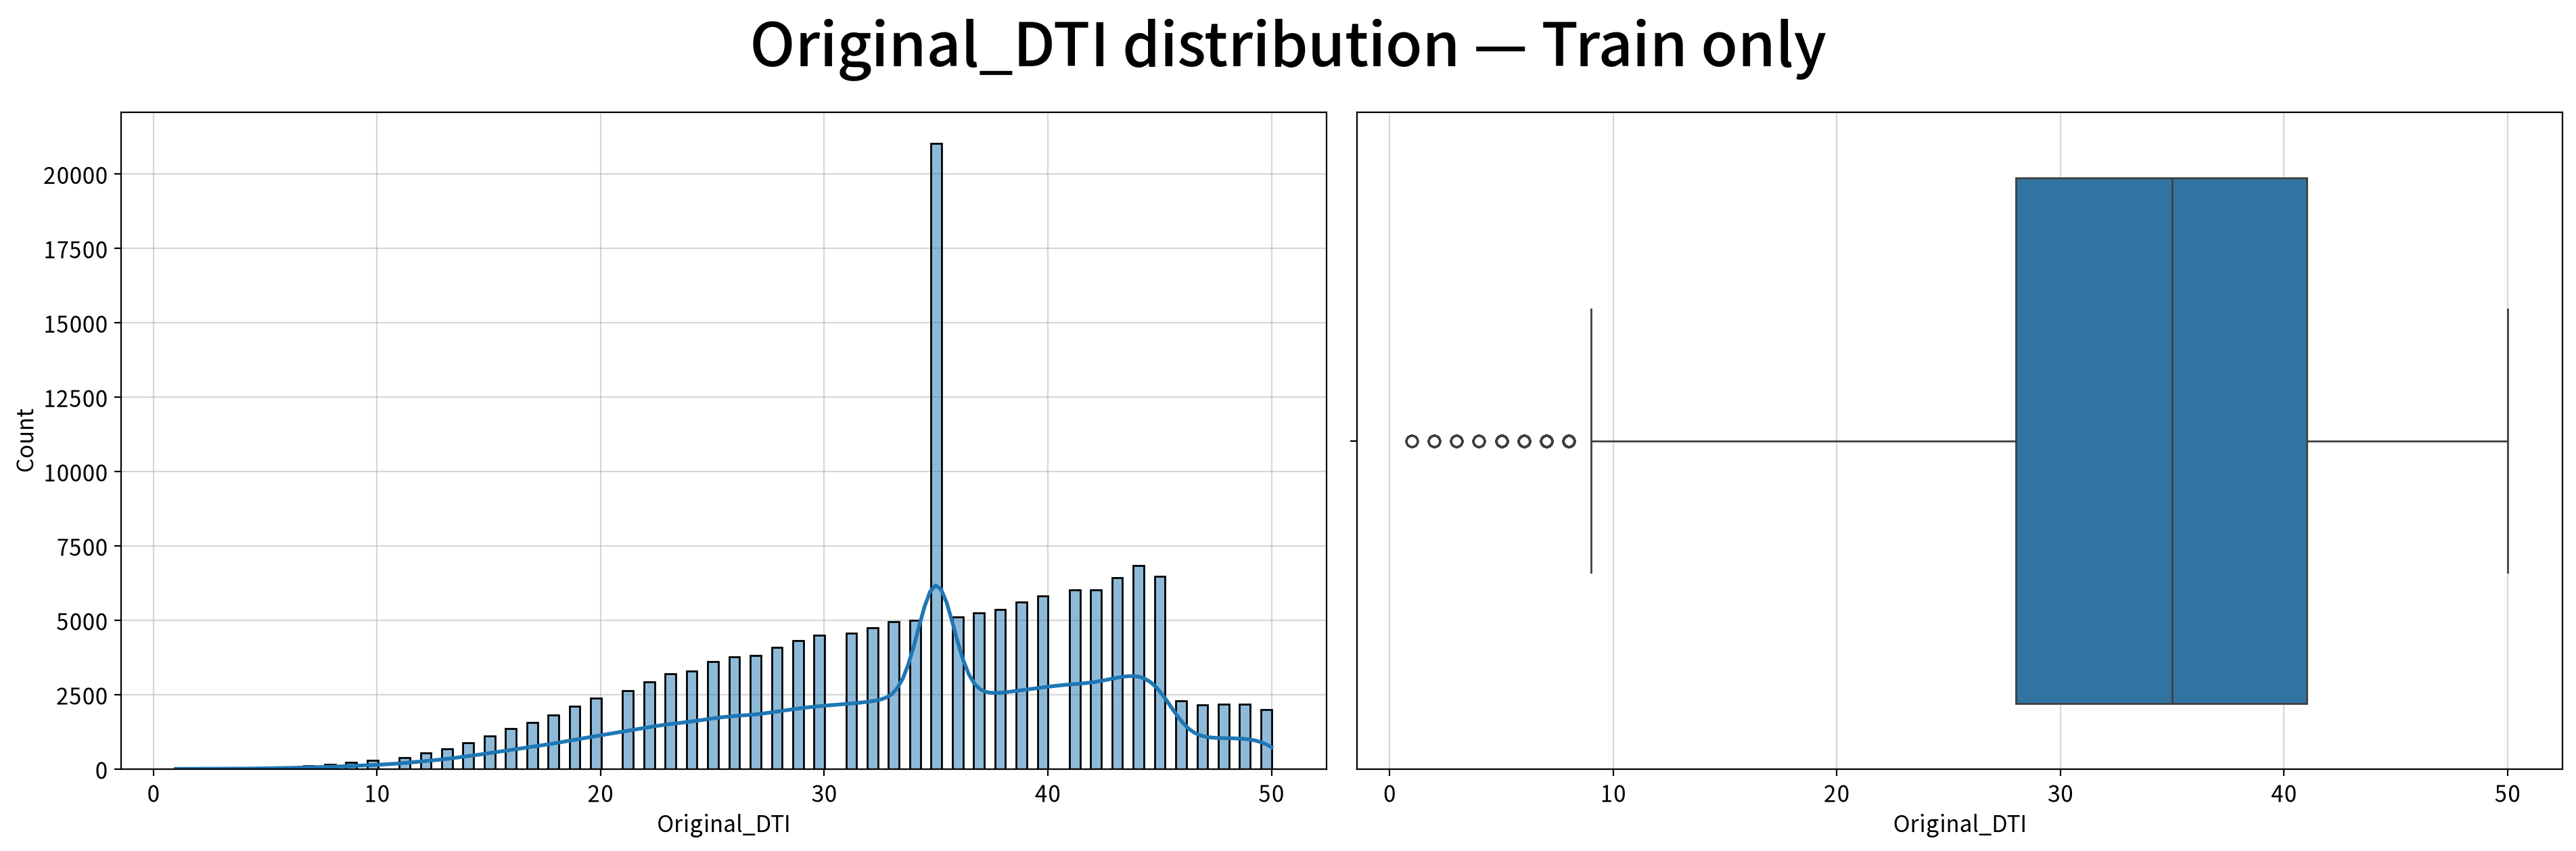

### Original_UPB — Train distribution

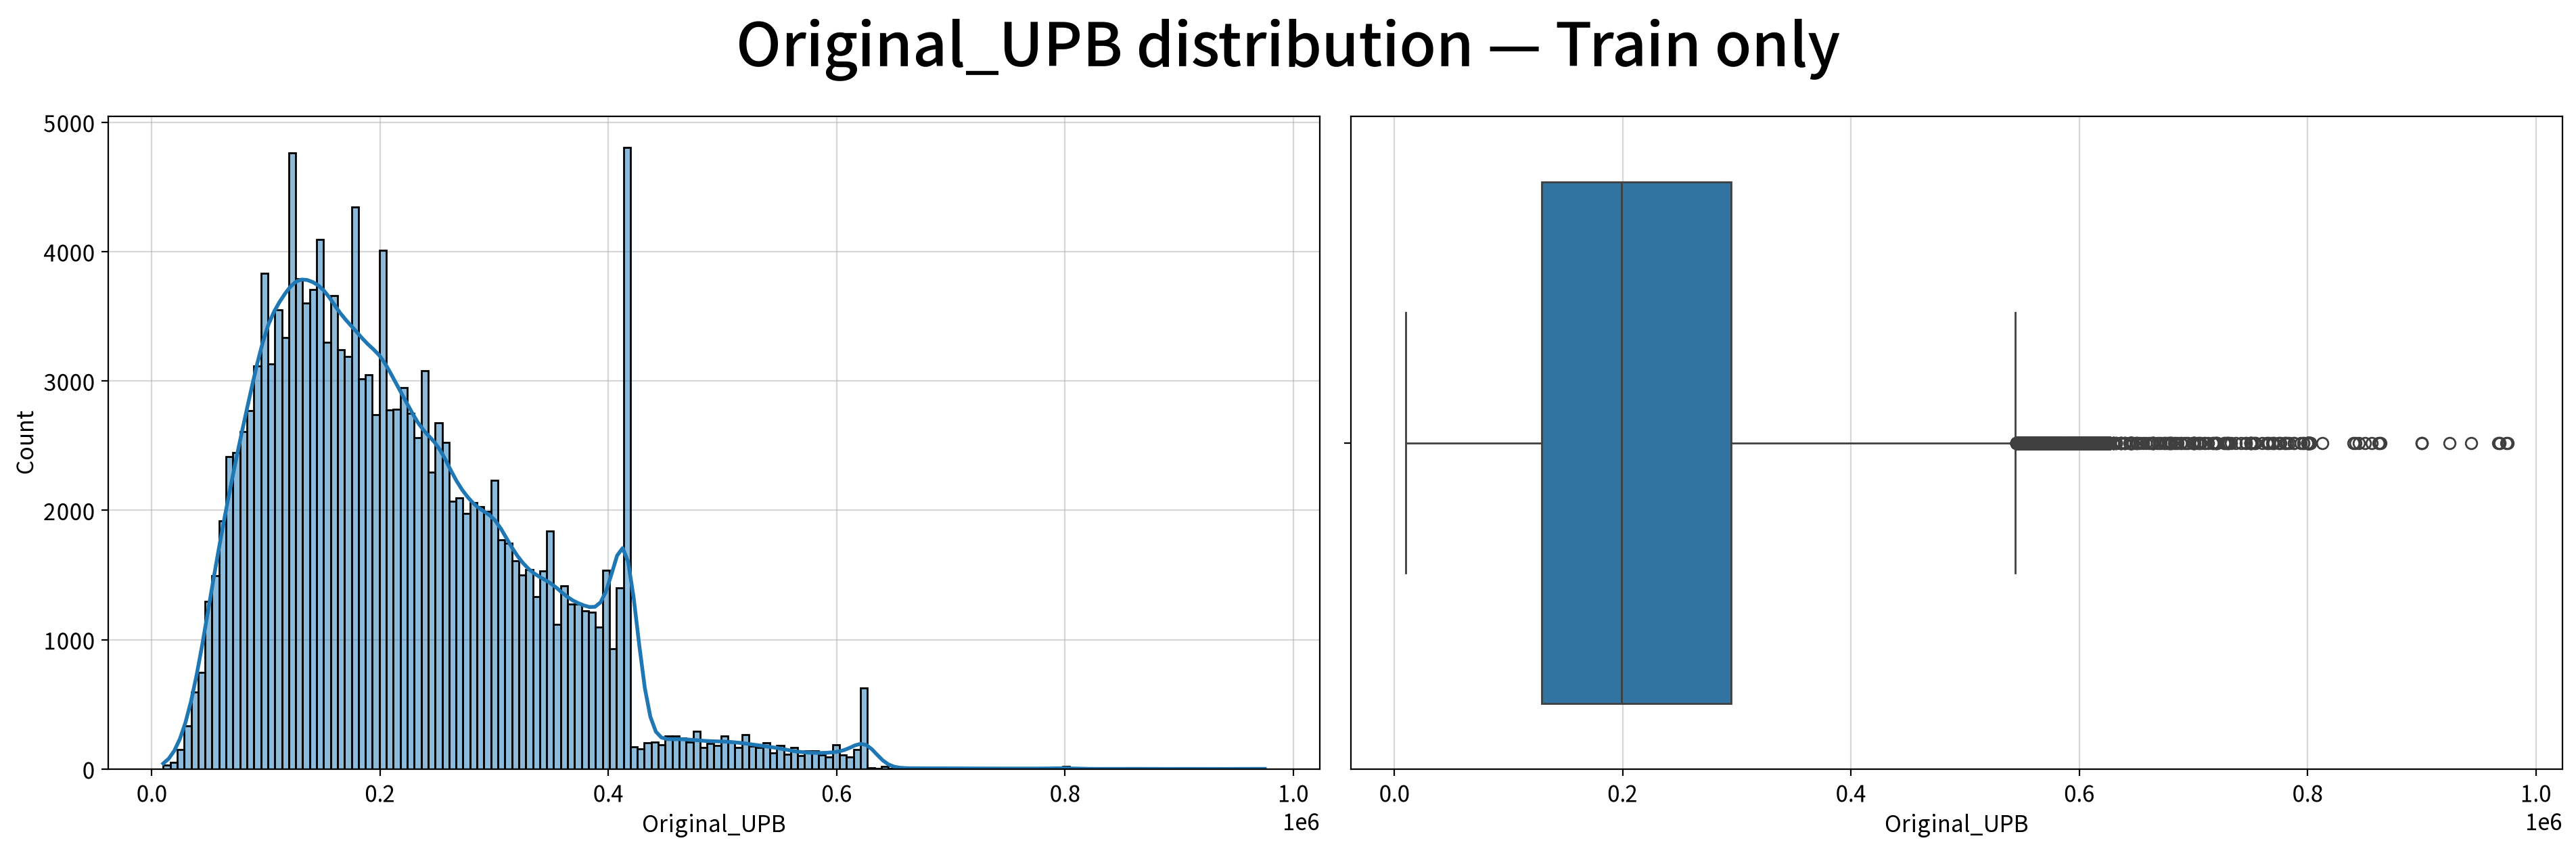

### Original_LTV — Train distribution

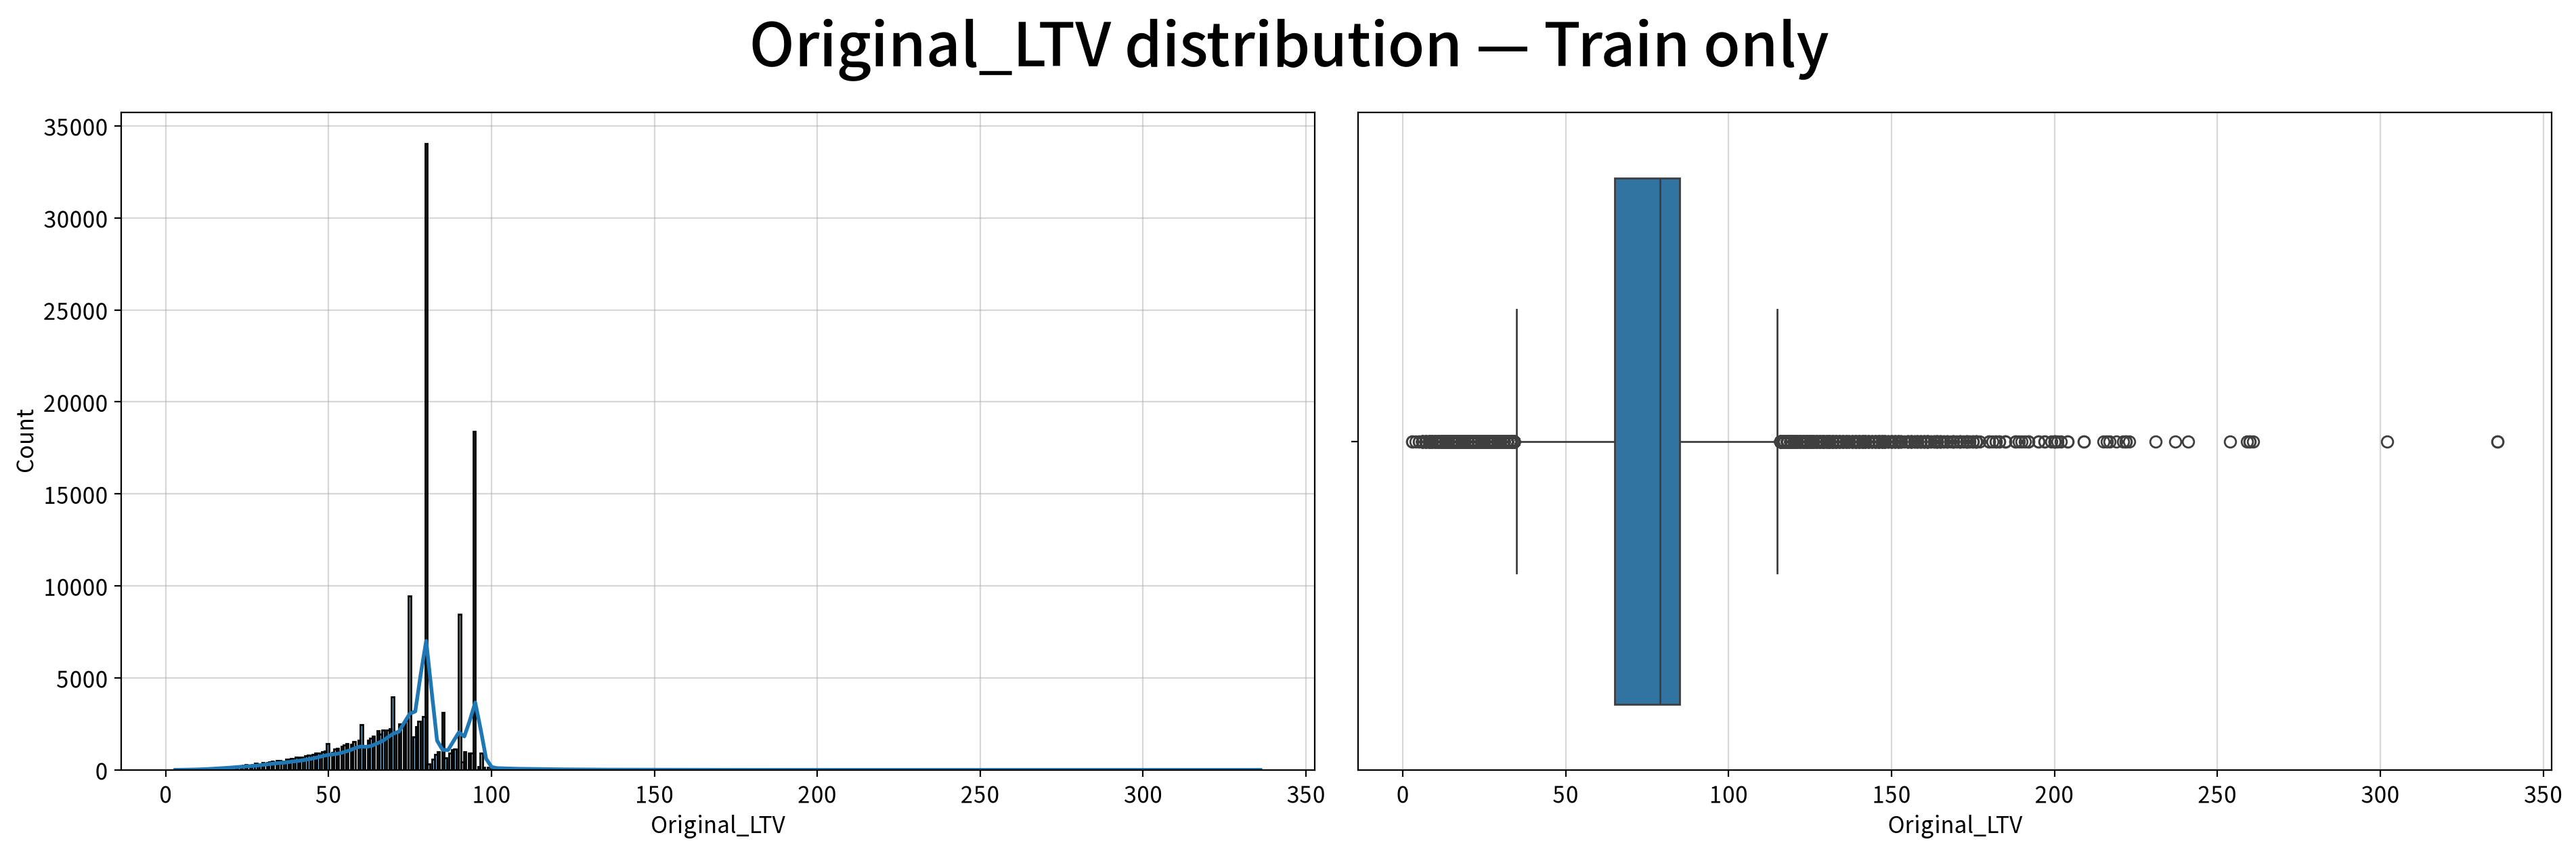

### Original_Interest_Rate — Train distribution

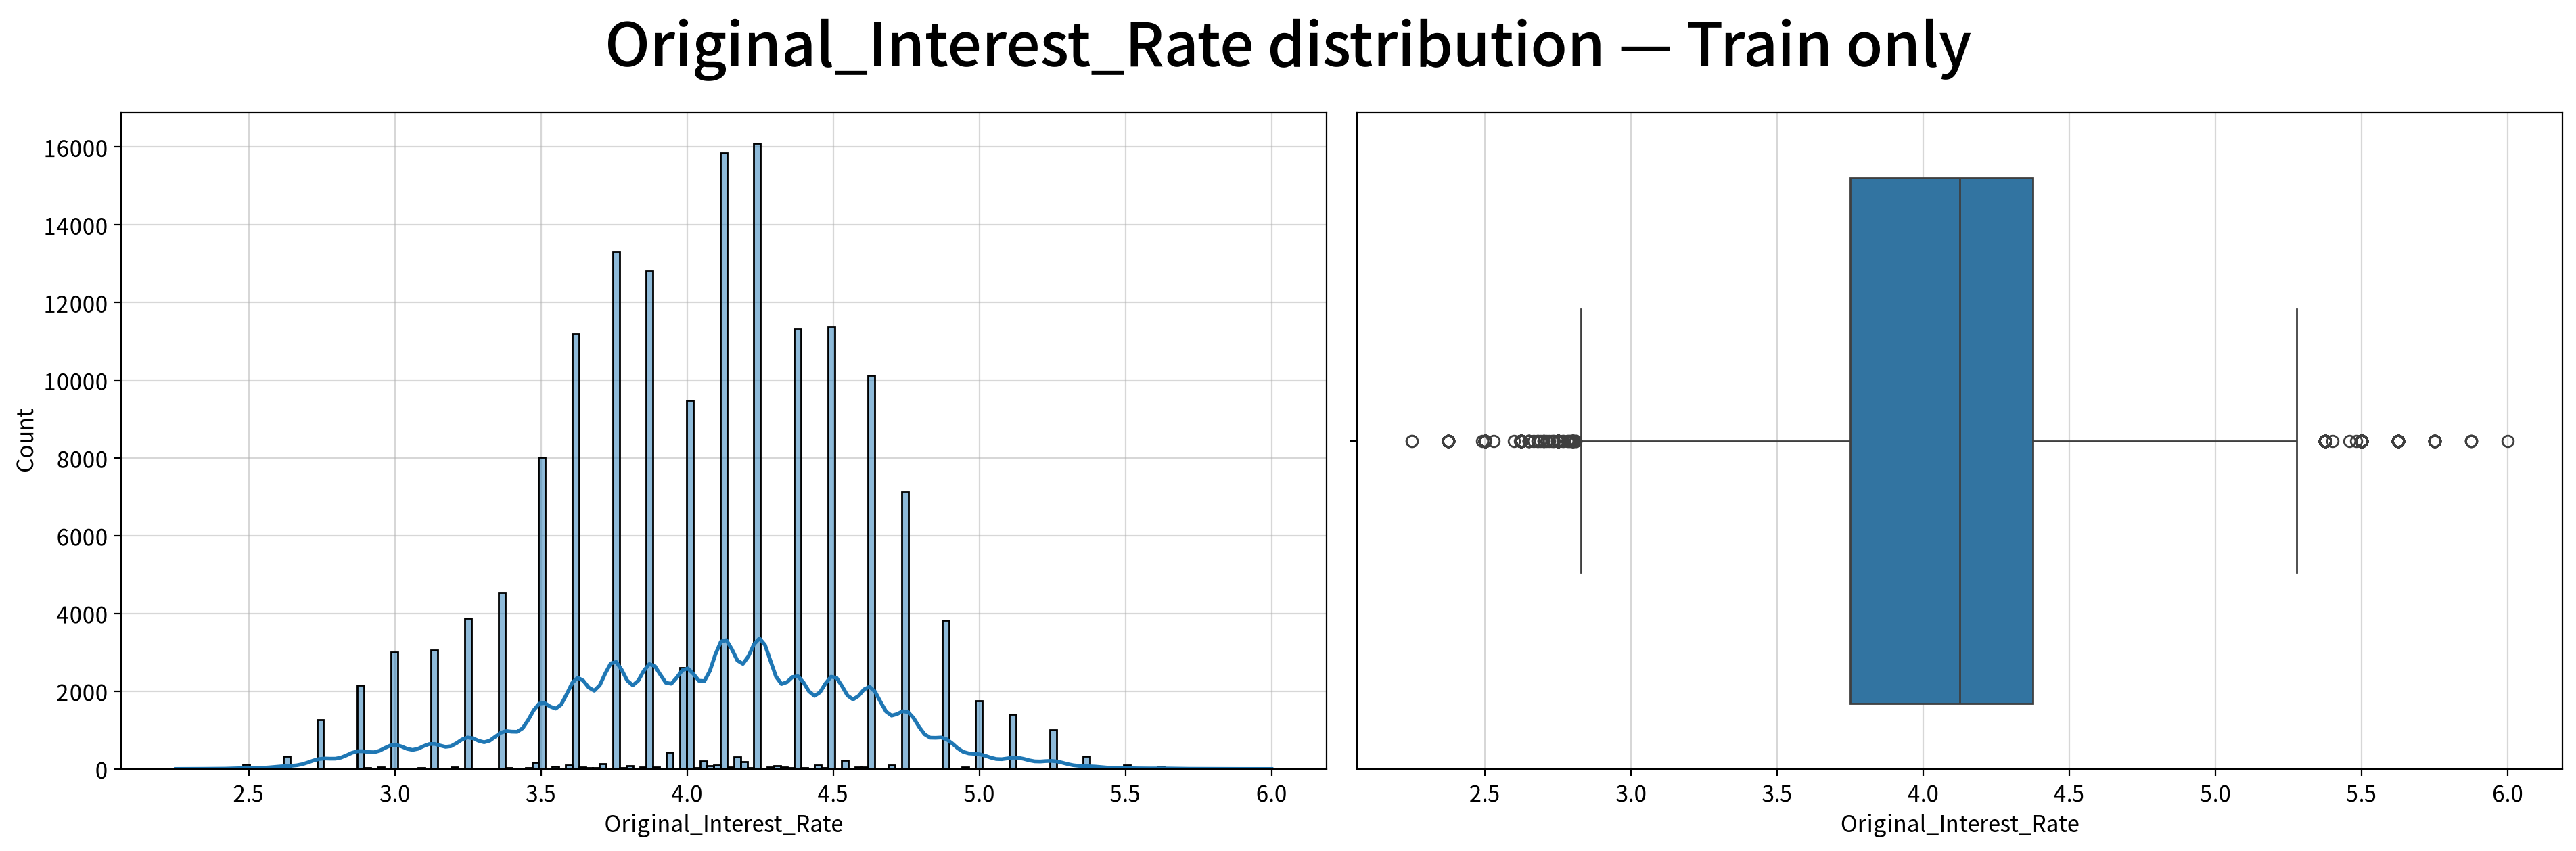

### Original_Loan_Term — Train distribution

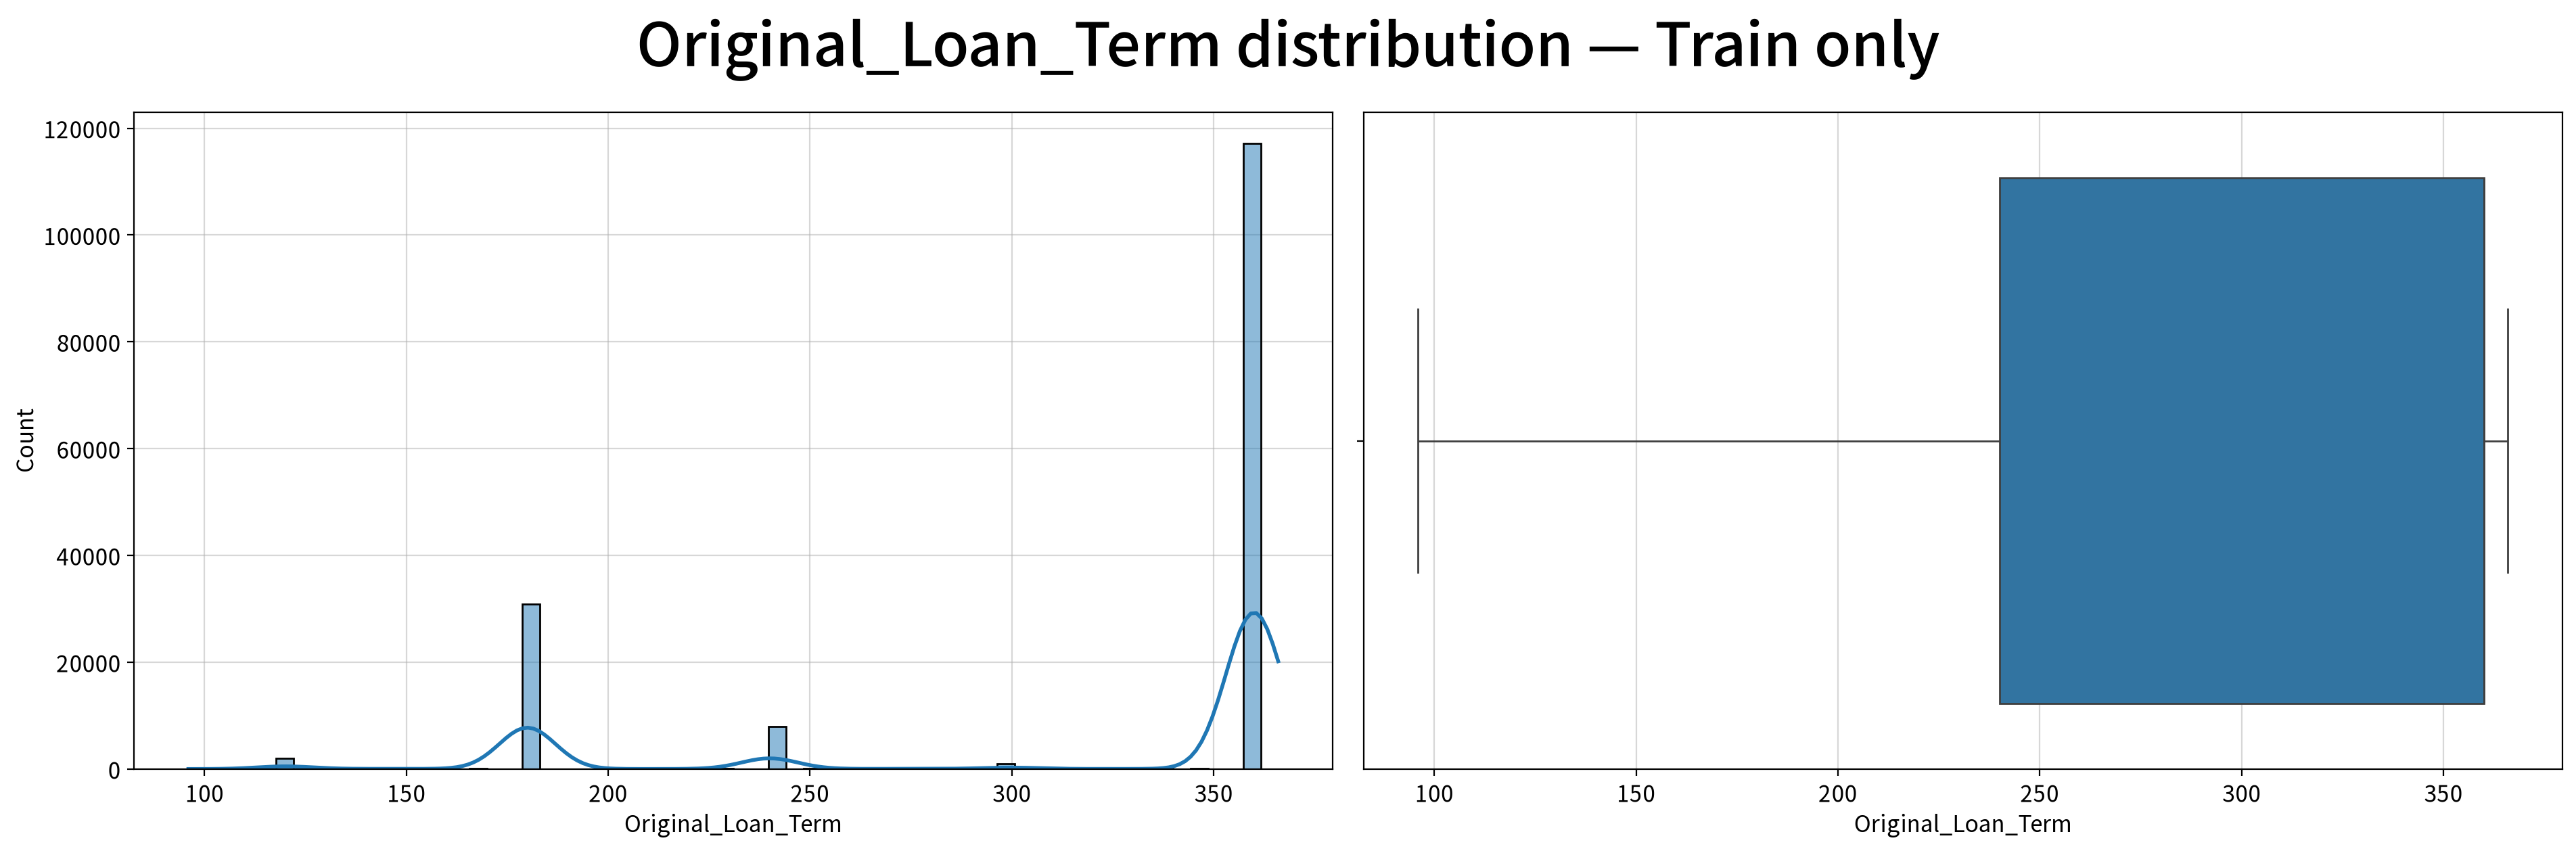

### Number_of_Borrowers — Train distribution

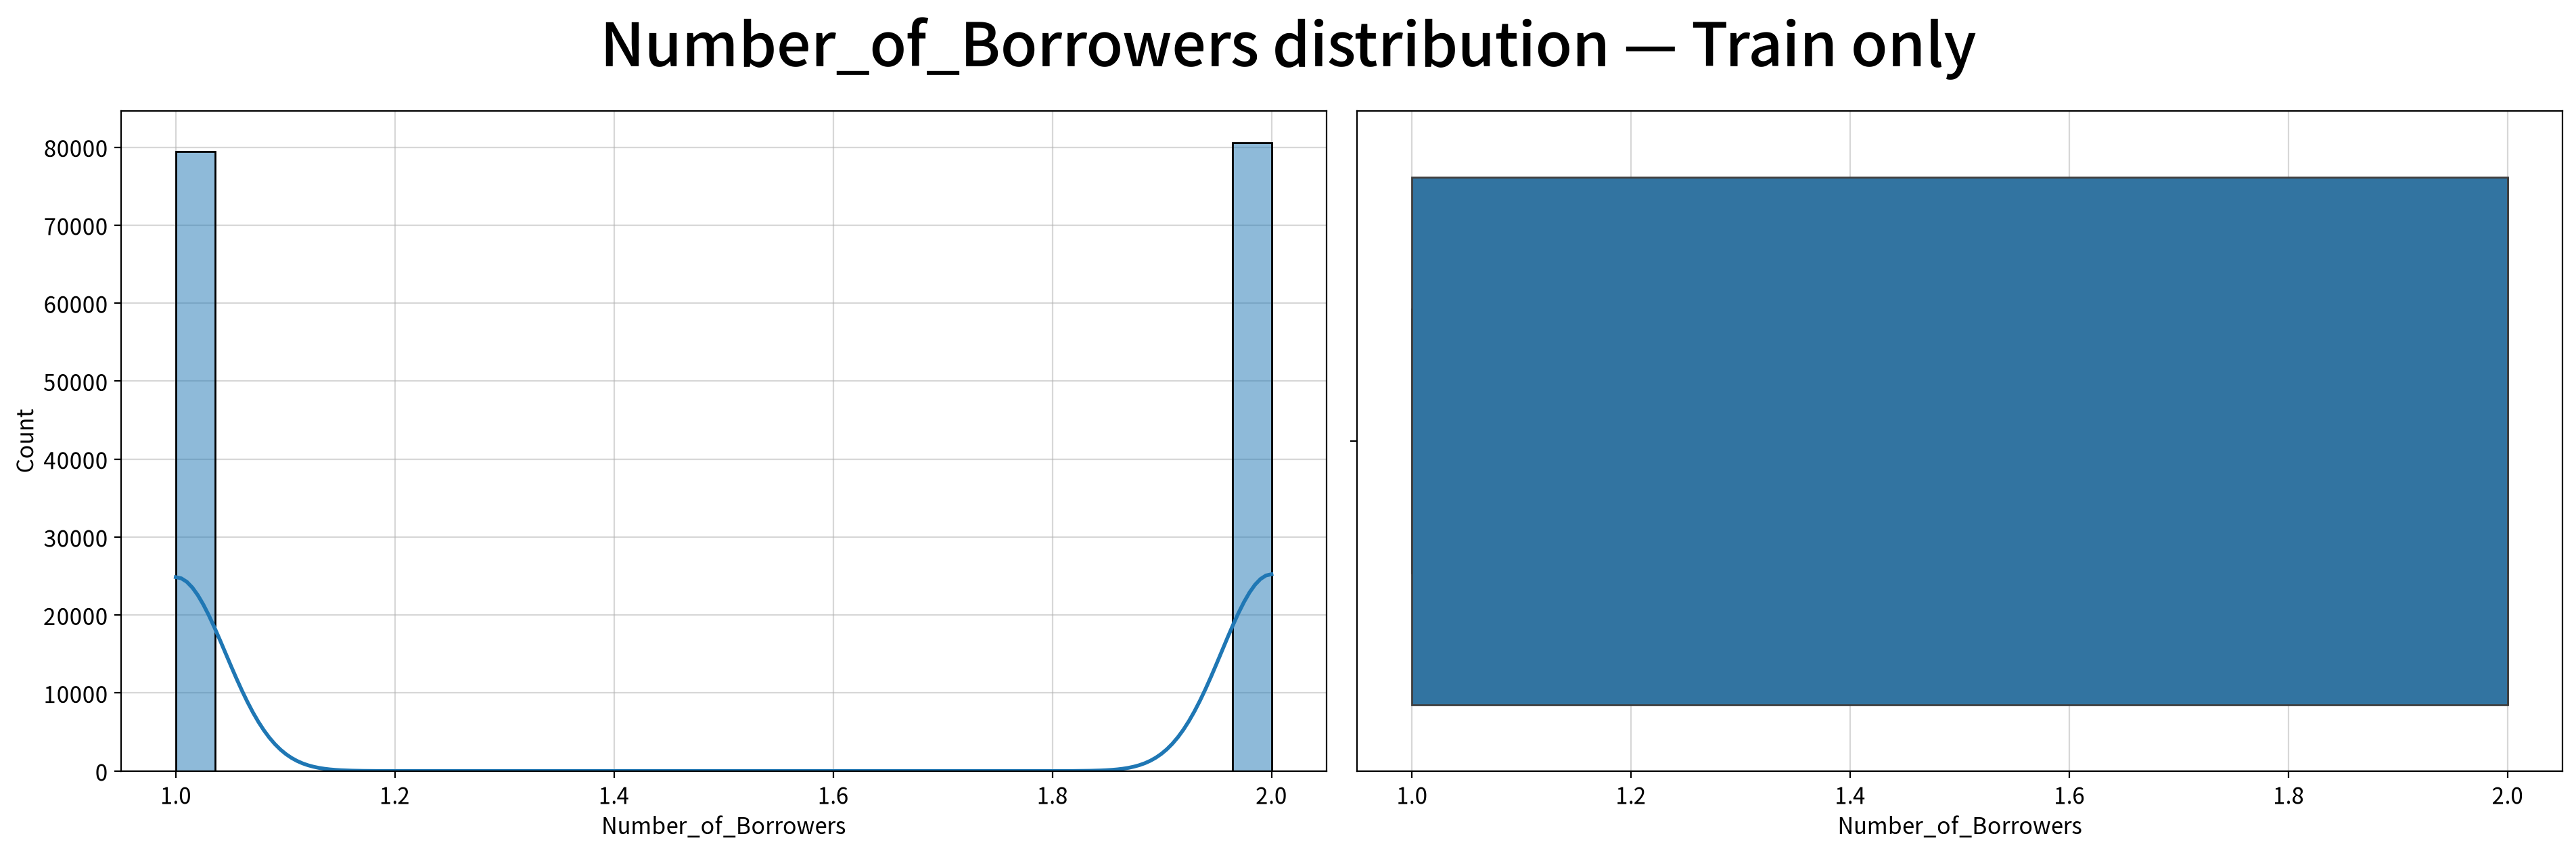

### CLTV_LTV_Gap — Train distribution

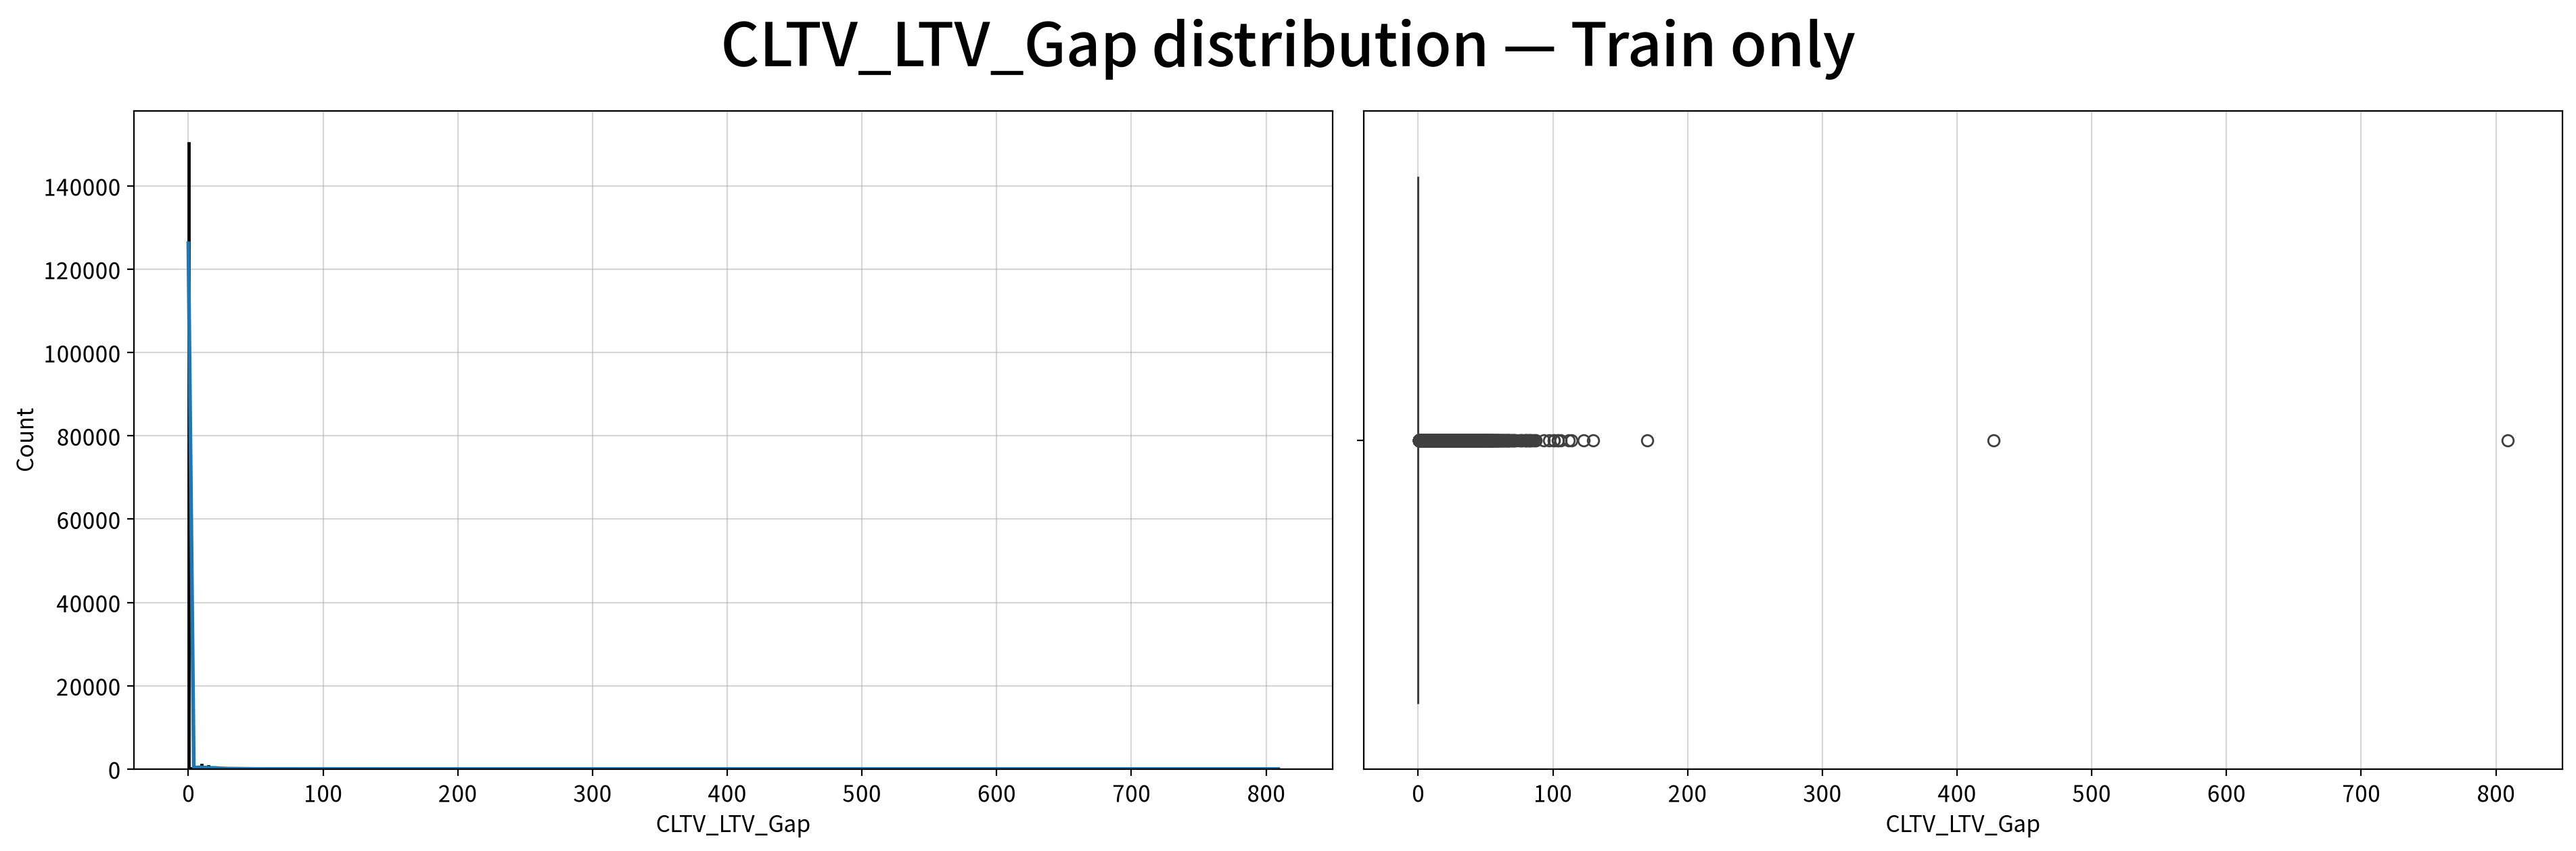

### DTI_LTV_Interaction — Train distribution

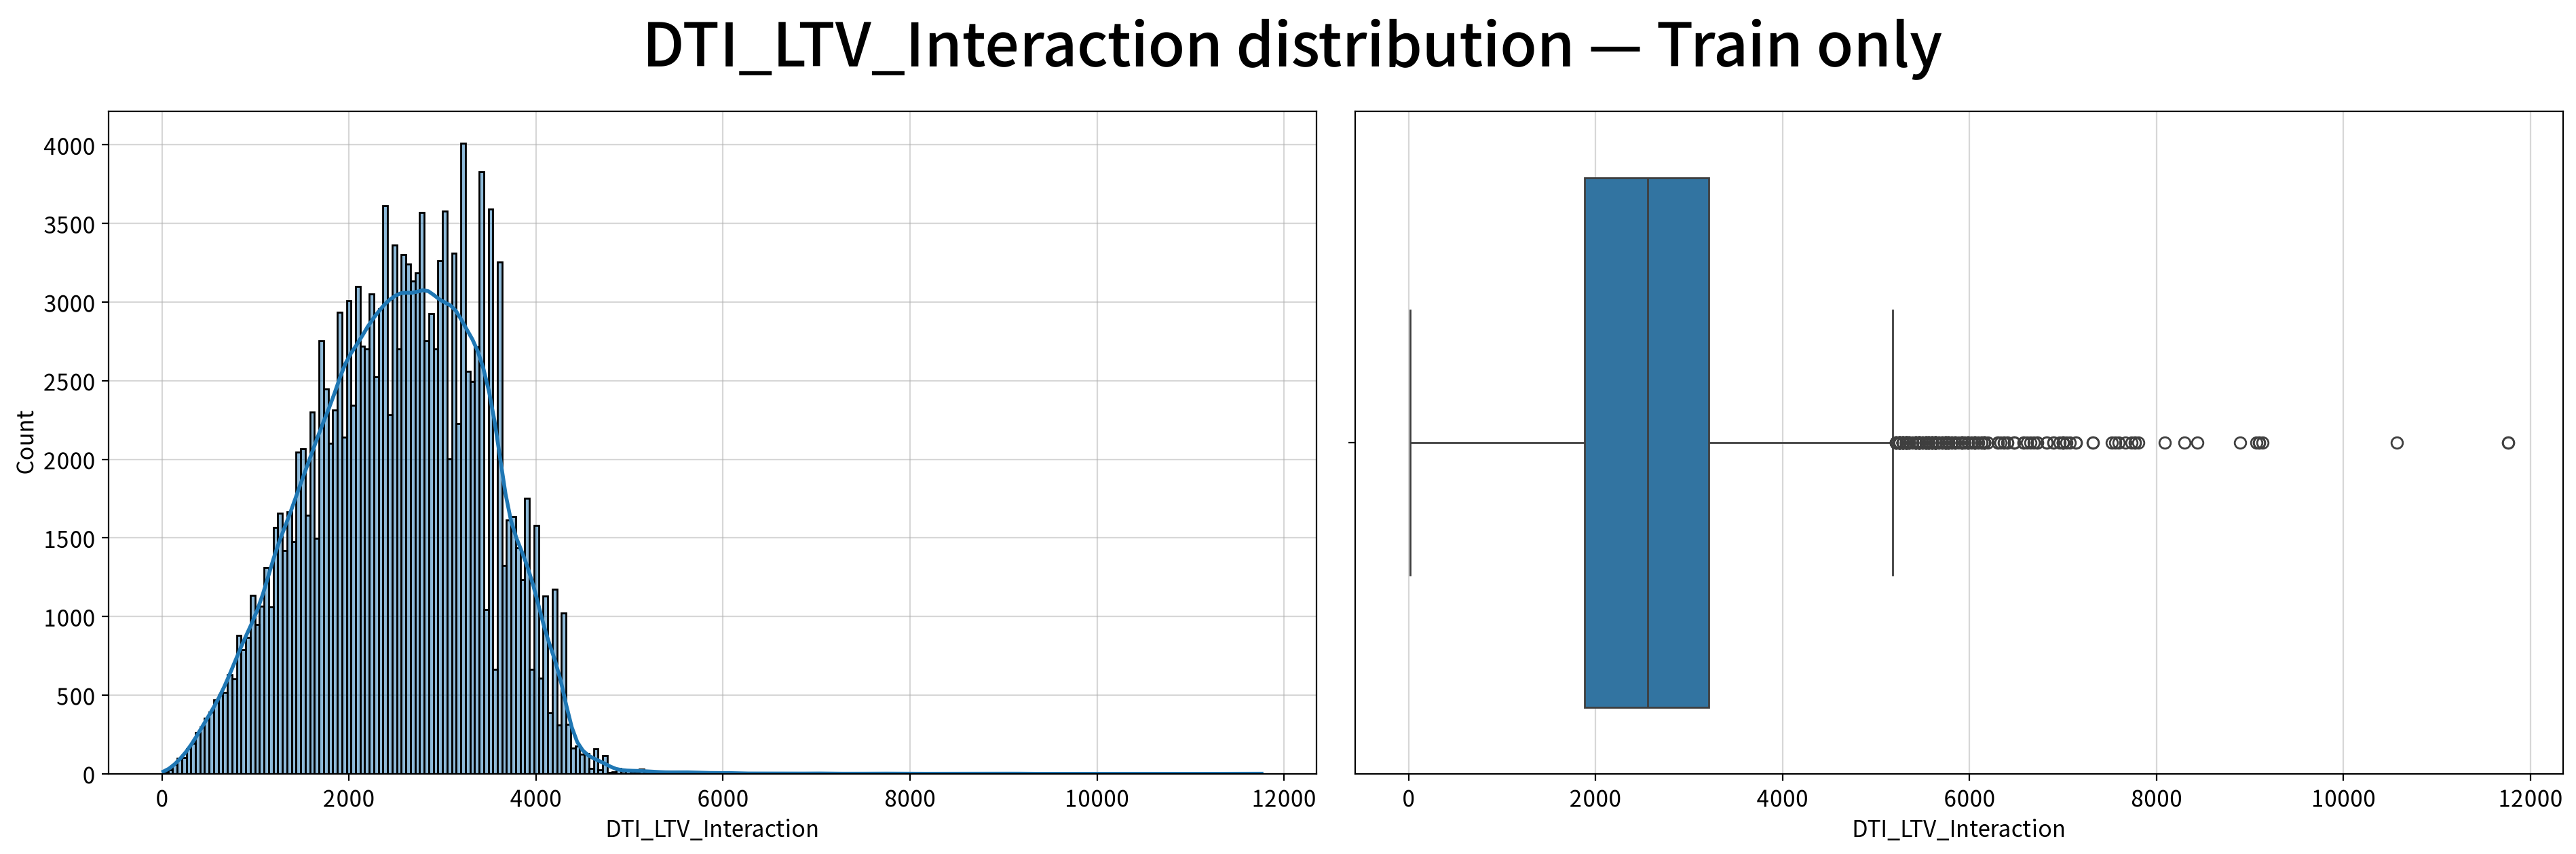

### DTI_Rate_Interaction — Train distribution

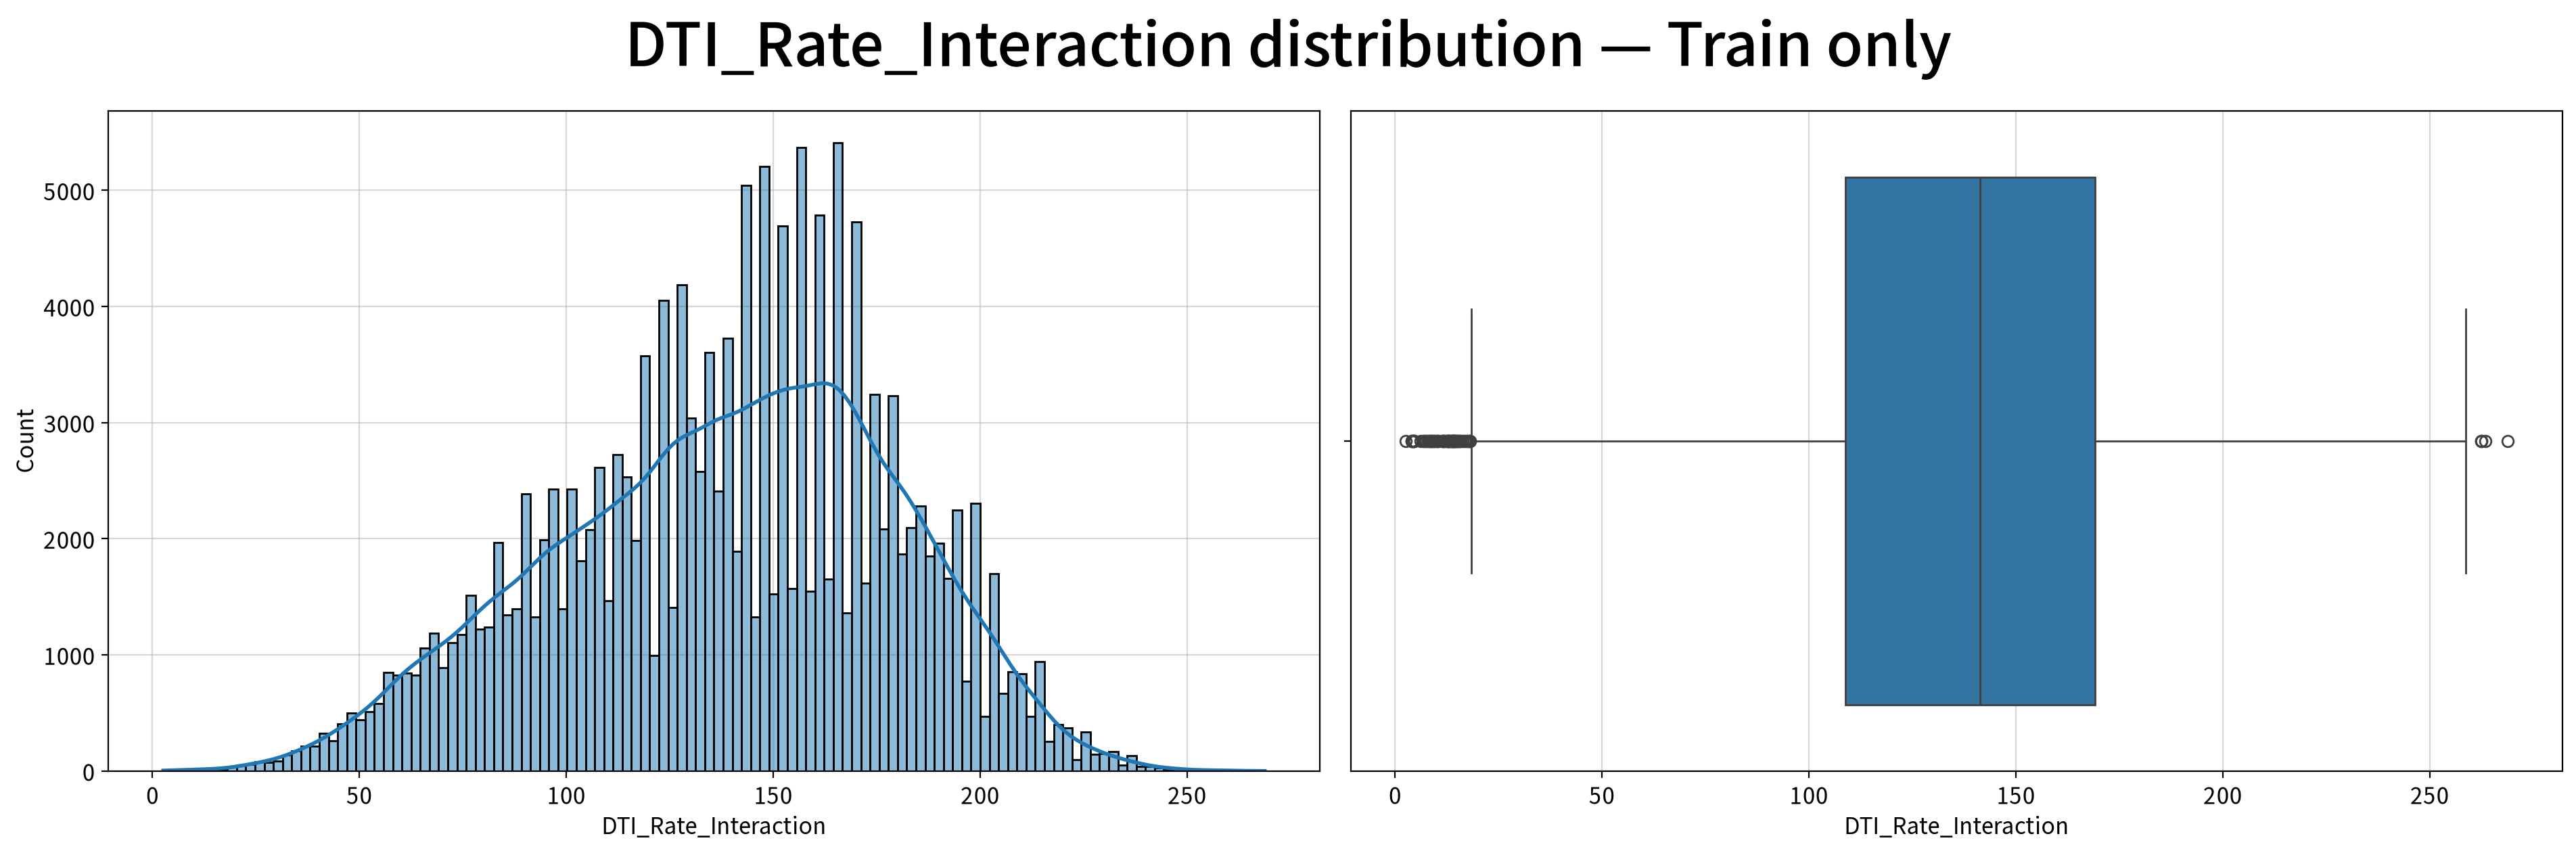

### UPB_per_Borrower — Train distribution

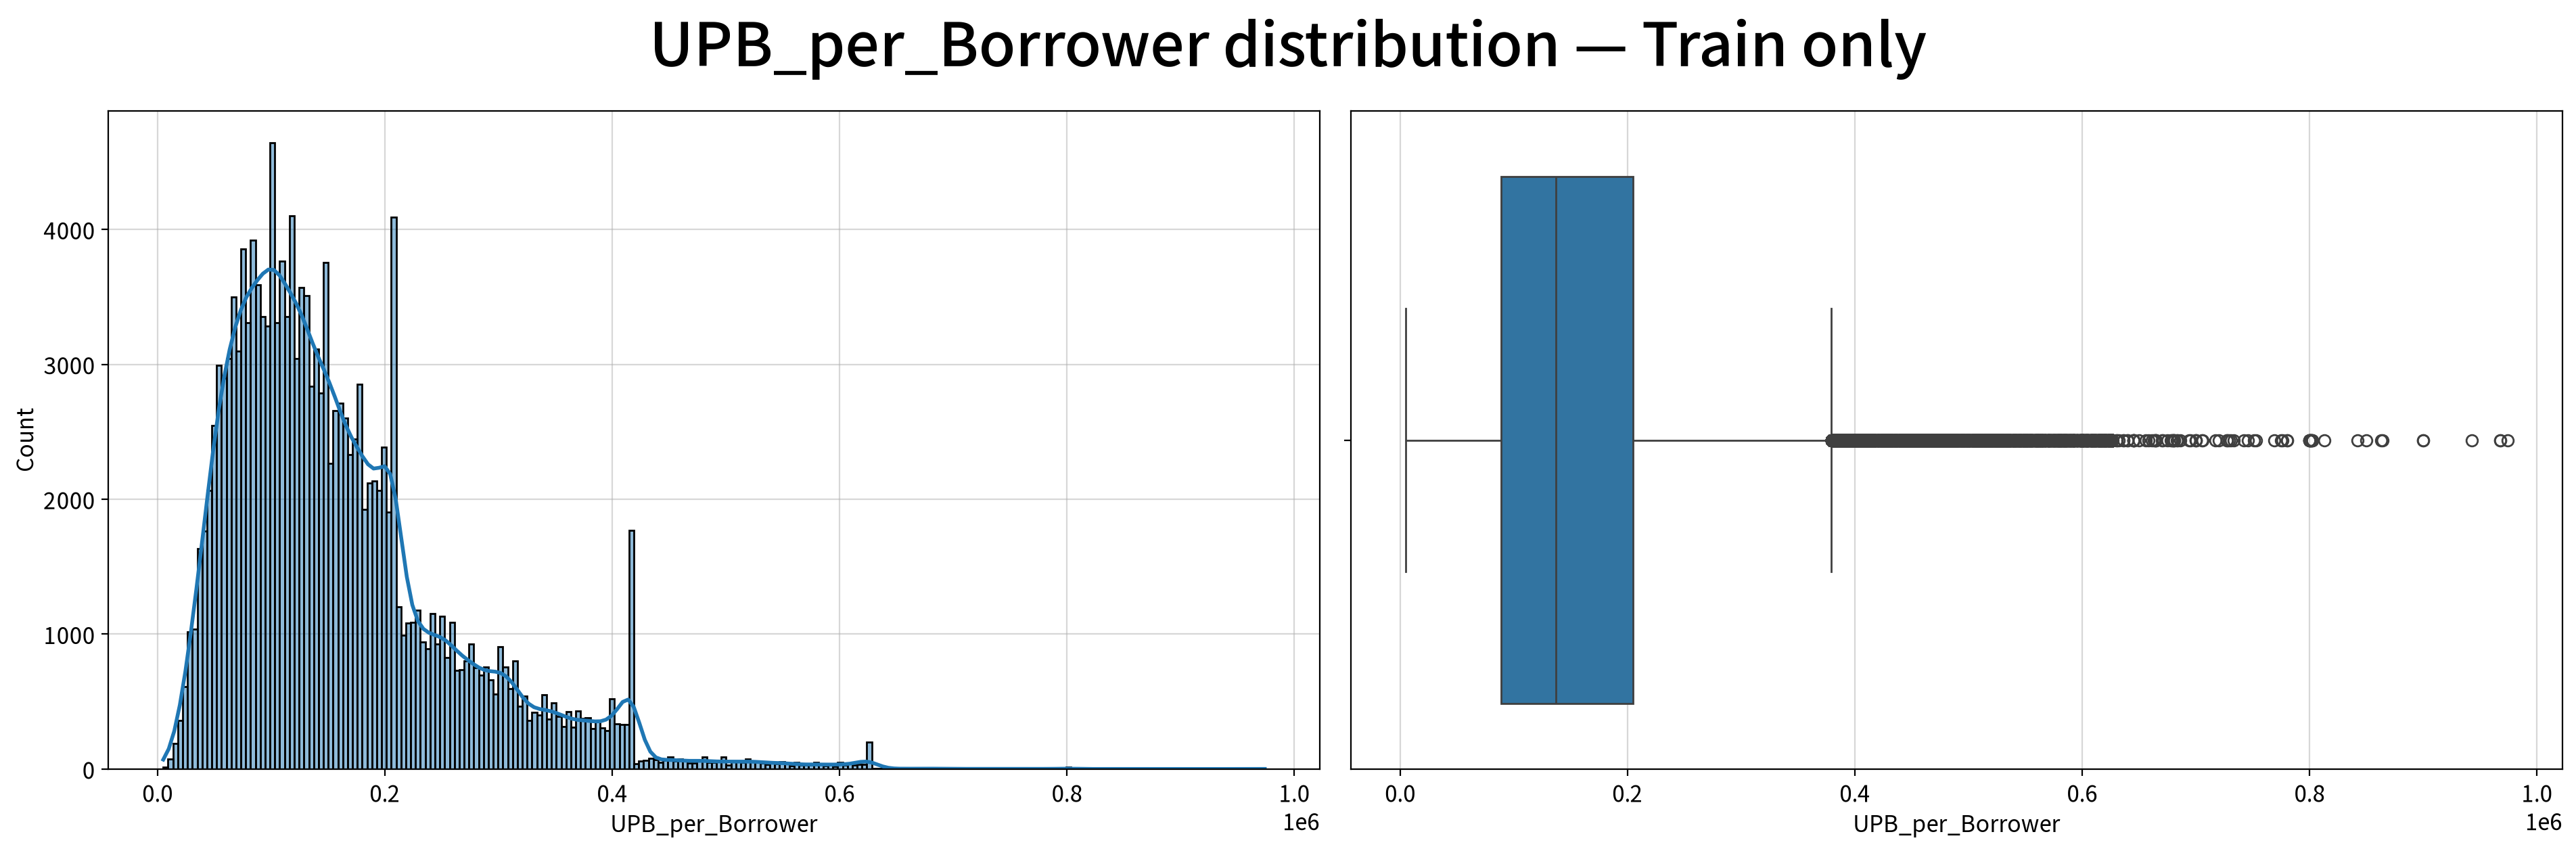

### Estimated_Monthly_PI — Train distribution

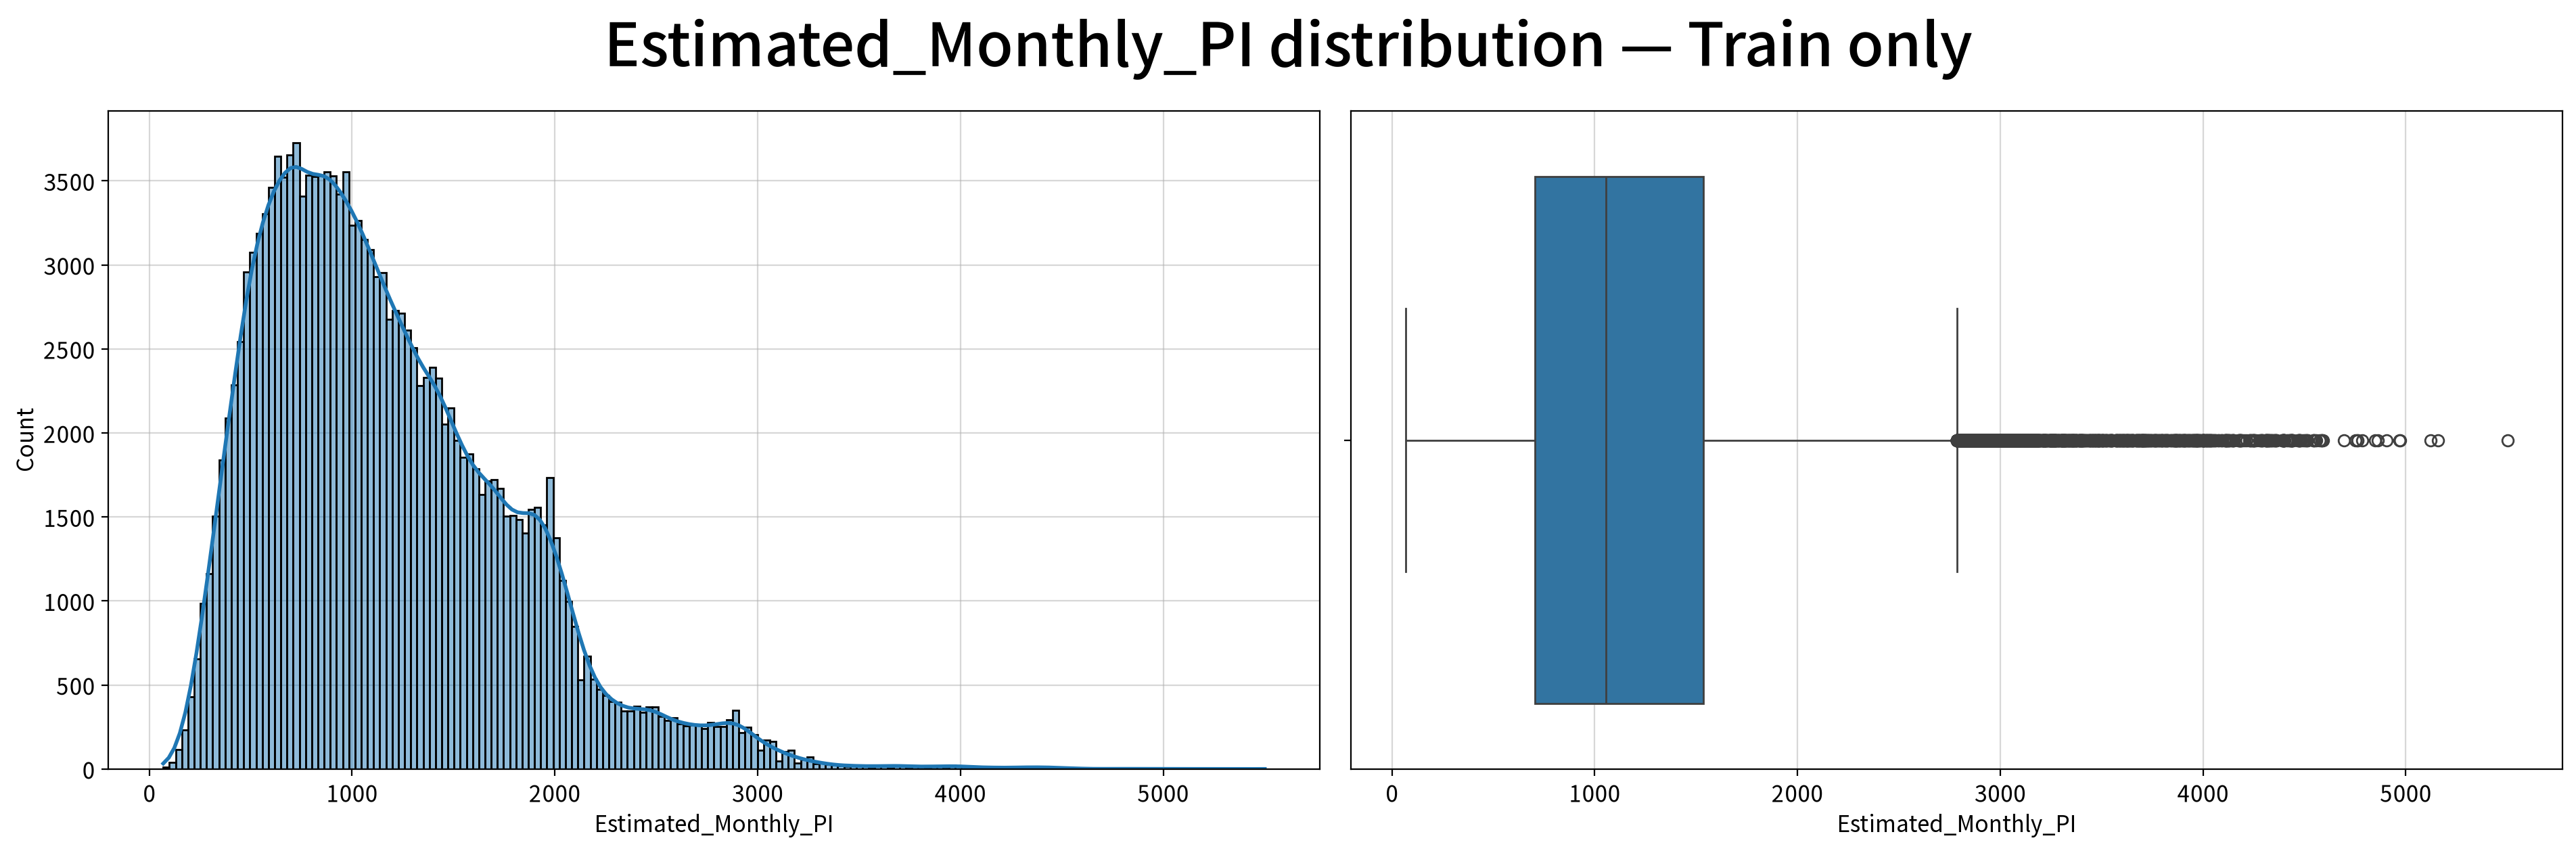

### FICO_DTI_Interaction — Train distribution

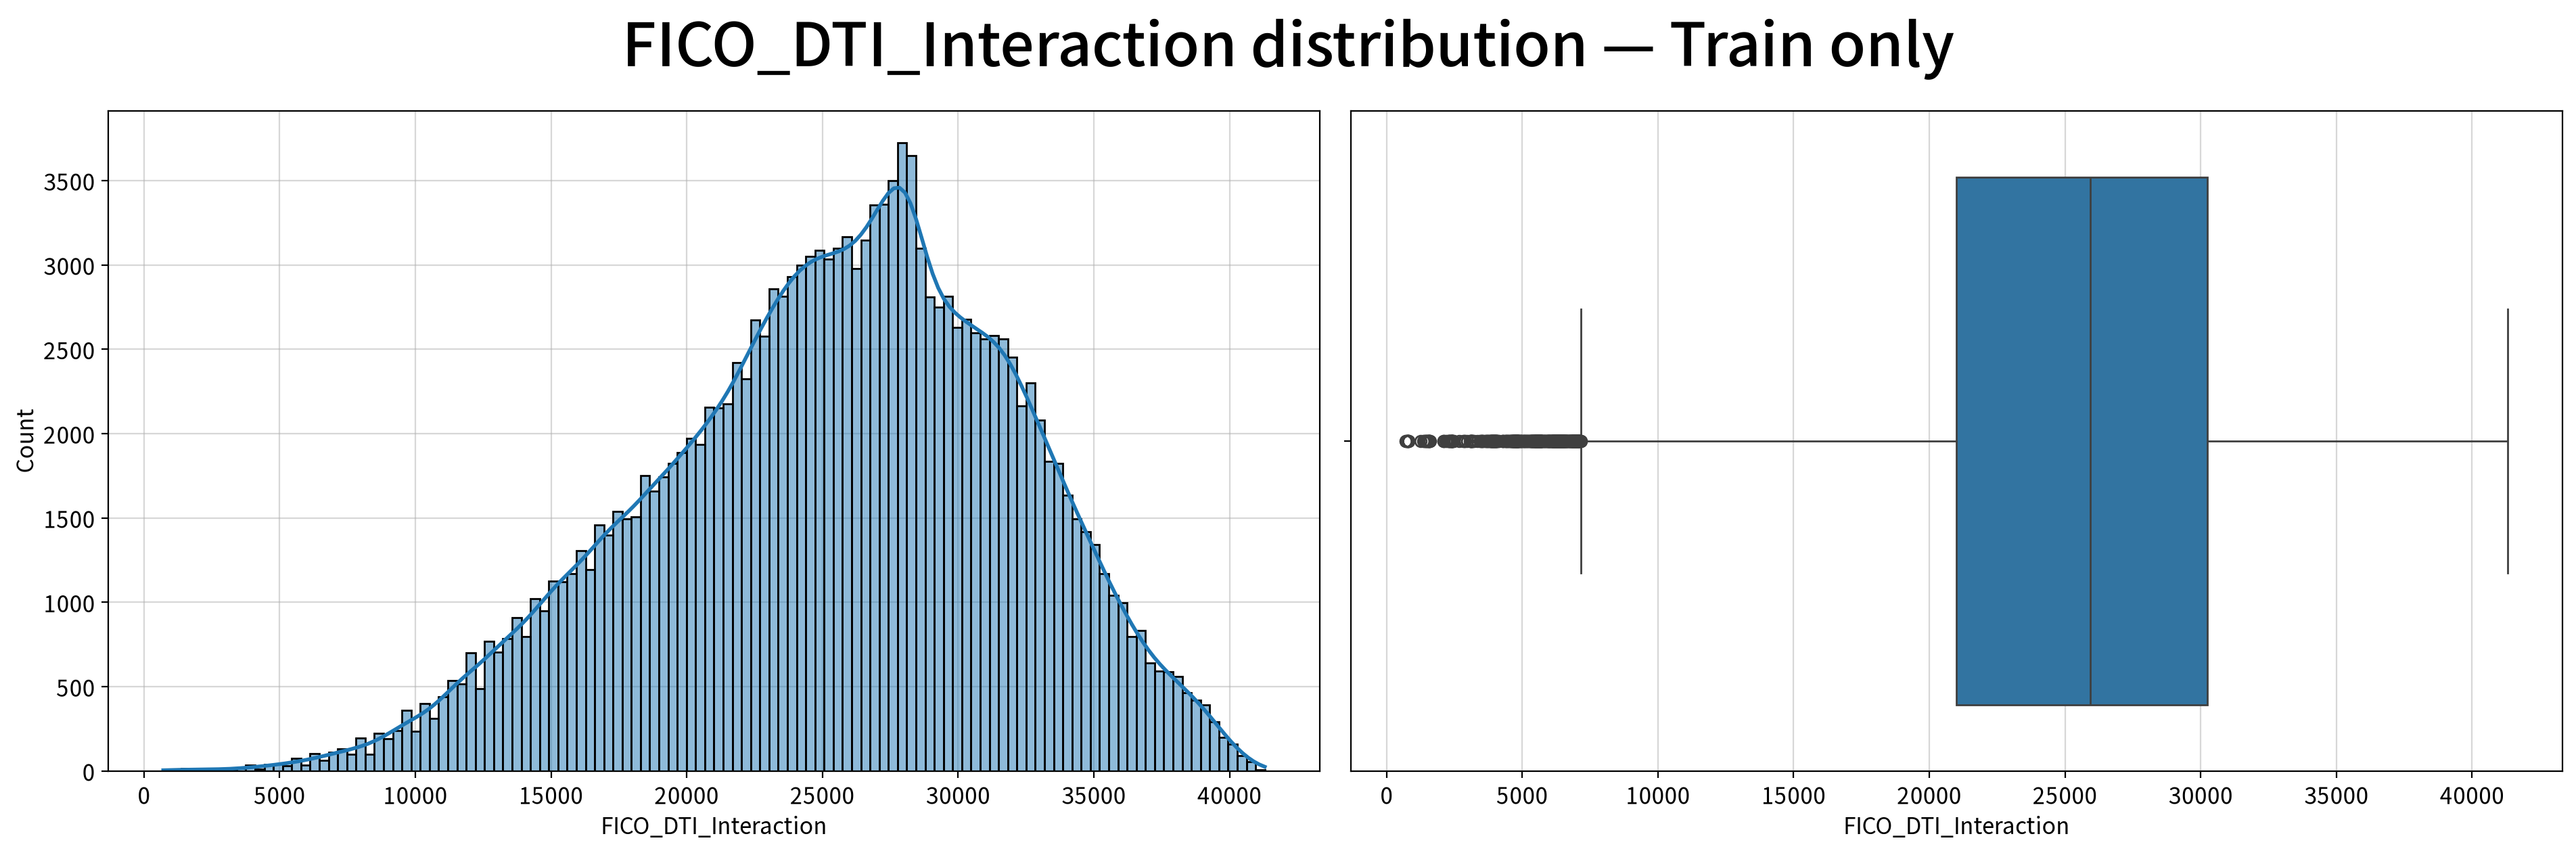

### FICO_LTV_Interaction — Train distribution

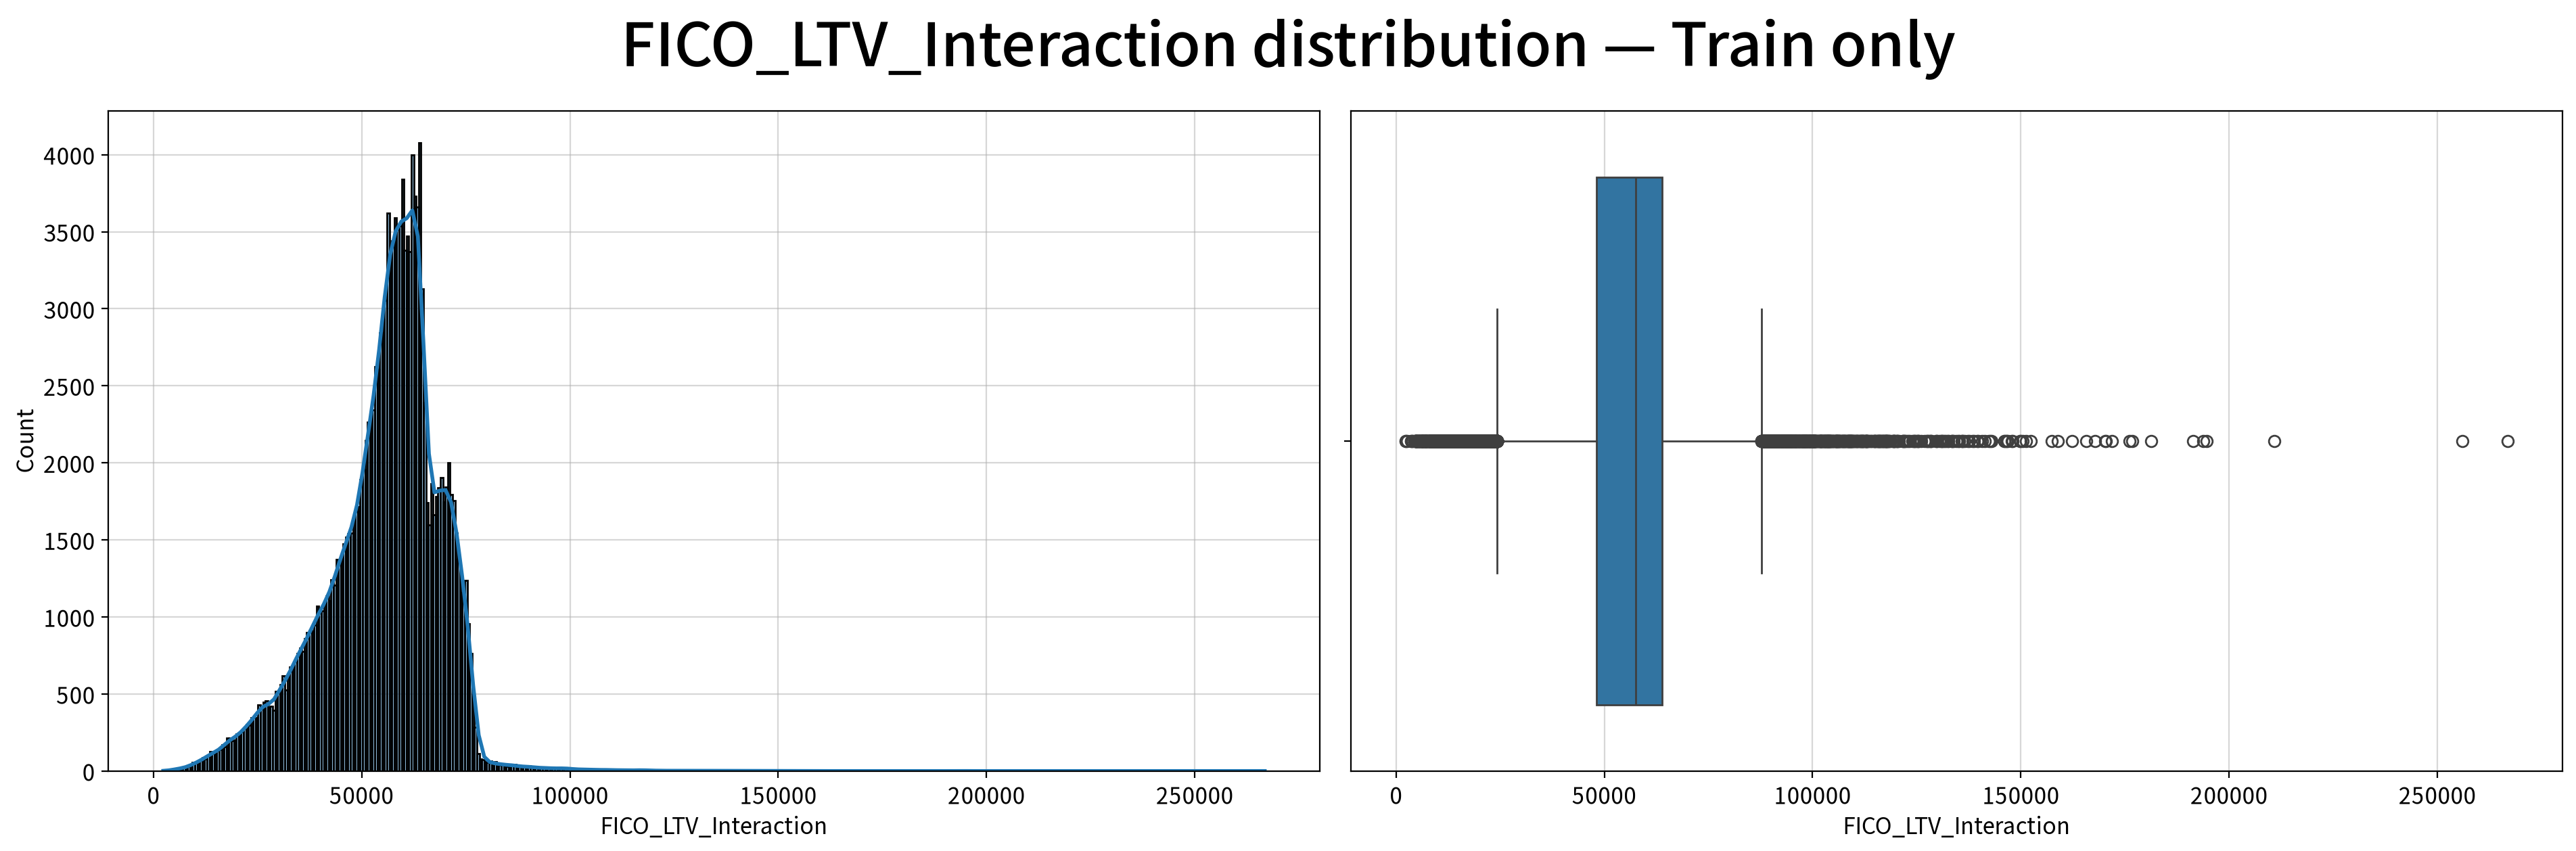

### Housing_HPI — Train distribution

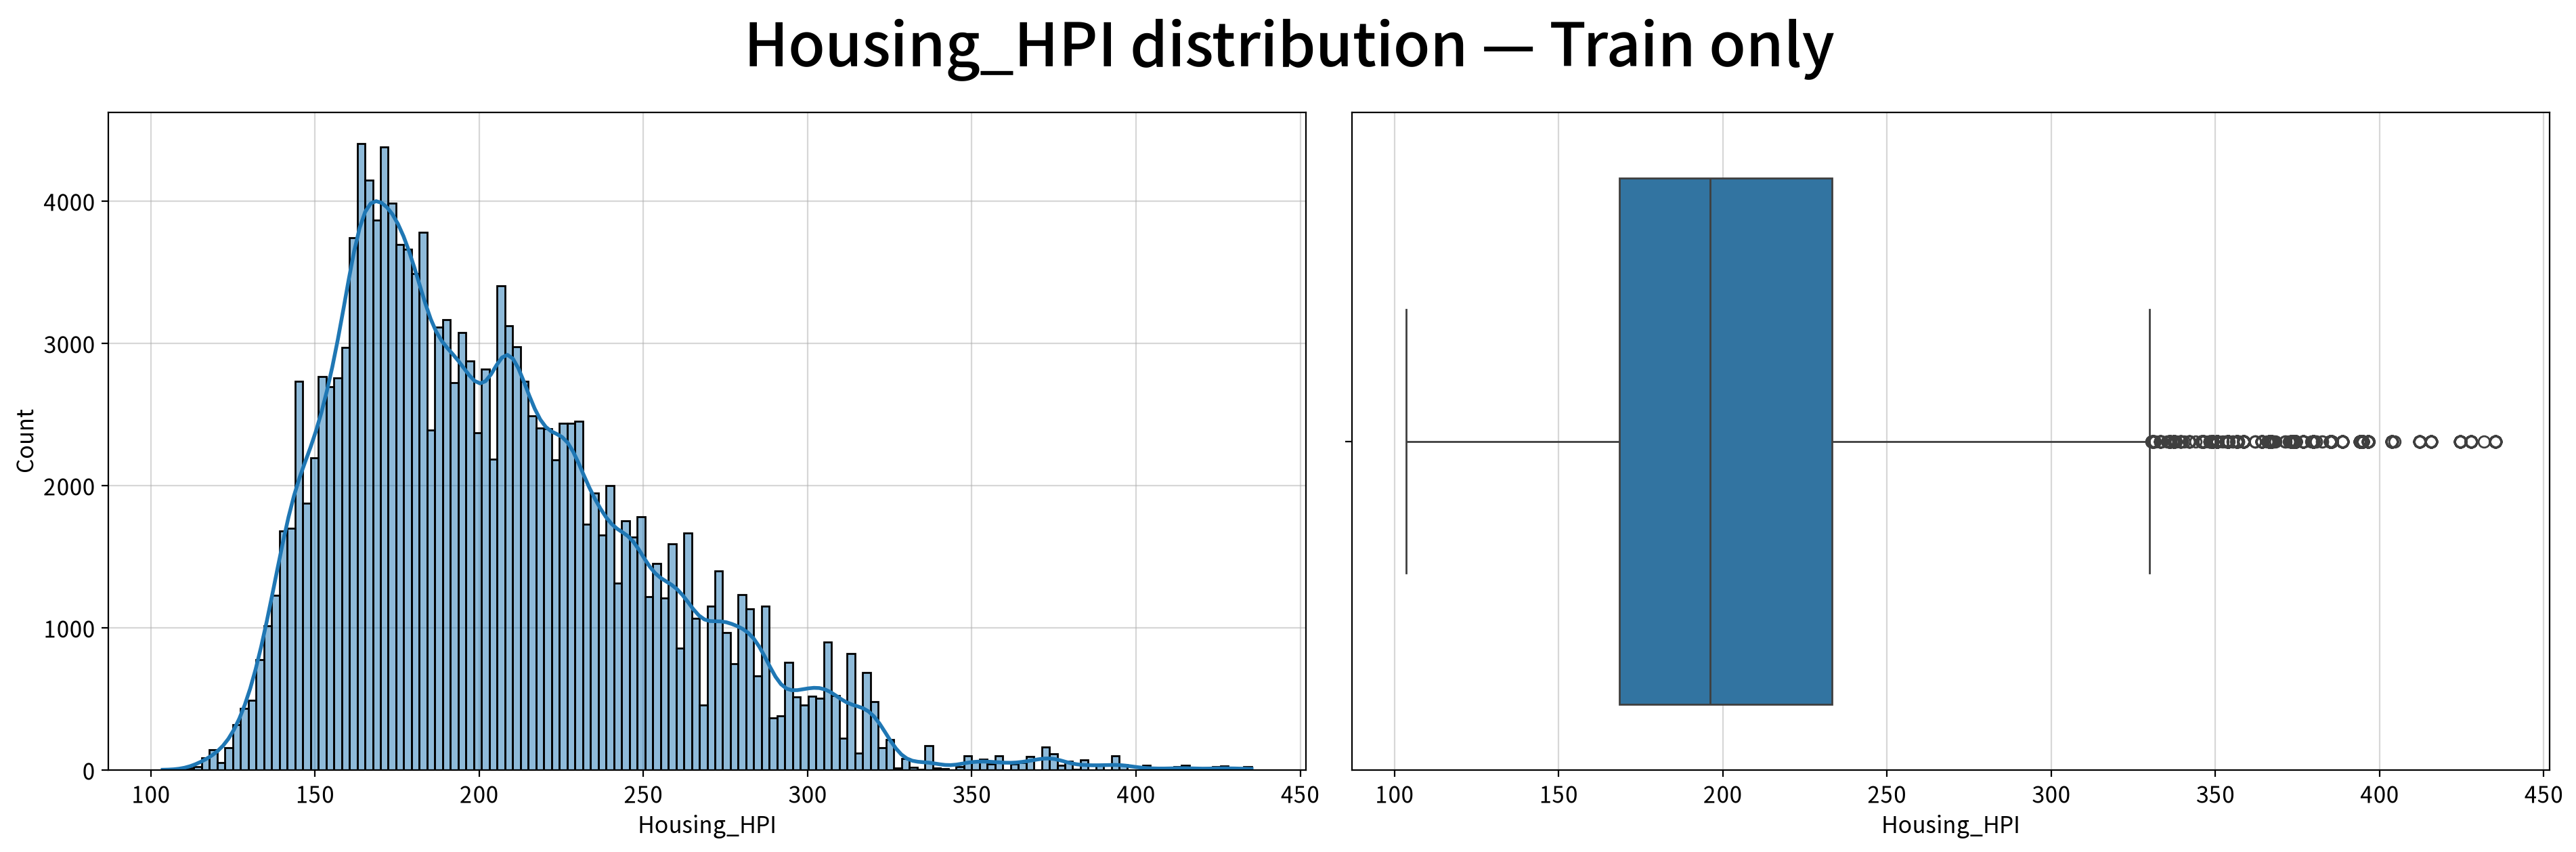

### Housing_HPI_Growth_12M — Train distribution

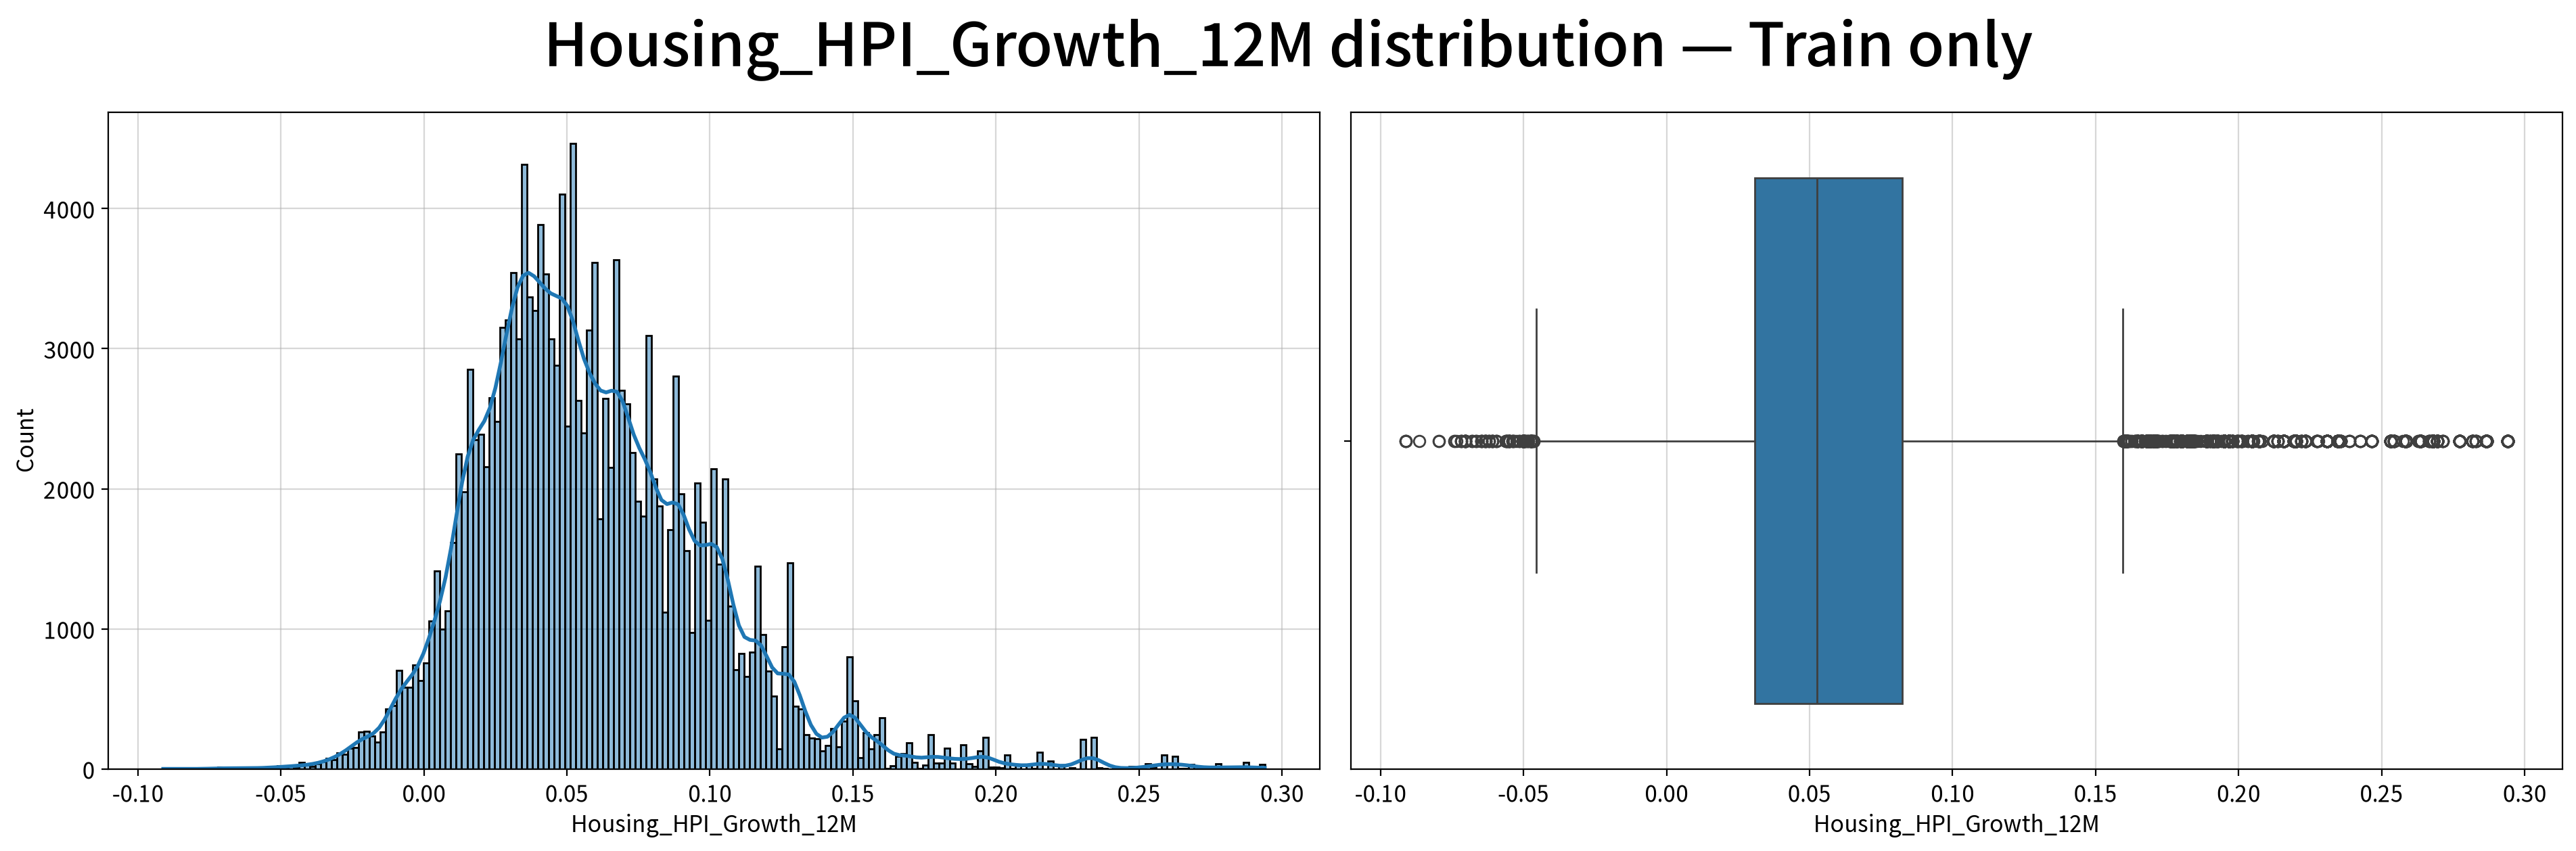

### BLS_Unemployment_Rate_Final — Train distribution

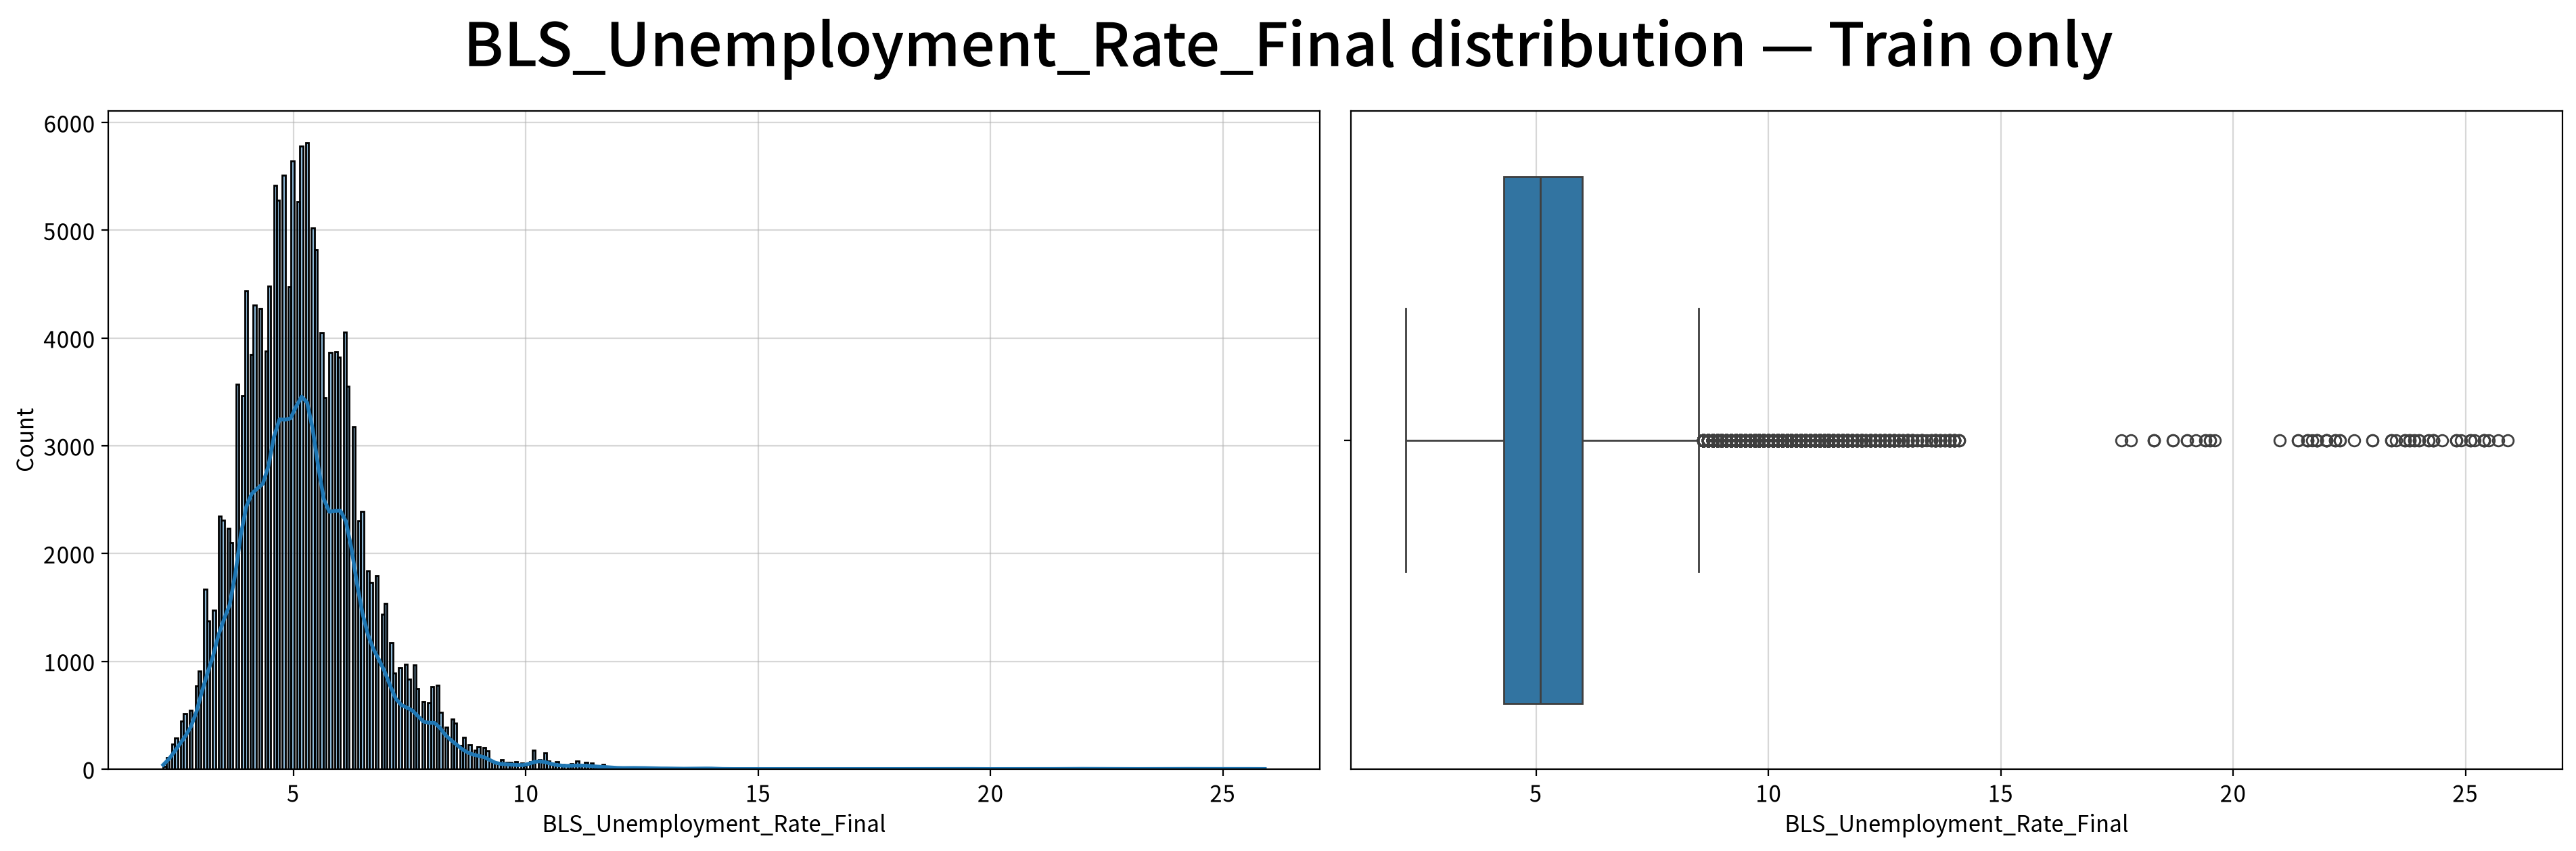

### BLS_Employment_Growth_12M_Final — Train distribution

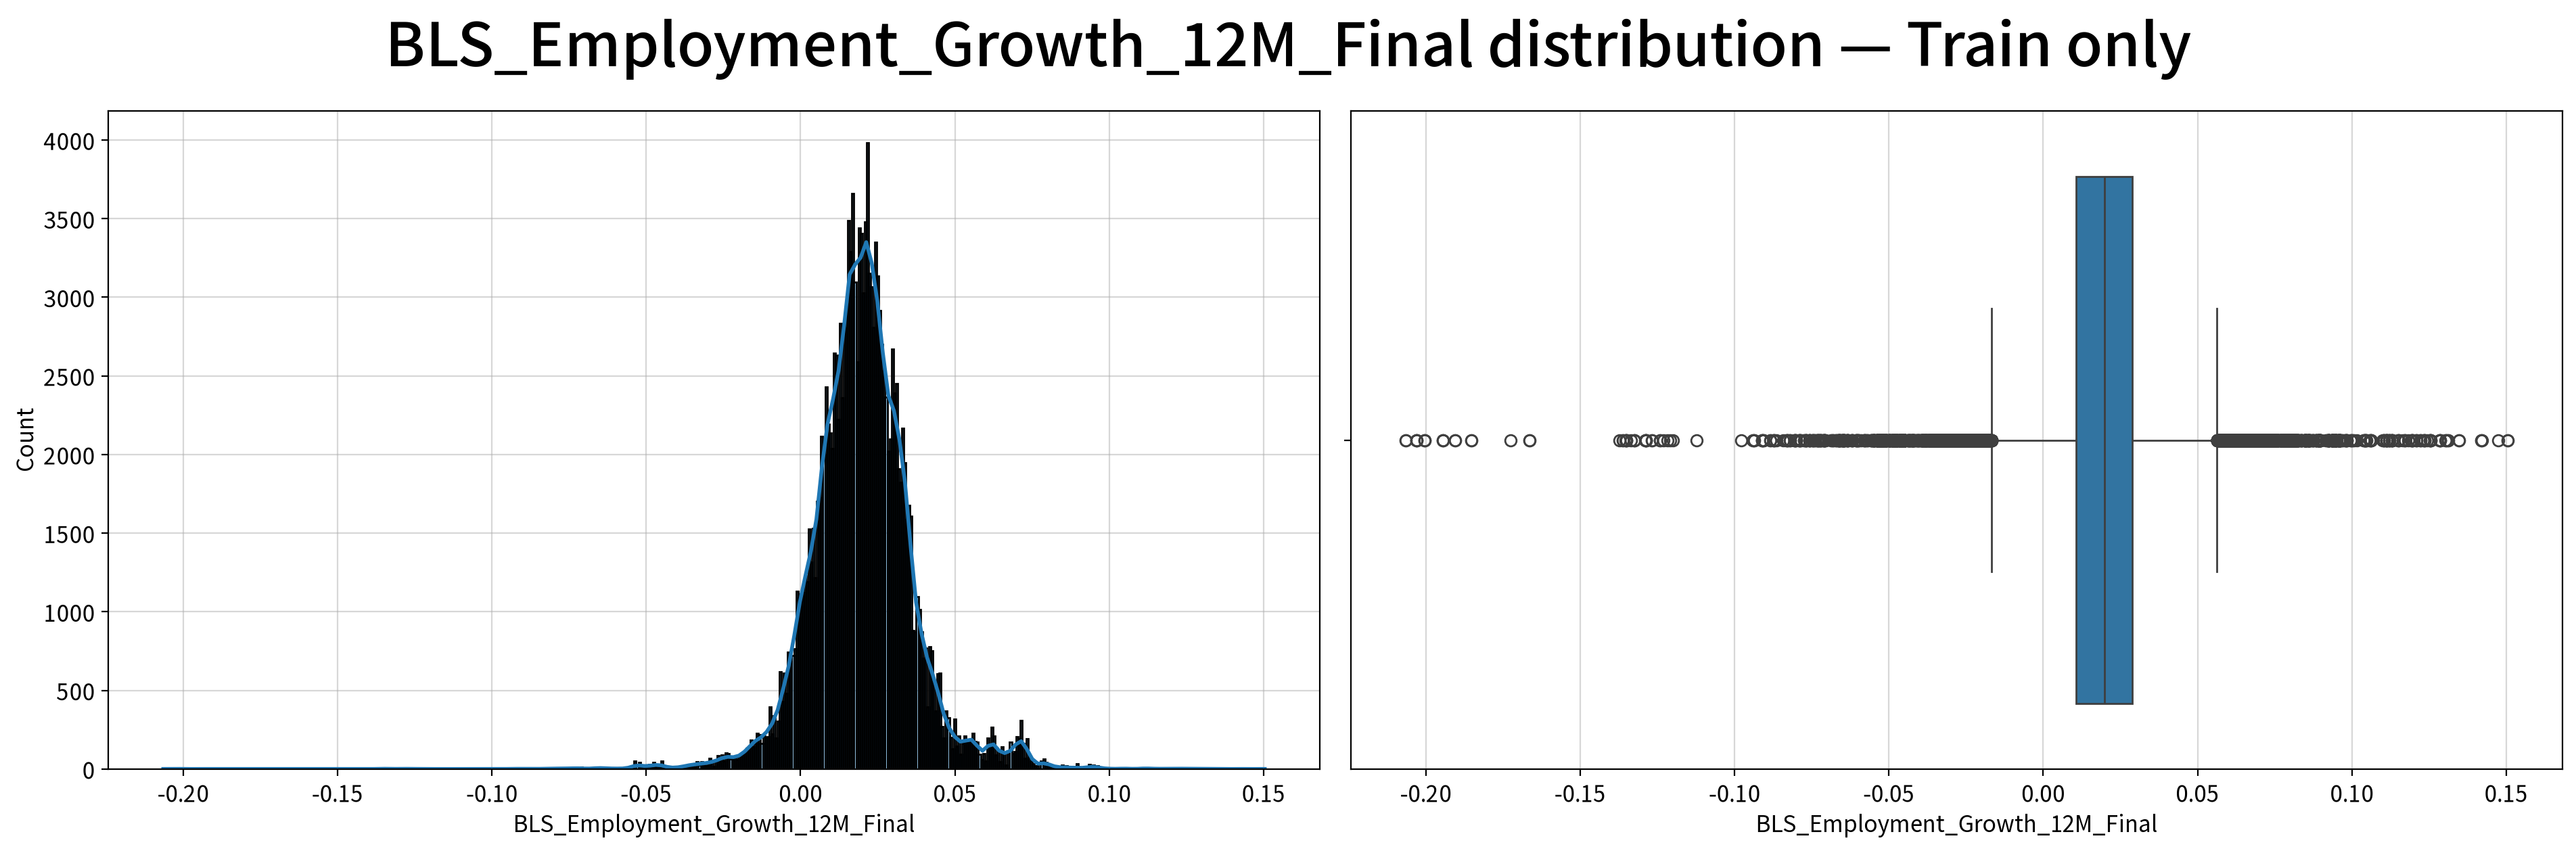

### BLS_Unemployment_Rate_Change_12M_Final — Train distribution

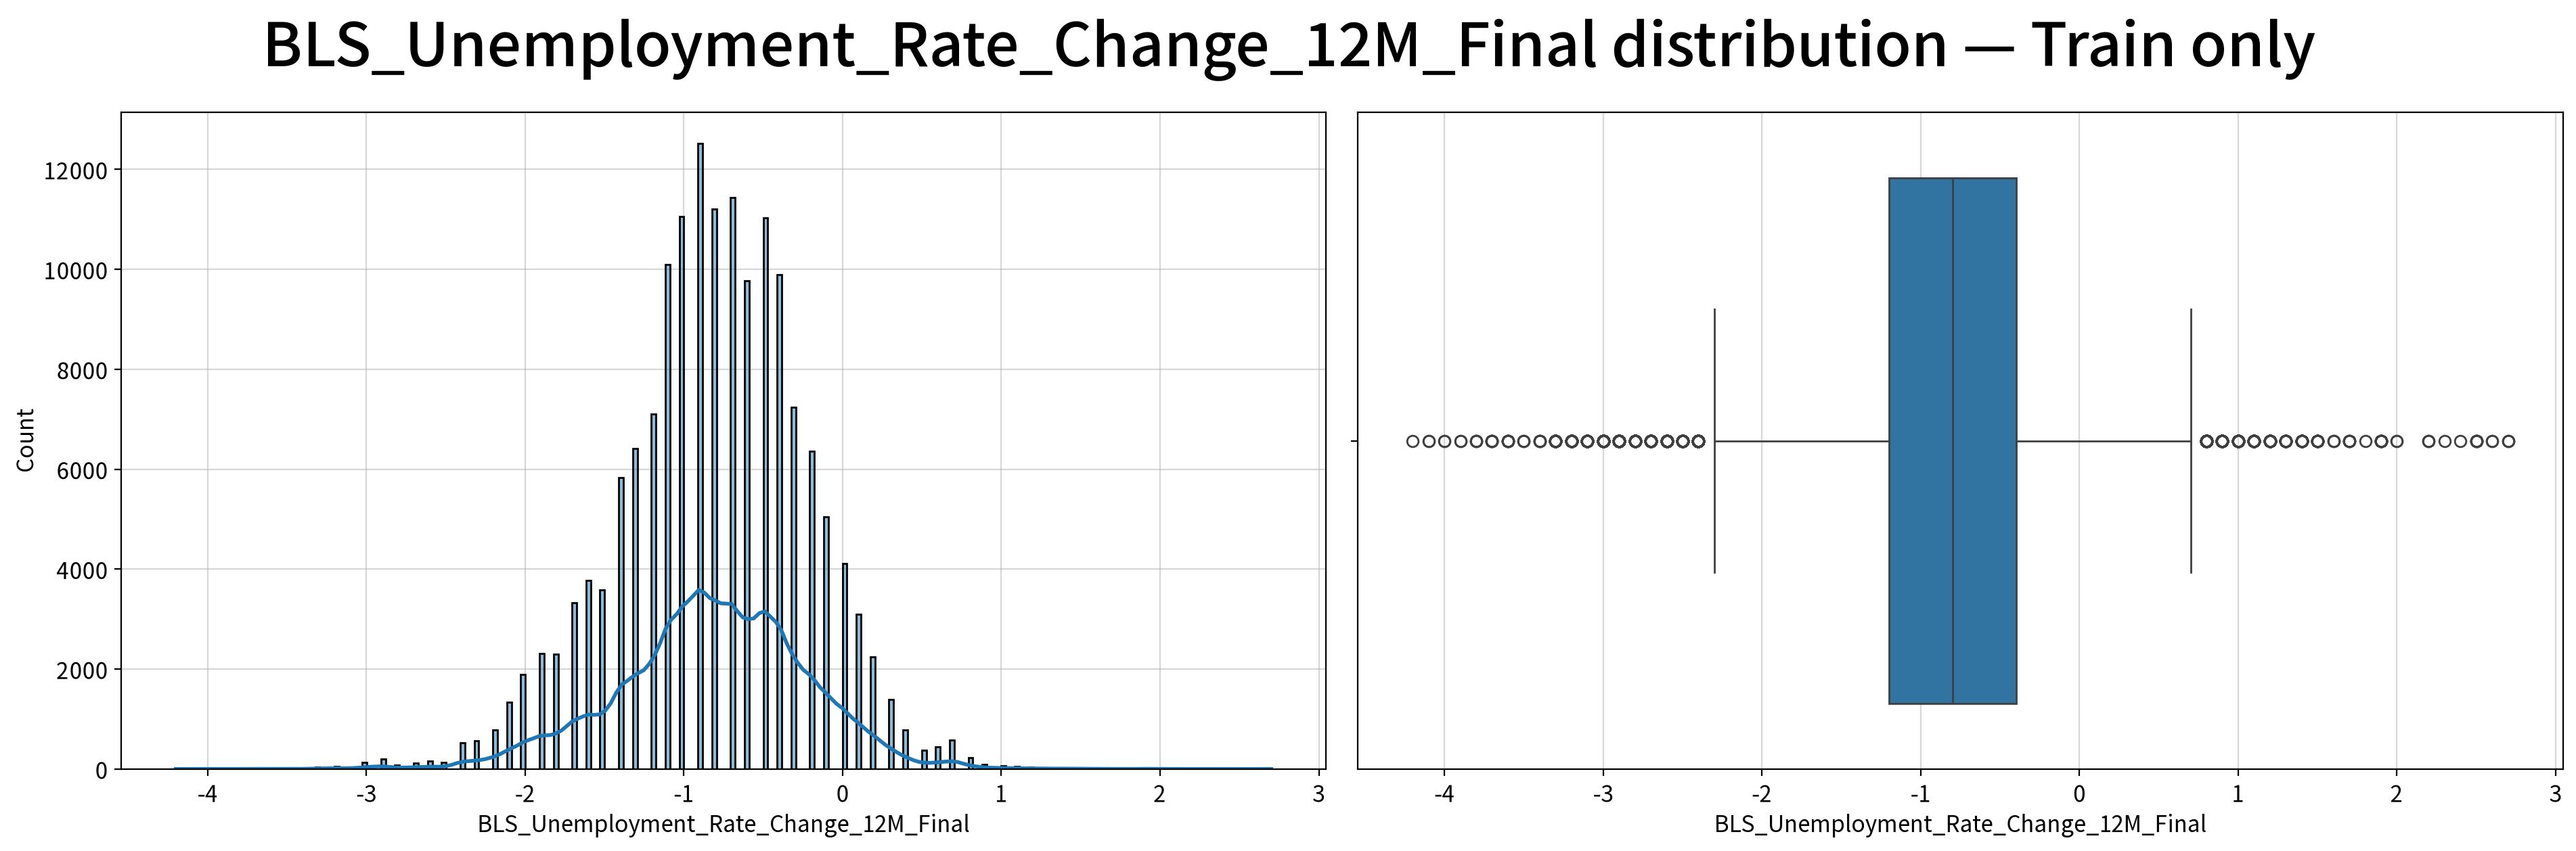

,min,max,skew,log_need
FICO_Score,445.000000,834.000000,-0.826560,none
MI_Percentage,0.000000,40.000000,1.404170,log1p
Original_CLTV,3.000000,854.000000,0.303394,none
Original_DTI,1.000000,50.000000,-0.498692,none
Original_UPB,10000.000000,975000.000000,0.874826,none
Original_LTV,3.000000,336.000000,-0.426415,none
Original_Interest_Rate,2.250000,6.000000,-0.210396,none
Original_Loan_Term,96.000000,366.000000,-1.203685,reverse_log1p
Number_of_Borrowers,1.000000,2.000000,-0.014788,none
CLTV_LTV_Gap,0.000000,809.000000,31.230894,log1p


In [6]:
# ======================================================================================
# 4B. CONTINUOUS / NUMERIC UNIVARIATE ANALYSIS
# ======================================================================================
num_summary = df[CONTINUOUS_COLS].describe(percentiles=[.01,.05,.25,.50,.75,.95,.99]).T
num_summary["missing_n"] = df[CONTINUOUS_COLS].isna().sum()
num_summary["missing_pct"] = num_summary["missing_n"] / len(df) * 100
num_summary["n_unique"] = df[CONTINUOUS_COLS].nunique(dropna=False)
num_summary["skew"] = df[CONTINUOUS_COLS].skew(numeric_only=True)
num_summary["iqr"] = num_summary["75%"] - num_summary["25%"]
num_summary["lower_iqr_fence"] = num_summary["25%"] - 1.5*num_summary["iqr"]
num_summary["upper_iqr_fence"] = num_summary["75%"] + 1.5*num_summary["iqr"]

display(num_summary)
num_summary.to_csv(QA_DIR / "08A_continuous_univariate_summary.csv")

if HOSSAM_AVAILABLE:
    for c in CONTINUOUS_COLS:
        display(Markdown(f"### {c} — Train distribution"))
        fig, ax = my_plot.init(rows=1, cols=2, width=960, height=640,
                              title=f"{c} distribution — Train only")
        my_plot.histplot(data=df, x=c, kde=True, ax=ax[0])
        my_plot.boxplot(data=df, x=c, ax=ax[1])
        my_plot.show()


# --------------------------------------------------------------------------------------
# log_need recommendation table — TRAIN ONLY
#
# This is a review aid for #02 below. It does NOT overwrite the source matrix.
# Rules:
#   log      : strictly positive and materially right-skewed
#   log1p    : non-negative with zero allowed and materially right-skewed
#   reverse_log1p : materially left-skewed
#   none     : no automatic log recommendation
# --------------------------------------------------------------------------------------
def recommend_log_need(s, skew_threshold=1.0):
    x = pd.to_numeric(s, errors="coerce").dropna()
    if x.empty:
        return "none"

    sk = x.skew()
    xmin = x.min()

    if sk >= skew_threshold:
        if xmin > 0:
            return "log"
        if xmin >= 0:
            return "log1p"
    elif sk <= -skew_threshold:
        return "reverse_log1p"

    return "none"

num_desc = num_summary.copy()
num_desc["log_need"] = [
    recommend_log_need(df[c]) for c in num_desc.index
]

display(num_desc[["min", "max", "skew", "log_need"]])
num_desc.to_csv(QA_DIR / "08A_numerical_summary_with_log_need.csv")


In [7]:
# Validation unseen category policy
UNKNOWN_LABEL = -1

In [ ]:
# ======================================================================================
# #02. LOG TRANSFORMATION — TRAIN-DERIVED, FROZEN, THEN APPLIED TO TRAIN + VALIDATION
# ======================================================================================

# IMPORTANT:
# - Transformation decisions are derived from TRAIN ONLY.
# - Validation is NEVER re-screened for skewness / log_need.
# - Categorical predictors are labeled in 08A using my_prep.labeling.
# - The labeling rule is fitted on Train only and frozen before Validation is transformed.
# - The original final-07 parquet is never overwritten.
# - ID / control / date / target fields are never transformed.

origin_train = train.copy()
origin_validation = validation.copy()

# Column meanings retained as documentation only.
column_means = {
    "Loan_ID": "Loan identifier",
    "FICO_Score": "Original borrower FICO score",
    "First_Payment_Date": "First payment date",
    "First_Time_Homebuyer": "First-time homebuyer indicator",
    "Maturity_Date": "Loan maturity date",
    "MSA": "Metropolitan Statistical Area code",
    "MI_Percentage": "Mortgage insurance percentage",
    "Number_of_Units": "Number of property units",
    "Occupancy_Status": "Occupancy status",
    "Original_CLTV": "Original combined loan-to-value ratio",
    "Original_DTI": "Original debt-to-income ratio",
    "Original_UPB": "Original unpaid principal balance",
    "Original_LTV": "Original loan-to-value ratio",
    "Original_Interest_Rate": "Original mortgage interest rate",
    "Channel": "Origination channel",
    "Property_State": "Property state",
    "Property_Type": "Property type",
    "Postal_Code": "Property postal-code field",
    "Loan_Purpose": "Loan purpose",
    "Original_Loan_Term": "Original loan term",
    "Number_of_Borrowers": "Number of borrowers",
    "Seller_Name": "Seller/originator name",
    "Super_Conforming_Flag": "Super-conforming loan indicator",
    "HARP_Indicator": "HARP indicator",
    "Target_24M": "24-month binary target",
    "Performance_Window_End": "End of 24-month performance window",
    "Split": "Frozen Train/Validation split",
    "DTI_Missing": "Structural original-DTI missingness indicator",
    "FICO_Risk_Band": "FICO risk band with numeric cutoff labels",
    "DTI_Risk_Band": "DTI risk band with numeric cutoff labels",
    "LTV_Risk_Component": "LTV-derived risk component",
    "CLTV_Risk_Component": "CLTV-derived risk component",
    "CLTV_LTV_Gap": "Original CLTV minus Original LTV",
    "DTI_LTV_Interaction": "DTI × LTV interaction",
    "DTI_Rate_Interaction": "DTI × interest-rate interaction",
    "UPB_per_Borrower": "Original UPB per borrower",
    "Estimated_Monthly_PI": "Estimated monthly principal-and-interest payment",
    "High_Leverage": "High-leverage indicator",
    "HARP_High_Leverage": "HARP × high-leverage indicator",
    "FICO_DTI_Interaction": "FICO × DTI interaction",
    "FICO_LTV_Interaction": "FICO × LTV interaction",
    "Spatial_Cluster": "Spatial cluster",
    "Spatial_Cluster_Region": "Spatial cluster region",
    "PIT_FHFA_Quarter_Date": "Regular PIT FHFA quarter date",
    "PIT_BLS_Month_Date": "Regular PIT BLS month date",
    "Housing_HPI": "Regular PIT housing HPI",
    "Housing_HPI_Growth_12M": "Regular PIT 12-month HPI growth",
    "BLS_Unemployment_Rate_Final": "Regular PIT unemployment rate",
    "BLS_Employment_Growth_12M_Final": "Regular PIT 12-month employment growth",
    "BLS_Unemployment_Rate_Change_12M_Final": "Regular PIT 12-month unemployment-rate change",
    "Regular_State_Macro_Cluster_A": "Regular PIT state macro cluster A",
    "Regular_State_Macro_Cluster_B": "Regular PIT state macro cluster B",
    "Regular_MSA_Macro_Cluster_A": "Regular PIT MSA macro cluster A",
    "Regular_MSA_Macro_Cluster_B": "Regular PIT MSA macro cluster B",
    "Regular_MSA_Macro_Cluster_A_Fallback": "MSA macro cluster A fallback indicator",
    "Regular_MSA_Macro_Cluster_B_Fallback": "MSA macro cluster B fallback indicator",
}
display(pd.Series(column_means, name="Meaning").to_frame())

target = TARGET
target_is_continuous = False
exclude_cols = ID_COLS + CONTROL_COLS + DATE_COLS

# Titanic-style typing is retained as a consistency check before labeling.
if HOSSAM_AVAILABLE:
    df_typed = my_qtcheck.set_type(origin_train.copy(), as_category=CATEGORICAL_COLS + [TARGET])
    helper_nominal = my_qtcheck.get_categorical_column_names(df_typed)
    helper_continuous = my_qtcheck.get_number_column_names(df_typed)
    helper_nominal = [c for c in helper_nominal if c != TARGET and c not in exclude_cols]
    helper_continuous = [c for c in helper_continuous if c != TARGET and c not in exclude_cols]
else:
    df_typed = origin_train.copy()
    helper_nominal = CATEGORICAL_COLS.copy()
    helper_continuous = CONTINUOUS_COLS.copy()

# Frozen project registry remains authoritative.
nominal_cols = CATEGORICAL_COLS.copy()
continuous_cols = CONTINUOUS_COLS.copy()

print("종속변수      :", target)
print("종속변수 유형 :", "연속형" if target_is_continuous else "범주형")
print("범주형        :", nominal_cols)
print("연속형        :", continuous_cols)
print("제외          :", exclude_cols)
print("Categorical encoding: my_prep.labeling — FIT TRAIN, APPLY FROZEN MAPPING TO VALIDATION")

# --------------------------------------------------------------------------------------
# 02-A. FREEZE TRAIN-DERIVED TRANSFORMATION SPECIFICATION
# --------------------------------------------------------------------------------------
display(num_desc["log_need"].T)

log_cols = [c for c in num_desc.index[num_desc["log_need"].eq("log")].tolist() if c in continuous_cols]
log1p_cols = [c for c in num_desc.index[num_desc["log_need"].eq("log1p")].tolist() if c in continuous_cols]
reflect_cols = [c for c in num_desc.index[num_desc["log_need"].eq("reverse_log1p")].tolist() if c in continuous_cols]

TRANSFORM_SPEC = {
    "log": list(log_cols),
    "log1p": list(log1p_cols),
    "reverse_log1p": list(reflect_cols),
}

all_transform_cols = sum(TRANSFORM_SPEC.values(), [])
assert len(all_transform_cols) == len(set(all_transform_cols)), "A variable appears in more than one transformation family."
assert set(all_transform_cols).issubset(CONTINUOUS_COLS), "Transformation specification contains a non-continuous predictor."

print("\nFROZEN TRAIN-DERIVED TRANSFORMATION SPECIFICATION")
for method, cols in TRANSFORM_SPEC.items():
    print(f"{method:15s}: {cols}")
print("PASS — transformation decisions were frozen from Train only.")

# --------------------------------------------------------------------------------------
# 02-B. FIT/FREEZE TRAIN-ONLY TRANSFORMATION PARAMETERS
# --------------------------------------------------------------------------------------
TRANSFORM_PARAMS = {"log": {}, "log1p": {}, "reverse_log1p": {}}

for col in TRANSFORM_SPEC["log"]:
    train_min = float(origin_train[col].min())
    assert train_min > 0, f"{col}: log(x) requires strictly positive Train values; Train min={train_min}"
    TRANSFORM_PARAMS["log"][col] = {"train_min": train_min}

for col in TRANSFORM_SPEC["log1p"]:
    train_min = float(origin_train[col].min())
    assert train_min >= 0, f"{col}: log1p(x) requires non-negative Train values; Train min={train_min}"
    TRANSFORM_PARAMS["log1p"][col] = {"train_min": train_min}

for col in TRANSFORM_SPEC["reverse_log1p"]:
    train_max = float(origin_train[col].max())
    TRANSFORM_PARAMS["reverse_log1p"][col] = {"reflection_max_train": train_max}

transform_param_rows = []
for method, params in TRANSFORM_PARAMS.items():
    for col, p in params.items():
        transform_param_rows.append({"Variable": col, "Transformation": method, **p})
transform_parameter_table = pd.DataFrame(transform_param_rows)
display(transform_parameter_table)

# --------------------------------------------------------------------------------------
# 02-C. DETERMINISTIC APPLICATION OF THE FROZEN TRAIN TRANSFORMATION
# --------------------------------------------------------------------------------------
def apply_frozen_log_transform(data, transform_spec, transform_params):
    """Apply Train-derived transformations without re-fitting or re-screening the supplied data."""
    out = data.copy()

    for col in transform_spec["log"]:
        bad = out[col] <= 0
        assert not bad.any(), f"{col}: {int(bad.sum()):,} non-positive values encountered under frozen log(x)."
        out[col] = np.log(out[col])

    for col in transform_spec["log1p"]:
        bad = out[col] < 0
        assert not bad.any(), f"{col}: {int(bad.sum()):,} negative values encountered under frozen log1p(x)."
        out[col] = np.log1p(out[col])

    for col in transform_spec["reverse_log1p"]:
        train_max = transform_params["reverse_log1p"][col]["reflection_max_train"]
        reflected = train_max - out[col]
        bad = reflected < 0
        if bad.any():
            raise ValueError(
                f"{col}: {int(bad.sum()):,} observations exceed the frozen Train reflection maximum "
                f"({train_max}). Do NOT refit the transformation on Validation."
            )
        out[col] = np.log1p(reflected)

    return out

train_transformed = apply_frozen_log_transform(origin_train, TRANSFORM_SPEC, TRANSFORM_PARAMS)
validation_transformed = apply_frozen_log_transform(origin_validation, TRANSFORM_SPEC, TRANSFORM_PARAMS)

print("Train transformed      :", train_transformed.shape)
print("Validation transformed :", validation_transformed.shape)

# --------------------------------------------------------------------------------------
# 02-D. TRAIN → VALIDATION TRANSFORMATION QA
# --------------------------------------------------------------------------------------
transform_qa_rows = []
def add_transform_check(check, passed, detail=""):
    transform_qa_rows.append({"Check": check, "PASS": bool(passed), "Detail": detail})

add_transform_check("Train row count unchanged", len(train_transformed) == len(origin_train))
add_transform_check("Validation row count unchanged", len(validation_transformed) == len(origin_validation))
add_transform_check("Train column schema unchanged", train_transformed.columns.tolist() == origin_train.columns.tolist())
add_transform_check("Validation column schema unchanged", validation_transformed.columns.tolist() == origin_validation.columns.tolist())

for col in ["Loan_ID", "Target_24M", "Split"]:
    add_transform_check(f"Train {col} unchanged", train_transformed[col].reset_index(drop=True).equals(origin_train[col].reset_index(drop=True)))
    add_transform_check(f"Validation {col} unchanged", validation_transformed[col].reset_index(drop=True).equals(origin_validation[col].reset_index(drop=True)))

for name, x in [("Train", train_transformed), ("Validation", validation_transformed)]:
    arr = x[CONTINUOUS_COLS].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
    add_transform_check(f"{name} transformed continuous values finite", np.isfinite(arr).all())

untouched_continuous = [c for c in CONTINUOUS_COLS if c not in all_transform_cols]
for col in untouched_continuous:
    add_transform_check(f"Untouched Train variable preserved — {col}", train_transformed[col].equals(origin_train[col]))
    add_transform_check(f"Untouched Validation variable preserved — {col}", validation_transformed[col].equals(origin_validation[col]))

transform_qa = pd.DataFrame(transform_qa_rows)
display(transform_qa)
assert transform_qa["PASS"].all(), "Train→Validation frozen-transformation QA failed."
print("PASS — identical Train-derived transformation specification applied to Train and Validation.")

# --------------------------------------------------------------------------------------
# 02-E. CATEGORICAL LABELING — my_prep.labeling FIT ON TRAIN ONLY
# --------------------------------------------------------------------------------------
assert HOSSAM_AVAILABLE, (
    "08A ML-ready labeling requires the project helper module because "
    "my_prep.labeling must be used."
)

# IMPORTANT:
# 1) Call my_prep.labeling ONLY on Train.
# 2) Recover the exact Train category -> label mapping produced by the helper.
# 3) Apply that frozen mapping to Validation; NEVER fit labeling separately on Validation.
#
# This preserves the requested Titanic-style helper while preventing Train/Validation
# category-code inconsistency.

train_ml = my_prep.labeling(train_transformed.copy(), columns=nominal_cols)

label_mapping = {}
label_mapping_rows = []

for col in nominal_cols:
    raw = train_transformed[col].astype("string")
    enc = train_ml[col]

    pairs = pd.DataFrame({"raw": raw, "encoded": enc}).drop_duplicates()

    # One raw category must map to exactly one encoded value.
    per_raw = pairs.groupby("raw", dropna=False)["encoded"].nunique(dropna=False)
    assert (per_raw == 1).all(), f"{col}: my_prep.labeling did not produce a deterministic mapping."

    mapping = dict(zip(pairs["raw"], pairs["encoded"]))
    label_mapping[col] = mapping

    for raw_value, encoded_value in mapping.items():
        label_mapping_rows.append({
            "Variable": col,
            "Original_Category": raw_value,
            "Label": encoded_value,
            "Mapping_Source": "Train_only_my_prep.labeling",
        })

label_mapping_table = pd.DataFrame(label_mapping_rows)

# Apply the frozen Train mapping to Validation.
validation_ml = validation_transformed.copy()
unknown_validation_rows = []

for col in nominal_cols:
    raw_val = validation_transformed[col].astype("string")
    mapped = raw_val.map(label_mapping[col])

    unknown_mask = mapped.isna() & raw_val.notna()
    unknown_values = sorted(raw_val.loc[unknown_mask].dropna().unique().tolist())

    unknown_validation_rows.append({
        "Variable": col,
        "Unknown_Validation_Levels_N": len(unknown_values),
        "Unknown_Validation_Rows_N": int(unknown_mask.sum()),
        "Unknown_Validation_Levels": " | ".join(map(str, unknown_values)),
    })

    # Validation-only unseen categories are NOT used to refit the encoder.
    # They receive a fixed unknown-category label.
    if unknown_mask.any():
        mapped.loc[unknown_mask] = UNKNOWN_LABEL

    # Match the dtype generated by my_prep.labeling on Train whenever possible.
    try:
        mapped = mapped.astype(train_ml[col].dtype)
    except (TypeError, ValueError):
        pass
    validation_ml[col] = mapped

unknown_validation_table = pd.DataFrame(unknown_validation_rows)

# --------------------------------------------------------------------------------------
# 02-F. LABELING QA
# --------------------------------------------------------------------------------------
label_qa_rows = []

def add_label_check(check, passed, detail=""):
    label_qa_rows.append({"Check": check, "PASS": bool(passed), "Detail": detail})

add_label_check("Train rows unchanged by labeling", len(train_ml) == len(train_transformed))
add_label_check("Validation rows unchanged by labeling", len(validation_ml) == len(validation_transformed))
add_label_check("Train schema unchanged by labeling", train_ml.columns.tolist() == train_transformed.columns.tolist())
add_label_check("Validation schema unchanged by labeling", validation_ml.columns.tolist() == validation_transformed.columns.tolist())
add_label_check(
    "Validation unseen categorical levels handled with frozen unknown label",
    not validation_ml[nominal_cols].isna().any().any(),
    f"Unknown label = {UNKNOWN_LABEL}; "
    f"unseen Validation rows = "
    f"{int(unknown_validation_table['Unknown_Validation_Rows_N'].sum()):,}"
)

for col in nominal_cols:
    add_label_check(
        f"Train categorical labeled — {col}",
        pd.api.types.is_numeric_dtype(train_ml[col]),
        str(train_ml[col].dtype)
    )
    add_label_check(
        f"Validation categorical labeled — {col}",
        pd.api.types.is_numeric_dtype(validation_ml[col]),
        str(validation_ml[col].dtype)
    )

for col in ["Loan_ID", "Target_24M", "Split"] + DATE_COLS:
    add_label_check(
        f"Train protected field preserved — {col}",
        train_ml[col].reset_index(drop=True).equals(train_transformed[col].reset_index(drop=True))
    )
    add_label_check(
        f"Validation protected field preserved — {col}",
        validation_ml[col].reset_index(drop=True).equals(validation_transformed[col].reset_index(drop=True))
    )

label_qa = pd.DataFrame(label_qa_rows)
display(label_qa)
assert label_qa["PASS"].all(), "Categorical labeling QA failed."

# --------------------------------------------------------------------------------------
# 02-G. SAVE TRANSFORMATION SPEC + LABEL MAPPING + ML-READY OUTPUT
# --------------------------------------------------------------------------------------
transform_spec_table = pd.DataFrame([
    {
        "Variable": col,
        "Transformation": method,
        "Decision_Source": "Train_only",
        "Status": "Applied",
    }
    for method, cols in TRANSFORM_SPEC.items()
    for col in cols
])

transform_spec_table.to_csv(QA_DIR / "08A_transform_spec.csv", index=False)
transform_parameter_table.to_csv(QA_DIR / "08A_transform_parameters.csv", index=False)
transform_qa.to_csv(QA_DIR / "08A_train_validation_transform_QA.csv", index=False)
label_mapping_table.to_csv(QA_DIR / "08A_categorical_label_mapping.csv", index=False)
unknown_validation_table.to_csv(QA_DIR / "08A_validation_unknown_category_QA.csv", index=False)
label_qa.to_csv(QA_DIR / "08A_categorical_labeling_QA.csv", index=False)

TRAIN_ML_PATH = MODEL_READY_DIR / "SFLLD_regular_PIT_train_ML_ready.parquet"
VALIDATION_ML_PATH = MODEL_READY_DIR / "SFLLD_regular_PIT_validation_ML_ready.parquet"

train_ml.to_parquet(TRAIN_ML_PATH, index=False)
validation_ml.to_parquet(VALIDATION_ML_PATH, index=False)

# Read-back QA: confirm the actual files written to disk are usable and structurally identical.
train_ml_check = pd.read_parquet(TRAIN_ML_PATH)
validation_ml_check = pd.read_parquet(VALIDATION_ML_PATH)

assert train_ml_check.shape == train_ml.shape
assert validation_ml_check.shape == validation_ml.shape
assert train_ml_check.columns.tolist() == train_ml.columns.tolist()
assert validation_ml_check.columns.tolist() == validation_ml.columns.tolist()

print("Saved:", QA_DIR / "08A_transform_spec.csv")
print("Saved:", QA_DIR / "08A_transform_parameters.csv")
print("Saved:", QA_DIR / "08A_train_validation_transform_QA.csv")
print("Saved:", QA_DIR / "08A_categorical_label_mapping.csv")
print("Saved:", QA_DIR / "08A_validation_unknown_category_QA.csv")
print("Saved:", QA_DIR / "08A_categorical_labeling_QA.csv")
print("Saved ML-ready Train      :", TRAIN_ML_PATH)
print("Saved ML-ready Validation :", VALIDATION_ML_PATH)

,Meaning
Loan_ID,Loan identifier
FICO_Score,Original borrower FICO score
First_Payment_Date,First payment date
First_Time_Homebuyer,First-time homebuyer indicator
Maturity_Date,Loan maturity date
MSA,Metropolitan Statistical Area code
MI_Percentage,Mortgage insurance percentage
Number_of_Units,Number of property units
Occupancy_Status,Occupancy status
Original_CLTV,Original combined loan-to-value ratio


<class 'pandas.DataFrame'>
Index: 160003 entries, 0 to 168153
Data columns (total 56 columns):
 #   Column                                  Non-Null Count   Dtype         
---  ------                                  --------------   -----         
 0   Loan_ID                                 160003 non-null  str           
 1   FICO_Score                              160003 non-null  float64       
 2   First_Payment_Date                      160003 non-null  datetime64[us]
 3   First_Time_Homebuyer                    160003 non-null  category      
 4   Maturity_Date                           160003 non-null  datetime64[us]
 5   MSA                                     160003 non-null  category      
 6   MI_Percentage                           160003 non-null  float64       
 7   Number_of_Units                         160003 non-null  category      
 8   Occupancy_Status                        160003 non-null  category      
 9   Original_CLTV                           160003 non-nu

FICO_Score                                         none
MI_Percentage                                     log1p
Original_CLTV                                      none
Original_DTI                                       none
Original_UPB                                       none
Original_LTV                                       none
Original_Interest_Rate                             none
Original_Loan_Term                        reverse_log1p
Number_of_Borrowers                                none
CLTV_LTV_Gap                                      log1p
DTI_LTV_Interaction                                none
DTI_Rate_Interaction                               none
UPB_per_Borrower                                    log
Estimated_Monthly_PI                                log
FICO_DTI_Interaction                               none
FICO_LTV_Interaction                               none
Housing_HPI                                        none
Housing_HPI_Growth_12M                          


FROZEN TRAIN-DERIVED TRANSFORMATION SPECIFICATION
log            : ['UPB_per_Borrower', 'Estimated_Monthly_PI', 'BLS_Unemployment_Rate_Final']
log1p          : ['MI_Percentage', 'CLTV_LTV_Gap']
reverse_log1p  : ['Original_Loan_Term']
PASS — transformation decisions were frozen from Train only.


,Variable,Transformation,train_min,reflection_max_train
0,UPB_per_Borrower,log,5000.000000,NaN
1,Estimated_Monthly_PI,log,68.797069,NaN
2,BLS_Unemployment_Rate_Final,log,2.200000,NaN
3,MI_Percentage,log1p,0.000000,NaN
4,CLTV_LTV_Gap,log1p,0.000000,NaN
5,Original_Loan_Term,reverse_log1p,NaN,366.0


Train transformed      : (160003, 56)
Validation transformed : (49038, 56)


,Check,PASS,Detail
0,Train row count unchanged,True,
1,Validation row count unchanged,True,
2,Train column schema unchanged,True,
3,Validation column schema unchanged,True,
4,Train Loan_ID unchanged,True,
5,Validation Loan_ID unchanged,True,
6,Train Target_24M unchanged,True,
7,Validation Target_24M unchanged,True,
8,Train Split unchanged,True,
9,Validation Split unchanged,True,


PASS — identical Train-derived transformation specification applied to Train and Validation.
First_Time_Homebuyer (3종): Missing=0, N=1, Y=2
MSA (453종): 10180=0, 10420=1, 10500=2, 10540=3, 10580=4, 10740=5, 10780=6, 10900=7, 11020=8, 11100=9, 11180=10, 11244=11, 11260=12, 11300=13, 11340=14, 11460=15, 11500=16, 11540=17, 11694=18, 11700=19, 12020=20, 12054=21, 12060=22, 12100=23, 12220=24, 12260=25, 12420=26, 12540=27, 12580=28, 12620=29, 12700=30, 12940=31, 12980=32, 13020=33, 13140=34, 13220=35, 13380=36, 13460=37, 13644=38, 13740=39, 13780=40, 13820=41, 13900=42, 13980=43, 14010=44, 14020=45, 14060=46, 14100=47, 14260=48, 14454=49, 14484=50, 14500=51, 14540=52, 14580=53, 14740=54, 14860=55, 15180=56, 15260=57, 15380=58, 15500=59, 15540=60, 15680=61, 15764=62, 15804=63, 15940=64, 15980=65, 16020=66, 16060=67, 16180=68, 16220=69, 16300=70, 16540=71, 16580=72, 16620=73, 16700=74, 16740=75, 16820=76, 16860=77, 16940=78, 16974=79, 16984=80, 17020=81, 17140=82, 17300=83, 17410=84, 17420=85

,Check,PASS,Detail
0,Train rows unchanged by labeling,True,
1,Validation rows unchanged by labeling,True,
2,Train schema unchanged by labeling,True,
3,Validation schema unchanged by labeling,True,
4,Validation unseen categorical levels handled w...,True,Unknown label = -1; unseen Validation rows = 1...
5,Train categorical labeled — First_Time_Homebuyer,True,int64
6,Validation categorical labeled — First_Time_Ho...,True,int64
7,Train categorical labeled — MSA,True,int64
8,Validation categorical labeled — MSA,True,int64
9,Train categorical labeled — Number_of_Units,True,int64


Saved: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\quality_assurance\08A_regular_PIT_train_only_EDA\08A_transform_spec.csv
Saved: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\quality_assurance\08A_regular_PIT_train_only_EDA\08A_transform_parameters.csv
Saved: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\quality_assurance\08A_regular_PIT_train_only_EDA\08A_train_validation_transform_QA.csv
Saved: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\quality_assurance\08A_regular_PIT_train_only_EDA\08A_categorical_label_mapping.csv
Saved: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\quality_assurance\08A_regular_PIT_train_only_EDA\08A_validation_unknown_category_QA.csv
Saved: C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The S

In [ ]:
# ======================================================================================
# 5A. NUMERIC → BINARY TARGET
# ======================================================================================
def rank_biserial_from_u(u, n1, n0):
    # U for positive group versus negative group: 2*AUC-1 orientation
    return 2.0 * u / (n1*n0) - 1.0

def standardized_mean_difference(x1, x0):
    n1, n0 = len(x1), len(x0)
    v1, v0 = x1.var(ddof=1), x0.var(ddof=1)
    pooled = np.sqrt(((n1-1)*v1 + (n0-1)*v0) / max(n1+n0-2, 1))
    return (x1.mean()-x0.mean())/pooled if pooled > 0 else np.nan

num_biv = []
for c in CONTINUOUS_COLS:
    x1 = pd.to_numeric(df.loc[df[TARGET].eq(1), c], errors="coerce").dropna()
    x0 = pd.to_numeric(df.loc[df[TARGET].eq(0), c], errors="coerce").dropna()
    u, p = stats.mannwhitneyu(x1, x0, alternative="two-sided")
    num_biv.append({
        "Variable": c, "N_Pos": len(x1), "N_Neg": len(x0),
        "Mean_Pos": x1.mean(), "Mean_Neg": x0.mean(),
        "Median_Pos": x1.median(), "Median_Neg": x0.median(),
        "MannWhitney_U": u, "P_Value": p,
        "Rank_Biserial": rank_biserial_from_u(u, len(x1), len(x0)),
        "Std_Mean_Diff": standardized_mean_difference(x1, x0),
    })

numeric_target_association = pd.DataFrame(num_biv)
numeric_target_association["Abs_Rank_Biserial"] = numeric_target_association["Rank_Biserial"].abs()
numeric_target_association = numeric_target_association.sort_values("Abs_Rank_Biserial", ascending=False)
display(numeric_target_association)
numeric_target_association.to_csv(QA_DIR / "08A_numeric_target_association.csv", index=False)

,Variable,N_Pos,N_Neg,Mean_Pos,Mean_Neg,Median_Pos,Median_Neg,MannWhitney_U,P_Value,Rank_Biserial,Std_Mean_Diff,Abs_Rank_Biserial
0,FICO_Score,919,159084,698.355822,748.210216,698.000000,758.000000,35632179.0,1.237946e-158,-0.512550,-1.038040,0.512550
10,DTI_LTV_Interaction,919,159084,3019.899891,2528.348740,3040.000000,2560.000000,94886893.5,6.698187e-55,0.298058,0.539471,0.298058
11,DTI_Rate_Interaction,919,159084,158.349746,138.180845,161.875000,141.375000,94470980.0,6.815004e-53,0.292369,0.488310,0.292369
6,Original_Interest_Rate,919,159084,4.302311,4.042534,4.375000,4.125000,93805353.0,5.438110e-50,0.283263,0.502308,0.283263
2,Original_CLTV,919,159084,84.434168,74.980570,80.000000,80.000000,91474349.0,5.559449e-40,0.251375,0.513941,0.251375
5,Original_LTV,919,159084,82.143634,74.020455,80.000000,79.000000,89962380.5,5.843654e-34,0.230691,0.450924,0.230691
8,Number_of_Borrowers,919,159084,1.282916,1.504972,1.000000,2.000000,56867004.5,4.323661e-41,-0.222056,-0.444372,0.222056
3,Original_DTI,919,159084,36.800871,34.029173,35.000000,35.000000,85478076.5,6.703367e-19,0.169345,0.313872,0.169345
13,Estimated_Monthly_PI,919,159084,1035.182632,1174.316519,926.114392,1056.152912,63647765.0,1.293581e-11,-0.129295,-0.225433,0.129295
4,Original_UPB,919,159084,196965.179543,220613.971235,174000.000000,199000.000000,64795843.0,2.728553e-09,-0.113589,-0.200327,0.113589


In [ ]:
# ======================================================================================
# 5B. CATEGORICAL → BINARY TARGET
# ======================================================================================
def cramers_v_bias_corrected(table):
    obs = np.asarray(table)
    chi2 = stats.chi2_contingency(obs, correction=False)[0]
    n = obs.sum()
    if n <= 1: return np.nan
    phi2 = chi2/n
    r, k = obs.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    denom = min(kcorr-1, rcorr-1)
    return np.sqrt(phi2corr/denom) if denom > 0 else np.nan

cat_biv = []
for c in CATEGORICAL_COLS:
    tmp = df[[c, TARGET]].copy()
    # Explicit string sentinel only for EDA contingency safety; source data is not mutated.
    x = tmp[c].astype("string").fillna("<NA>")
    table = pd.crosstab(x, tmp[TARGET], dropna=False)
    chi2, p, dof, expected = stats.chi2_contingency(table, correction=False)
    v = cramers_v_bias_corrected(table)

    rates = tmp.assign(_cat=x).groupby("_cat", observed=True)[TARGET].agg(["count", "mean"])
    rates = rates.rename(columns={"count":"N", "mean":"Target_Rate"}).sort_values(["N"], ascending=False)
    rates.to_csv(QA_DIR / f"08A_target_rate_by_{c}.csv")

    cat_biv.append({
        "Variable": c, "N_Levels": table.shape[0], "Chi2": chi2, "DOF": dof,
        "P_Value": p, "Cramers_V": v,
        "Min_Expected_Count": float(expected.min()),
        "Pct_Expected_lt_5": float((expected < 5).mean()*100),
        "Target_Rate_Min": float(rates["Target_Rate"].min()),
        "Target_Rate_Max": float(rates["Target_Rate"].max()),
        "Target_Rate_Range_pp": float((rates["Target_Rate"].max()-rates["Target_Rate"].min())*100),
    })

categorical_target_association = pd.DataFrame(cat_biv).sort_values("Cramers_V", ascending=False)
display(categorical_target_association)
categorical_target_association.to_csv(QA_DIR / "08A_categorical_target_association.csv", index=False)

,Variable,N_Levels,Chi2,DOF,P_Value,Cramers_V,Min_Expected_Count,Pct_Expected_lt_5,Target_Rate_Min,Target_Rate_Max,Target_Rate_Range_pp
13,FICO_Risk_Band,5,1080.783935,4,1.107292e-232,0.082035,44.978463,0.000000,0.001764,0.027583,2.581892
7,Postal_Code,885,1537.907317,884,5.047028e-38,0.063928,0.005744,50.056497,0.000000,0.142857,14.285714
1,MSA,453,1035.462145,452,9.376997e-48,0.060387,0.005744,47.240618,0.000000,0.105263,10.526316
16,CLTV_Risk_Component,5,404.989689,4,2.323592e-86,0.050062,20.200390,0.000000,0.003936,0.028718,2.478170
14,DTI_Risk_Band,5,387.213288,4,1.610128e-82,0.048939,91.904021,0.000000,0.001509,0.015624,1.411468
5,Property_State,54,429.712921,53,2.076482e-60,0.048522,0.057436,17.592593,0.000000,0.019139,1.913925
15,LTV_Risk_Component,5,377.005466,4,2.581776e-80,0.048283,14.514184,0.000000,0.004143,0.032054,2.791130
18,HARP_High_Leverage,2,336.021647,1,4.691373e-75,0.045759,20.051055,0.000000,0.005226,0.028932,2.370510
17,High_Leverage,2,332.363279,1,2.938107e-74,0.045508,20.200390,0.000000,0.005227,0.028718,2.349035
11,HARP_Indicator,2,304.238266,1,3.930223e-68,0.043534,91.858071,0.000000,0.004646,0.015632,1.098633


In [ ]:
# ======================================================================================
# 6A. NUMERIC SPEARMAN CORRELATION
# ======================================================================================
spearman_corr = df[CONTINUOUS_COLS].corr(method="spearman")
display(spearman_corr)
spearman_corr.to_csv(QA_DIR / "08A_numeric_spearman_correlation.csv")

pairs = []
for i, a in enumerate(CONTINUOUS_COLS):
    for b in CONTINUOUS_COLS[i+1:]:
        rho = spearman_corr.loc[a,b]
        pairs.append({"Variable_1":a, "Variable_2":b, "Spearman_Rho":rho, "Abs_Rho":abs(rho)})
correlation_pairs = pd.DataFrame(pairs).sort_values("Abs_Rho", ascending=False)
display(correlation_pairs.head(50))
correlation_pairs.to_csv(QA_DIR / "08A_numeric_spearman_pairs.csv", index=False)

if HOSSAM_AVAILABLE:
    try:
        corr_helper = my_stats.multi_correlation(df, columns=CONTINUOUS_COLS, plot=False)
        display(my_stats.correlation_summary(corr_helper))
    except Exception as e:
        print("Helper correlation summary skipped:", repr(e))

,FICO_Score,MI_Percentage,Original_CLTV,Original_DTI,Original_UPB,Original_LTV,Original_Interest_Rate,Original_Loan_Term,Number_of_Borrowers,CLTV_LTV_Gap,DTI_LTV_Interaction,DTI_Rate_Interaction,UPB_per_Borrower,Estimated_Monthly_PI,FICO_DTI_Interaction,FICO_LTV_Interaction,Housing_HPI,Housing_HPI_Growth_12M,BLS_Unemployment_Rate_Final,BLS_Employment_Growth_12M_Final,BLS_Unemployment_Rate_Change_12M_Final
FICO_Score,1.000000,-0.059557,-0.125700,-0.153554,0.033576,-0.108608,-0.218268,-0.043481,-0.040149,-0.073424,-0.187982,-0.227984,0.054293,0.027902,0.089599,0.180304,0.013318,0.000117,-0.034958,0.005794,0.011061
MI_Percentage,-0.059557,1.000000,0.695478,0.036779,0.072955,0.717956,0.128988,0.235340,-0.032617,-0.131256,0.425148,0.087339,0.085450,0.009085,0.034645,0.678861,-0.125443,-0.084818,-0.031850,-0.020468,0.046561
Original_CLTV,-0.125700,0.695478,1.000000,0.036946,0.106834,0.964204,0.249132,0.288518,-0.033717,0.109622,0.631538,0.145031,0.118973,0.039429,0.018568,0.899736,-0.208434,-0.104404,0.025469,-0.035427,0.012762
Original_DTI,-0.153554,0.036779,0.036946,1.000000,0.106858,0.036440,0.119791,0.105782,-0.085495,-0.002359,0.723025,0.884082,0.146395,0.086466,0.959173,-0.002687,0.124122,0.077465,0.016440,0.022947,-0.026402
Original_UPB,0.033576,0.072955,0.106834,0.106858,1.000000,0.098486,-0.060910,0.217518,0.150201,0.042693,0.152429,0.061887,0.819486,0.954956,0.121224,0.121835,0.432864,0.216458,-0.082327,0.098187,0.003888
Original_LTV,-0.108608,0.717956,0.964204,0.036440,0.098486,1.000000,0.237810,0.295004,-0.042952,-0.100767,0.651680,0.137320,0.116591,0.027854,0.022734,0.937866,-0.207146,-0.102826,0.019412,-0.032535,0.020195
Original_Interest_Rate,-0.218268,0.128988,0.249132,0.119791,-0.060910,0.237810,1.000000,0.550487,-0.056840,0.045544,0.243855,0.528086,-0.023879,-0.158506,0.064880,0.162643,-0.052935,0.050580,0.248552,-0.006857,-0.265179
Original_Loan_Term,-0.043481,0.235340,0.288518,0.105782,0.217518,0.295004,0.550487,1.000000,-0.050865,-0.039039,0.252247,0.330000,0.228215,-0.047140,0.099753,0.282666,0.101689,0.075994,-0.010341,0.045967,-0.010611
Number_of_Borrowers,-0.040149,-0.032617,-0.033717,-0.085495,0.150201,-0.042952,-0.056840,-0.050865,1.000000,0.037728,-0.085786,-0.095707,-0.412906,0.168337,-0.097167,-0.055108,-0.001261,-0.020869,-0.026123,-0.009008,0.004035
CLTV_LTV_Gap,-0.073424,-0.131256,0.109622,-0.002359,0.042693,-0.100767,0.045544,-0.039039,0.037728,1.000000,-0.055293,0.027931,0.017701,0.060146,-0.023126,-0.118089,-0.004222,-0.008579,0.031413,-0.014846,-0.036947


,Variable_1,Variable_2,Spearman_Rho,Abs_Rho
41,Original_CLTV,Original_LTV,0.964204,0.964204
67,Original_DTI,FICO_DTI_Interaction,0.959173,0.959173
82,Original_UPB,Estimated_Monthly_PI,0.954956,0.954956
99,Original_LTV,FICO_LTV_Interaction,0.937866,0.937866
51,Original_CLTV,FICO_LTV_Interaction,0.899736,0.899736
64,Original_DTI,DTI_Rate_Interaction,0.884082,0.884082
167,DTI_Rate_Interaction,FICO_DTI_Interaction,0.825706,0.825706
81,Original_UPB,UPB_per_Borrower,0.819486,0.819486
174,UPB_per_Borrower,Estimated_Monthly_PI,0.768248,0.768248
63,Original_DTI,DTI_LTV_Interaction,0.723025,0.723025


C:\Users\itwill\Desktop\study\코딩공부\python_modules\helpers\my_stats.py:792: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]
C:\Users\itwill\Desktop\study\코딩공부\python_modules\helpers\my_stats.py:792: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]
C:\Users\itwill\Desktop\study\코딩공부\python_modules\helpers\my_stats.py:792: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]
C:\Users\itwill\Desktop\study\코딩공부\python_modules\helpers\my_stats.py:792: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_trim = pearsonr(trimmed[x], trimmed[y])[0]
C:\Users\itwill\Desktop\study\코딩공부\python_modules\helpers\my_stats.py:792: ConstantInputWarning: An input array is constant; the correla

method    coef  p-value  strength  significant  normality_x  normality_y  linearity  \
x                               y                                                                                                                               
FICO_Score                      MI_Percentage                           Spearman -0.0596      0.0      Weak         True        False        False      False   
                                Original_CLTV                           Spearman -0.1257      0.0      Weak         True        False        False      False   
                                Original_DTI                            Spearman -0.1536      0.0      Weak         True        False        False      False   
                                Original_UPB                            Spearman  0.0336      0.0      Weak         True        False        False      False   
                                Original_LTV                            Spearman -0.1086      0.0      Weak         True        False        False      False   
...                                                                          ...     ...      ...       ...          ...          ...          ...        ...   
Housing_HPI_Growth_12M          BLS_Employment_Growth_12M_Final         Spearman  0.4358      0.0  Moderate         True        False        False      False   
                                BLS_Unemployment_Rate_Change_12M_Final  Spearman -0.1238      0.0      Weak         True        False        False      False   
BLS_Unemployment_Rate_Final     BLS_Employment_Growth_12M_Final         Spearman -0.1527      0.0      Weak         True        False        False      False   
                                BLS_Unemployment_Rate_Change_12M_Final  Spearman -0.4438      0.0  Moderate         True        False        False      False   
BLS_Employment_Growth_12M_Final BLS_Unemployment_Rate_Change_12M_Final  Spearman -0.1837      0.0      Weak         True        False        False      False   

                                                                        influential_outlier  high_skew  
x                               y                                                                       
FICO_Score                      MI_Percentage                                         False       True  
                                Original_CLTV                                         False      False  
                                Original_DTI                                          False      False  
                                Original_UPB                                          False      False  
                                Original_LTV                                          False      False  
...                                                                                     ...        ...  
Housing_HPI_Growth_12M          BLS_Employment_Growth_12M_Final                       False       True  
                                BLS_Unemployment_Rate_Change_12M_Final                False       True  
BLS_Unemployment_Rate_Final     BLS_Employment_Growth_12M_Final                       False       True  
                                BLS_Unemployment_Rate_Change_12M_Final                False       True  
BLS_Employment_Growth_12M_Final BLS_Unemployment_Rate_Change_12M_Final                False      False  

[210 rows x 10 columns]

,FICO_Score,MI_Percentage,Original_CLTV,Original_DTI,Original_UPB,Original_LTV,Original_Interest_Rate,Original_Loan_Term,Number_of_Borrowers,CLTV_LTV_Gap,DTI_LTV_Interaction,DTI_Rate_Interaction,UPB_per_Borrower,Estimated_Monthly_PI,FICO_DTI_Interaction,FICO_LTV_Interaction,Housing_HPI,Housing_HPI_Growth_12M,BLS_Unemployment_Rate_Final,BLS_Employment_Growth_12M_Final,BLS_Unemployment_Rate_Change_12M_Final
FICO_Score,1.000,-0.060,-0.126,-0.154,0.034,-0.109,-0.218,-0.043,-0.040,-0.073,-0.188,-0.228,0.054,0.028,0.090,0.180,0.013,0.000,-0.035,0.006,0.011
MI_Percentage,-0.060,1.000,0.696,0.037,0.073,0.718,0.129,0.235,-0.033,-0.131,0.425,0.087,0.086,0.009,0.035,0.679,-0.125,-0.085,-0.032,-0.021,0.047
Original_CLTV,-0.126,0.696,1.000,0.037,0.107,0.964,0.249,0.288,-0.034,0.110,0.631,0.145,0.119,0.039,0.019,0.900,-0.208,-0.104,0.025,-0.035,0.013
Original_DTI,-0.154,0.037,0.037,1.000,0.107,0.036,0.120,0.106,-0.086,-0.002,0.723,0.884,0.146,0.086,0.959,-0.003,0.124,0.077,0.016,0.023,-0.026
Original_UPB,0.034,0.073,0.107,0.107,1.000,0.099,-0.061,0.217,0.150,0.043,0.152,0.062,0.820,0.955,0.121,0.122,0.433,0.216,-0.082,0.098,0.004
Original_LTV,-0.109,0.718,0.964,0.036,0.099,1.000,0.238,0.295,-0.043,-0.101,0.652,0.137,0.117,0.028,0.023,0.938,-0.207,-0.103,0.019,-0.033,0.020
Original_Interest_Rate,-0.218,0.129,0.249,0.120,-0.061,0.238,1.000,0.550,-0.057,0.045,0.244,0.528,-0.024,-0.159,0.065,0.163,-0.053,0.051,0.249,-0.007,-0.265
Original_Loan_Term,-0.043,0.235,0.288,0.106,0.217,0.295,0.550,1.000,-0.051,-0.039,0.252,0.330,0.228,-0.047,0.100,0.283,0.102,0.076,-0.010,0.046,-0.011
Number_of_Borrowers,-0.040,-0.033,-0.034,-0.086,0.150,-0.043,-0.057,-0.051,1.000,0.038,-0.086,-0.096,-0.413,0.168,-0.097,-0.055,-0.001,-0.021,-0.026,-0.009,0.004
CLTV_LTV_Gap,-0.073,-0.131,0.110,-0.002,0.043,-0.101,0.045,-0.039,0.038,1.000,-0.055,0.028,0.018,0.060,-0.023,-0.118,-0.004,-0.009,0.031,-0.015,-0.037


,max-y,max-coef,count,columns
x,,,,
Original_LTV,Original_CLTV,0.9642,3,"Original_CLTV, FICO_LTV_Interaction, MI_Percen..."
Original_DTI,FICO_DTI_Interaction,0.9592,3,"FICO_DTI_Interaction, DTI_Rate_Interaction, DT..."
DTI_Rate_Interaction,Original_DTI,0.8841,3,"Original_DTI, FICO_DTI_Interaction, DTI_LTV_In..."
Original_CLTV,Original_LTV,0.9642,2,"Original_LTV, FICO_LTV_Interaction"
FICO_DTI_Interaction,Original_DTI,0.9592,2,"Original_DTI, DTI_Rate_Interaction"
Estimated_Monthly_PI,Original_UPB,0.9550,2,"Original_UPB, UPB_per_Borrower"
Original_UPB,Estimated_Monthly_PI,0.9550,2,"Estimated_Monthly_PI, UPB_per_Borrower"
FICO_LTV_Interaction,Original_LTV,0.9379,2,"Original_LTV, Original_CLTV"
UPB_per_Borrower,Original_UPB,0.8195,2,"Original_UPB, Estimated_Monthly_PI"


In [ ]:
# ======================================================================================
# 6B. VIF — DIAGNOSTIC ONLY
# ======================================================================================
if HOSSAM_AVAILABLE:
    try:
        vif_table = my_stats.compute_vif(df[CONTINUOUS_COLS])
        display(vif_table)
        vif_table.to_csv(QA_DIR / "08A_numeric_vif.csv", index=False)
    except Exception as e:
        print("Helper VIF failed; this does not invalidate the other EDA outputs:", repr(e))
else:
    print("VIF skipped because helpers module is unavailable.")

C:\Users\itwill\AppData\Roaming\Python\Python313\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,VIF,Tolerance
Variable,,
CLTV_LTV_Gap,inf,0.000000
Original_CLTV,inf,0.000000
Original_LTV,inf,0.000000
Original_DTI,454.834055,0.002199
FICO_DTI_Interaction,324.554081,0.003081
FICO_LTV_Interaction,212.981636,0.004695
DTI_Rate_Interaction,91.749404,0.010899
Original_UPB,44.236106,0.022606
DTI_LTV_Interaction,37.728683,0.026505


In [13]:
# ======================================================================================
# 6C. PAIRWISE CATEGORICAL CRAMER'S V — MANAGEABLE CARDINALITY ONLY
# ======================================================================================
CAT_PAIR_MAX_LEVELS = 20
cat_pair_cols = [c for c in CATEGORICAL_COLS if df[c].nunique(dropna=False) <= CAT_PAIR_MAX_LEVELS]
cat_pairs = []
for i, a in enumerate(cat_pair_cols):
    xa = df[a].astype("string").fillna("<NA>")
    for b in cat_pair_cols[i+1:]:
        xb = df[b].astype("string").fillna("<NA>")
        tab = pd.crosstab(xa, xb)
        v = cramers_v_bias_corrected(tab)
        cat_pairs.append({"Variable_1":a, "Variable_2":b, "Cramers_V":v})

categorical_redundancy = pd.DataFrame(cat_pairs).sort_values("Cramers_V", ascending=False)
display(categorical_redundancy.head(50))
categorical_redundancy.to_csv(QA_DIR / "08A_categorical_pairwise_cramers_v.csv", index=False)


,Variable_1,Variable_2,Cramers_V
225,Spatial_Cluster,Spatial_Cluster_Region,1.000000
252,Regular_MSA_Macro_Cluster_A_Fallback,Regular_MSA_Macro_Cluster_B_Fallback,1.000000
198,CLTV_Risk_Component,High_Leverage,0.999991
149,DTI_Missing,DTI_Risk_Band,0.999991
133,HARP_Indicator,DTI_Missing,0.999722
135,HARP_Indicator,DTI_Risk_Band,0.999713
208,High_Leverage,HARP_High_Leverage,0.996214
199,CLTV_Risk_Component,HARP_High_Leverage,0.996205
187,LTV_Risk_Component,CLTV_Risk_Component,0.923198
189,LTV_Risk_Component,HARP_High_Leverage,0.847618


In [14]:
# ======================================================================================
# 7. CONSOLIDATED TRAIN-ONLY EDA EVIDENCE TABLE
# ======================================================================================
eda_decisions = registry.loc[registry["Predictor_EDA"]].copy()

num_ev = numeric_target_association[["Variable","P_Value","Rank_Biserial","Std_Mean_Diff"]].copy()
num_ev = num_ev.rename(columns={"P_Value":"Association_P_Value","Rank_Biserial":"Effect_Size_1","Std_Mean_Diff":"Effect_Size_2"})
num_ev["Effect_Size_Type"] = "Rank-biserial; SMD"

cat_ev = categorical_target_association[["Variable","P_Value","Cramers_V","Target_Rate_Range_pp"]].copy()
cat_ev = cat_ev.rename(columns={"P_Value":"Association_P_Value","Cramers_V":"Effect_Size_1","Target_Rate_Range_pp":"Effect_Size_2"})
cat_ev["Effect_Size_Type"] = "Cramer's V; target-rate range (pp)"

evidence = pd.concat([num_ev, cat_ev], ignore_index=True, sort=False)
eda_decisions = eda_decisions.merge(evidence, on="Variable", how="left")
eda_decisions["Automatic_Keep_Drop"] = "NO — review evidence + redundancy + domain + Train-only CV"

display(eda_decisions)
eda_decisions.to_csv(QA_DIR / "08A_train_only_EDA_evidence_table.csv", index=False)

,Variable,Top_Level_Role,Subtype,Pandas_Dtype,N_Unique_Train,Missing_N_Train,Predictor_EDA,ML_Predictor_Candidate,Association_P_Value,Effect_Size_1,Effect_Size_2,Effect_Size_Type,Automatic_Keep_Drop
0,FICO_Score,Continuous,Continuous numeric,float64,355,0,True,True,1.237946e-158,-0.512550,-1.038040,Rank-biserial; SMD,NO — review evidence + redundancy + domain + T...
1,MI_Percentage,Continuous,Continuous numeric,float64,20,0,True,True,6.375165e-11,0.093679,0.223824,Rank-biserial; SMD,NO — review evidence + redundancy + domain + T...
2,Original_CLTV,Continuous,Continuous numeric,float64,226,0,True,True,5.559449e-40,0.251375,0.513941,Rank-biserial; SMD,NO — review evidence + redundancy + domain + T...
3,Original_DTI,Continuous,Continuous numeric,float64,50,0,True,True,6.703367e-19,0.169345,0.313872,Rank-biserial; SMD,NO — review evidence + redundancy + domain + T...
4,Original_UPB,Continuous,Continuous numeric,int64,709,0,True,True,2.728553e-09,-0.113589,-0.200327,Rank-biserial; SMD,NO — review evidence + redundancy + domain + T...
5,Original_LTV,Continuous,Continuous numeric,float64,209,0,True,True,5.843654e-34,0.230691,0.450924,Rank-biserial; SMD,NO — review evidence + redundancy + domain + T...
6,Original_Interest_Rate,Continuous,Continuous numeric,float64,696,0,True,True,5.438110e-50,0.283263,0.502308,Rank-biserial; SMD,NO — review evidence + redundancy + domain + T...
7,Original_Loan_Term,Continuous,Discrete numeric,int64,145,0,True,True,4.509118e-10,0.092319,0.205727,Rank-biserial; SMD,NO — review evidence + redundancy + domain + T...
8,Number_of_Borrowers,Continuous,Discrete numeric,int64,2,0,True,True,4.323661e-41,-0.222056,-0.444372,Rank-biserial; SMD,NO — review evidence + redundancy + domain + T...
9,CLTV_LTV_Gap,Continuous,Continuous numeric,float64,98,0,True,True,3.472835e-09,0.046732,0.252454,Rank-biserial; SMD,NO — review evidence + redundancy + domain + T...


In [15]:
# ======================================================================================
# 8. FINAL QA
# ======================================================================================

qa_checks = [
    ("EDA uses Train only",
     len(df) == EXPECTED_TRAIN and df["Split"].astype("string").str.strip().str.lower().eq("train").all()),
    ("Train row count", len(df) == EXPECTED_TRAIN),
    ("Validation excluded from df",
     not df["Split"].astype("string").str.strip().str.lower().eq("validation").any()),
    ("All final-07 columns assigned exactly one top-level role",
     len(flat) == EXPECTED_COLUMNS and len(set(flat)) == EXPECTED_COLUMNS and set(flat) == set(df.columns)),
    ("No predictor NaN in Train", int(df[EDA_COLS].isna().sum().sum()) == 0),
    ("Target binary", set(df[TARGET].dropna().unique()).issubset({0, 1, False, True})),
    ("ID excluded from predictor EDA", not set(ID_COLS).intersection(EDA_COLS)),
    ("Control excluded from predictor EDA", not set(CONTROL_COLS).intersection(EDA_COLS)),
    ("Dates excluded from predictor EDA", not set(DATE_COLS).intersection(EDA_COLS)),
    ("Obsolete final-07 fields absent", all(c not in df.columns for c in FINAL_07_REMOVED)),
    ("Final macro-cluster names present", all(c in df.columns for c in FINAL_07_MACRO)),
    ("log_need defined for every continuous predictor",
     set(num_desc.index) == set(CONTINUOUS_COLS) and num_desc["log_need"].notna().all()),
]

qa_checks += [
    ("Frozen transformation QA passed", transform_qa["PASS"].all()),
    ("Transformed Train rows unchanged", len(train_transformed) == len(train)),
    ("Transformed Validation rows unchanged", len(validation_transformed) == len(validation)),
    ("Train target preserved after transformation",
     train_transformed[TARGET].reset_index(drop=True).equals(train[TARGET].reset_index(drop=True))),
    ("Validation target preserved after transformation",
     validation_transformed[TARGET].reset_index(drop=True).equals(validation[TARGET].reset_index(drop=True))),
    ("Categorical labeling QA passed", label_qa["PASS"].all()),
    ("Train ML-ready rows unchanged", len(train_ml) == len(train)),
    ("Validation ML-ready rows unchanged", len(validation_ml) == len(validation)),
    ("Train target preserved in ML-ready output",
     train_ml[TARGET].reset_index(drop=True).equals(train[TARGET].reset_index(drop=True))),
    ("Validation target preserved in ML-ready output",
     validation_ml[TARGET].reset_index(drop=True).equals(validation[TARGET].reset_index(drop=True))),
    ("ML-ready Train file exists", TRAIN_ML_PATH.exists()),
    ("ML-ready Validation file exists", VALIDATION_ML_PATH.exists()),
]

qa = pd.DataFrame(qa_checks, columns=["Check", "PASS"])
display(qa)
assert qa["PASS"].all(), "08A final QA failed."
qa.to_csv(QA_DIR / "08A_final_QA.csv", index=False)

print("=" * 110)
print("08A COMPLETE — TRAIN-ONLY EDA + FROZEN LOG TRANSFORMATION + TRAIN-FITTED LABELING")
print("=" * 110)
print(f"Train rows analyzed       : {len(df):,}")
print(f"Source columns            : {df.shape[1]}")
print(f"Predictor EDA variables   : {len(EDA_COLS)}")
print(f"Continuous predictors     : {len(CONTINUOUS_COLS)}")
print(f"Categorical predictors    : {len(CATEGORICAL_COLS)}")
print("Validation used for EDA   : NO")
print("Source parquet modified   : NO")
print("Transform decision source : TRAIN ONLY")
print("Validation transformation : APPLY FROZEN TRAIN SPEC ONLY")
print("Categorical labeling      : my_prep.labeling FIT ON TRAIN; FROZEN MAPPING APPLIED TO VALIDATION")
print("Final QA                  : PASS")
print("QA/EDA outputs            :", QA_DIR)
print("ML-ready Train            :", TRAIN_ML_PATH)
print("ML-ready Validation       :", VALIDATION_ML_PATH)
print("=" * 110)

,Check,PASS
0,EDA uses Train only,True
1,Train row count,True
2,Validation excluded from df,True
3,All final-07 columns assigned exactly one top-...,True
4,No predictor NaN in Train,True
5,Target binary,True
6,ID excluded from predictor EDA,True
7,Control excluded from predictor EDA,True
8,Dates excluded from predictor EDA,True
9,Obsolete final-07 fields absent,True


08A COMPLETE — TRAIN-ONLY EDA + FROZEN LOG TRANSFORMATION + TRAIN-FITTED LABELING
Train rows analyzed       : 160,003
Source columns            : 56
Predictor EDA variables   : 48
Continuous predictors     : 21
Categorical predictors    : 27
Validation used for EDA   : NO
Source parquet modified   : NO
Transform decision source : TRAIN ONLY
Validation transformation : APPLY FROZEN TRAIN SPEC ONLY
Categorical labeling      : my_prep.labeling FIT ON TRAIN; FROZEN MAPPING APPLIED TO VALIDATION
Final QA                  : PASS
QA/EDA outputs            : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\quality_assurance\08A_regular_PIT_train_only_EDA
ML-ready Train            : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD) - 6\data\output\model_ready\SFLLD_regular_PIT_train_ML_ready.parquet
ML-ready Validation       : C:\Users\itwill\Desktop\study\코딩공부\프로젝트\The Single Family Loan-Level Dataset (SFLLD